# Figure 2

In [54]:
%pip install xlrd

     ---------------------------------------- 0.0/96.6 kB ? eta -:--:--
     ---------------------------------------- 96.6/96.6 kB 5.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Figure 2-C

In [22]:
# -*- coding: utf-8 -*-
"""
Dynamic frequency probing voltage plot

Features:
1. Read Excel files from a folder.
2. Extract Experiment and 2Q from 1000 Hz, 100 Hz, and 10 Hz blocks.
3. Reconstruct x-coordinate from frequency.
4. Display the main x-axis.
5. Select the 5th peak of each frequency band.
6. Zoom in the upper half of the 5th waveform.
7. Place zoom-in plots outside the main plot.
8. Use vertical upward arrows.
"""

import os
import re
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle, FancyArrowPatch
from matplotlib.ticker import MaxNLocator


# =========================================================
# 0. Global style settings
# =========================================================

# -----------------------------
# Input / output
# -----------------------------
INPUT_FILE = (
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大"
    r"\模型电压验证数据.xlsx"
)

OUTPUT_DIR = (
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大"
    r"\出图\Figure_2"
)

SHEET_NAMES = ["SOC50%"]

GROUP_CONTAINS = "1.5C"
FREQ_ORDER = [1000, 100, 10]

HEADER_ROW = 0
SUBHEADER_ROW = 1
DATA_START_ROW = 2

EXPERIMENT_COLUMN = "实验"
MODEL_COLUMN = "2Q"


# -----------------------------
# Figure size and saving
# -----------------------------
FIGSIZE = (12, 8)
DPI = 300

SAVE_PNG = True
SAVE_PDF = False
SAVE_TRANSPARENT = False
BBOX_INCHES = "tight"


# -----------------------------
# Colors
# -----------------------------
COLOR_EXPERIMENT = "#A52A35"
COLOR_MODEL = "#0B3D6F"

COLOR_BAND_HIGH = "#a4afec"
COLOR_BAND_MID = "#c6cef7"
COLOR_BAND_LOW = "#e2e6f9"

COLOR_LABEL_HIGH = "#6f7ccb"
COLOR_LABEL_MID = "#9aa6e6"
COLOR_LABEL_LOW = "#c3caf1"

COLOR_ZOOM_RECT = "#821c1c"
COLOR_ARROW = "#821c1c"

COLOR_SEGMENT_SEPARATOR = "0.70"

COLOR_SPINE = "black"
COLOR_INSET_SPINE = "black"

COLOR_LEGEND_EDGE = "black"
COLOR_LEGEND_FACE = "white"

COLOR_GRID = "0.80"


# -----------------------------
# Font settings
# -----------------------------
FONT_FAMILY = ["Arial", "DejaVu Sans", "Liberation Sans"]

BOLD_ALL_TEXT = True
FONT_WEIGHT = "bold" if BOLD_ALL_TEXT else "normal"

TITLE_FONTSIZE = 40
AXIS_LABEL_FONTSIZE = 30
MAIN_TICK_FONTSIZE = 24
LEGEND_FONTSIZE = 24

BAND_LABEL_FONTSIZE = 24
BAND_SUBLABEL_FONTSIZE = 12

INSET_TICK_FONTSIZE = 20
INSET_LABEL_FONTSIZE = 16


# -----------------------------
# Text labels
# -----------------------------
TOP_FREQ_LABEL_FIG_Y = 0.905
TOP_FREQ_LABEL_FONTSIZE = 24

SHOW_TITLE = False

TITLE_TEMPLATE = "Model Voltage Validation Data - {sheet}"
Y_LABEL = "Terminal voltage (V)"
X_LABEL = " Local time (ms)"

FREQ_LABELS = {
    1000: ("High", "1000 Hz"),
    100:  ("Mid",  "100 Hz"),
    10:   ("Low",  "10 Hz"),
}

FREQ_LABEL_COLORS = {
    1000: COLOR_LABEL_HIGH,
    100: COLOR_LABEL_MID,
    10: COLOR_LABEL_LOW,
}


# -----------------------------
# Main axes geometry
# -----------------------------
MAIN_AX_RECT = [0.08, 0.28, 0.76, 0.43]
TITLE_Y = 0.965

SEGMENT_WIDTH = 1.0
GAP = 0.0

# Frequency labels moved to the top of the main plot
TOP_FREQ_LABEL_Y = 1.3


BOTTOM_LABEL_Y_MAIN = -0.28
BOTTOM_LABEL_Y_SUB = -0.39


# -----------------------------
# Background bands
# -----------------------------
BAND_STYLES = {
    1000: {"facecolor": COLOR_BAND_HIGH, "alpha": 0.72},
    100:  {"facecolor": COLOR_BAND_MID, "alpha": 0.82},
    10:   {"facecolor": COLOR_BAND_LOW, "alpha": 0.88},
}

SEGMENT_SEPARATOR_LINEWIDTH = 1.0


# -----------------------------
# Curves
# -----------------------------
LINE_STYLES = {
    "Experiment": {
        "color": COLOR_EXPERIMENT,
        "linewidth": 2.6,
        "linestyle": "-",
        "marker": None,
        "zorder": 3,
    },
    "Simulation": {
        "color": COLOR_MODEL,
        "linewidth": 2.6,
        "linestyle": "-",
        "marker": None,
        "zorder": 4,
    },
}

INSET_LINEWIDTH = 3


# -----------------------------
# Axis style
# -----------------------------
SPINE_LINEWIDTH = 1.5

TICK_WIDTH = 1.1
TICK_LENGTH = 5

SHOW_GRID = False
GRID_LINESTYLE = "--"
GRID_LINEWIDTH = 0.6
GRID_ALPHA = 0.35


# -----------------------------
# Legend style
# -----------------------------
LEGEND_OUTSIDE = True

# Put legend below the main plot in one row
LEGEND_LOC_OUTSIDE = "upper center"
LEGEND_BBOX_OUTSIDE = (0.5, -0.24)
LEGEND_NCOL = 2

LEGEND_LOC_INSIDE = "upper right"

LEGEND_FRAMEON = True
LEGEND_FRAME_LINEWIDTH = 1.4
LEGEND_FRAME_ALPHA = 1.0
LEGEND_BORDERPAD = 0.3
LEGEND_LABELSPACING = 0.6
LEGEND_HANDLELENGTH = 2.4


# -----------------------------
# Reconstructed x-coordinate
# -----------------------------
X_COORD_MODE = "points_per_cycle"

POINTS_PER_CYCLE = {
    1000: 80,
    100: 80,
    10: 80,
}

SAMPLE_RATE_HZ = {
    1000: 80000,
    100: 80000,
    10: 80000,
}

NORMALIZE_EACH_SEGMENT_WIDTH = True
N_POINTS_PER_SEGMENT = 1200

MAIN_X_TICKS_PER_SEGMENT = 4
SKIP_DUPLICATE_BOUNDARY_TICKS = True


# -----------------------------
# Zoom target: 5th peak, upper half waveform
# -----------------------------
ZOOM_PEAK_NUMBER = 5

UPPER_HALF_LEVEL_RATIO = 0.50
ZOOM_X_PADDING_RATIO_OF_PERIOD = 0.10
ZOOM_FALLBACK_WIDTH_RATIO_OF_PERIOD = 0.70

PEAK_SMOOTH_WINDOW = 9
PEAK_MIN_DISTANCE_RATIO = 0.035
ALLOW_FALLBACK_PEAK = True


# -----------------------------
# Zoom inset geometry
# -----------------------------
ADD_TOP_INSETS = True

INSET_FIG_BOTTOM = 0.775
INSET_FIG_HEIGHT = 0.115
INSET_WIDTH_SCALE = 0.75

INSET_CENTER_ON_ROI = True

CLIP_INSET_TO_FIGURE = False
INSET_LEFT_LIMIT = 0.02
INSET_RIGHT_LIMIT = 0.98

INSET_Y_MARGIN_RATIO = 0.22

INSET_SHOW_TICKS = True
INSET_SHOW_AXIS_LABELS = False

INSET_X_LABEL = "Time (ms)"
INSET_Y_LABEL = "V"

INSET_SPINE_WIDTH = 1.0
INSET_TICK_WIDTH = 0.8
INSET_TICK_LENGTH = 3


# -----------------------------
# Zoom rectangle
# -----------------------------
SHOW_ZOOM_RECT = True

ZOOM_RECT_LINEWIDTH = 3
ZOOM_RECT_LINESTYLE = "--"
ZOOM_RECT_Y_MARGIN_RATIO = 0.10


# -----------------------------
# Vertical arrow
# -----------------------------
SHOW_VERTICAL_ARROW = True

ARROW_LINEWIDTH = 3
ARROW_MUTATION_SCALE = 13
ARROW_STYLE = "-|>"

ARROW_TOP_GAP = 0.006
ARROW_BOTTOM_GAP = 0.004


# =========================================================
# 1. Utility functions
# =========================================================

def norm_text(x):
    if pd.isna(x):
        return ""
    return str(x).replace(" ", "").replace("\n", "").upper()


def parse_freq_hz(text):
    s = norm_text(text)
    m = re.search(r"(\d+(?:\.\d+)?)HZ", s)
    if not m:
        return None

    value = float(m.group(1))
    return int(value) if value.is_integer() else value


def find_frequency_blocks(raw):
    starts = []
    row = raw.iloc[HEADER_ROW]

    for col, val in row.items():
        freq = parse_freq_hz(val)
        if freq is not None:
            starts.append((int(col), freq, str(val)))

    blocks = []

    for i, (start, freq, title) in enumerate(starts):
        end = starts[i + 1][0] if i + 1 < len(starts) else raw.shape[1]
        blocks.append({
            "start": start,
            "end": end,
            "freq": freq,
            "title": title,
        })

    return blocks


def select_block(raw, freq):
    blocks = [b for b in find_frequency_blocks(raw) if b["freq"] == freq]

    if GROUP_CONTAINS:
        key = norm_text(GROUP_CONTAINS)
        filtered = [b for b in blocks if key in norm_text(b["title"])]
        if filtered:
            blocks = filtered

    if not blocks:
        all_blocks = [(b["title"], b["freq"]) for b in find_frequency_blocks(raw)]
        raise ValueError(
            f"Cannot find frequency block: {freq} Hz\n"
            f"Available blocks: {all_blocks}"
        )

    return sorted(blocks, key=lambda x: x["start"])[0]


def extract_frequency_data(raw, freq):
    block = select_block(raw, freq)

    subheaders = [
        norm_text(x)
        for x in raw.iloc[SUBHEADER_ROW, block["start"]:block["end"]].tolist()
    ]

    needed_cols = [EXPERIMENT_COLUMN, MODEL_COLUMN]
    out = {}

    for col_name in needed_cols:
        target = norm_text(col_name)
        found_col = None

        for local_i, h in enumerate(subheaders):
            if h == target:
                found_col = block["start"] + local_i
                break

        if found_col is None:
            raise ValueError(
                f"Column '{col_name}' not found in block '{block['title']}'.\n"
                f"Available columns: {subheaders}"
            )

        out[col_name] = pd.to_numeric(
            raw.iloc[DATA_START_ROW:, found_col],
            errors="coerce"
        ).reset_index(drop=True)

    df = pd.DataFrame(out)
    df = df.dropna(subset=needed_cols, how="all").reset_index(drop=True)

    return df, block


def resample_signal(y, n_new):
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]

    if len(y) == 0:
        return np.full(n_new, np.nan)

    if len(y) == 1:
        return np.full(n_new, y[0])

    old_x = np.linspace(0.0, 1.0, len(y))
    new_x = np.linspace(0.0, 1.0, n_new)

    return np.interp(new_x, old_x, y)


def build_local_time(freq, n):
    """
    Reconstruct local time.

    Important:
    Here we use np.linspace(0, total_time, n), not np.arange(n) * dt.
    This makes the end tick exactly 15, 150, and 1500 ms instead of
    14.99, 149.9, and 1499 ms.
    """
    if n <= 1:
        return np.array([0.0])

    if X_COORD_MODE == "points_per_cycle":
        points_per_cycle = POINTS_PER_CYCLE[freq]
        n_cycles = n / points_per_cycle
        total_time = n_cycles / freq
        local_time = np.linspace(0.0, total_time, n)

    elif X_COORD_MODE == "sample_rate":
        fs = SAMPLE_RATE_HZ[freq]
        total_time = n / fs
        local_time = np.linspace(0.0, total_time, n)

    else:
        raise ValueError(f"Unknown X_COORD_MODE: {X_COORD_MODE}")

    return local_time


def map_local_time_to_segment(local_time, left, right):
    local_time = np.asarray(local_time, dtype=float)

    if len(local_time) <= 1:
        return np.array([left])

    t_min = np.nanmin(local_time)
    t_max = np.nanmax(local_time)

    if t_max == t_min:
        return np.linspace(left, right, len(local_time))

    x_norm = (local_time - t_min) / (t_max - t_min)

    return left + x_norm * (right - left)


def moving_average(y, window):
    y = np.asarray(y, dtype=float)

    if window <= 1:
        return y.copy()

    window = int(window)
    if window % 2 == 0:
        window += 1

    pad = window // 2
    y_pad = np.pad(y, pad_width=pad, mode="edge")
    kernel = np.ones(window) / window

    return np.convolve(y_pad, kernel, mode="valid")


def find_peaks_simple(y, min_distance):
    y = np.asarray(y, dtype=float)

    candidates = []
    for i in range(1, len(y) - 1):
        if y[i] >= y[i - 1] and y[i] > y[i + 1]:
            candidates.append(i)

    if not candidates:
        return []

    candidates = np.array(candidates, dtype=int)

    finite_y = y[np.isfinite(y)]
    if len(finite_y) > 0:
        threshold = np.nanmin(finite_y) + 0.50 * (np.nanmax(finite_y) - np.nanmin(finite_y))
        candidates = candidates[y[candidates] >= threshold]

    if len(candidates) == 0:
        return []

    selected = []

    for idx in candidates:
        if not selected:
            selected.append(idx)
            continue

        if idx - selected[-1] >= min_distance:
            selected.append(idx)
        else:
            if y[idx] > y[selected[-1]]:
                selected[-1] = idx

    return selected


def nearest_crossing_left(y, peak_idx, level, search_start):
    y = np.asarray(y, dtype=float)

    for i in range(peak_idx, search_start, -1):
        if y[i] < level <= y[i + 1]:
            return i + 1

    return None


def nearest_crossing_right(y, peak_idx, level, search_end):
    y = np.asarray(y, dtype=float)

    for i in range(peak_idx, search_end - 1):
        if y[i] >= level > y[i + 1]:
            return i

    return None


def choose_nth_peak_upper_half_window(exp_y, model_y):
    y_raw = np.asarray(exp_y, dtype=float)
    y_smooth = moving_average(y_raw, PEAK_SMOOTH_WINDOW)

    n = len(y_smooth)

    min_distance = max(5, int(n * PEAK_MIN_DISTANCE_RATIO))
    peaks = find_peaks_simple(y_smooth, min_distance=min_distance)

    if len(peaks) == 0:
        center = n // 2
        half_width = max(10, int(n * 0.035))
        return max(0, center - half_width), min(n, center + half_width)

    if len(peaks) >= ZOOM_PEAK_NUMBER:
        peak_idx = peaks[ZOOM_PEAK_NUMBER - 1]
    else:
        if ALLOW_FALLBACK_PEAK:
            peak_idx = peaks[-1]
        else:
            raise ValueError(f"Only {len(peaks)} peaks found, but peak {ZOOM_PEAK_NUMBER} was requested.")

    if len(peaks) >= 2:
        peak_distances = np.diff(peaks)
        local_period = int(np.median(peak_distances))
    else:
        local_period = max(20, int(n * 0.08))

    local_period = max(local_period, 10)

    left_search_start = max(0, peak_idx - local_period)
    right_search_end = min(n - 1, peak_idx + local_period)

    left_valley = np.nanmin(y_smooth[left_search_start:peak_idx + 1])
    right_valley = np.nanmin(y_smooth[peak_idx:right_search_end + 1])

    valley_level = max(left_valley, right_valley)
    peak_level = y_smooth[peak_idx]

    upper_half_level = valley_level + UPPER_HALF_LEVEL_RATIO * (peak_level - valley_level)

    left_cross = nearest_crossing_left(
        y_smooth,
        peak_idx=peak_idx,
        level=upper_half_level,
        search_start=left_search_start
    )

    right_cross = nearest_crossing_right(
        y_smooth,
        peak_idx=peak_idx,
        level=upper_half_level,
        search_end=right_search_end
    )

    if left_cross is None or right_cross is None or right_cross <= left_cross:
        half_width = int(local_period * ZOOM_FALLBACK_WIDTH_RATIO_OF_PERIOD / 2)
        idx0 = max(0, peak_idx - half_width)
        idx1 = min(n, peak_idx + half_width)
    else:
        padding = int(local_period * ZOOM_X_PADDING_RATIO_OF_PERIOD)
        idx0 = max(0, left_cross - padding)
        idx1 = min(n, right_cross + padding)

    if idx1 - idx0 < 10:
        half_width = max(10, int(local_period * 0.25))
        idx0 = max(0, peak_idx - half_width)
        idx1 = min(n, peak_idx + half_width)

    return idx0, idx1


def autoscale_ylim(y1, y2, margin_ratio=0.20):
    vals = np.concatenate([
        np.asarray(y1, dtype=float),
        np.asarray(y2, dtype=float)
    ])

    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        return 0.0, 1.0

    ymin = np.min(vals)
    ymax = np.max(vals)
    dy = ymax - ymin

    if dy == 0:
        dy = max(abs(ymax), 1.0) * 0.05

    margin = dy * margin_ratio

    return ymin - margin, ymax + margin


def safe_name(s):
    return re.sub(r'[\\/:*?"<>|]+', "_", str(s))


def format_ms_value(v):
    """
    Format x-axis tick labels.

    This version avoids labels such as 999 and 1499 caused by floating error.
    """
    nearest_int = round(v)

    if abs(v - nearest_int) < 1e-6:
        return f"{nearest_int:d}"

    if abs(v) >= 100:
        return f"{v:.0f}"
    elif abs(v) >= 10:
        return f"{v:.1f}"
    else:
        return f"{v:.1f}"


def set_tick_label_weight(ax, weight):
    for label in ax.get_xticklabels():
        label.set_fontweight(weight)
    for label in ax.get_yticklabels():
        label.set_fontweight(weight)


def add_main_local_time_ticks(ax, segment_info):
    xticks = []
    xticklabels = []

    for seg_i, info in enumerate(segment_info):
        local_time = info["local_time"]
        left = info["left"]
        right = info["right"]

        t0 = np.nanmin(local_time)
        t1 = np.nanmax(local_time)

        ticks_local = np.linspace(t0, t1, MAIN_X_TICKS_PER_SEGMENT)

        if SKIP_DUPLICATE_BOUNDARY_TICKS and seg_i > 0:
            ticks_local = ticks_local[1:]

        for t in ticks_local:
            if NORMALIZE_EACH_SEGMENT_WIDTH:
                if t1 == t0:
                    x = left
                else:
                    x = left + (t - t0) / (t1 - t0) * (right - left)
            else:
                x = left + t

            xticks.append(x)
            xticklabels.append(format_ms_value(t * 1000.0))

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)


def data_to_fig_coord(fig, ax, x, y):
    display_coord = ax.transData.transform((x, y))
    fig_coord = fig.transFigure.inverted().transform(display_coord)
    return fig_coord


# =========================================================
# 2. Plot function
# =========================================================

def plot_one_sheet(excel_path, sheet_name):
    raw = pd.read_excel(excel_path, sheet_name=sheet_name, header=None)

    plt.rcParams["font.sans-serif"] = FONT_FAMILY
    plt.rcParams["axes.unicode_minus"] = False

    fig = plt.figure(figsize=FIGSIZE)

    ax = fig.add_axes(MAIN_AX_RECT)

    if SHOW_TITLE:
        title_text = TITLE_TEMPLATE.format(sheet=sheet_name)
        fig.suptitle(
            title_text,
            fontsize=TITLE_FONTSIZE,
            fontweight=FONT_WEIGHT,
            y=TITLE_Y
        )

    nseg = len(FREQ_ORDER)
    total_width = nseg * SEGMENT_WIDTH + (nseg - 1) * GAP

    segment_info = []
    all_y_values = []

    # -----------------------------
    # Read data and build x-coordinate
    # -----------------------------
    for i, freq in enumerate(FREQ_ORDER):
        df, block = extract_frequency_data(raw, freq)

        exp_y = resample_signal(df[EXPERIMENT_COLUMN].values, N_POINTS_PER_SEGMENT)
        model_y = resample_signal(df[MODEL_COLUMN].values, N_POINTS_PER_SEGMENT)

        left = i * (SEGMENT_WIDTH + GAP)
        right = left + SEGMENT_WIDTH

        local_time = build_local_time(freq, N_POINTS_PER_SEGMENT)

        if NORMALIZE_EACH_SEGMENT_WIDTH:
            x = map_local_time_to_segment(local_time, left, right)
        else:
            x = left + local_time

        segment_info.append({
            "freq": freq,
            "left": left,
            "right": right,
            "x": x,
            "local_time": local_time,
            "exp_y": exp_y,
            "model_y": model_y,
            "title": block["title"],
        })

        all_y_values.extend(exp_y[np.isfinite(exp_y)].tolist())
        all_y_values.extend(model_y[np.isfinite(model_y)].tolist())

    # -----------------------------
    # Main y-axis range
    # -----------------------------
    ymin = np.min(all_y_values)
    ymax = np.max(all_y_values)
    dy = ymax - ymin

    if dy == 0:
        dy = max(abs(ymax), 1.0)

    y_margin = dy * 0.05
    ax.set_ylim(ymin - y_margin, ymax + y_margin)

    # -----------------------------
    # Background bands
    # -----------------------------
    for info in segment_info:
        style = BAND_STYLES.get(info["freq"], {"facecolor": "#eeeeee", "alpha": 0.30})
        ax.axvspan(
            info["left"],
            info["right"],
            zorder=0,
            **style
        )

    # Segment separator lines
    for i in range(1, nseg):
        if GAP > 0:
            x_sep = i * SEGMENT_WIDTH + (i - 0.5) * GAP
        else:
            x_sep = i * SEGMENT_WIDTH

        ax.axvline(
            x_sep,
            color=COLOR_SEGMENT_SEPARATOR,
            linewidth=SEGMENT_SEPARATOR_LINEWIDTH,
            zorder=1
        )

    # -----------------------------
    # Main curves
    # -----------------------------
    legend_used = set()

    for info in segment_info:
        x = info["x"]

        label_exp = "Experiment" if "Experiment" not in legend_used else "_nolegend_"
        label_model = "Simulation" if "Simulation" not in legend_used else "_nolegend_"

        ax.plot(
            x,
            info["exp_y"],
            label=label_exp,
            **LINE_STYLES["Experiment"]
        )

        ax.plot(
            x,
            info["model_y"],
            label=label_model,
            **LINE_STYLES["Simulation"]
        )

        legend_used.add("Experiment")
        legend_used.add("Simulation")

    # -----------------------------
    # Main x-axis
    # -----------------------------
    add_main_local_time_ticks(ax, segment_info)

    ax.set_xlabel(
        X_LABEL,
        fontsize=AXIS_LABEL_FONTSIZE,
        fontweight=FONT_WEIGHT,
        labelpad=8
    )

    ax.set_ylabel(
        Y_LABEL,
        fontsize=AXIS_LABEL_FONTSIZE,
        fontweight=FONT_WEIGHT
    )

    ax.set_xlim(0, total_width)

    # -----------------------------
    # Top frequency labels in one line
    # -----------------------------
    for i, freq in enumerate(FREQ_ORDER):
        center_data = i * (SEGMENT_WIDTH + GAP) + SEGMENT_WIDTH / 2
        main_label, sub_label = FREQ_LABELS[freq]
        label_color = FREQ_LABEL_COLORS.get(freq, "black")

        one_line_label = f"{main_label}  {sub_label}"

        # Convert the segment center from data coordinate to figure coordinate
        center_fig_x, _ = data_to_fig_coord(fig, ax, center_data, ax.get_ylim()[1])

        fig.text(
            center_fig_x,
            TOP_FREQ_LABEL_FIG_Y,
            one_line_label,
            ha="center",
            va="bottom",
            fontsize=TOP_FREQ_LABEL_FONTSIZE,
            fontweight=FONT_WEIGHT,
            color=label_color,
            zorder=100
        )
    # -----------------------------
    # Main axis style
    # -----------------------------
    ax.tick_params(
        axis="both",
        labelsize=MAIN_TICK_FONTSIZE,
        width=TICK_WIDTH,
        length=TICK_LENGTH
    )

    set_tick_label_weight(ax, FONT_WEIGHT)

    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_LINEWIDTH)
        spine.set_color(COLOR_SPINE)

    if SHOW_GRID:
        ax.grid(
            True,
            color=COLOR_GRID,
            linestyle=GRID_LINESTYLE,
            linewidth=GRID_LINEWIDTH,
            alpha=GRID_ALPHA
        )

    # -----------------------------
    # Legend with frame
    # -----------------------------
    if LEGEND_OUTSIDE:
        legend = ax.legend(
            loc=LEGEND_LOC_OUTSIDE,
            bbox_to_anchor=LEGEND_BBOX_OUTSIDE,
            fontsize=LEGEND_FONTSIZE,
            frameon=LEGEND_FRAMEON,
            borderpad=LEGEND_BORDERPAD,
            labelspacing=LEGEND_LABELSPACING,
            handlelength=LEGEND_HANDLELENGTH,
            ncol=LEGEND_NCOL
        )
    else:
        legend = ax.legend(
            loc=LEGEND_LOC_INSIDE,
            fontsize=LEGEND_FONTSIZE,
            frameon=LEGEND_FRAMEON,
            borderpad=LEGEND_BORDERPAD,
            labelspacing=LEGEND_LABELSPACING,
            handlelength=LEGEND_HANDLELENGTH
        )

    legend.get_frame().set_edgecolor(COLOR_LEGEND_EDGE)
    legend.get_frame().set_facecolor(COLOR_LEGEND_FACE)
    legend.get_frame().set_linewidth(LEGEND_FRAME_LINEWIDTH)
    legend.get_frame().set_alpha(LEGEND_FRAME_ALPHA)

    for text in legend.get_texts():
        text.set_fontweight(FONT_WEIGHT)

    # -----------------------------
    # External zoom-in plots
    # -----------------------------
    if ADD_TOP_INSETS:
        main_left, main_bottom, main_width, main_height = MAIN_AX_RECT
        inset_base_width = main_width / nseg * INSET_WIDTH_SCALE

        for info in segment_info:
            x = info["x"]
            local_time = info["local_time"]
            local_time_ms = local_time * 1000.0

            exp_y = info["exp_y"]
            model_y = info["model_y"]

            idx0, idx1 = choose_nth_peak_upper_half_window(exp_y, model_y)

            zx_main = x[idx0:idx1]
            zt_ms = local_time_ms[idx0:idx1]
            zy_exp = exp_y[idx0:idx1]
            zy_model = model_y[idx0:idx1]

            if len(zx_main) < 2:
                continue

            inset_y0, inset_y1 = autoscale_ylim(
                zy_exp,
                zy_model,
                margin_ratio=INSET_Y_MARGIN_RATIO
            )

            rect_y0, rect_y1 = autoscale_ylim(
                zy_exp,
                zy_model,
                margin_ratio=ZOOM_RECT_Y_MARGIN_RATIO
            )

            roi_x0 = zx_main[0]
            roi_x1 = zx_main[-1]
            roi_xc = 0.5 * (roi_x0 + roi_x1)

            if SHOW_ZOOM_RECT:
                rect = Rectangle(
                    (roi_x0, rect_y0),
                    roi_x1 - roi_x0,
                    rect_y1 - rect_y0,
                    fill=False,
                    edgecolor=COLOR_ZOOM_RECT,
                    linewidth=ZOOM_RECT_LINEWIDTH,
                    linestyle=ZOOM_RECT_LINESTYLE,
                    zorder=8
                )
                ax.add_patch(rect)

            roi_fig_x, _ = data_to_fig_coord(fig, ax, roi_xc, rect_y1)

            inset_width = inset_base_width
            inset_height = INSET_FIG_HEIGHT
            inset_left = roi_fig_x - inset_width / 2
            inset_bottom = INSET_FIG_BOTTOM

            if CLIP_INSET_TO_FIGURE:
                inset_left = max(INSET_LEFT_LIMIT, inset_left)
                inset_left = min(INSET_RIGHT_LIMIT - inset_width, inset_left)

            inset_ax = fig.add_axes([
                inset_left,
                inset_bottom,
                inset_width,
                inset_height
            ])

            inset_ax.plot(
                zt_ms,
                zy_exp,
                color=COLOR_EXPERIMENT,
                linewidth=INSET_LINEWIDTH,
                linestyle=LINE_STYLES["Experiment"]["linestyle"]
            )

            inset_ax.plot(
                zt_ms,
                zy_model,
                color=COLOR_MODEL,
                linewidth=INSET_LINEWIDTH,
                linestyle=LINE_STYLES["Simulation"]["linestyle"]
            )

            inset_ax.set_xlim(zt_ms[0], zt_ms[-1])
            inset_ax.set_ylim(inset_y0, inset_y1)

            inset_ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
            inset_ax.yaxis.set_major_locator(MaxNLocator(nbins=3))

            if INSET_SHOW_TICKS:
                inset_ax.tick_params(
                    axis="both",
                    labelsize=INSET_TICK_FONTSIZE,
                    width=INSET_TICK_WIDTH,
                    length=INSET_TICK_LENGTH,
                    pad=1
                )
                set_tick_label_weight(inset_ax, FONT_WEIGHT)
            else:
                inset_ax.set_xticks([])
                inset_ax.set_yticks([])

            if INSET_SHOW_AXIS_LABELS:
                inset_ax.set_xlabel(
                    INSET_X_LABEL,
                    fontsize=INSET_LABEL_FONTSIZE,
                    fontweight=FONT_WEIGHT,
                    labelpad=1
                )
                inset_ax.set_ylabel(
                    INSET_Y_LABEL,
                    fontsize=INSET_LABEL_FONTSIZE,
                    fontweight=FONT_WEIGHT,
                    labelpad=1
                )

            for spine in inset_ax.spines.values():
                spine.set_linewidth(INSET_SPINE_WIDTH)
                spine.set_color(COLOR_INSET_SPINE)

            if SHOW_VERTICAL_ARROW:
                start_fig_x, start_fig_y = data_to_fig_coord(
                    fig,
                    ax,
                    roi_xc,
                    rect_y1
                )

                arrow_start = (
                    start_fig_x,
                    start_fig_y + ARROW_BOTTOM_GAP
                )

                arrow_end = (
                    start_fig_x,
                    inset_bottom - ARROW_TOP_GAP
                )

                arrow = FancyArrowPatch(
                    arrow_start,
                    arrow_end,
                    transform=fig.transFigure,
                    arrowstyle=ARROW_STYLE,
                    mutation_scale=ARROW_MUTATION_SCALE,
                    linewidth=ARROW_LINEWIDTH,
                    color=COLOR_ARROW,
                    clip_on=False,
                    zorder=20
                )

                fig.add_artist(arrow)

    return fig, ax


# =========================================================
# 3. Process the specified Excel file
# =========================================================

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    excel_path = INPUT_FILE

    # Check whether the specified Excel file exists
    if not os.path.isfile(excel_path):
        raise FileNotFoundError(
            f"Specified Excel file not found:\n{excel_path}"
        )

    print("=" * 72)
    print("Specified Excel file:")
    print(excel_path)
    print("=" * 72)

    # Read sheet information
    try:
        xls = pd.ExcelFile(excel_path)
    except Exception as error:
        raise RuntimeError(
            f"Failed to open Excel file:\n{excel_path}\n"
            f"Original error: {error}"
        ) from error

    print(f"Available sheets: {xls.sheet_names}")

    if SHEET_NAMES is None:
        target_sheets = xls.sheet_names
    else:
        target_sheets = [
            sheet_name
            for sheet_name in SHEET_NAMES
            if sheet_name in xls.sheet_names
        ]

    if not target_sheets:
        raise ValueError(
            f"None of the requested sheets were found.\n"
            f"Requested sheets: {SHEET_NAMES}\n"
            f"Available sheets: {xls.sheet_names}"
        )

    for sheet_name in target_sheets:
        print(
            f"\nProcessing: "
            f"{Path(excel_path).name} | {sheet_name}"
        )

        try:
            fig, ax = plot_one_sheet(
                excel_path,
                sheet_name
            )

        except Exception as error:
            raise RuntimeError(
                f"Failed while processing:\n"
                f"File: {Path(excel_path).name}\n"
                f"Sheet: {sheet_name}\n"
                f"Original error:\n{error}"
            ) from error

        base_name = (
            f"{Path(excel_path).stem}_"
            f"{safe_name(sheet_name)}_"
            f"dynamic_probe_peak5_upper_half"
        )

        if SAVE_PNG:
            png_path = os.path.join(
                OUTPUT_DIR,
                base_name + ".png"
            )

            fig.savefig(
                png_path,
                dpi=DPI,
                transparent=SAVE_TRANSPARENT,
                bbox_inches=BBOX_INCHES
            )

            print(f"Saved PNG:\n{png_path}")

        if SAVE_PDF:
            pdf_path = os.path.join(
                OUTPUT_DIR,
                base_name + ".pdf"
            )

            fig.savefig(
                pdf_path,
                transparent=SAVE_TRANSPARENT,
                bbox_inches=BBOX_INCHES
            )

            print(f"Saved PDF:\n{pdf_path}")

        plt.close(fig)

    print("\nDone.")



if __name__ == "__main__":
    main()

Specified Excel file:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\模型电压验证数据.xlsx
Available sheets: ['SOC30%', 'SOC50%', 'SOC70%']

Processing: 模型电压验证数据.xlsx | SOC50%
Saved PNG:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\模型电压验证数据_SOC50%_dynamic_probe_peak5_upper_half.png

Done.


findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberati

PNG saved to: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\Uct_distribution_and_waveform_SOC30_50_70.png


findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberati

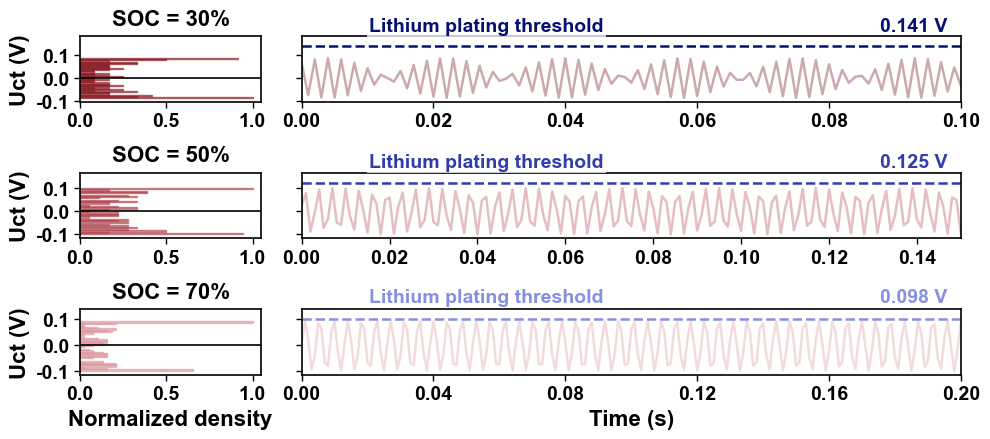

In [96]:
# =========================
# 0. Parameters
# =========================
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MaxNLocator


# ---------- File paths ----------
INPUT_FILE = r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\Uct_t.xlsx"
OUTPUT_DIR = r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2"

# ---------- Sheet order ----------
SHEETS = ["SOC30%", "SOC50%", "SOC70%"]

# ---------- Column names ----------
TIME_COL = "Time(s)"
UCT_COL = "U_ct(V)"

# ---------- Time range for each subplot ----------
CROP_TIME_RANGES = {
    "SOC30%": (0.0, 0.10),
    "SOC50%": (0.0, 0.15),
    "SOC70%": (0.0, 0.20),
}

# ---------- Horizontal threshold line values ----------
THRESHOLD_VALUES = {
    "SOC30%": 0.141,
    "SOC50%": 0.125,
    "SOC70%": 0.098,
}

# ---------- Threshold line style ----------
THRESHOLD_LINE_COLORS = {
    "SOC30%": "#051073",
    "SOC50%": "#313DAA",
    "SOC70%": "#868FE3",
}
THRESHOLD_LINESTYLE = "--"
THRESHOLD_LINEWIDTH = 1.8

# ---------- Threshold text style ----------
THRESHOLD_TEXT_COLOR = None
THRESHOLD_TEXT_FONTSIZE = 14
THRESHOLD_TEXT_FONTWEIGHT = "bold"
THRESHOLD_TEXT_X = 0.98
THRESHOLD_TEXT_Y_OFFSET = 0.05

# ---------- Lithium plating threshold label ----------
PLATING_LABEL_TEXT = "Lithium plating threshold"

PLATING_LABEL_X = {
    "SOC30%": 0.28,
    "SOC50%": 0.28,
    "SOC70%": 0.28,
}

PLATING_LABEL_Y_OFFSET = 0.05
PLATING_LABEL_FONTSIZE = 14
PLATING_LABEL_FONTWEIGHT = "bold"
PLATING_LABEL_COLOR = None

PLATING_LABEL_BBOX = dict(
    facecolor="white",
    edgecolor="none",
    alpha=0.75,
    pad=1.5
)

# ---------- Y-axis margin control ----------
Y_MARGIN_RATIO_LOWER = 0.08
Y_MARGIN_RATIO_UPPER = 0.16
Y_UPPER_EXTRA_ABS = 0.008

# ---------- X-axis formatting ----------
SOC70_X_DECIMALS = 2
SOC70_X_NBINS = 6

# ---------- Save settings ----------
SAVE_PNG = True
SAVE_PDF = False
DPI = 300
OUTPUT_BASENAME = "Uct_distribution_and_waveform_SOC30_50_70"

# ---------- Figure layout ----------
FIGSIZE = (10, 4.5)
NROWS = 3
NCOLS = 2

# 左侧分布图与右侧波形图的宽度比例
WIDTH_RATIOS = [1.1, 4.0]

# ---------- Font settings ----------
FONT_FAMILY = ["Arial", "DejaVu Sans", "Liberation Sans"]
TITLE_FONTSIZE = 16
AXIS_LABEL_FONTSIZE = 16
TICK_FONTSIZE = 14
FONT_WEIGHT = "bold"

# ---------- Waveform style ----------
LINE_COLORS = {
    "SOC30%": "#6F0A13",
    "SOC50%": "#B2454E",
    "SOC70%": "#DD989E",
}
LINEWIDTH = 1.8
LINESTYLE = "-"
WAVEFORM_ALPHA = 0.35   # 半透明背景

# ---------- Distribution style ----------
DIST_BINS = 36
DIST_FILL_ALPHA = 0.60
DIST_EDGE_ALPHA = 0.90
DIST_LINEWIDTH = 1.0

# 左侧分布颜色
DIST_COLORS = {
    "SOC30%": "#881922",
    "SOC50%": "#B2454E",
    "SOC70%": "#DD989E",
}

# 左图横轴标题
DIST_X_LABEL = "Normalized density"

# 分布是否画中心线（均值）
SHOW_MEAN_LINE = True
MEAN_LINESTYLE = "-"
MEAN_LINEWIDTH = 1.2
MEAN_LINE_COLOR = "black"

# ---------- Axis style ----------
SPINE_LINEWIDTH = 1.2
TICK_WIDTH = 1.0
TICK_LENGTH = 4

# ---------- Grid style ----------
SHOW_GRID = False

# ---------- Labels ----------
X_LABEL = "Time (s)"
Y_LABEL = "Uct (V)"

# ---------- Background ----------
AX_FACE_COLOR = "white"
FIG_FACE_COLOR = "white"

# ---------- Clip settings ----------
CLIP_UPPER_VALUES = {
    "SOC70%": 0.09,
}


# =========================
# 1. Prepare environment
# =========================
plt.rcParams["font.sans-serif"] = FONT_FAMILY
plt.rcParams["axes.unicode_minus"] = False

os.makedirs(OUTPUT_DIR, exist_ok=True)


# =========================
# 2. Read and crop data
# =========================
data_dict = {}

for sheet in SHEETS:
    df = pd.read_excel(INPUT_FILE, sheet_name=sheet)

    if TIME_COL not in df.columns or UCT_COL not in df.columns:
        raise ValueError(
            f"Sheet '{sheet}' does not contain required columns: "
            f"'{TIME_COL}' and '{UCT_COL}'.\n"
            f"Available columns: {list(df.columns)}"
        )

    df = df[[TIME_COL, UCT_COL]].copy()

    df[TIME_COL] = pd.to_numeric(df[TIME_COL], errors="coerce")
    df[UCT_COL] = pd.to_numeric(df[UCT_COL], errors="coerce")
    df = df.dropna(subset=[TIME_COL, UCT_COL]).reset_index(drop=True)

    t_start, t_end = CROP_TIME_RANGES[sheet]

    df_crop = df[
        (df[TIME_COL] >= t_start) &
        (df[TIME_COL] <= t_end)
    ].copy()

    if df_crop.empty:
        raise ValueError(
            f"No data left after cropping in sheet '{sheet}'. "
            f"Please check CROP_TIME_RANGES."
        )

    if sheet in CLIP_UPPER_VALUES:
        upper_limit = CLIP_UPPER_VALUES[sheet]
        df_crop[UCT_COL] = df_crop[UCT_COL].clip(upper=upper_limit)

    data_dict[sheet] = df_crop


# =========================
# 3. Create figure
# =========================
fig, axes = plt.subplots(
    nrows=NROWS,
    ncols=NCOLS,
    figsize=FIGSIZE,
    gridspec_kw={"width_ratios": WIDTH_RATIOS},
    sharey=False
)

fig.patch.set_facecolor(FIG_FACE_COLOR)


# =========================
# 4. Plot each row
# =========================
for row_idx, sheet in enumerate(SHEETS):
    ax_dist = axes[row_idx, 0]
    ax_wave = axes[row_idx, 1]

    df = data_dict[sheet]
    t_start, t_end = CROP_TIME_RANGES[sheet]
    threshold_value = THRESHOLD_VALUES[sheet]

    time_data = df[TIME_COL].to_numpy()
    uct_data = df[UCT_COL].to_numpy()

    # -------------------------
    # 4.1 Determine common y-range
    # -------------------------
    y_data_min = np.min(uct_data)
    y_data_max = np.max(uct_data)

    y_min_raw = min(y_data_min, threshold_value)
    y_max_raw = max(y_data_max, threshold_value)

    y_span = y_max_raw - y_min_raw
    if y_span <= 0:
        y_span = 1.0

    y_lower = y_min_raw - Y_MARGIN_RATIO_LOWER * y_span
    y_upper = y_max_raw + Y_MARGIN_RATIO_UPPER * y_span + Y_UPPER_EXTRA_ABS

    # -------------------------
    # 4.2 Left panel: distribution
    # -------------------------
    hist_counts, bin_edges = np.histogram(
        uct_data,
        bins=DIST_BINS,
        density=True
    )

    # 归一化到 0~1，方便不同SOC视觉一致
    if hist_counts.max() > 0:
        hist_counts_norm = hist_counts / hist_counts.max()
    else:
        hist_counts_norm = hist_counts

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_heights = np.diff(bin_edges)

    bar_color = DIST_COLORS.get(sheet, "#B2454E")

    ax_dist.barh(
        bin_centers,
        hist_counts_norm,
        height=bin_heights,
        color=bar_color,
        alpha=DIST_FILL_ALPHA,
        edgecolor=bar_color,
        linewidth=DIST_LINEWIDTH
    )

    # 均值线
    if SHOW_MEAN_LINE:
        uct_mean = np.mean(uct_data)
        ax_dist.axhline(
            y=uct_mean,
            color=MEAN_LINE_COLOR,
            linestyle=MEAN_LINESTYLE,
            linewidth=MEAN_LINEWIDTH
        )

    ax_dist.set_ylim(y_lower, y_upper)
    ax_dist.set_xlim(0, 1.05)

    ax_dist.set_title(
        sheet.replace("SOC", "SOC = "),
        fontsize=TITLE_FONTSIZE,
        fontweight=FONT_WEIGHT,
        pad=8
    )

    ax_dist.set_ylabel(
        Y_LABEL,
        fontsize=AXIS_LABEL_FONTSIZE,
        fontweight=FONT_WEIGHT
    )

    # 只在最后一行显示左图x轴标题
    if row_idx == NROWS - 1:
        ax_dist.set_xlabel(
            DIST_X_LABEL,
            fontsize=AXIS_LABEL_FONTSIZE,
            fontweight=FONT_WEIGHT
        )

    # 左图不显示太多x刻度
    ax_dist.set_xticks([0.0, 0.5, 1.0])
    ax_dist.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    ax_dist.tick_params(
        axis="both",
        labelsize=TICK_FONTSIZE,
        width=TICK_WIDTH,
        length=TICK_LENGTH
    )

    for tick_label in ax_dist.get_xticklabels() + ax_dist.get_yticklabels():
        tick_label.set_fontweight(FONT_WEIGHT)

    for spine in ax_dist.spines.values():
        spine.set_linewidth(SPINE_LINEWIDTH)

    # -------------------------
    # 4.3 Right panel: waveform
    # -------------------------
    ax_wave.plot(
        time_data,
        uct_data,
        color=LINE_COLORS.get(sheet, "black"),
        linewidth=LINEWIDTH,
        linestyle=LINESTYLE,
        alpha=WAVEFORM_ALPHA
    )

    # threshold dashed line
    line_color = THRESHOLD_LINE_COLORS.get(sheet, "red")
    ax_wave.axhline(
        y=threshold_value,
        color=line_color,
        linestyle=THRESHOLD_LINESTYLE,
        linewidth=THRESHOLD_LINEWIDTH
    )

    # lithium plating threshold label
    label_color = line_color if PLATING_LABEL_COLOR is None else PLATING_LABEL_COLOR

    ax_wave.text(
        PLATING_LABEL_X[sheet],
        threshold_value + PLATING_LABEL_Y_OFFSET,
        PLATING_LABEL_TEXT,
        transform=ax_wave.get_yaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=PLATING_LABEL_FONTSIZE,
        fontweight=PLATING_LABEL_FONTWEIGHT,
        color=label_color,
        bbox=PLATING_LABEL_BBOX
    )

    # threshold value text
    text_color = line_color if THRESHOLD_TEXT_COLOR is None else THRESHOLD_TEXT_COLOR
    ax_wave.text(
        THRESHOLD_TEXT_X,
        threshold_value + THRESHOLD_TEXT_Y_OFFSET,
        f"{threshold_value:.3f} V",
        transform=ax_wave.get_yaxis_transform(),
        ha="right",
        va="bottom",
        fontsize=THRESHOLD_TEXT_FONTSIZE,
        fontweight=THRESHOLD_TEXT_FONTWEIGHT,
        color=text_color
    )

    ax_wave.set_ylim(y_lower, y_upper)
    ax_wave.set_xlim(t_start, t_end)
    ax_wave.set_facecolor(AX_FACE_COLOR)

    # 右图不重复写y轴标题
    ax_wave.set_yticklabels([])

    # 只在最后一行显示右图x轴标题
    if row_idx == NROWS - 1:
        ax_wave.set_xlabel(
            X_LABEL,
            fontsize=AXIS_LABEL_FONTSIZE,
            fontweight=FONT_WEIGHT
        )

    # SOC70% x-axis formatting
    if sheet == "SOC70%":
        ax_wave.xaxis.set_major_locator(MaxNLocator(nbins=SOC70_X_NBINS))
        ax_wave.xaxis.set_major_formatter(
            FormatStrFormatter(f"%.{SOC70_X_DECIMALS}f")
        )

    ax_wave.tick_params(
        axis="both",
        labelsize=TICK_FONTSIZE,
        width=TICK_WIDTH,
        length=TICK_LENGTH
    )

    for tick_label in ax_wave.get_xticklabels():
        tick_label.set_fontweight(FONT_WEIGHT)

    for spine in ax_wave.spines.values():
        spine.set_linewidth(SPINE_LINEWIDTH)

    if SHOW_GRID:
        ax_wave.grid(True, alpha=0.3)


# =========================
# 5. Layout and save
# =========================
fig.tight_layout()

png_path = Path(OUTPUT_DIR) / f"{OUTPUT_BASENAME}.png"
pdf_path = Path(OUTPUT_DIR) / f"{OUTPUT_BASENAME}.pdf"

if SAVE_PNG:
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    print(f"PNG saved to: {png_path}")

if SAVE_PDF:
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"PDF saved to: {pdf_path}")

plt.show()

PNG saved to: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\lithium_plating_current_bar_comparison.png


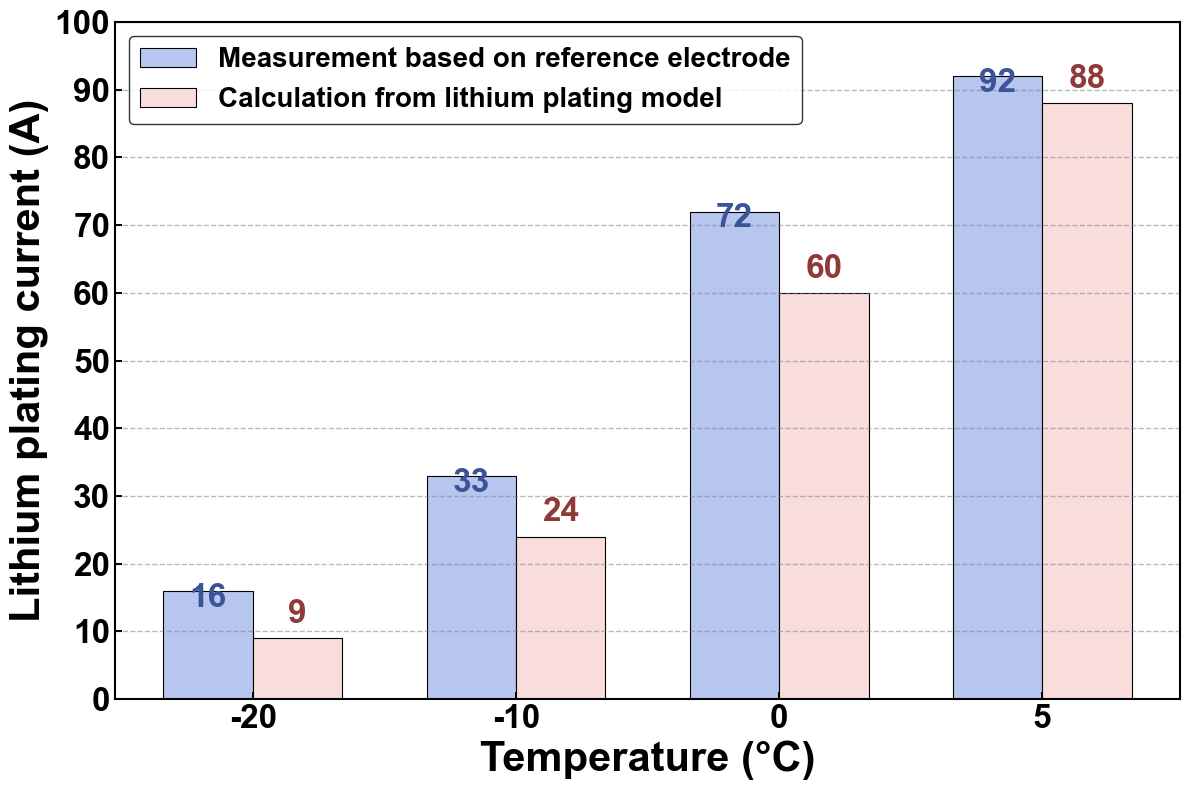

In [ ]:
# =========================
# 0. Parameters
# =========================
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ---------- Output path ----------
OUTPUT_DIR = r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2"
OUTPUT_BASENAME = "lithium_plating_current_bar_comparison"

SAVE_PNG = True
SAVE_PDF = False
DPI = 300


# ---------- Data ----------
# 这里目前还是温度分组
TEMPERATURE_C = np.array([-20, -10, 0, 5], dtype=float)

CURRENT_REFERENCE = np.array([16, 33, 72, 92], dtype=float)
CURRENT_MODEL = np.array([9, 24, 60, 88], dtype=float)


# ---------- Figure size ----------
FIGSIZE = (12, 8)


# ---------- Font settings ----------
FONT_FAMILY = ["Arial", "DejaVu Sans"]
AXIS_LABEL_FONTSIZE = 30
TICK_FONTSIZE = 24
LEGEND_FONTSIZE = 20
ANNOTATION_FONTSIZE = 24
FONT_WEIGHT = "bold"


# ---------- Bar settings ----------
REFERENCE_COLOR = "#B7C6EE"
MODEL_COLOR = "#F9DDDD"

BAR_WIDTH = 0.34
BAR_ALPHA = 1.0

# 柱子边框
BAR_EDGE_COLOR = "black"
BAR_EDGE_WIDTH = 0.8


# ---------- Axis settings ----------
X_LABEL = "Temperature (°C)"
Y_LABEL = "Lithium plating current (A)"

Y_LIMIT = (0, 100)
Y_TICKS = np.arange(0, 101, 10)


# ---------- Grid settings ----------
SHOW_GRID = True
GRID_LINESTYLE = "--"
GRID_LINEWIDTH = 1.0
GRID_ALPHA = 0.55
GRID_COLOR = "gray"


# ---------- Axis spine and tick settings ----------
SPINE_LINEWIDTH = 1.5
TICK_WIDTH = 1.4
TICK_LENGTH = 5


# ---------- Legend settings ----------
LEGEND_LOC = "upper left"
LEGEND_FRAMEON = True
LEGEND_FRAME_LINEWIDTH = 1.0
LEGEND_FACE_COLOR = "white"
LEGEND_EDGE_COLOR = "black"


# ---------- Value labels ----------
SHOW_VALUE_LABELS = True
VALUE_LABEL_Y_OFFSET = 1.2

REFERENCE_VALUE_LABEL_COLOR = "#3B5498"
MODEL_VALUE_LABEL_COLOR = "#8F3939"


# =========================
# 1. Prepare
# =========================
plt.rcParams["font.family"] = FONT_FAMILY
plt.rcParams["axes.unicode_minus"] = False

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

# 分组柱状图的位置
x = np.arange(len(TEMPERATURE_C))

# x 轴显示标签
x_labels = [f"{int(t)}" for t in TEMPERATURE_C]


# =========================
# 2. Plot
# =========================
fig, ax = plt.subplots(figsize=FIGSIZE)

bars_ref = ax.bar(
    x - BAR_WIDTH / 2,
    CURRENT_REFERENCE,
    width=BAR_WIDTH,
    color=REFERENCE_COLOR,
    alpha=BAR_ALPHA,
    edgecolor=BAR_EDGE_COLOR,
    linewidth=BAR_EDGE_WIDTH,
    label="Measurement based on reference electrode"
)

bars_model = ax.bar(
    x + BAR_WIDTH / 2,
    CURRENT_MODEL,
    width=BAR_WIDTH,
    color=MODEL_COLOR,
    alpha=BAR_ALPHA,
    edgecolor=BAR_EDGE_COLOR,
    linewidth=BAR_EDGE_WIDTH,
    label="Calculation from lithium plating model"
)


# =========================
# 3. Optional value labels
# =========================
if SHOW_VALUE_LABELS:
    for bar in bars_ref:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + VALUE_LABEL_Y_OFFSET,
            f"{height:.0f}",
            ha="center",
            va="bottom",
            fontsize=ANNOTATION_FONTSIZE,
            fontweight=FONT_WEIGHT,
            color=REFERENCE_VALUE_LABEL_COLOR
        )

    for bar in bars_model:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + VALUE_LABEL_Y_OFFSET,
            f"{height:.0f}",
            ha="center",
            va="bottom",
            fontsize=ANNOTATION_FONTSIZE,
            fontweight=FONT_WEIGHT,
            color=MODEL_VALUE_LABEL_COLOR
        )


# =========================
# 4. Axis formatting
# =========================
ax.set_ylim(Y_LIMIT)
ax.set_yticks(Y_TICKS)

ax.set_xticks(x)
ax.set_xticklabels(x_labels)

ax.set_xlabel(
    X_LABEL,
    fontsize=AXIS_LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT
)

ax.set_ylabel(
    Y_LABEL,
    fontsize=AXIS_LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT
)

ax.tick_params(
    axis="both",
    labelsize=TICK_FONTSIZE,
    width=TICK_WIDTH,
    length=TICK_LENGTH,
    direction="in"
)

for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontweight(FONT_WEIGHT)

for spine in ax.spines.values():
    spine.set_linewidth(SPINE_LINEWIDTH)

if SHOW_GRID:
    ax.grid(
        True,
        axis="y",
        linestyle=GRID_LINESTYLE,
        linewidth=GRID_LINEWIDTH,
        alpha=GRID_ALPHA,
        color=GRID_COLOR
    )


# =========================
# 5. Legend
# =========================
legend = ax.legend(
    loc=LEGEND_LOC,
    fontsize=LEGEND_FONTSIZE,
    frameon=LEGEND_FRAMEON
)

legend.get_frame().set_linewidth(LEGEND_FRAME_LINEWIDTH)
legend.get_frame().set_facecolor(LEGEND_FACE_COLOR)
legend.get_frame().set_edgecolor(LEGEND_EDGE_COLOR)

for text in legend.get_texts():
    text.set_fontweight(FONT_WEIGHT)


# =========================
# 6. Save and show
# =========================
fig.tight_layout()

png_path = Path(OUTPUT_DIR) / f"{OUTPUT_BASENAME}.png"
pdf_path = Path(OUTPUT_DIR) / f"{OUTPUT_BASENAME}.pdf"

if SAVE_PNG:
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    print(f"PNG saved to: {png_path}")

if SAVE_PDF:
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"PDF saved to: {pdf_path}")

plt.show()

findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberati

-20 °C: experiment=41 points, simulation=41 points
-10 °C: experiment=41 points, simulation=41 points
5 °C: experiment=41 points, simulation=41 points


findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberati

PNG saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\SOC50_EIS_Nyquist_comparison_real_data.png


findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberation Sans' not found.
findfont: Font family 'Liberati

PDF saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\SOC50_EIS_Nyquist_comparison_real_data.pdf


findfont: Font family 'Liberation Sans' not found.


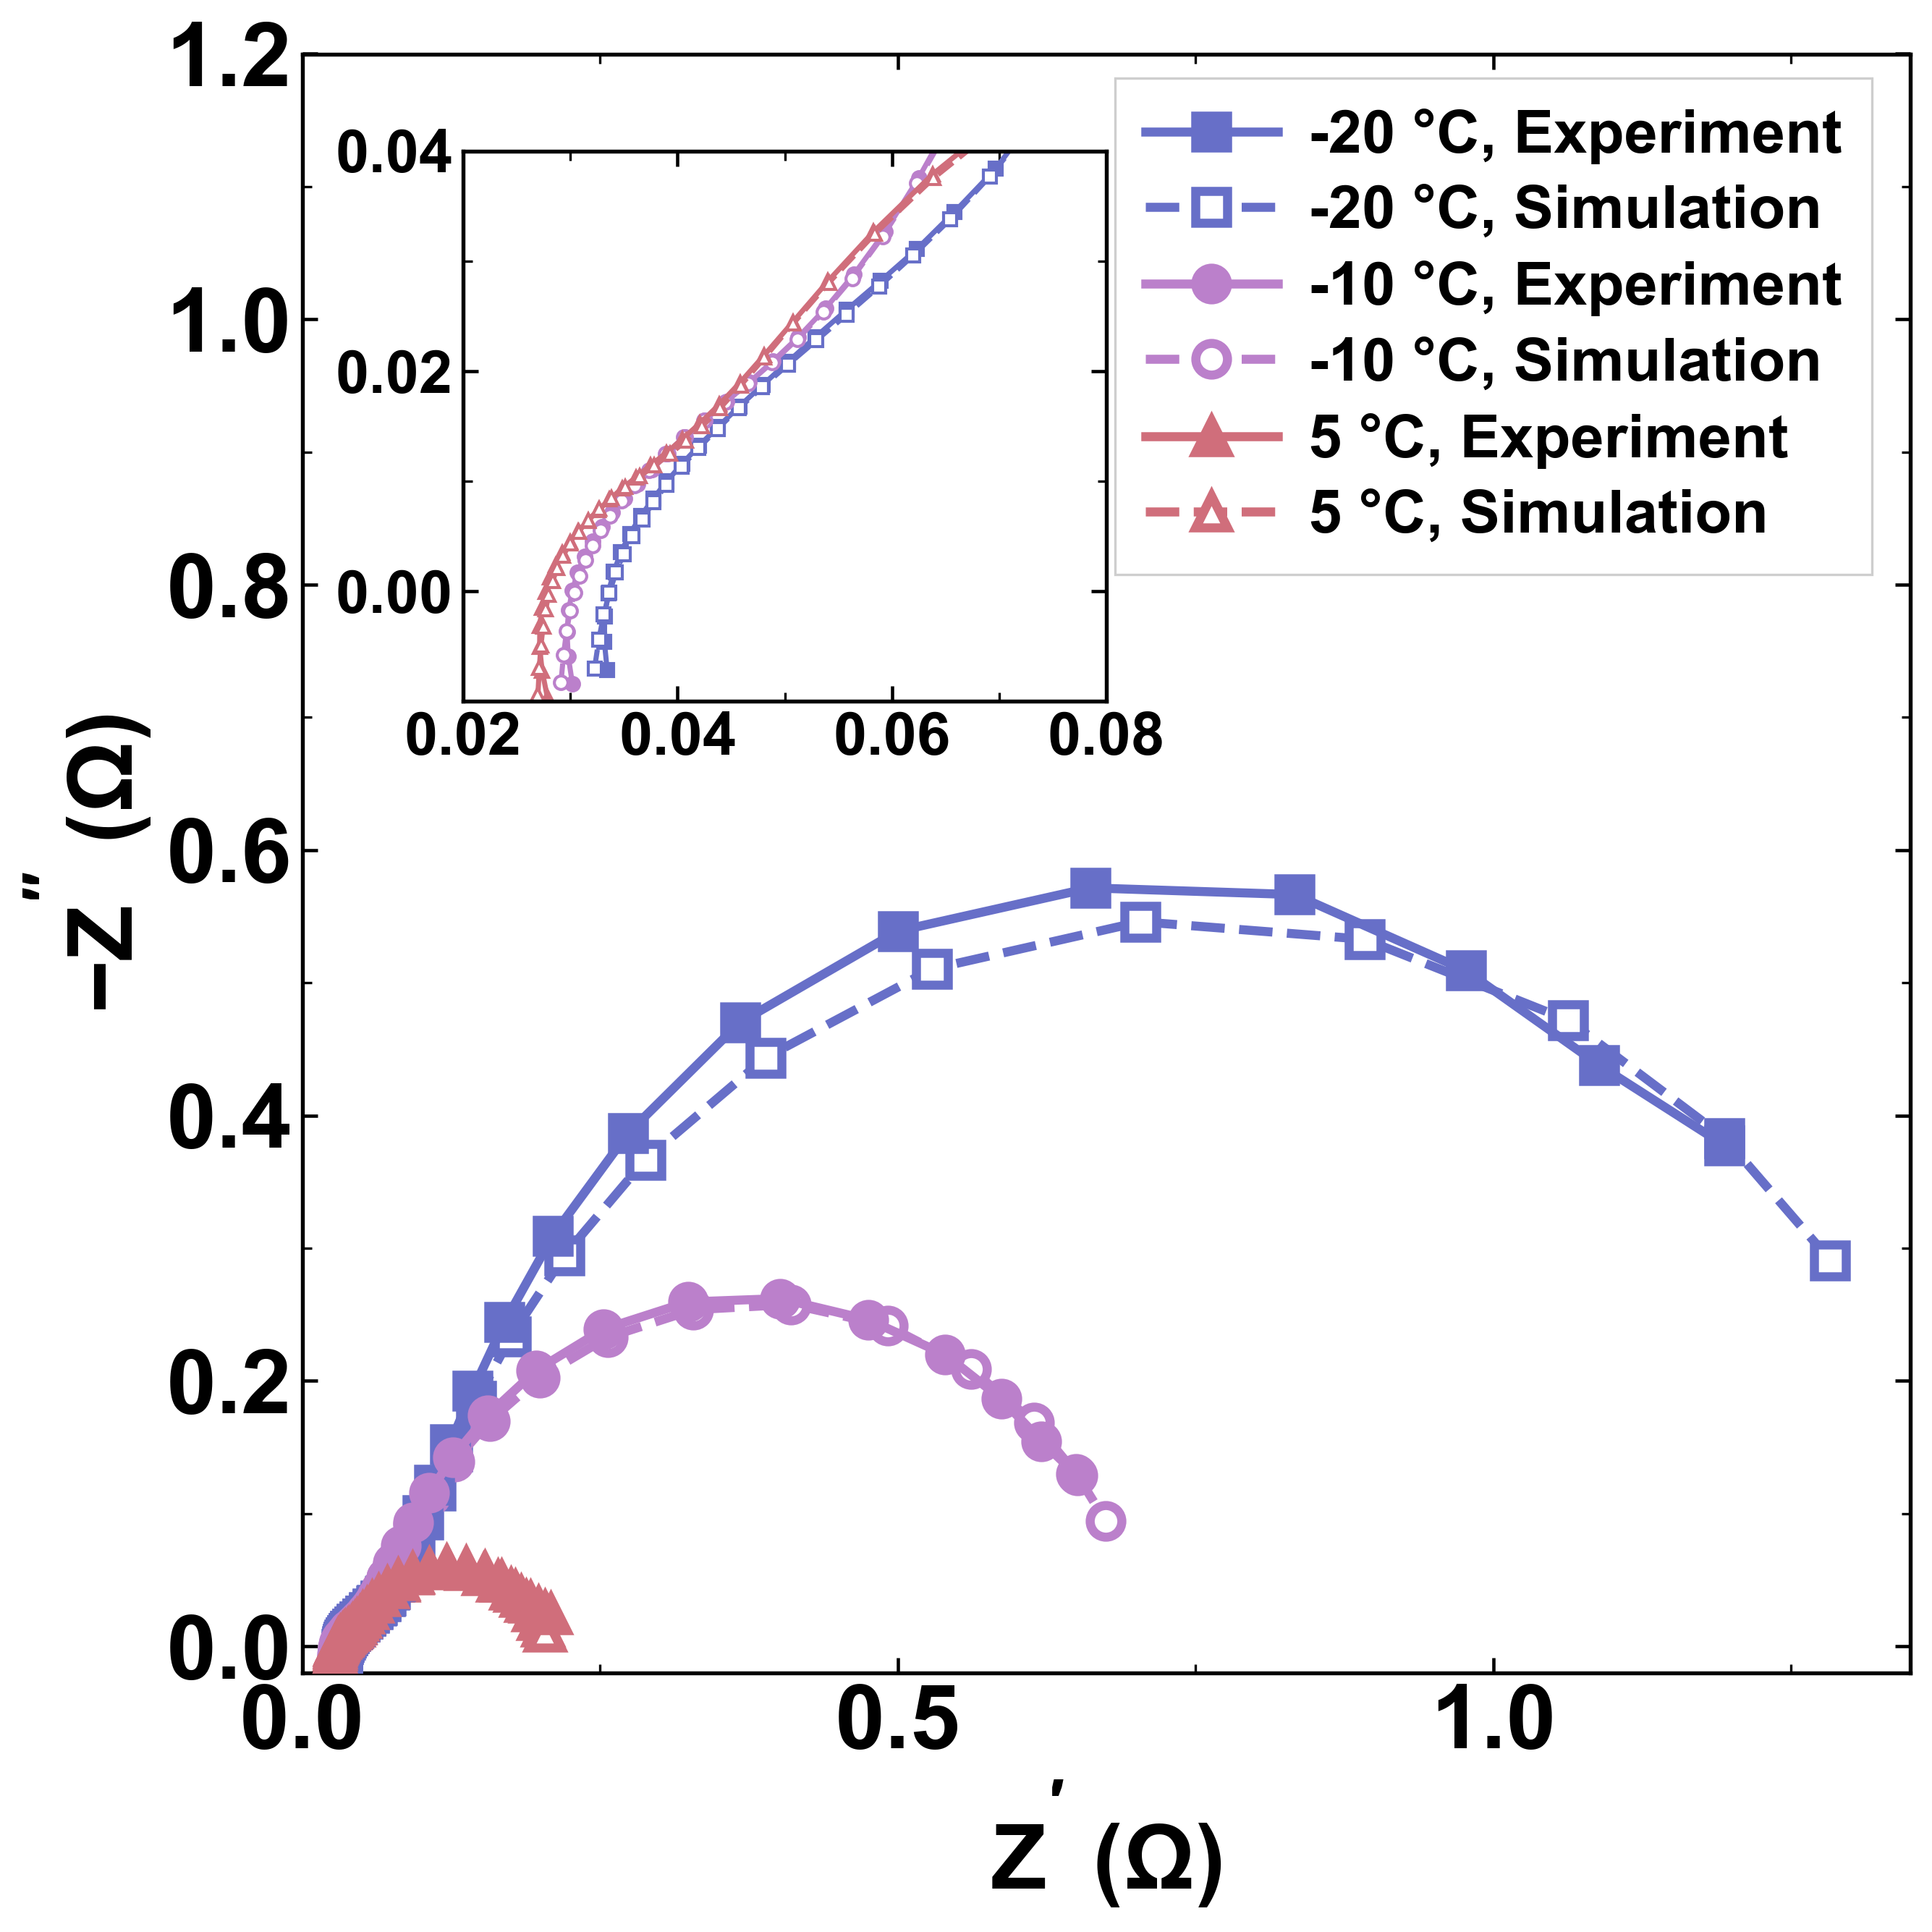

In [6]:

# -*- coding: utf-8 -*-

"""
EIS Nyquist comparison at SOC = 50%.

REAL DATA are read directly from:
    C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\Fig1c. EIS 阻抗对比验证.xls

Sheet:
    SOC50%

Current Excel layout:

    A:E  -> -20 °C
        A: frequency
        B: experimental real part
        C: experimental imaginary part
        D: simulated real part
        E: simulated imaginary part

    G:K  -> -10 °C
        G: frequency
        H: experimental real part
        I: experimental imaginary part
        J: simulated real part
        K: simulated imaginary part

    M:Q  -> 5 °C
        M: frequency
        N: experimental real part
        O: experimental imaginary part
        P: simulated real part
        Q: simulated imaginary part

Only the real Excel data are used; there are no manually traced points.

The Nyquist y-coordinate is plotted as -Z''.
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# =========================================================
# 0. USER SETTINGS
# =========================================================

# ---------- Input ----------
INPUT_FILE = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大"
    r"\Fig1c. EIS 阻抗对比验证.xls"
)

SHEET_NAME = "SOC50%"

# Excel row 3 is the first data row.
# pandas uses zero-based indexing, so DATA_START_ROW = 2.
DATA_START_ROW = 2


# ---------- Output ----------
OUTPUT_DIR = (
    INPUT_FILE.parent
    / "出图"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_NAME = "SOC50_EIS_Nyquist_comparison_real_data"

SAVE_PNG = True
SAVE_PDF = True
DPI = 300


# ---------- Figure ----------
# Keep the original plotting parameters unchanged.
FIGSIZE = (9, 9)

AXIS_LABEL_SIZE = 30
TICK_LABEL_SIZE = 30
LEGEND_SIZE = 20
INSET_TICK_SIZE = 20

FONT_WEIGHT = "bold"

X_LABEL = r"$Z^\prime$ ($\Omega$)"
Y_LABEL = r"$-Z^{\prime\prime}$ ($\Omega$)"


# ---------- Main-axis limits ----------
# Set to None for automatic limits.
MAIN_X_LIMIT = (0.0, 1.35)
MAIN_Y_LIMIT = (-0.02, 1.20)


# ---------- Inset limits ----------
INSET_X_LIMIT = (0.02, 0.08)
INSET_Y_LIMIT = (-0.01, 0.04)

# Inset position in the main-axis coordinate system:
# [left, bottom, width, height]
INSET_POSITION = [0.10, 0.60, 0.40, 0.34]


# ---------- Curve appearance ----------
LINE_WIDTH = 3.0
MARKER_SIZE = 10.5
MARKER_EDGE_WIDTH = 3

EXPERIMENT_LINESTYLE = "-"
SIMULATION_LINESTYLE = "--"

# Marker shape for each temperature
TEMPERATURE_MARKERS = {
    "-20 °C": "s",
    "-10 °C": "o",
    "5 °C": "^",
}

# Colors matching the original program
TEMPERATURE_COLORS = {
    "-20 °C": "#676FC8",
    "-10 °C": "#BB80CB",
    "5 °C": "#D06E7B",
}


# ---------- Grid ----------
SHOW_GRID = False
GRID_LINESTYLE = "--"
GRID_LINEWIDTH = 0.7
GRID_ALPHA = 0.30


# ---------- Legend ----------
SHOW_LEGEND = True
LEGEND_LOC = "lower right"
LEGEND_BBOX = (0.995, 0.66)
LEGEND_NCOL = 1


# ---------- Inset ----------
SHOW_INSET = True
INSET_LINE_WIDTH = 1.7
INSET_MARKER_SIZE = 4.5

# Optional arrow pointing toward the zoomed region
SHOW_ZOOM_ARROW = False
ARROW_COLOR = "#973327"
ARROW_LINEWIDTH = 5.0


# ---------- Axis ----------
SPINE_LINEWIDTH = 1.3
TICK_WIDTH = 1.1
TICK_LENGTH = 5


# =========================================================
# 1. REAL EXCEL DATA-BLOCK SETTINGS
# =========================================================
#
# Zero-based column indices in the NEW file:
#
# A:E:
#   A = 0 frequency
#   B = 1 experimental real
#   C = 2 experimental imaginary
#   D = 3 simulated real
#   E = 4 simulated imaginary
#
# G:K:
#   G = 6 frequency
#   H = 7 experimental real
#   I = 8 experimental imaginary
#   J = 9 simulated real
#   K = 10 simulated imaginary
#
# M:Q:
#   M = 12 frequency
#   N = 13 experimental real
#   O = 14 experimental imaginary
#   P = 15 simulated real
#   Q = 16 simulated imaginary
#
# Frequency columns are retained in the extracted data, although
# frequency is not directly used as a Nyquist-axis coordinate.
#
DATA_BLOCKS = {
    "-20 °C": {
        "frequency": 0,
        "exp_real": 1,
        "exp_imag": 2,
        "sim_real": 3,
        "sim_imag": 4,
    },

    "-10 °C": {
        "frequency": 6,
        "exp_real": 7,
        "exp_imag": 8,
        "sim_real": 9,
        "sim_imag": 10,
    },

    "5 °C": {
        "frequency": 12,
        "exp_real": 13,
        "exp_imag": 14,
        "sim_real": 15,
        "sim_imag": 16,
    },
}


# =========================================================
# 2. HELPER FUNCTIONS
# =========================================================

def read_xls_file(file_path, sheet_name):
    """
    Read the old .xls format using xlrd.

    Install xlrd when necessary:
        pip install xlrd
    """

    if not file_path.exists():

        raise FileNotFoundError(
            f"Input file not found:\n{file_path}"
        )

    try:

        dataframe = pd.read_excel(
            file_path,
            sheet_name=sheet_name,
            header=None,
            engine="xlrd"
        )

    except ImportError as error:

        raise ImportError(
            "Reading an .xls file requires xlrd.\n"
            "Install it using:\n"
            "pip install xlrd"
        ) from error

    except ValueError as error:

        try:

            xls = pd.ExcelFile(
                file_path,
                engine="xlrd"
            )

            available_sheets = (
                xls.sheet_names
            )

        except Exception:

            available_sheets = []

        raise ValueError(
            f"Cannot read sheet '{sheet_name}'.\n"
            f"Available sheets: {available_sheets}"
        ) from error

    return dataframe


def extract_one_block(raw, block_settings):
    """
    Extract real experimental and simulated impedance data directly
    from the Excel file. No digitization / manually traced points.
    """

    selected = pd.DataFrame({

        "frequency": pd.to_numeric(
            raw.iloc[
                DATA_START_ROW:,
                block_settings["frequency"]
            ],
            errors="coerce"
        ),

        "exp_real": pd.to_numeric(
            raw.iloc[
                DATA_START_ROW:,
                block_settings["exp_real"]
            ],
            errors="coerce"
        ),

        "exp_imag": pd.to_numeric(
            raw.iloc[
                DATA_START_ROW:,
                block_settings["exp_imag"]
            ],
            errors="coerce"
        ),

        "sim_real": pd.to_numeric(
            raw.iloc[
                DATA_START_ROW:,
                block_settings["sim_real"]
            ],
            errors="coerce"
        ),

        "sim_imag": pd.to_numeric(
            raw.iloc[
                DATA_START_ROW:,
                block_settings["sim_imag"]
            ],
            errors="coerce"
        ),

    }).reset_index(drop=True)


    # Experimental valid points
    exp_mask = (
        selected["exp_real"].notna()
        & selected["exp_imag"].notna()
    )


    # Simulation valid points
    sim_mask = (
        selected["sim_real"].notna()
        & selected["sim_imag"].notna()
    )


    exp_frequency = selected.loc[
        exp_mask,
        "frequency"
    ].to_numpy(dtype=float)

    exp_real = selected.loc[
        exp_mask,
        "exp_real"
    ].to_numpy(dtype=float)

    exp_imag = selected.loc[
        exp_mask,
        "exp_imag"
    ].to_numpy(dtype=float)


    sim_frequency = selected.loc[
        sim_mask,
        "frequency"
    ].to_numpy(dtype=float)

    sim_real = selected.loc[
        sim_mask,
        "sim_real"
    ].to_numpy(dtype=float)

    sim_imag = selected.loc[
        sim_mask,
        "sim_imag"
    ].to_numpy(dtype=float)


    if len(exp_real) == 0:

        raise ValueError(
            "No valid experimental data were found "
            "in one of the temperature blocks."
        )


    if len(sim_real) == 0:

        raise ValueError(
            "No valid simulated data were found "
            "in one of the temperature blocks."
        )


    return {

        "exp_frequency": exp_frequency,

        "exp_x": exp_real,

        "exp_y": -exp_imag,

        "sim_frequency": sim_frequency,

        "sim_x": sim_real,

        "sim_y": -sim_imag,

    }


def apply_axis_style(ax, tick_size):
    """
    Apply consistent axis and tick styles.
    """

    ax.tick_params(

        axis="both",

        which="major",

        direction="in",

        top=True,

        right=True,

        labelsize=tick_size,

        width=TICK_WIDTH,

        length=TICK_LENGTH

    )


    ax.tick_params(

        axis="both",

        which="minor",

        direction="in",

        top=True,

        right=True,

        width=0.8,

        length=3

    )


    ax.xaxis.set_minor_locator(
        AutoMinorLocator(2)
    )

    ax.yaxis.set_minor_locator(
        AutoMinorLocator(2)
    )


    for label in (
        ax.get_xticklabels()
        + ax.get_yticklabels()
    ):

        label.set_fontweight(
            FONT_WEIGHT
        )


    for spine in (
        ax.spines.values()
    ):

        spine.set_linewidth(
            SPINE_LINEWIDTH
        )


# =========================================================
# 3. READ REAL SOC50% DATA
# =========================================================

raw = read_xls_file(
    INPUT_FILE,
    SHEET_NAME
)


eis_data = {}


for temperature, settings in DATA_BLOCKS.items():

    eis_data[temperature] = extract_one_block(
        raw,
        settings
    )


    print(

        f"{temperature}: "

        f"experiment="
        f"{len(eis_data[temperature]['exp_x'])} points, "

        f"simulation="
        f"{len(eis_data[temperature]['sim_x'])} points"

    )


# =========================================================
# 4. CREATE FIGURE
# =========================================================

plt.rcParams["font.family"] = [
    "Arial",
    "DejaVu Sans",
    "Liberation Sans"
]

plt.rcParams["axes.unicode_minus"] = False

plt.rcParams["mathtext.default"] = "regular"


fig, ax = plt.subplots(

    figsize=FIGSIZE,

    dpi=DPI

)


# =========================================================
# 5. MAIN NYQUIST PLOT
# =========================================================

for temperature in [
    "-20 °C",
    "-10 °C",
    "5 °C"
]:

    data = eis_data[
        temperature
    ]

    color = TEMPERATURE_COLORS[
        temperature
    ]

    marker = TEMPERATURE_MARKERS[
        temperature
    ]


    # Experimental — directly from Excel

    ax.plot(

        data["exp_x"],

        data["exp_y"],

        color=color,

        linestyle=EXPERIMENT_LINESTYLE,

        linewidth=LINE_WIDTH,

        marker=marker,

        markersize=MARKER_SIZE,

        markerfacecolor=color,

        markeredgecolor=color,

        markeredgewidth=MARKER_EDGE_WIDTH,

        label=f"{temperature}, Experiment",

        zorder=4

    )


    # Simulation — directly from Excel

    ax.plot(

        data["sim_x"],

        data["sim_y"],

        color=color,

        linestyle=SIMULATION_LINESTYLE,

        linewidth=LINE_WIDTH,

        marker=marker,

        markersize=MARKER_SIZE,

        markerfacecolor="white",

        markeredgecolor=color,

        markeredgewidth=MARKER_EDGE_WIDTH,

        label=f"{temperature}, Simulation",

        zorder=3

    )


# =========================================================
# 6. MAIN AXIS FORMAT
# =========================================================

ax.set_xlabel(

    X_LABEL,

    fontsize=AXIS_LABEL_SIZE,

    fontweight=FONT_WEIGHT

)


ax.set_ylabel(

    Y_LABEL,

    fontsize=AXIS_LABEL_SIZE,

    fontweight=FONT_WEIGHT

)


if MAIN_X_LIMIT is not None:

    ax.set_xlim(
        *MAIN_X_LIMIT
    )


if MAIN_Y_LIMIT is not None:

    ax.set_ylim(
        *MAIN_Y_LIMIT
    )


apply_axis_style(

    ax,

    TICK_LABEL_SIZE

)


if SHOW_GRID:

    ax.grid(

        True,

        linestyle=GRID_LINESTYLE,

        linewidth=GRID_LINEWIDTH,

        alpha=GRID_ALPHA

    )


# =========================================================
# 7. LEGEND
# =========================================================

if SHOW_LEGEND:

    legend = ax.legend(

        loc=LEGEND_LOC,

        bbox_to_anchor=LEGEND_BBOX,

        ncol=LEGEND_NCOL,

        prop={

            "size": LEGEND_SIZE,

            "weight": FONT_WEIGHT

        },

        frameon=True,

        fancybox=False,

        framealpha=0.95,

        borderpad=0.5,

        handlelength=2.2,

        handletextpad=0.5,

        columnspacing=0.8,

        labelspacing=0.35

    )


    legend.get_frame().set_linewidth(
        0.8
    )


# =========================================================
# 8. LOCAL ZOOM-IN PLOT
# =========================================================

if SHOW_INSET:

    inset_ax = ax.inset_axes(
        INSET_POSITION
    )


    for temperature in [
        "-20 °C",
        "-10 °C",
        "5 °C"
    ]:

        data = eis_data[
            temperature
        ]

        color = TEMPERATURE_COLORS[
            temperature
        ]

        marker = TEMPERATURE_MARKERS[
            temperature
        ]


        inset_ax.plot(

            data["exp_x"],

            data["exp_y"],

            color=color,

            linestyle=EXPERIMENT_LINESTYLE,

            linewidth=INSET_LINE_WIDTH,

            marker=marker,

            markersize=INSET_MARKER_SIZE,

            markerfacecolor=color,

            markeredgecolor=color,

            markeredgewidth=1.0

        )


        inset_ax.plot(

            data["sim_x"],

            data["sim_y"],

            color=color,

            linestyle=SIMULATION_LINESTYLE,

            linewidth=INSET_LINE_WIDTH,

            marker=marker,

            markersize=INSET_MARKER_SIZE,

            markerfacecolor="white",

            markeredgecolor=color,

            markeredgewidth=1.0

        )


    inset_ax.set_xlim(
        *INSET_X_LIMIT
    )


    inset_ax.set_ylim(
        *INSET_Y_LIMIT
    )


    apply_axis_style(

        inset_ax,

        INSET_TICK_SIZE

    )


    inset_ax.grid(
        False
    )


# =========================================================
# 9. OPTIONAL ARROW
# =========================================================

if SHOW_ZOOM_ARROW:

    ax.annotate(

        "",

        xy=(0.16, 0.62),

        xytext=(0.035, 0.13),

        arrowprops={

            "arrowstyle": "->",

            "color": ARROW_COLOR,

            "linewidth": ARROW_LINEWIDTH

        },

        annotation_clip=False

    )


# =========================================================
# 10. SAVE AND SHOW
# =========================================================

fig.tight_layout()


png_path = (
    OUTPUT_DIR
    / f"{OUTPUT_NAME}.png"
)

pdf_path = (
    OUTPUT_DIR
    / f"{OUTPUT_NAME}.pdf"
)


if SAVE_PNG:

    fig.savefig(

        png_path,

        dpi=DPI,

        bbox_inches="tight"

    )

    print(
        f"PNG saved to:\n"
        f"{png_path}"
    )


if SAVE_PDF:

    fig.savefig(

        pdf_path,

        bbox_inches="tight"

    )

    print(
        f"PDF saved to:\n"
        f"{pdf_path}"
    )


plt.show()

plt.close(fig)


PNG saved to: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\Un_SOC_curve_with_Uct_bar_clipped.png


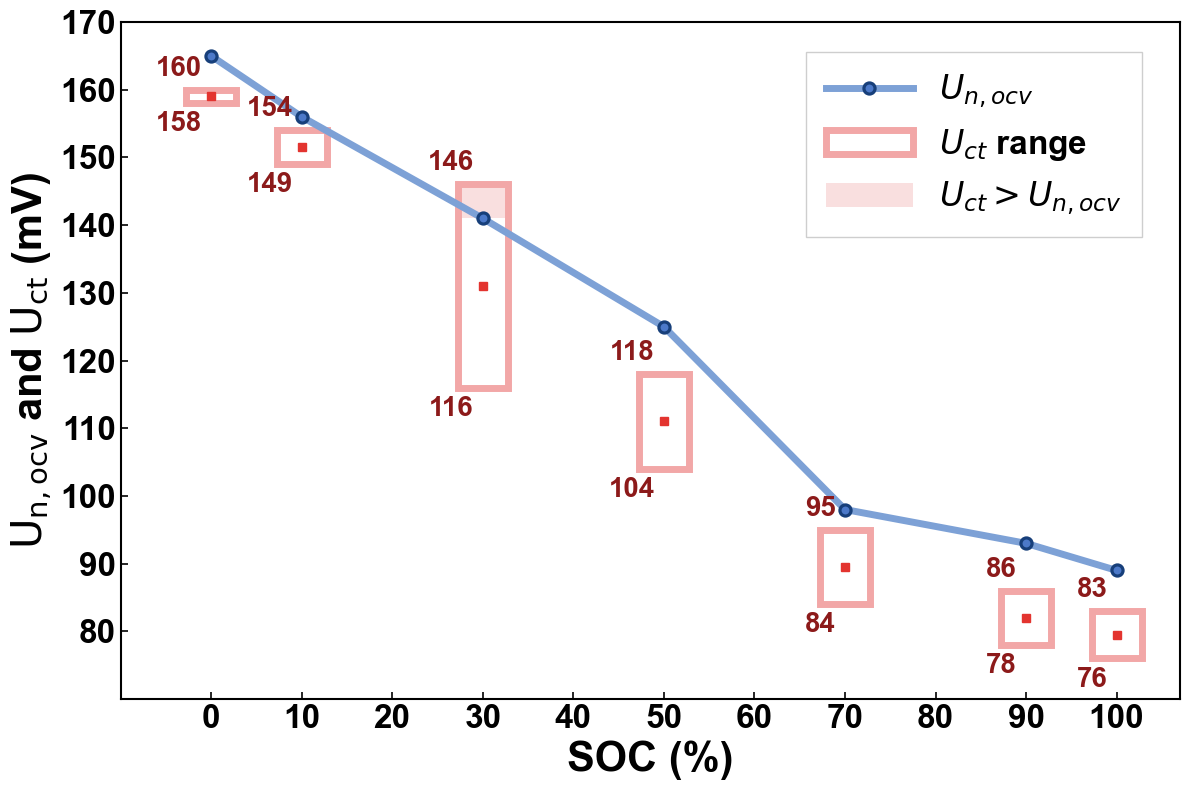

In [5]:
# =========================
# 0. Parameters
# =========================
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch


# ---------- Output path ----------
OUTPUT_DIR = r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2"
OUTPUT_BASENAME = "Un_SOC_curve_with_Uct_bar_clipped"

SAVE_PNG = True
SAVE_PDF = False
DPI = 300
BBOX_INCHES = "tight"


# ---------- Digitized data from the U_n,ocv figure ----------
SOC_PERCENT = np.array([0, 10, 30, 50, 70, 90, 100], dtype=float)
U_MV = np.array([165, 156, 141, 125, 98, 93, 89], dtype=float)


# =========================================================
# Uct bar data (unit: mV)
# =========================================================
# 这里换成你的真实 Uct 数据
# 每个 SOC 下给一个范围列表，程序自动取 min/max 作为上下限
UCT_VALUES_BY_SOC_MV = {
    0:   [158, 160],
    10:  [149, 154],
    30:  [116, 146],
    50:  [104, 118],
    70:  [84,  95],
    90:  [78,  86],
    100: [76,  83],
}


# ---------- Figure size ----------
FIGSIZE = (12, 8)   # 12:8


# ---------- Font settings ----------
FONT_FAMILY = ["Arial", "DejaVu Sans", "Liberation Sans"]

FONT_WEIGHT = "bold"
AXIS_LABEL_FONTSIZE = 30
TICK_FONTSIZE = 24
LEGEND_FONTSIZE = 24
ANNOTATION_FONTSIZE = 20


# ---------- Labels ----------
X_LABEL = "SOC (%)"
Y_LABEL = r"$\mathrm{U}_{\mathrm{n,ocv}}$ and $\mathrm{U}_{\mathrm{ct}}$ (mV)"


# ---------- U_n,ocv line and marker style ----------
LINE_COLOR = "#7DA1D6"
LINEWIDTH = 5
LINESTYLE = "-"

MARKER_STYLE = "o"
MARKER_SIZE = 8
MARKER_FACE_COLOR = "#4C79C9"
MARKER_EDGE_COLOR = "#173F7A"
MARKER_EDGE_WIDTH = 2.3


# ---------- Uct range box style ----------
UCT_BOX_WIDTH = 5.5

# 外框：透明，仅边框
UCT_BOX_EDGE_COLOR = "#F2A7A7"
UCT_BOX_LINEWIDTH = 5

# 超出 U_n,ocv 的部分：填充
UCT_FILL_COLOR = "#F8DADA"
UCT_FILL_ALPHA = 0.85

# 中心点
SHOW_UCT_CENTER_MARKER = True
UCT_CENTER_MARKER = "s"
UCT_CENTER_MARKER_SIZE = 6
UCT_CENTER_COLOR = "#E3342F"

# 上下限标注
ANNOTATE_UCT_LIMITS = True
UCT_TEXT_COLOR = "#CC2E2E"

# 文字偏移
TOP_TEXT_Y_OFFSET = 1.0
BOTTOM_TEXT_Y_OFFSET = 1.0


# ---------- Axis limits and ticks ----------
# 轴范围稍微放宽，让最左和最右的条形框完整显示
X_LIMIT = (-10, 107)

# y轴向下扩展一点，让 76、78 这些下限和文字能显示出来
Y_LIMIT = (70, 170)

# 仍然只标 0~100 的 SOC
X_TICKS = np.arange(0, 101, 10)

# y轴刻度可以仍然从80开始
Y_TICKS = np.arange(80, 171, 10)


# ---------- Grid settings ----------
SHOW_GRID = False
GRID_COLOR = "0.75"
GRID_LINESTYLE = "--"
GRID_LINEWIDTH = 0.8
GRID_ALPHA = 0.55


# ---------- Axis spine and tick settings ----------
SPINE_LINEWIDTH = 1.5
SPINE_COLOR = "black"

TICK_WIDTH = 1.2
TICK_LENGTH = 5
TICK_DIRECTION = "in"


# ---------- Legend ----------
SHOW_LEGEND = True
LEGEND_LOC = "upper right"
LEGEND_BBOX = (0.98, 0.98)

# 上下限数字标注
ANNOTATE_UCT_LIMITS = True
UCT_TEXT_COLOR = "#8C1A1A"

# 字号放大一点
ANNOTATION_FONTSIZE = 20

# 左右/上下偏移
UCT_TEXT_X_OFFSET = 1
TOP_TEXT_Y_OFFSET = 1.2
BOTTOM_TEXT_Y_OFFSET = 1.2


# =========================
# 1. Prepare
# =========================
plt.rcParams["font.sans-serif"] = FONT_FAMILY
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)


# =========================
# 2. Convert Uct data to ranges
# =========================
uct_bottom = []
uct_top = []
uct_center = []

for soc in SOC_PERCENT:
    values = np.array(UCT_VALUES_BY_SOC_MV[int(soc)], dtype=float)
    uct_bottom.append(values.min())
    uct_top.append(values.max())
    uct_center.append(values.mean())

uct_bottom = np.array(uct_bottom, dtype=float)
uct_top = np.array(uct_top, dtype=float)
uct_center = np.array(uct_center, dtype=float)


# =========================
# 3. Plot
# =========================
fig, ax = plt.subplots(figsize=FIGSIZE)

# ---- U_n,ocv line ----
line_un, = ax.plot(
    SOC_PERCENT,
    U_MV,
    color=LINE_COLOR,
    linewidth=LINEWIDTH,
    linestyle=LINESTYLE,
    marker=MARKER_STYLE,
    markersize=MARKER_SIZE,
    markerfacecolor=MARKER_FACE_COLOR,
    markeredgecolor=MARKER_EDGE_COLOR,
    markeredgewidth=MARKER_EDGE_WIDTH,
    zorder=4,
    label=r"$U_{n,ocv}$"
)


# =========================
# 4. Draw Uct range boxes
# =========================
for x, y_un, y_bottom, y_top, y_center in zip(
    SOC_PERCENT, U_MV, uct_bottom, uct_top, uct_center
):
    # -----------------------------------
    # 4.1 Prevent the box from exceeding x-boundaries
    # -----------------------------------
    x_left = max(x - UCT_BOX_WIDTH / 2, X_LIMIT[0])
    x_right = min(x + UCT_BOX_WIDTH / 2, X_LIMIT[1])
    box_width_actual = x_right - x_left

    if box_width_actual <= 0:
        continue

    # -----------------------------------
    # 4.2 Draw transparent outer box
    # -----------------------------------
    box_outline = Rectangle(
        (x_left, y_bottom),
        box_width_actual,
        y_top - y_bottom,
        facecolor="none",
        edgecolor=UCT_BOX_EDGE_COLOR,
        linewidth=UCT_BOX_LINEWIDTH,
        zorder=2,
        clip_on=True
    )
    ax.add_patch(box_outline)

    # -----------------------------------
    # 4.3 Fill only the part above U_n,ocv
    # -----------------------------------
    fill_bottom = max(y_bottom, y_un)
    fill_top = y_top

    if fill_top > fill_bottom:
        fill_rect = Rectangle(
            (x_left, fill_bottom),
            box_width_actual,
            fill_top - fill_bottom,
            facecolor=UCT_FILL_COLOR,
            edgecolor="none",
            alpha=UCT_FILL_ALPHA,
            zorder=1,
            clip_on=True
        )
        ax.add_patch(fill_rect)

    # -----------------------------------
    # 4.4 Draw Uct center marker
    # -----------------------------------
    if SHOW_UCT_CENTER_MARKER:
        ax.plot(
            x,
            y_center,
            linestyle="none",
            marker=UCT_CENTER_MARKER,
            markersize=UCT_CENTER_MARKER_SIZE,
            markerfacecolor=UCT_CENTER_COLOR,
            markeredgecolor=UCT_CENTER_COLOR,
            zorder=5
        )

    # -----------------------------------
    # 4.5 Annotate upper and lower limits
    # -----------------------------------
    if ANNOTATE_UCT_LIMITS:
        ax.text(
            x - UCT_TEXT_X_OFFSET,
            y_top + TOP_TEXT_Y_OFFSET,
            f"{y_top:.0f}",
            ha="right",
            va="bottom",
            fontsize=ANNOTATION_FONTSIZE,
            fontweight=FONT_WEIGHT,
            color=UCT_TEXT_COLOR,
            zorder=6
        )

        ax.text(
            x - UCT_TEXT_X_OFFSET,
            y_bottom - BOTTOM_TEXT_Y_OFFSET,
            f"{y_bottom:.0f}",
            ha="right",
            va="top",
            fontsize=ANNOTATION_FONTSIZE,
            fontweight=FONT_WEIGHT,
            color=UCT_TEXT_COLOR,
            zorder=6
        )


# =========================
# 5. Axis formatting
# =========================
ax.set_xlim(X_LIMIT)
ax.set_ylim(Y_LIMIT)

ax.set_xticks(X_TICKS)
ax.set_yticks(Y_TICKS)

ax.set_xlabel(
    X_LABEL,
    fontsize=AXIS_LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT
)

ax.set_ylabel(
    Y_LABEL,
    fontsize=AXIS_LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT
)

ax.tick_params(
    axis="both",
    labelsize=TICK_FONTSIZE,
    width=TICK_WIDTH,
    length=TICK_LENGTH,
    direction=TICK_DIRECTION
)

for tick_label in ax.get_xticklabels() + ax.get_yticklabels():
    tick_label.set_fontweight(FONT_WEIGHT)

for spine in ax.spines.values():
    spine.set_linewidth(SPINE_LINEWIDTH)
    spine.set_color(SPINE_COLOR)

if SHOW_GRID:
    ax.grid(
        True,
        color=GRID_COLOR,
        linestyle=GRID_LINESTYLE,
        linewidth=GRID_LINEWIDTH,
        alpha=GRID_ALPHA,
        zorder=0
    )


# =========================
# 6. Legend
# =========================
if SHOW_LEGEND:
    uct_patch = Patch(
        facecolor="none",
        edgecolor=UCT_BOX_EDGE_COLOR,
        linewidth=UCT_BOX_LINEWIDTH,
        label=r"$U_{ct}$ range"
    )

    fill_patch = Patch(
        facecolor=UCT_FILL_COLOR,
        edgecolor="none",
        alpha=UCT_FILL_ALPHA,
        label=r"$U_{ct} > U_{n,ocv}$"
    )

    legend = ax.legend(
        handles=[line_un, uct_patch, fill_patch],
        loc=LEGEND_LOC,
        bbox_to_anchor=LEGEND_BBOX,
        prop={
            "size": LEGEND_FONTSIZE,
            "weight": FONT_WEIGHT
        },
        frameon=True,
        fancybox=False,
        framealpha=0.95,
        borderpad=0.6,
        handlelength=2.6
    )
    legend.get_frame().set_linewidth(1.0)


# =========================
# 7. Save and show
# =========================
fig.tight_layout()

png_path = Path(OUTPUT_DIR) / f"{OUTPUT_BASENAME}.png"
pdf_path = Path(OUTPUT_DIR) / f"{OUTPUT_BASENAME}.pdf"

if SAVE_PNG:
    fig.savefig(png_path, dpi=DPI, bbox_inches=BBOX_INCHES)
    print(f"PNG saved to: {png_path}")

if SAVE_PDF:
    fig.savefig(pdf_path, bbox_inches=BBOX_INCHES)
    print(f"PDF saved to: {pdf_path}")

plt.show()

SOC = 50%
T = -20 °C
----------------------------------------------------------------------
R0 = 0.02999200 Ω = 29.9920 mΩ
Static Rct parameter = 1.32320000 Ω = 1323.2000 mΩ
Qdl = 0.29864000
ndl = 0.87595600
----------------------------------------------------------------------
At 1000 Hz:
Re(Zct) = 0.0003070589 Ω = 0.3071 mΩ
|Zct|   = 0.0015765694 Ω = 1.5766 mΩ
----------------------------------------------------------------------
Re(Zct) / R0 = 1.0238%
|Zct| / R0   = 5.2566%
Re(Zct) / static Rct = 0.023206%
|Zct| / static Rct   = 0.119148%
PNG saved to: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\rct_frequency_ratio_SOC50_Tminus20_f1000Hz.png


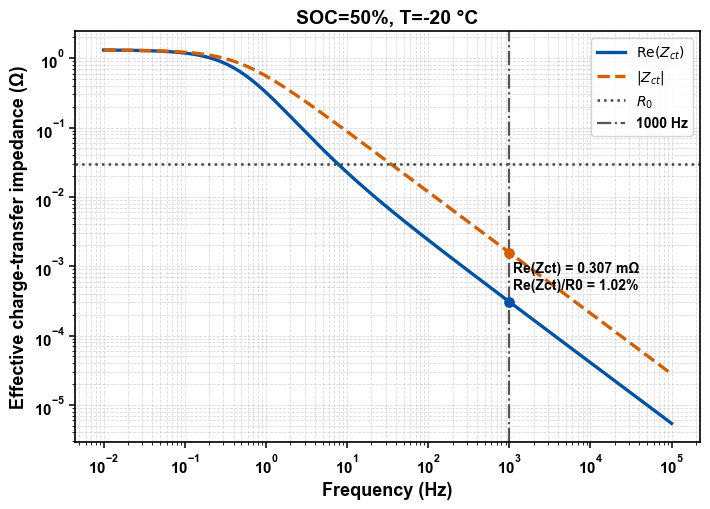

In [ ]:
# -*- coding: utf-8 -*-
"""
Rct-frequency analysis based on second-order R-CPE model

Model:
    Zct = Rct / (1 + Rct * Qdl * (j*w)^ndl)

Outputs:
1. Frequency-dependent Re(Zct)
2. Frequency-dependent |Zct|
3. Ratio at target frequency:
   Re(Zct)/R0
   |Zct|/R0
   Re(Zct)/static Rct
   |Zct|/static Rct
"""

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# 0. User parameters
# =========================================================

# ---------- Working condition ----------
SOC_SELECT = 50          # available: 30, 50, 70
TEMP_SELECT_C = -20      # temperature, unit: degC
FREQ_TARGET_HZ = 1000    # target frequency to evaluate

# ---------- Frequency range ----------
FREQ_MIN_HZ = 0.01
FREQ_MAX_HZ = 100000
N_FREQ = 2000

# ---------- Output ----------
OUTPUT_DIR = r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2"
OUTPUT_BASENAME = "rct_frequency_ratio"

SAVE_PNG = True
SAVE_PDF = False
DPI = 300

# ---------- Figure size ----------
FIGSIZE = (7.2, 5.2)

# ---------- Font ----------
FONT_FAMILY = ["Arial", "DejaVu Sans", "Liberation Sans"]
FONT_WEIGHT = "bold"

TITLE_FONTSIZE = 14
AXIS_LABEL_FONTSIZE = 13
TICK_FONTSIZE = 11
LEGEND_FONTSIZE = 10
ANNOTATION_FONTSIZE = 10

# ---------- Line style ----------
COLOR_RCT_REAL = "#0052A5"
COLOR_RCT_MAG = "#D55E00"
COLOR_R0 = "#444444"
COLOR_TARGET_FREQ = "#555555"

LINEWIDTH_RCT_REAL = 2.4
LINEWIDTH_RCT_MAG = 2.4
LINEWIDTH_R0 = 1.8
LINEWIDTH_TARGET_FREQ = 1.6

LINESTYLE_RCT_REAL = "-"
LINESTYLE_RCT_MAG = "--"
LINESTYLE_R0 = ":"
LINESTYLE_TARGET_FREQ = "-."

MARKER_SIZE = 45

# ---------- Axis / grid ----------
SHOW_GRID = True
GRID_LINESTYLE = "--"
GRID_LINEWIDTH = 0.6
GRID_ALPHA = 0.45

SPINE_LINEWIDTH = 1.2
TICK_WIDTH = 1.1
TICK_LENGTH = 4

# ---------- Labels ----------
X_LABEL = "Frequency (Hz)"
Y_LABEL = "Effective charge-transfer impedance (Ω)"
TITLE_TEMPLATE = "SOC={soc}%, T={temp} °C"

# ---------- Annotation ----------
SHOW_ANNOTATION = True
ANNOTATION_X_SCALE = 1.12
ANNOTATION_Y_SCALE = 1.40


# =========================================================
# 1. PRSM coefficients
# =========================================================
# Polynomial form:
#     p(T) = c0 + c1*T + c2*T^2 + c3*T^3 + ...
#
# Unit:
#     R0, Rct: ohm
#     T: degC

SOC_LIST = [30, 50, 70]

COEF_R0 = {
    30: [0.031, -1.334e-4,  3.961e-6,  0.0],
    50: [0.027, -7.328e-5,  3.816e-6,  0.0],
    70: [0.029, -6.481e-5, -1.054e-5, -1.003e-6],
}

COEF_RCT = {
    30: [0.211, -0.019, 9.128e-4, -4.276e-5],
    50: [0.258, -0.025, 1.413e-3,  0.0],
    70: [0.187, -0.017, 8.381e-4, -4.318e-5],
}

COEF_QDL = {
    30: [0.821, 0.036, 6.924e-4],
    50: [0.542, 0.019, 3.416e-4],
    70: [0.577, 0.019, 2.878e-4],
}

COEF_NDL = {
    30: [0.718, -7.151e-3, -1.144e-4, 0.0],
    50: [0.812, -4.440e-3, -2.115e-5, 2.048e-6],
    70: [0.806, -4.491e-3,  1.028e-4, 1.174e-5],
}


# =========================================================
# 2. Functions
# =========================================================

def poly_eval(coefs, T):
    """
    Evaluate polynomial:
        p(T) = c0 + c1*T + c2*T^2 + ...
    """
    value = 0.0
    for i, c in enumerate(coefs):
        value += c * (T ** i)
    return value


def z_r_parallel_cpe(R, Q, n, freq_hz):
    """
    Impedance of R || CPE.

    CPE impedance:
        Z_cpe = 1 / (Q * (j*w)^n)

    Parallel branch:
        Z = R / (1 + R * Q * (j*w)^n)
    """
    freq_hz = np.asarray(freq_hz, dtype=float)
    w = 2.0 * np.pi * freq_hz

    Z = R / (1.0 + R * Q * (1j * w) ** n)

    return Z


def calculate_rct_frequency_response(soc, temp_c, freq_hz):
    """
    Calculate R0 and frequency-dependent Zct.
    """
    if soc not in SOC_LIST:
        raise ValueError(f"SOC must be one of {SOC_LIST}, but got {soc}")

    R0 = poly_eval(COEF_R0[soc], temp_c)
    Rct_static = poly_eval(COEF_RCT[soc], temp_c)
    Qdl = poly_eval(COEF_QDL[soc], temp_c)
    ndl = poly_eval(COEF_NDL[soc], temp_c)

    Zct = z_r_parallel_cpe(
        R=Rct_static,
        Q=Qdl,
        n=ndl,
        freq_hz=freq_hz
    )

    Rct_real = np.real(Zct)
    Rct_mag = np.abs(Zct)

    return {
        "R0": R0,
        "Rct_static": Rct_static,
        "Qdl": Qdl,
        "ndl": ndl,
        "Zct": Zct,
        "Rct_real": Rct_real,
        "Rct_mag": Rct_mag,
    }


def set_tick_label_weight(ax, weight):
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight(weight)


# =========================================================
# 3. Calculate
# =========================================================

freqs = np.logspace(
    np.log10(FREQ_MIN_HZ),
    np.log10(FREQ_MAX_HZ),
    N_FREQ
)

result = calculate_rct_frequency_response(
    soc=SOC_SELECT,
    temp_c=TEMP_SELECT_C,
    freq_hz=freqs
)

target_result = calculate_rct_frequency_response(
    soc=SOC_SELECT,
    temp_c=TEMP_SELECT_C,
    freq_hz=np.array([FREQ_TARGET_HZ])
)

R0 = result["R0"]
Rct_static = result["Rct_static"]
Qdl = result["Qdl"]
ndl = result["ndl"]

Rct_real = result["Rct_real"]
Rct_mag = result["Rct_mag"]

Rct_real_target = float(target_result["Rct_real"][0])
Rct_mag_target = float(target_result["Rct_mag"][0])

ratio_real_to_R0 = Rct_real_target / R0
ratio_mag_to_R0 = Rct_mag_target / R0

ratio_real_to_static_Rct = Rct_real_target / Rct_static
ratio_mag_to_static_Rct = Rct_mag_target / Rct_static


# =========================================================
# 4. Print results
# =========================================================

print("=" * 70)
print(f"SOC = {SOC_SELECT}%")
print(f"T = {TEMP_SELECT_C} °C")
print("-" * 70)
print(f"R0 = {R0:.8f} Ω = {R0 * 1000:.4f} mΩ")
print(f"Static Rct parameter = {Rct_static:.8f} Ω = {Rct_static * 1000:.4f} mΩ")
print(f"Qdl = {Qdl:.8f}")
print(f"ndl = {ndl:.8f}")
print("-" * 70)
print(f"At {FREQ_TARGET_HZ} Hz:")
print(f"Re(Zct) = {Rct_real_target:.10f} Ω = {Rct_real_target * 1000:.4f} mΩ")
print(f"|Zct|   = {Rct_mag_target:.10f} Ω = {Rct_mag_target * 1000:.4f} mΩ")
print("-" * 70)
print(f"Re(Zct) / R0 = {ratio_real_to_R0 * 100:.4f}%")
print(f"|Zct| / R0   = {ratio_mag_to_R0 * 100:.4f}%")
print(f"Re(Zct) / static Rct = {ratio_real_to_static_Rct * 100:.6f}%")
print(f"|Zct| / static Rct   = {ratio_mag_to_static_Rct * 100:.6f}%")
print("=" * 70)


# =========================================================
# 5. Plot
# =========================================================

plt.rcParams["font.sans-serif"] = FONT_FAMILY
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=FIGSIZE)

ax.loglog(
    freqs,
    Rct_real,
    color=COLOR_RCT_REAL,
    linewidth=LINEWIDTH_RCT_REAL,
    linestyle=LINESTYLE_RCT_REAL,
    label=r"$\mathrm{Re}(Z_{ct})$"
)

ax.loglog(
    freqs,
    Rct_mag,
    color=COLOR_RCT_MAG,
    linewidth=LINEWIDTH_RCT_MAG,
    linestyle=LINESTYLE_RCT_MAG,
    label=r"$|Z_{ct}|$"
)

ax.axhline(
    R0,
    color=COLOR_R0,
    linewidth=LINEWIDTH_R0,
    linestyle=LINESTYLE_R0,
    label=r"$R_0$"
)

ax.axvline(
    FREQ_TARGET_HZ,
    color=COLOR_TARGET_FREQ,
    linewidth=LINEWIDTH_TARGET_FREQ,
    linestyle=LINESTYLE_TARGET_FREQ,
    label=f"{FREQ_TARGET_HZ:g} Hz"
)

ax.scatter(
    [FREQ_TARGET_HZ],
    [Rct_real_target],
    color=COLOR_RCT_REAL,
    s=MARKER_SIZE,
    zorder=5
)

ax.scatter(
    [FREQ_TARGET_HZ],
    [Rct_mag_target],
    color=COLOR_RCT_MAG,
    s=MARKER_SIZE,
    zorder=5
)

if SHOW_ANNOTATION:
    ax.text(
        FREQ_TARGET_HZ * ANNOTATION_X_SCALE,
        Rct_real_target * ANNOTATION_Y_SCALE,
        f"Re(Zct) = {Rct_real_target * 1000:.3f} mΩ\n"
        f"Re(Zct)/R0 = {ratio_real_to_R0 * 100:.1f}%",
        fontsize=ANNOTATION_FONTSIZE,
        fontweight=FONT_WEIGHT,
        va="bottom"
    )

ax.set_xlabel(
    X_LABEL,
    fontsize=AXIS_LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT
)

ax.set_ylabel(
    Y_LABEL,
    fontsize=AXIS_LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT
)

ax.set_title(
    TITLE_TEMPLATE.format(soc=SOC_SELECT, temp=TEMP_SELECT_C),
    fontsize=TITLE_FONTSIZE,
    fontweight=FONT_WEIGHT
)

ax.tick_params(
    axis="both",
    labelsize=TICK_FONTSIZE,
    width=TICK_WIDTH,
    length=TICK_LENGTH
)

set_tick_label_weight(ax, FONT_WEIGHT)

for spine in ax.spines.values():
    spine.set_linewidth(SPINE_LINEWIDTH)

if SHOW_GRID:
    ax.grid(
        True,
        which="both",
        linestyle=GRID_LINESTYLE,
        linewidth=GRID_LINEWIDTH,
        alpha=GRID_ALPHA
    )

legend = ax.legend(
    fontsize=LEGEND_FONTSIZE,
    frameon=True
)

for text in legend.get_texts():
    text.set_fontweight(FONT_WEIGHT)

fig.tight_layout()


# =========================================================
# 6. Save and show
# =========================================================

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

save_stem = (
    f"{OUTPUT_BASENAME}_SOC{SOC_SELECT}_T{TEMP_SELECT_C}_"
    f"f{FREQ_TARGET_HZ:g}Hz"
).replace("-", "minus")

png_path = Path(OUTPUT_DIR) / f"{save_stem}.png"
pdf_path = Path(OUTPUT_DIR) / f"{save_stem}.pdf"

if SAVE_PNG:
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    print(f"PNG saved to: {png_path}")

if SAVE_PDF:
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"PDF saved to: {pdf_path}")

plt.show()


Main ratio matrix, unit: %
         Stage 1  Stage 2  Stage 3  Stage 4  Stage 5
SOC 70%    7.969    9.049    9.340    7.215    5.780
SOC 50%    7.147    9.884    8.210    7.038    6.161
SOC 30%    5.425    7.125   15.481   16.908   16.212
Saved CSV: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\non_ohmic_to_ohmic_heat_ratio_heatmap_details.csv
Saved: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\non_ohmic_to_ohmic_heat_ratio_heatmap_total.png


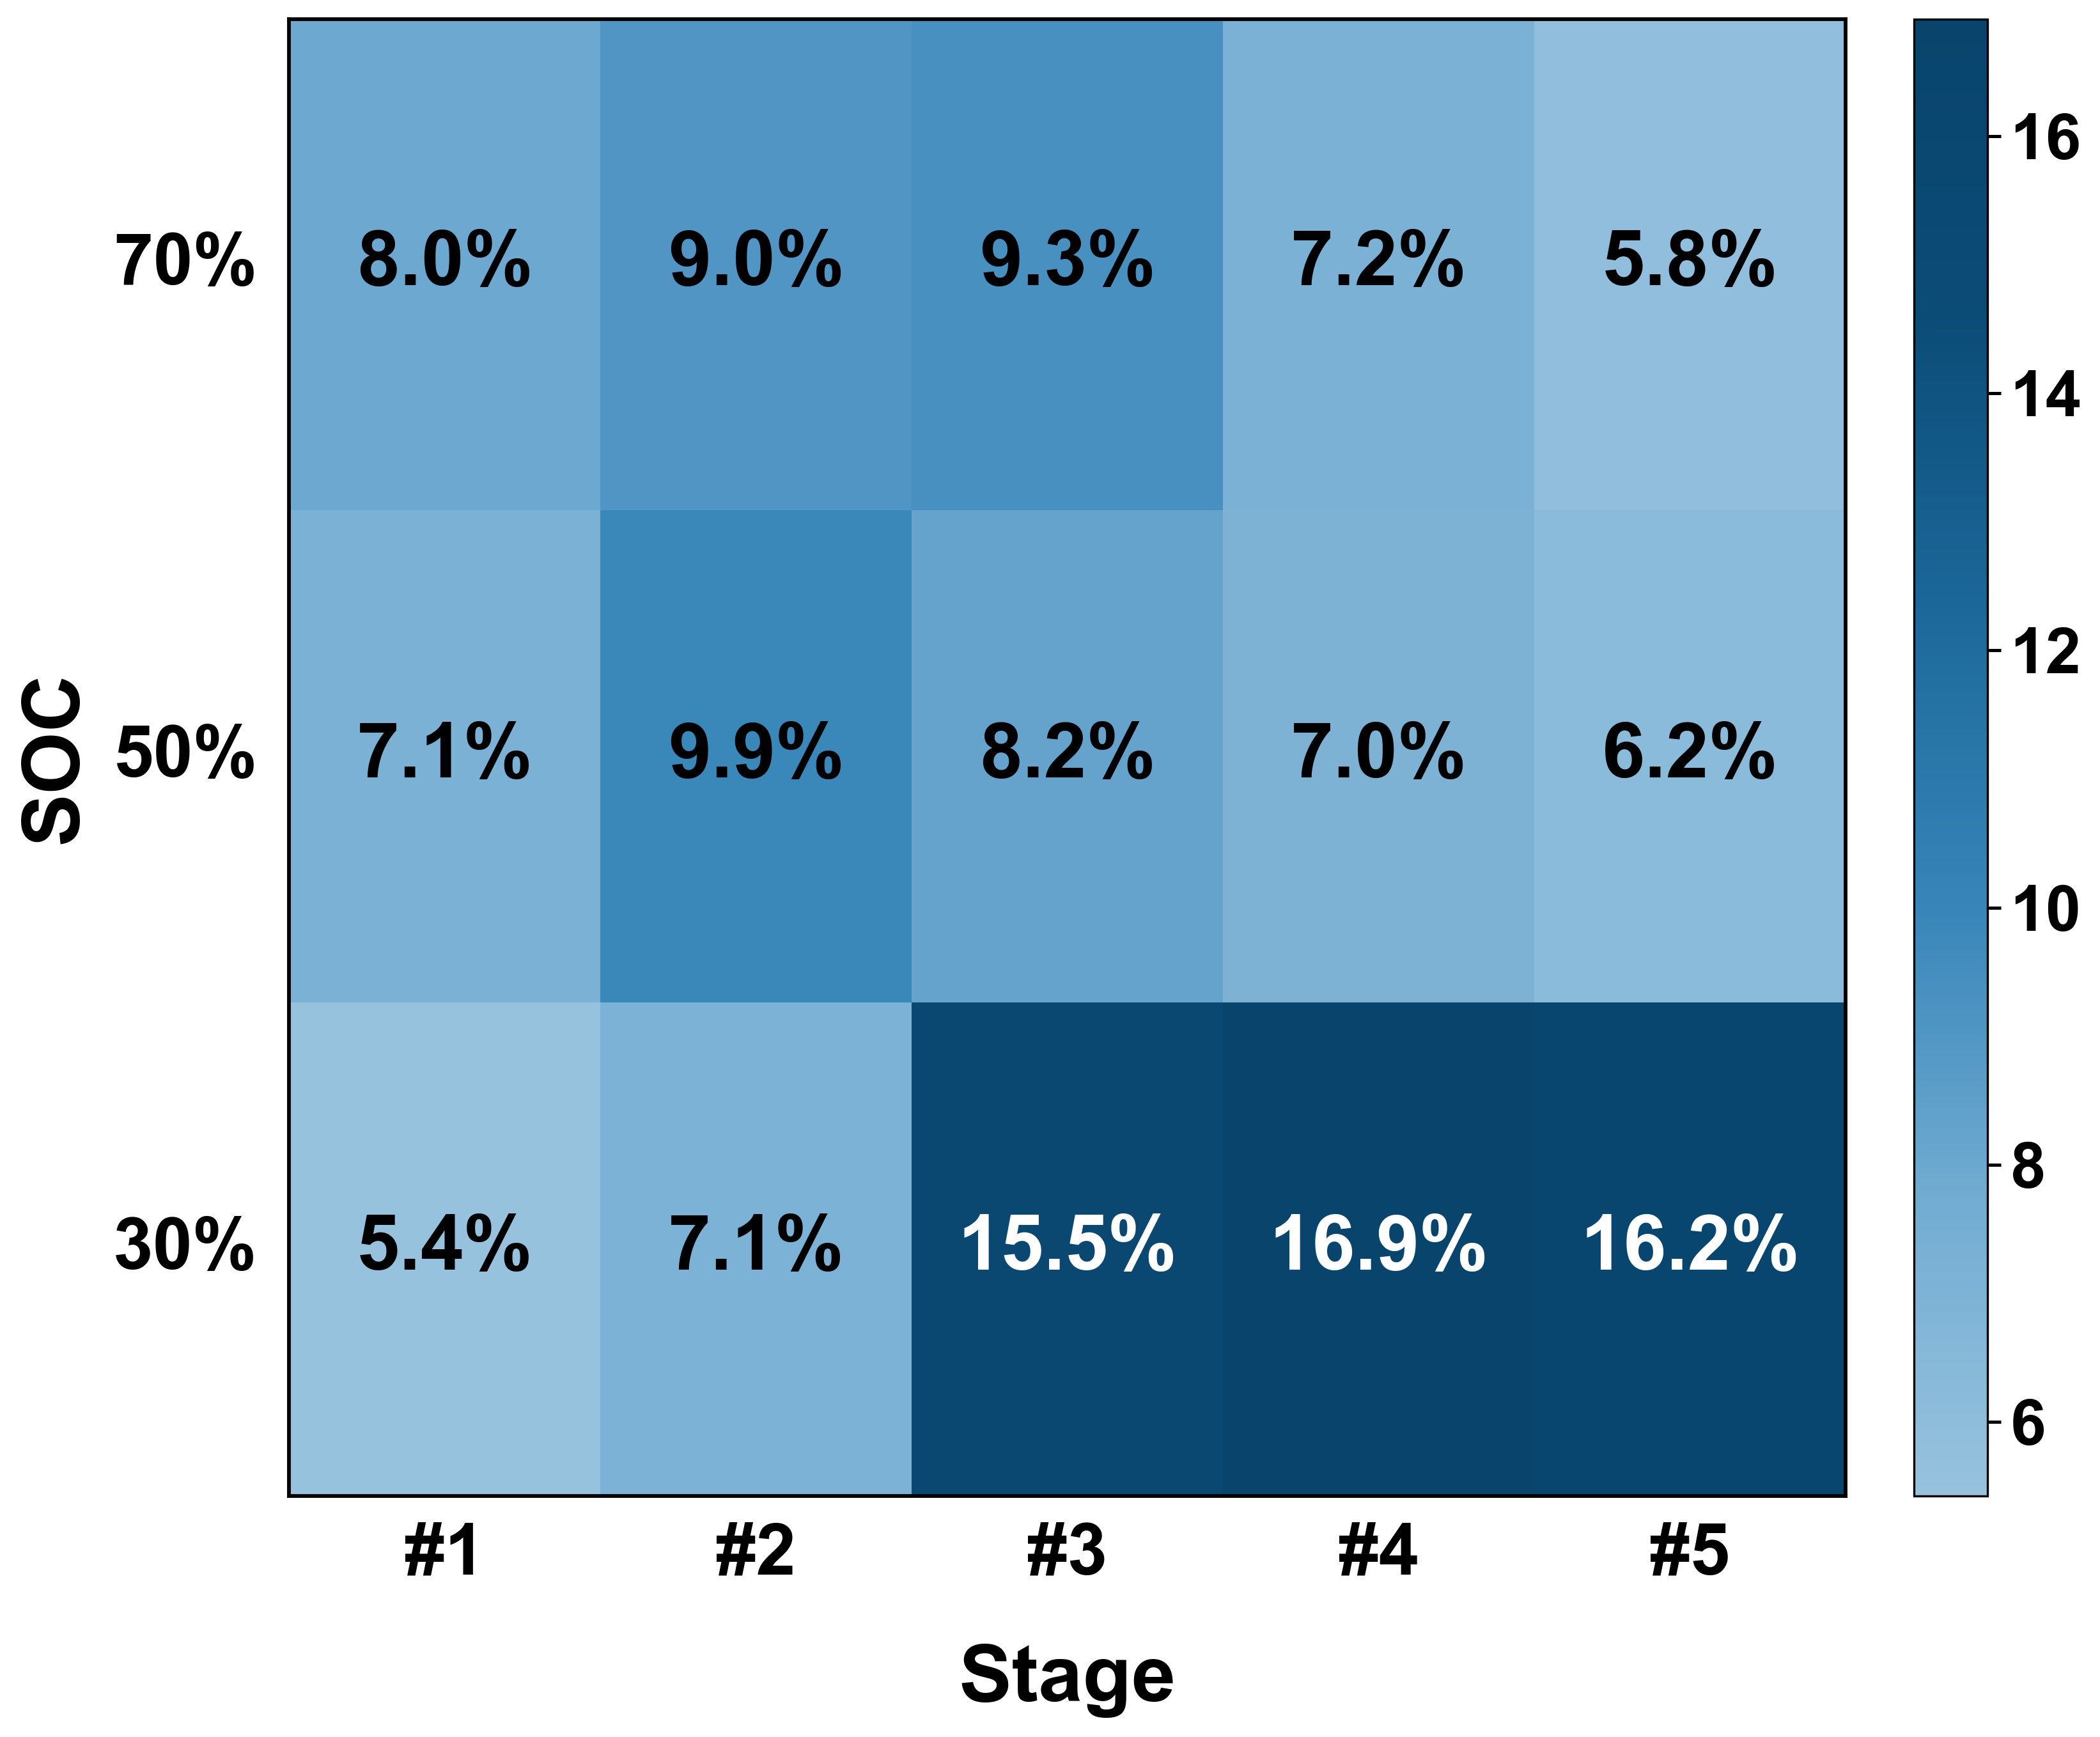

Saved: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\component_heat_ratio_heatmaps_sei.png


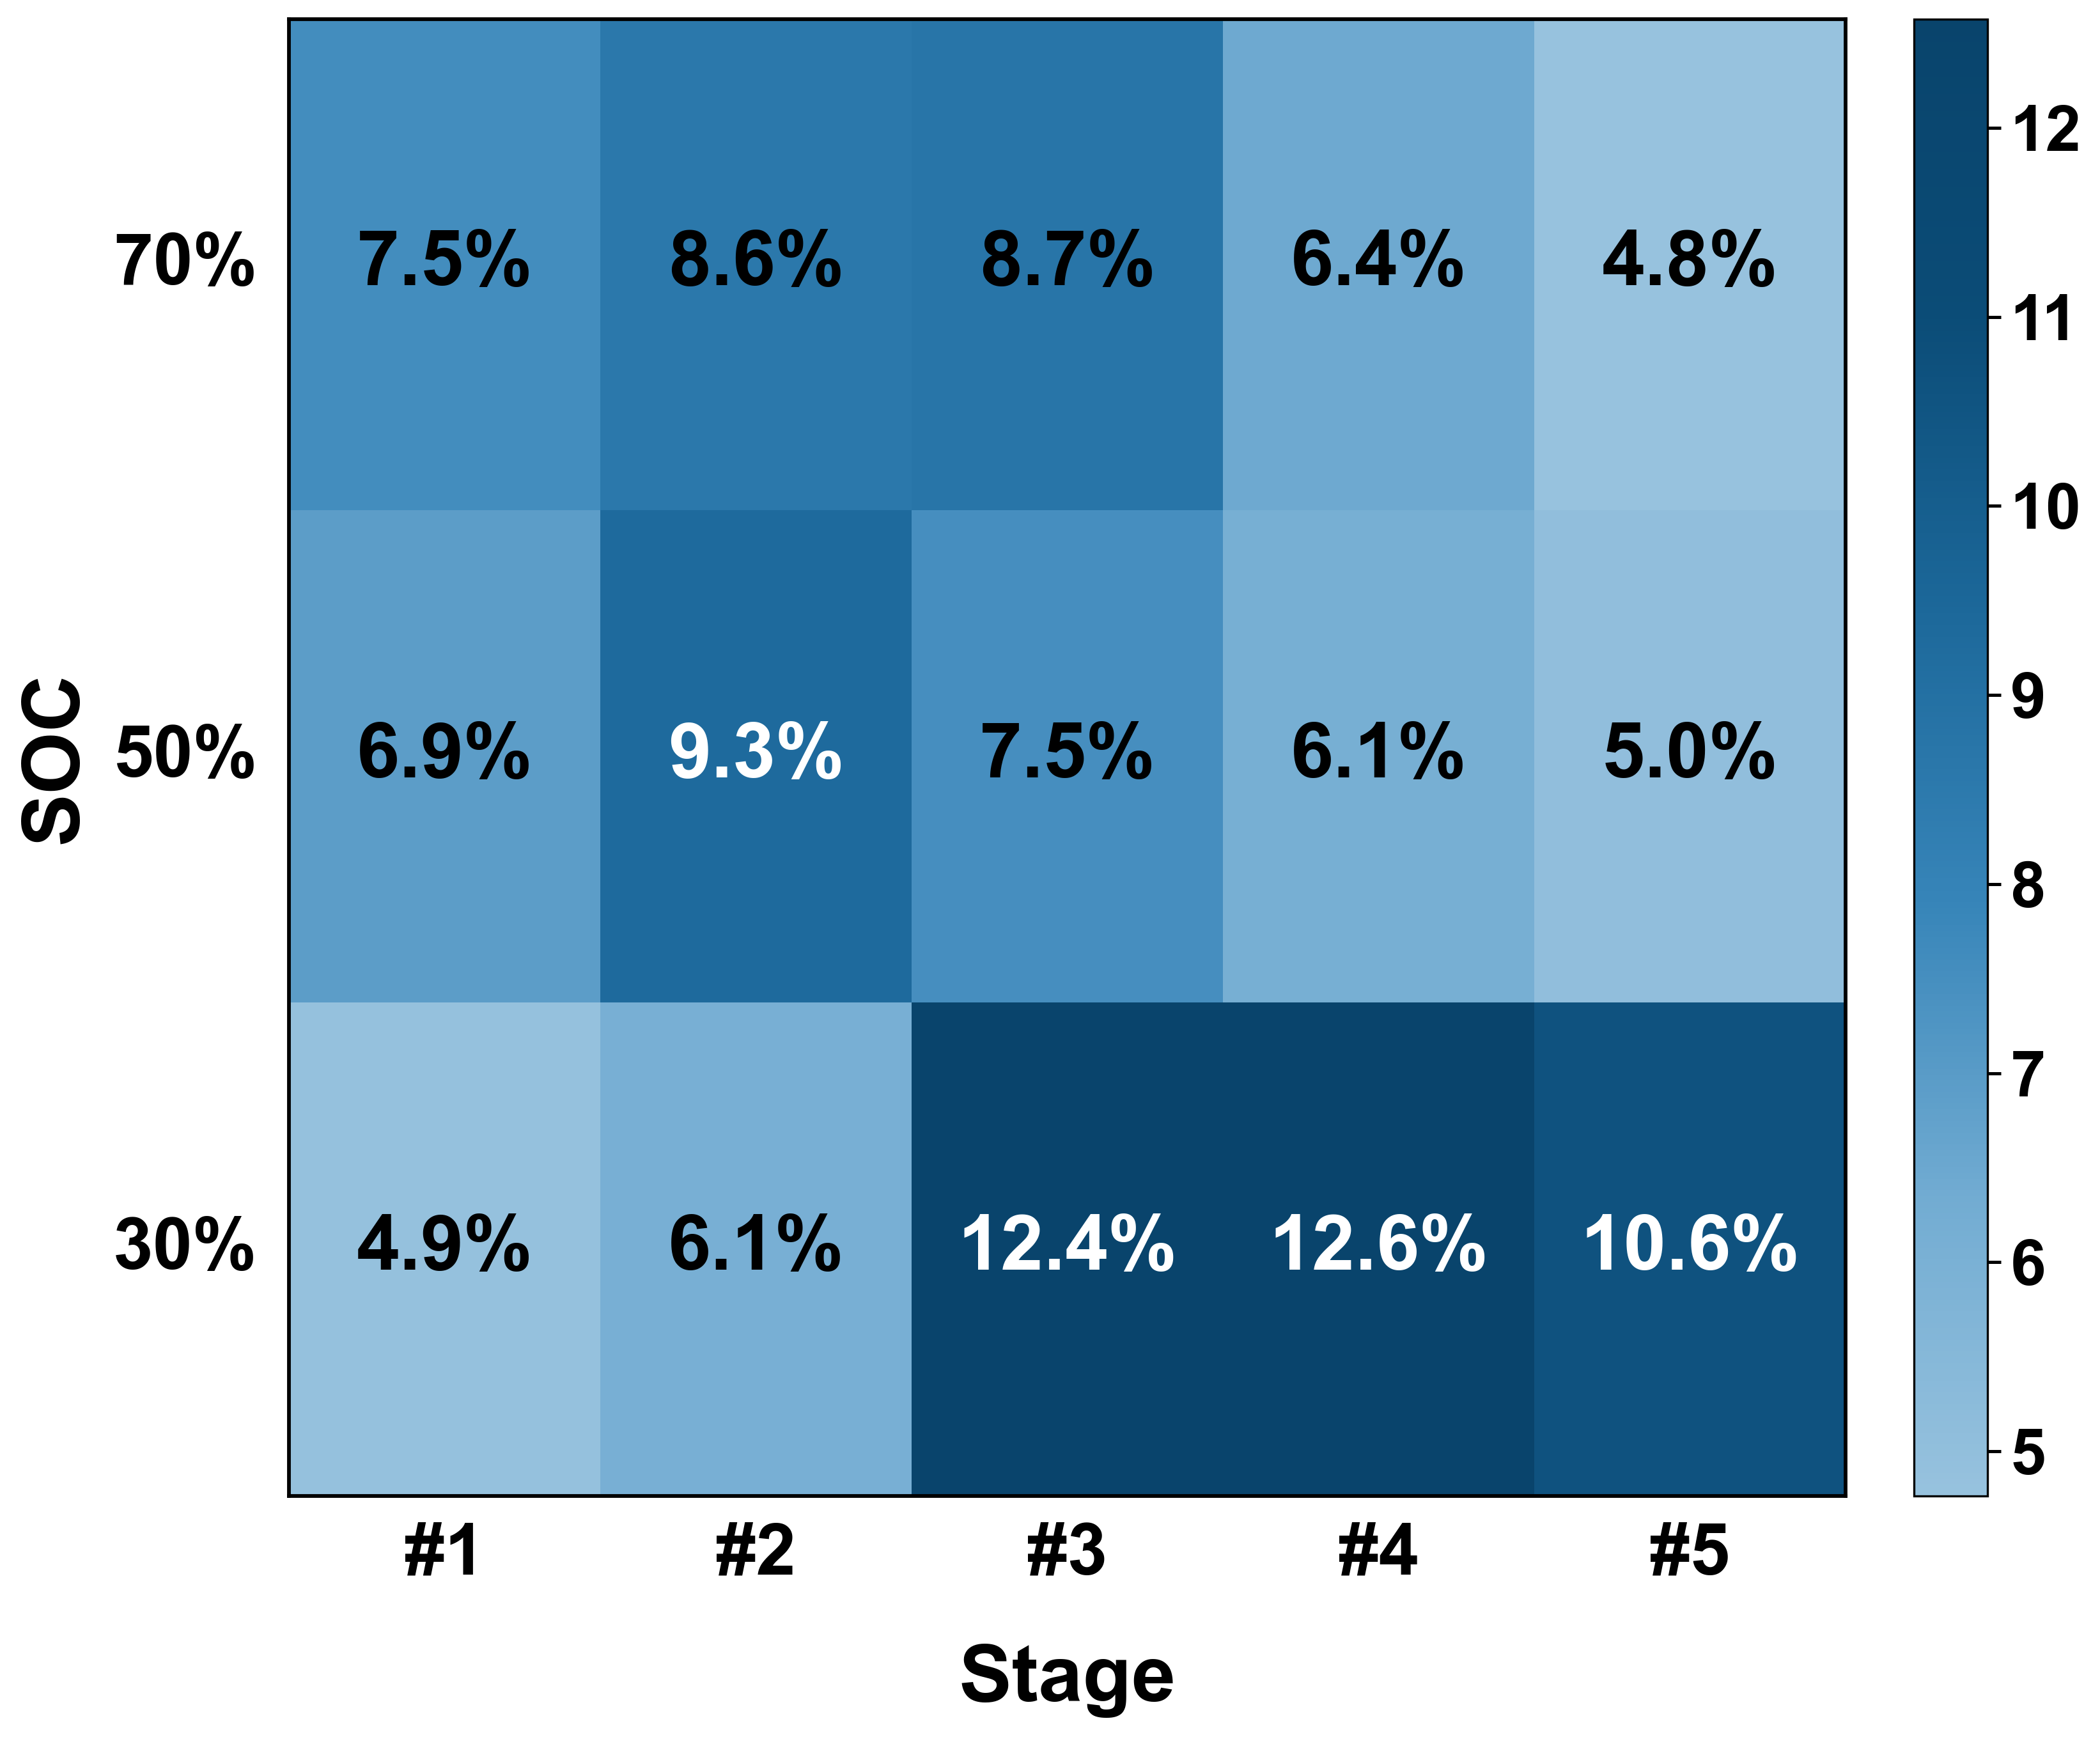

Saved: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\component_heat_ratio_heatmaps_dl.png


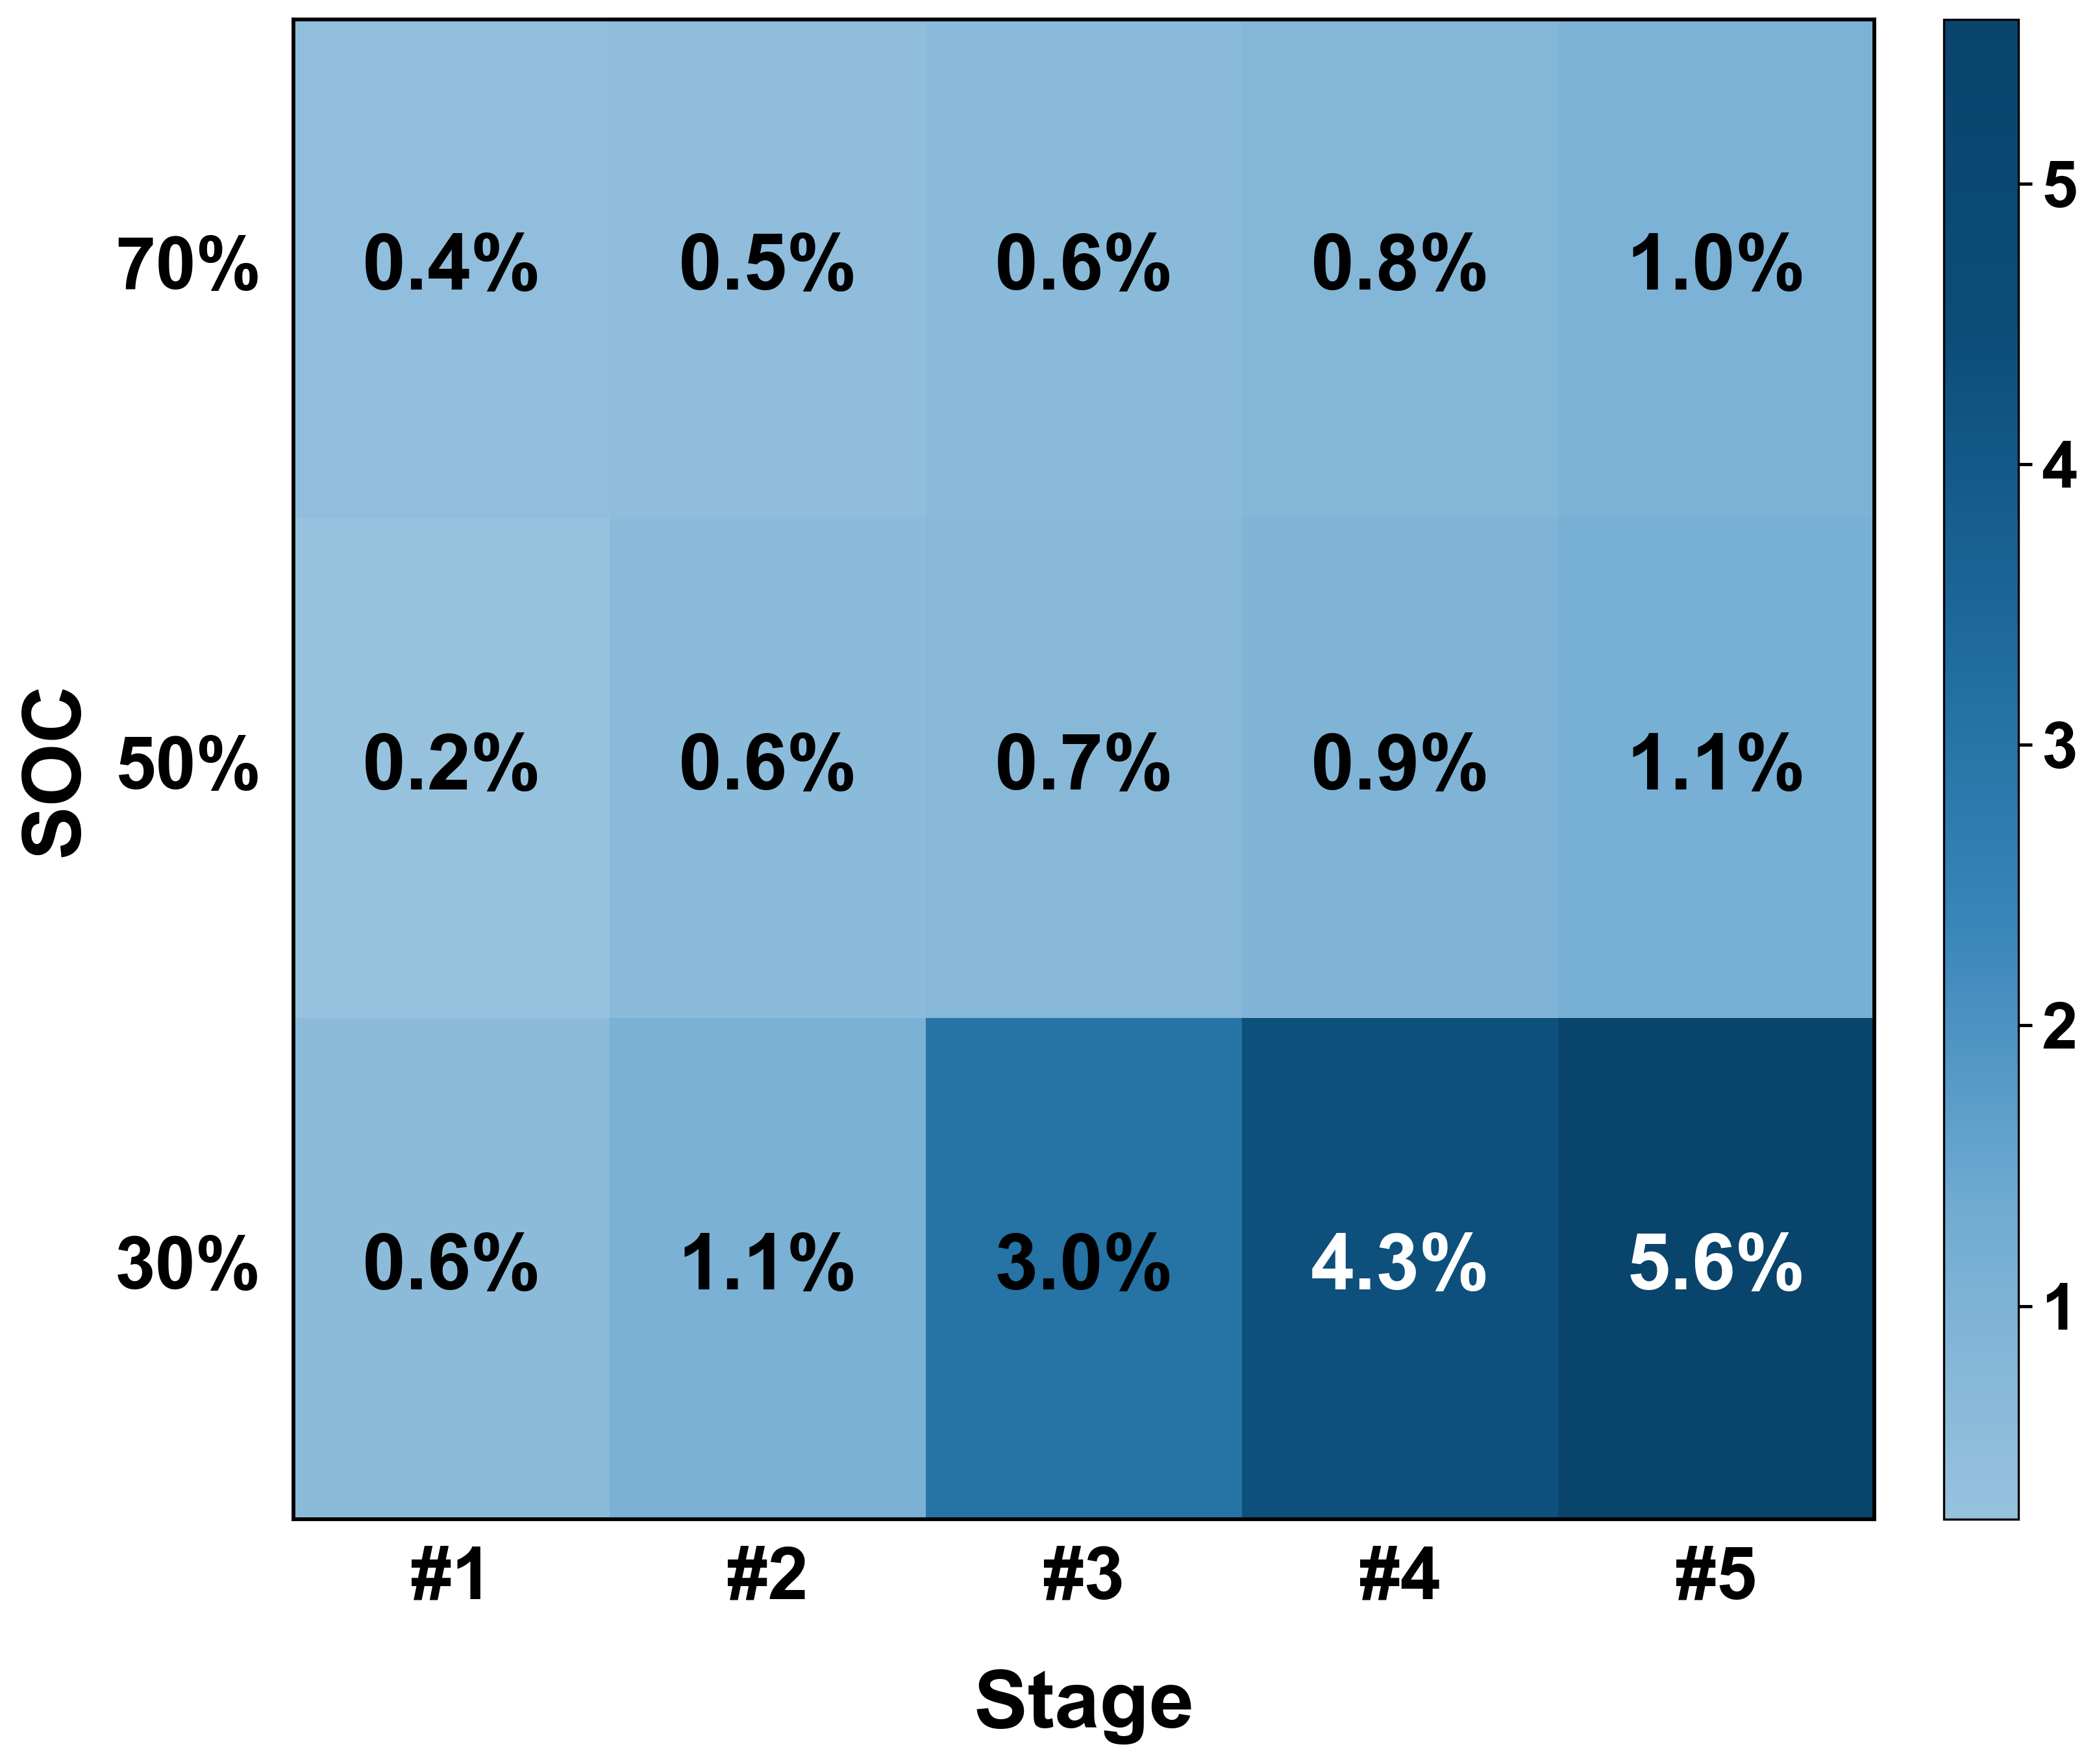

Saved: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\component_heat_ratio_heatmaps_total.png


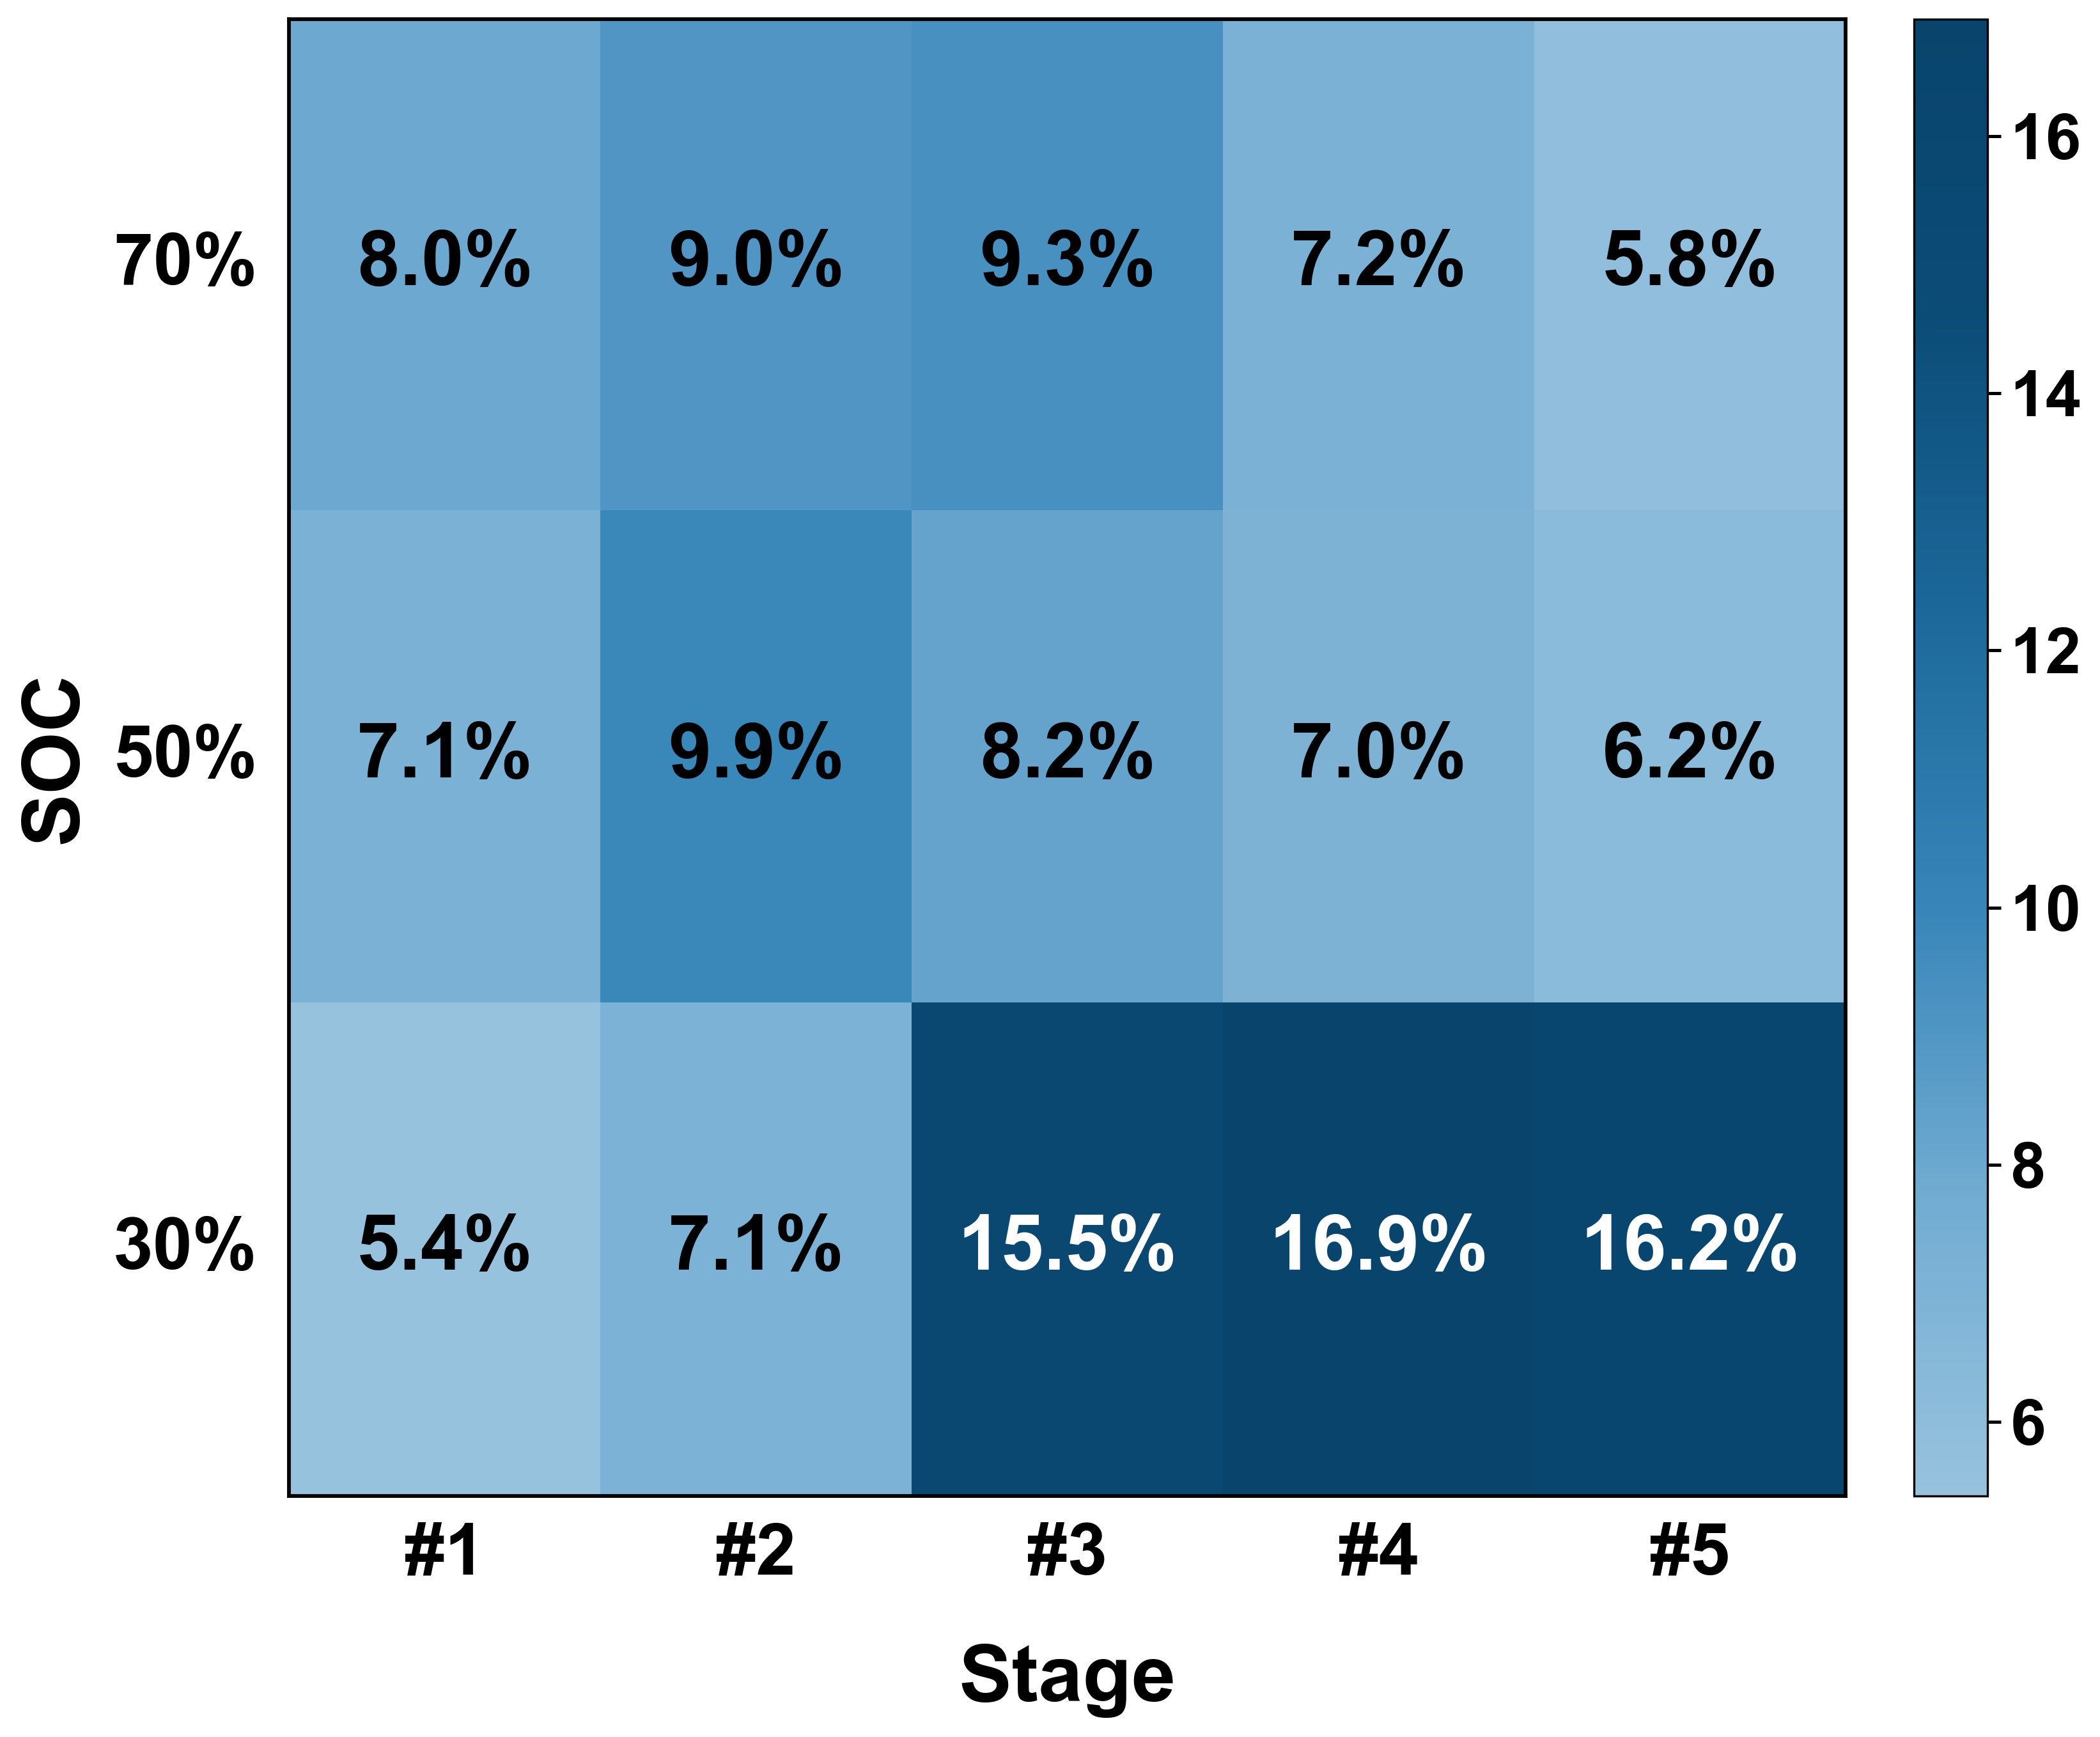

In [106]:
# -*- coding: utf-8 -*-
"""
Heatmap of non-ohmic heat / ohmic heat under optimal AC heating strategy

Definition:
    Ohmic heat      = 0.5 * Iac^2 * R0
    SEI heat        = 0.5 * Iac^2 * Re(Zsei-loop)
    DL/Rct heat     = 0.5 * Iac^2 * Re(Zdl-loop)
    Non-ohmic heat  = SEI heat + DL/Rct heat

Therefore:
    Non-ohmic / Ohmic =
    [Re(Zsei-loop) + Re(Zdl-loop)] / R0
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# =========================================================
# 0. USER SETTINGS
# =========================================================

# ---------- Display switches ----------
SHOW_TITLE = False
SHOW_AXIS_LABELS = True
SHOW_COLORBAR_LABEL = False
SHOW_CELL_TEXT = True


# ---------- Output ----------
OUTPUT_DIR = (
    r"C:\baidunetdiskdownload\各类文档"
    r"\2025-07-15-NC重大\出图\Figure_2"
)

OUTPUT_BASENAME = "non_ohmic_to_ohmic_heat_ratio_heatmap"

SAVE_PNG = True
SAVE_PDF = False
SAVE_CSV = True

DPI = 300
BBOX_INCHES = "tight"


# ---------- Figure ----------
# A rectangular figure is clearer for a 3 × 5 matrix.
FIGSIZE = (12, 10)

# Layout margins
FIG_LEFT = 0.16
FIG_RIGHT = 0.90
FIG_BOTTOM = 0.18
FIG_TOP = 0.95


# ---------- Font ----------
FONT_FAMILY = [
    "Arial",
    "DejaVu Sans",
    "Liberation Sans",
]

FONT_WEIGHT = "bold"

TITLE_FONTSIZE = 32
AXIS_LABEL_FONTSIZE = 30
TICK_FONTSIZE = 27
CELL_TEXT_FONTSIZE = 29

CBAR_LABEL_FONTSIZE = 26
CBAR_TICK_FONTSIZE = 24


# ---------- Tick style ----------
TICK_WIDTH = 1.2
TICK_LENGTH = 5

# Distance between tick labels and heatmap
X_TICK_PAD = 10
Y_TICK_PAD = 12

# Axis-title positions
# More negative Y_LABEL_X moves "SOC" farther left.
Y_LABEL_X = -0.15
X_LABEL_Y = -0.10


# ---------- Heatmap style ----------
CMAP = LinearSegmentedColormap.from_list(
    "cold_to_warm",
    [
        "#97C2DE",
        "#72ACD2",
        "#3785B9",
        "#1C689A",
        "#0B4C77",
        "#09446C",
    ]
)

CELL_TEXT_FORMAT = "{:.1f}%"

# Adaptive text contrast
CELL_TEXT_COLOR_LIGHT = "black"
CELL_TEXT_COLOR_DARK = "white"

# White text is used when normalized value exceeds this level.
CELL_TEXT_WHITE_THRESHOLD = 0.55

# Fixed colorbar range, when needed:
# COLOR_VMIN = 0
# COLOR_VMAX = 20
COLOR_VMIN = None
COLOR_VMAX = None


# ---------- Axis labels ----------
X_LABEL = "Stage"
Y_LABEL = "SOC"

TITLE = "Non-ohmic heat / Ohmic heat"


# ---------- Ratio mode ----------
# "total": [Re(Zsei) + Re(Zdl)] / R0
# "sei":   Re(Zsei) / R0
# "dl":    Re(Zdl) / R0
RATIO_MODE = "total"


# ---------- Component heatmaps ----------
PLOT_COMPONENT_HEATMAPS = True

COMPONENT_OUTPUT_BASENAME = "component_heat_ratio_heatmaps"


# =========================================================
# 1. HEATING STRATEGY TABLES
# =========================================================

# Internal labels used for calculation and dataframe matching.
# Do not replace these with #1–#5.
TEMP_STAGE_LABELS = [
    "Stage 1",
    "Stage 2",
    "Stage 3",
    "Stage 4",
    "Stage 5",
]

# Short labels used only for display.
STAGE_TICK_LABELS = [
    "#1",
    "#2",
    "#3",
    "#4",
    "#5",
]

# Representative temperature of each stage
TEMP_STAGE_MIDPOINTS_C = np.array(
    [-17.5, -12.5, -7.5, -2.5, 2.5],
    dtype=float,
)

# Top to bottom in the heatmap:
# 70%, 50%, 30%.
# Therefore, viewed from bottom to top:
# 30%, 50%, 70%.
SOC_LIST = [70, 50, 30]


AC_AMPLITUDE_A = {
    70: [6.51, 9.06, 9.57, 9.82, 10.01],
    50: [12.20, 17.21, 17.96, 18.47, 18.78],
    30: [15.09, 19.49, 20.00, 20.00, 20.00],
}


AC_FREQUENCY_HZ = {
    70: [3442, 2694, 2181, 2059, 1899],
    50: [5426, 2252, 2078, 1902, 1765],
    30: [4171, 2293, 730, 575, 548],
}


# =========================================================
# 2. PRSM COEFFICIENTS
# =========================================================
#
# Polynomial:
#     p(T) = c0 + c1*T + c2*T^2 + ...
#
# Units:
#     R0, Rsei, Rct: ohm
#     T: °C

COEF_R0 = {
    30: [0.031, -1.334e-4, 3.961e-6, 0.0],
    50: [0.027, -7.328e-5, 3.816e-6, 0.0],
    70: [0.029, -6.481e-5, -1.054e-5, -1.003e-6],
}


COEF_RSEI = {
    30: [0.014, -8.047e-4, 3.561e-5, 0.0],
    50: [0.019, -1.036e-3, 3.080e-5, -1.095e-6],
    70: [0.019, -1.201e-3, 2.772e-5, 0.0],
}


COEF_QSEI = {
    30: [0.297, 4.696e-3, 4.265e-4, 1.142e-5, 0.0],
    50: [0.273, -6.739e-3, 0.0, 0.0, 0.0],
    70: [0.382, -8.791e-4, -1.177e-3, -2.141e-4, -8.442e-6],
}


COEF_NSEI = {
    30: [0.761, 3.396e-3, -8.803e-5, -2.166e-6],
    50: [0.754, 7.074e-3, 0.0, 0.0],
    70: [0.716, 7.166e-3, -2.671e-5, -1.068e-5],
}


COEF_RCT = {
    30: [0.211, -0.019, 9.128e-4, -4.276e-5],
    50: [0.258, -0.025, 1.413e-3, 0.0],
    70: [0.187, -0.017, 8.381e-4, -4.318e-5],
}


COEF_QDL = {
    30: [0.821, 0.036, 6.924e-4],
    50: [0.542, 0.019, 3.416e-4],
    70: [0.577, 0.019, 2.878e-4],
}


COEF_NDL = {
    30: [0.718, -7.151e-3, -1.144e-4, 0.0],
    50: [0.812, -4.440e-3, -2.115e-5, 2.048e-6],
    70: [0.806, -4.491e-3, 1.028e-4, 1.174e-5],
}


# =========================================================
# 3. CALCULATION FUNCTIONS
# =========================================================

def poly_eval(coefs, temperature_c):
    """
    Evaluate:
        p(T) = c0 + c1*T + c2*T^2 + ...
    """
    return sum(
        coefficient * temperature_c ** order
        for order, coefficient in enumerate(coefs)
    )


def z_r_parallel_cpe(resistance, q_value, n_value, frequency_hz):
    """
    Impedance of R || CPE:

        Z = R / [1 + R*Q*(j*w)^n]
    """
    omega = 2.0 * np.pi * np.asarray(
        frequency_hz,
        dtype=float,
    )

    return resistance / (
        1.0
        + resistance
        * q_value
        * (1j * omega) ** n_value
    )


def calc_impedance_components(
    soc,
    temperature_c,
    frequency_hz,
):
    """
    Return R0, Re(Zsei), Re(Zdl), and total resistance.
    """

    r0 = poly_eval(
        COEF_R0[soc],
        temperature_c,
    )

    r_sei = poly_eval(
        COEF_RSEI[soc],
        temperature_c,
    )

    q_sei = poly_eval(
        COEF_QSEI[soc],
        temperature_c,
    )

    n_sei = poly_eval(
        COEF_NSEI[soc],
        temperature_c,
    )

    r_ct = poly_eval(
        COEF_RCT[soc],
        temperature_c,
    )

    q_dl = poly_eval(
        COEF_QDL[soc],
        temperature_c,
    )

    n_dl = poly_eval(
        COEF_NDL[soc],
        temperature_c,
    )

    z_sei = z_r_parallel_cpe(
        r_sei,
        q_sei,
        n_sei,
        frequency_hz,
    )

    z_dl = z_r_parallel_cpe(
        r_ct,
        q_dl,
        n_dl,
        frequency_hz,
    )

    z_sei_real = np.real(z_sei)
    z_dl_real = np.real(z_dl)

    z_non_ohmic_real = (
        z_sei_real + z_dl_real
    )

    z_total_real = (
        r0 + z_non_ohmic_real
    )

    return {
        "R0": float(r0),
        "Rsei": float(r_sei),
        "Qsei": float(q_sei),
        "nsei": float(n_sei),
        "Rct": float(r_ct),
        "Qdl": float(q_dl),
        "ndl": float(n_dl),
        "Zsei_re": float(z_sei_real),
        "Zdl_re": float(z_dl_real),
        "Z_non_ohmic_re": float(z_non_ohmic_real),
        "Z_total_re": float(z_total_real),
    }


def calc_stage_values(
    soc,
    temperature_c,
    frequency_hz,
    iac_amplitude,
):
    """
    Calculate impedance ratios and heat components.

    For:
        i = Iac * sin(wt)

    Average heat:
        P = 0.5 * Iac^2 * Re(Z)
    """

    components = calc_impedance_components(
        soc=soc,
        temperature_c=temperature_c,
        frequency_hz=frequency_hz,
    )

    r0 = components["R0"]
    z_sei_real = components["Zsei_re"]
    z_dl_real = components["Zdl_re"]
    z_non_ohmic_real = components["Z_non_ohmic_re"]

    p_ohmic = (
        0.5
        * iac_amplitude ** 2
        * r0
    )

    p_sei = (
        0.5
        * iac_amplitude ** 2
        * z_sei_real
    )

    p_dl = (
        0.5
        * iac_amplitude ** 2
        * z_dl_real
    )

    p_non_ohmic = p_sei + p_dl
    p_total = p_ohmic + p_non_ohmic

    return {
        **components,
        "Iac_A": iac_amplitude,
        "freq_Hz": frequency_hz,
        "temp_C": temperature_c,
        "P_ohmic_W": p_ohmic,
        "P_sei_W": p_sei,
        "P_dl_W": p_dl,
        "P_non_ohmic_W": p_non_ohmic,
        "P_total_W": p_total,

        "ratio_sei_to_ohmic_percent":
            100.0 * z_sei_real / r0,

        "ratio_dl_to_ohmic_percent":
            100.0 * z_dl_real / r0,

        "ratio_non_ohmic_to_ohmic_percent":
            100.0 * z_non_ohmic_real / r0,

        "ratio_non_ohmic_to_total_percent":
            100.0
            * z_non_ohmic_real
            / (r0 + z_non_ohmic_real),
    }


def build_result_table():
    """
    Build the complete result dataframe.
    """

    rows = []

    for soc in SOC_LIST:
        for stage_label, temperature_c, iac, frequency_hz in zip(
            TEMP_STAGE_LABELS,
            TEMP_STAGE_MIDPOINTS_C,
            AC_AMPLITUDE_A[soc],
            AC_FREQUENCY_HZ[soc],
        ):
            values = calc_stage_values(
                soc=soc,
                temperature_c=temperature_c,
                frequency_hz=frequency_hz,
                iac_amplitude=iac,
            )

            values["SOC"] = soc
            values["stage"] = stage_label

            rows.append(values)

    return pd.DataFrame(rows)


def matrix_from_df(dataframe, value_column):
    """
    Convert dataframe values into a 3 × 5 matrix.
    """

    matrix = np.zeros(
        (
            len(SOC_LIST),
            len(TEMP_STAGE_LABELS),
        )
    )

    for row_index, soc in enumerate(SOC_LIST):
        for column_index, stage in enumerate(TEMP_STAGE_LABELS):
            selected = dataframe[
                (dataframe["SOC"] == soc)
                & (dataframe["stage"] == stage)
            ]

            if selected.empty:
                raise ValueError(
                    f"No data found for SOC={soc}, "
                    f"stage={stage}."
                )

            matrix[row_index, column_index] = (
                selected[value_column].iloc[0]
            )

    return matrix


# =========================================================
# 4. HEATMAP FUNCTION
# =========================================================

def plot_heatmap(
    matrix,
    title,
    colorbar_label,
    output_path=None,
):
    """
    Plot one heatmap with:
        y title: SOC
        y ticks: 70%, 50%, 30%
        x ticks: #1–#5
        x title: Stage
    """

    plt.rcParams["font.sans-serif"] = FONT_FAMILY
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams["axes.unicode_minus"] = False

    fig, ax = plt.subplots(
        figsize=FIGSIZE,
        dpi=DPI,
    )

    image = ax.imshow(
        matrix,
        aspect="auto",
        cmap=CMAP,
        vmin=COLOR_VMIN,
        vmax=COLOR_VMAX,
    )

    # -----------------------------------------------------
    # Tick positions
    # -----------------------------------------------------
    ax.set_xticks(
        np.arange(
            len(TEMP_STAGE_LABELS)
        )
    )

    ax.set_yticks(
        np.arange(
            len(SOC_LIST)
        )
    )

    # -----------------------------------------------------
    # Short tick labels
    # -----------------------------------------------------
    ax.set_xticklabels(
        STAGE_TICK_LABELS,
        fontsize=TICK_FONTSIZE,
        rotation=0,
        ha="center",
    )

    ax.set_yticklabels(
        [
            f"{soc}%"
            for soc in SOC_LIST
        ],
        fontsize=TICK_FONTSIZE,
        rotation=0,
        va="center",
    )

    # Remove visible tick marks and add spacing.
    ax.tick_params(
        axis="x",
        which="major",
        pad=X_TICK_PAD,
        length=0,
        width=TICK_WIDTH,
    )

    ax.tick_params(
        axis="y",
        which="major",
        pad=Y_TICK_PAD,
        length=0,
        width=TICK_WIDTH,
    )

    for tick_label in (
        ax.get_xticklabels()
        + ax.get_yticklabels()
    ):
        tick_label.set_fontweight(
            FONT_WEIGHT
        )

    # -----------------------------------------------------
    # Axis titles
    # -----------------------------------------------------
    if SHOW_AXIS_LABELS:
        ax.set_xlabel(
            X_LABEL,
            fontsize=AXIS_LABEL_FONTSIZE,
            fontweight=FONT_WEIGHT,
            labelpad=18,
        )

        ax.set_ylabel(
            Y_LABEL,
            fontsize=AXIS_LABEL_FONTSIZE,
            fontweight=FONT_WEIGHT,
            rotation=90,
            labelpad=28,
            va="center",
        )

        # Fine adjustment of label positions
        ax.yaxis.set_label_coords(
            Y_LABEL_X,
            0.5,
        )

        ax.xaxis.set_label_coords(
            0.5,
            X_LABEL_Y,
        )

    # -----------------------------------------------------
    # Optional title
    # -----------------------------------------------------
    if SHOW_TITLE:
        ax.set_title(
            title,
            fontsize=TITLE_FONTSIZE,
            fontweight=FONT_WEIGHT,
            pad=12,
        )

    # -----------------------------------------------------
    # Cell text
    # -----------------------------------------------------
    if SHOW_CELL_TEXT:
        for row_index in range(
            matrix.shape[0]
        ):
            for column_index in range(
                matrix.shape[1]
            ):
                normalized_value = image.norm(
                    matrix[
                        row_index,
                        column_index
                    ]
                )

                if (
                    normalized_value
                    >= CELL_TEXT_WHITE_THRESHOLD
                ):
                    text_color = (
                        CELL_TEXT_COLOR_DARK
                    )
                else:
                    text_color = (
                        CELL_TEXT_COLOR_LIGHT
                    )

                ax.text(
                    column_index,
                    row_index,
                    CELL_TEXT_FORMAT.format(
                        matrix[
                            row_index,
                            column_index
                        ]
                    ),
                    ha="center",
                    va="center",
                    fontsize=CELL_TEXT_FONTSIZE,
                    fontweight=FONT_WEIGHT,
                    color=text_color,
                )

    # -----------------------------------------------------
    # Heatmap border
    # -----------------------------------------------------
    for spine in ax.spines.values():
        spine.set_linewidth(1.4)

    # -----------------------------------------------------
    # Colorbar
    # -----------------------------------------------------
    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04,
    )

    if SHOW_COLORBAR_LABEL:
        colorbar.ax.set_ylabel(
            colorbar_label,
            fontsize=CBAR_LABEL_FONTSIZE,
            fontweight=FONT_WEIGHT,
        )

    colorbar.ax.tick_params(
        labelsize=CBAR_TICK_FONTSIZE,
        width=TICK_WIDTH,
        length=TICK_LENGTH,
    )

    for tick_label in colorbar.ax.get_yticklabels():
        tick_label.set_fontweight(
            FONT_WEIGHT
        )

    # -----------------------------------------------------
    # Figure layout
    # -----------------------------------------------------
    fig.subplots_adjust(
        left=FIG_LEFT,
        right=FIG_RIGHT,
        bottom=FIG_BOTTOM,
        top=FIG_TOP,
    )

    # -----------------------------------------------------
    # Save
    # -----------------------------------------------------
    if output_path is not None:
        fig.savefig(
            output_path,
            dpi=DPI,
            bbox_inches=BBOX_INCHES,
        )

        print(
            f"Saved: {output_path}"
        )

    plt.show()

    return fig, ax


# =========================================================
# 5. MAIN CALCULATION
# =========================================================

output_directory = Path(
    OUTPUT_DIR
)

output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

result_dataframe = build_result_table()


# ---------- Select main heatmap value ----------
if RATIO_MODE == "total":
    main_column = (
        "ratio_non_ohmic_to_ohmic_percent"
    )

    main_title = (
        "Non-ohmic heat / Ohmic heat"
    )

elif RATIO_MODE == "sei":
    main_column = (
        "ratio_sei_to_ohmic_percent"
    )

    main_title = (
        "SEI-loop heat / Ohmic heat"
    )

elif RATIO_MODE == "dl":
    main_column = (
        "ratio_dl_to_ohmic_percent"
    )

    main_title = (
        "DL-loop heat / Ohmic heat"
    )

else:
    raise ValueError(
        "RATIO_MODE must be "
        "'total', 'sei', or 'dl'."
    )


main_matrix = matrix_from_df(
    result_dataframe,
    main_column,
)


print("\nMain ratio matrix, unit: %")

main_matrix_dataframe = pd.DataFrame(
    main_matrix,
    index=[
        f"SOC {soc}%"
        for soc in SOC_LIST
    ],
    columns=TEMP_STAGE_LABELS,
)

print(
    main_matrix_dataframe.round(3)
)


# ---------- Save detailed CSV ----------
if SAVE_CSV:
    csv_path = (
        output_directory
        / f"{OUTPUT_BASENAME}_details.csv"
    )

    result_dataframe.to_csv(
        csv_path,
        index=False,
        encoding="utf-8-sig",
    )

    print(
        f"Saved CSV: {csv_path}"
    )


# =========================================================
# 6. PLOT MAIN HEATMAP
# =========================================================

main_png_path = (
    output_directory
    / f"{OUTPUT_BASENAME}_{RATIO_MODE}.png"
)

main_pdf_path = (
    output_directory
    / f"{OUTPUT_BASENAME}_{RATIO_MODE}.pdf"
)


main_figure, main_axis = plot_heatmap(
    main_matrix,
    title=main_title,
    colorbar_label="Ratio (%)",
    output_path=(
        main_png_path
        if SAVE_PNG
        else None
    ),
)


if SAVE_PDF:
    main_figure.savefig(
        main_pdf_path,
        bbox_inches=BBOX_INCHES,
    )

    print(
        f"Saved PDF: {main_pdf_path}"
    )


# =========================================================
# 7. OPTIONAL COMPONENT HEATMAPS
# =========================================================

if PLOT_COMPONENT_HEATMAPS:
    component_items = [
        (
            "ratio_sei_to_ohmic_percent",
            "SEI-loop heat / Ohmic heat",
            f"{COMPONENT_OUTPUT_BASENAME}_sei.png",
        ),
        (
            "ratio_dl_to_ohmic_percent",
            "DL-loop heat / Ohmic heat",
            f"{COMPONENT_OUTPUT_BASENAME}_dl.png",
        ),
        (
            "ratio_non_ohmic_to_ohmic_percent",
            "SEI + DL heat / Ohmic heat",
            f"{COMPONENT_OUTPUT_BASENAME}_total.png",
        ),
    ]

    for value_column, title, filename in component_items:
        component_matrix = matrix_from_df(
            result_dataframe,
            value_column,
        )

        component_output_path = (
            output_directory / filename
            if SAVE_PNG
            else None
        )

        plot_heatmap(
            component_matrix,
            title=title,
            colorbar_label="Ratio (%)",
            output_path=component_output_path,
        )


Aging battery at SOC = 50%
Non-ohmic heat / Ohmic heat, unit: %
         Stage 1  Stage 2  Stage 3  Stage 4  Stage 5
SOH 95%   13.069    9.803    7.067    5.191    3.830
SOH 90%    8.955    6.196    5.505    5.068    4.441
SOH 85%    7.997    6.415    5.458    4.632    3.808
SOH 80%    8.522    6.924    5.923    4.913    3.866

Saved CSV:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\aging_non_ohmic_to_ohmic_heat_ratio_heatmap_details.csv
Saved PNG:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\aging_non_ohmic_to_ohmic_heat_ratio_heatmap.png


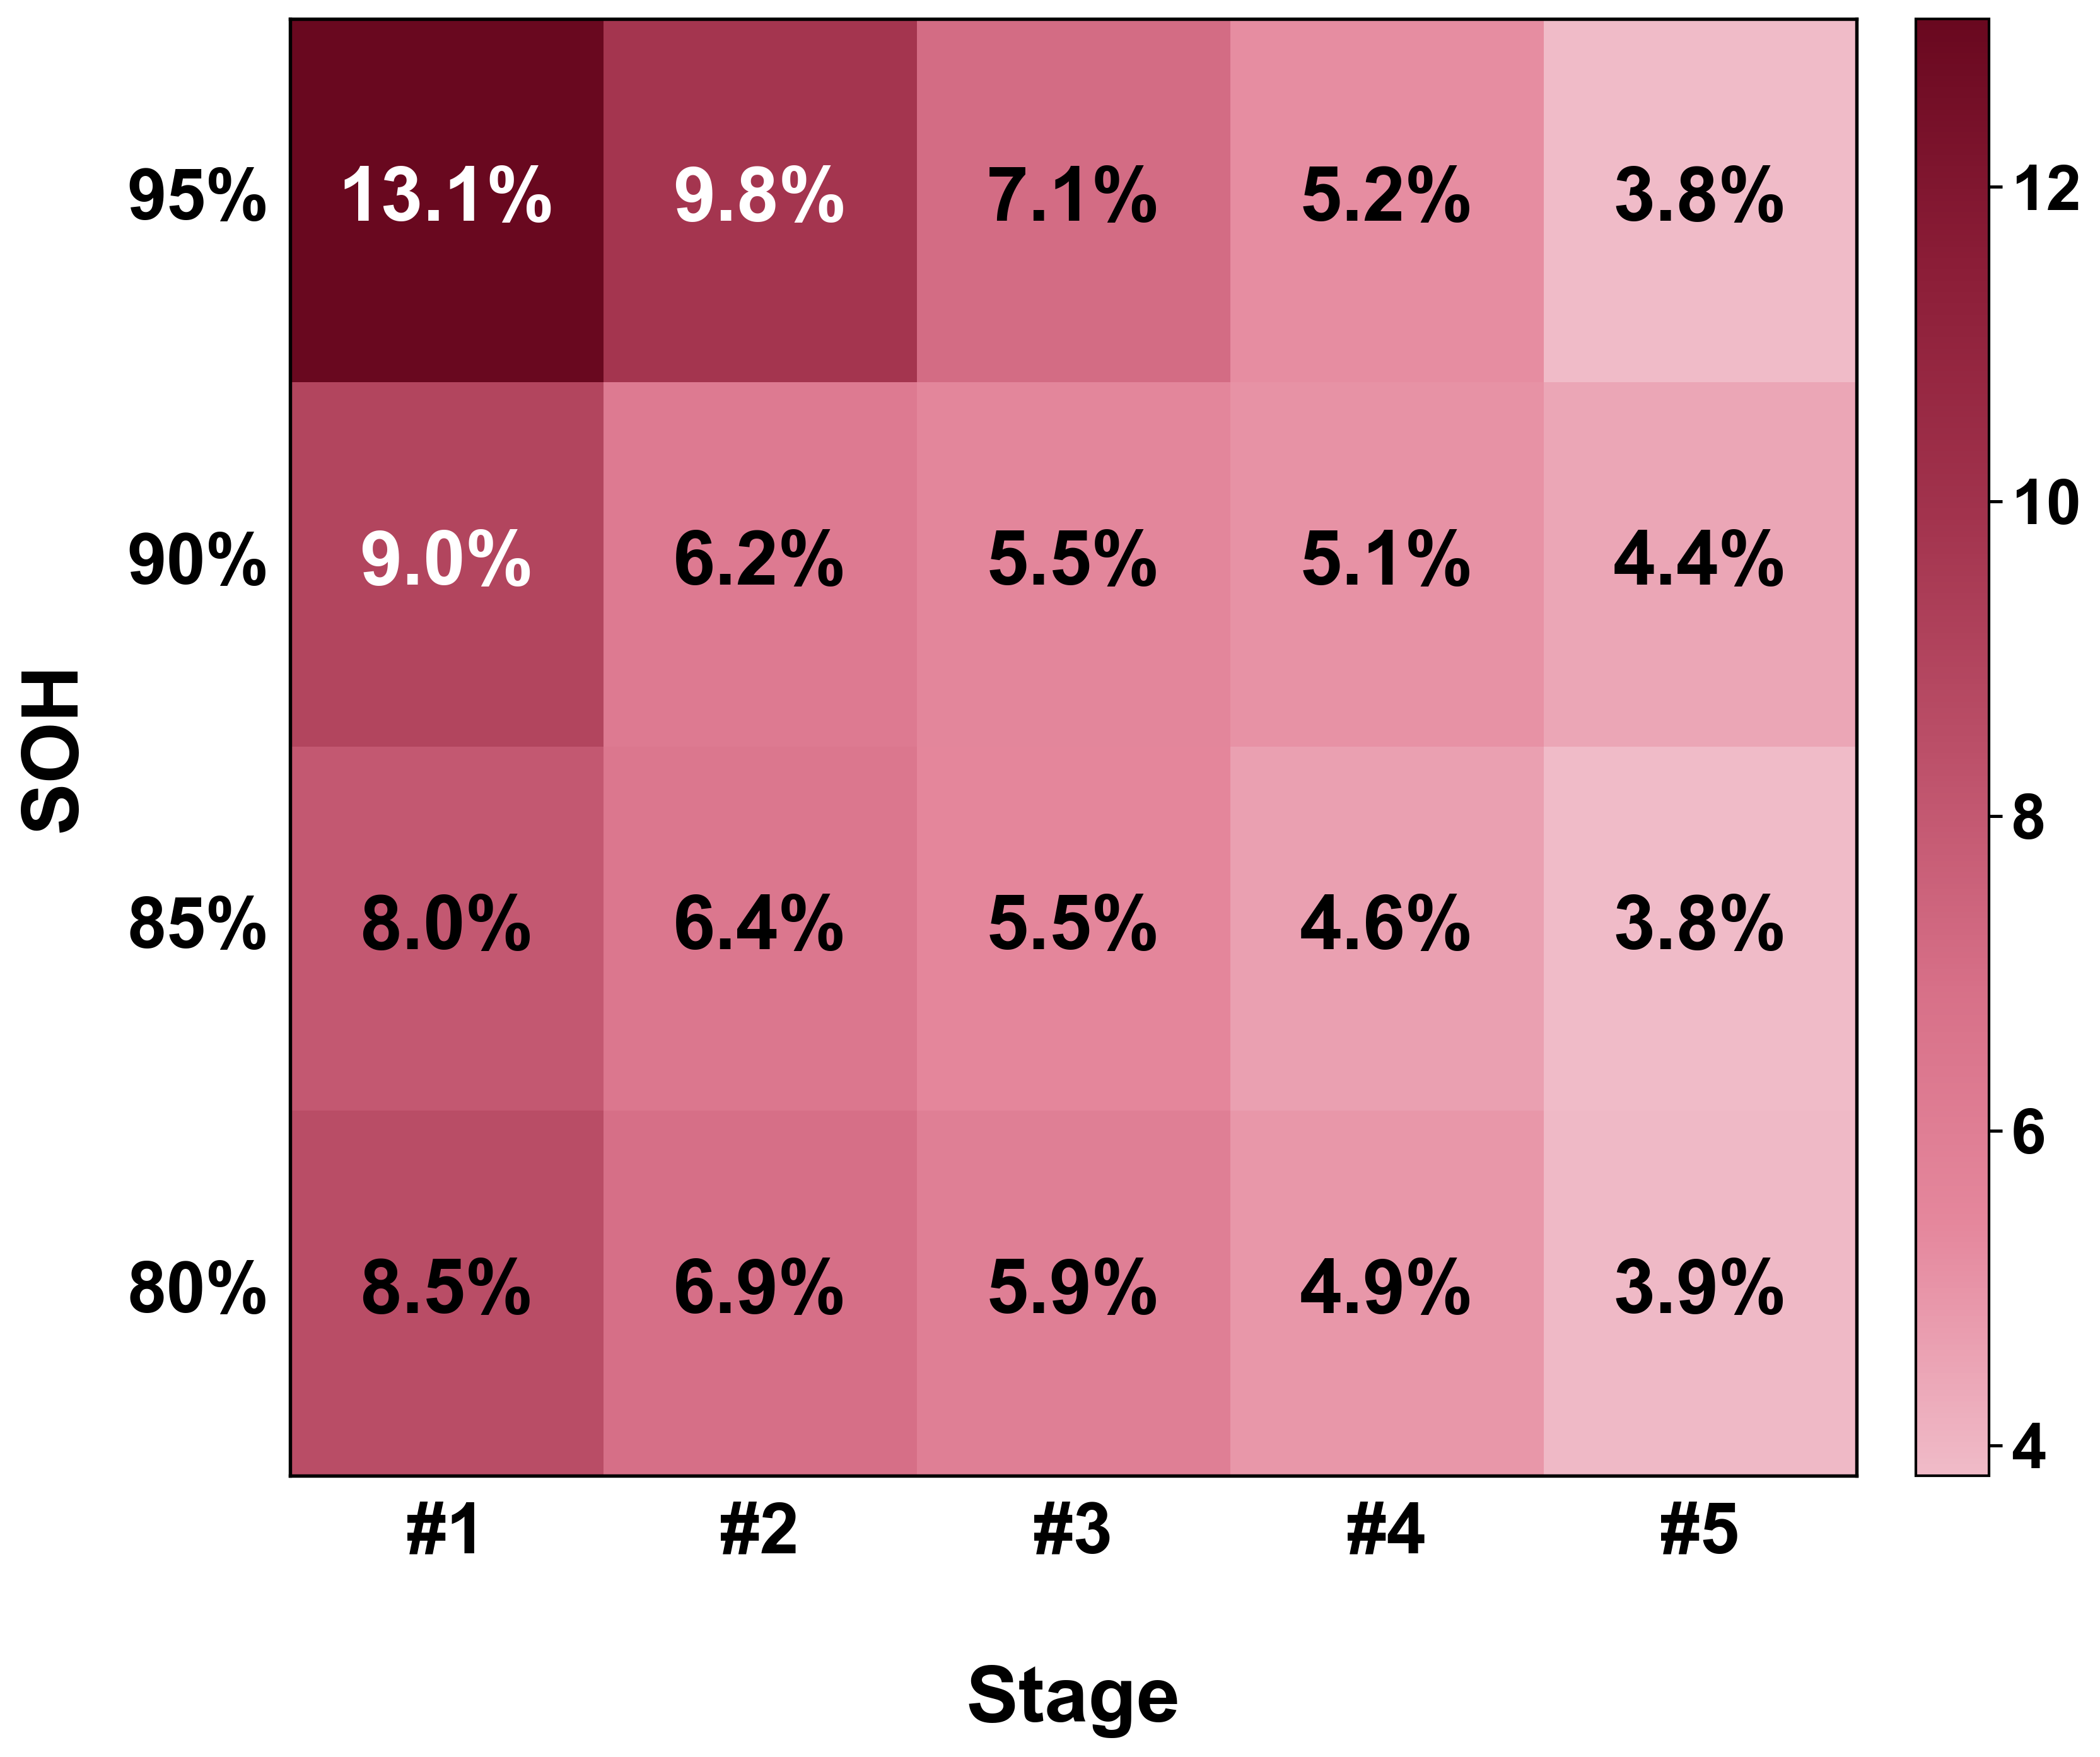

In [111]:
# -*- coding: utf-8 -*-
"""
Heatmap of non-ohmic heat / ohmic heat under
aging-aware optimal AC heating strategy.

Fixed SOC:
    SOC = 50%

Rows:
    SOH = 95%, 90%, 85%, 80%

Columns:
    Heating stages #1–#5

Definition:
    Ohmic heat      = 0.5 * Iac^2 * R0
    SEI heat        = 0.5 * Iac^2 * Re(Zsei-loop)
    DL/Rct heat     = 0.5 * Iac^2 * Re(Zdl-loop)
    Non-ohmic heat  = SEI heat + DL/Rct heat

Therefore:
    Non-ohmic / Ohmic =
    [Re(Zsei-loop) + Re(Zdl-loop)] / R0
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# =========================================================
# 0. USER SETTINGS
# =========================================================

# ---------------------------------------------------------
# Output
# ---------------------------------------------------------
OUTPUT_DIR = (
    r"C:\baidunetdiskdownload\各类文档"
    r"\2025-07-15-NC重大\出图\Figure_2"
)

OUTPUT_BASENAME = (
    "aging_non_ohmic_to_ohmic_heat_ratio_heatmap"
)

SAVE_PNG = True
SAVE_PDF = False
SAVE_CSV = True

DPI = 300
BBOX_INCHES = "tight"


# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
# 12:8 = 3:2
FIGSIZE = (12, 10)

FIG_FACE_COLOR = "white"
AX_FACE_COLOR = "white"


# ---------------------------------------------------------
# Figure margins
# ---------------------------------------------------------
LEFT_MARGIN = 0.15
RIGHT_MARGIN = 0.90
BOTTOM_MARGIN = 0.18
TOP_MARGIN = 0.95


# ---------------------------------------------------------
# Font
# ---------------------------------------------------------
FONT_FAMILY = [
    "Arial",
    "DejaVu Sans",
    "Liberation Sans",
]

FONT_WEIGHT = "bold"

TITLE_FONTSIZE = 32
AXIS_LABEL_FONTSIZE = 30
TICK_FONTSIZE = 27
CELL_TEXT_FONTSIZE = 29

CBAR_LABEL_FONTSIZE = 26
CBAR_TICK_FONTSIZE = 24


# ---------------------------------------------------------
# Display switches
# ---------------------------------------------------------
SHOW_TITLE = False
SHOW_AXIS_LABELS = True
SHOW_COLORBAR_LABEL = False
SHOW_CELL_TEXT = True


# ---------------------------------------------------------
# Axis labels
# ---------------------------------------------------------
X_LABEL = "Stage"
Y_LABEL = "SOH"

TITLE = "Aging battery at SOC = 50%"
CBAR_LABEL = "Ratio (%)"


# ---------------------------------------------------------
# Tick-label spacing
# ---------------------------------------------------------
# Distance between #1–#5 and the heatmap
X_TICK_PAD = 10

# Distance between 95%–80% and the heatmap
Y_TICK_PAD = 8


# ---------------------------------------------------------
# Axis-label positions
# ---------------------------------------------------------
# x coordinate of vertical SOH label.
#
# Increasing this value moves SOH to the right.
# Decreasing this value moves SOH to the left.
#
# Recommended range:
# -0.08 to -0.15
Y_LABEL_X = -0.15

# y coordinate of Stage label.
#
# More negative -> farther downward.
X_LABEL_Y = -0.13


# ---------------------------------------------------------
# Heatmap color
# ---------------------------------------------------------
CMAP = LinearSegmentedColormap.from_list(
    "aging_heatmap",
    [
        "#F0BBC8",
        "#E5889D",
        "#D77088",
        "#BB4F68",
        "#A1324C",
        "#8B1D37",
        "#69081F",
    ]
)


# ---------------------------------------------------------
# Color range
# ---------------------------------------------------------
# None means automatic scaling.
#
# Example:
# COLOR_VMIN = 0
# COLOR_VMAX = 20
COLOR_VMIN = None
COLOR_VMAX = None


# ---------------------------------------------------------
# Cell text
# ---------------------------------------------------------
CELL_TEXT_FORMAT = "{:.1f}%"

CELL_TEXT_COLOR_LIGHT = "black"
CELL_TEXT_COLOR_DARK = "white"

# Use white text when the normalized color value exceeds
# this threshold.
CELL_TEXT_WHITE_THRESHOLD = 0.55


# ---------------------------------------------------------
# Colorbar
# ---------------------------------------------------------
COLORBAR_FRACTION = 0.045
COLORBAR_PAD = 0.035

COLORBAR_OUTLINE_WIDTH = 1.0


# ---------------------------------------------------------
# Axis spine and ticks
# ---------------------------------------------------------
SPINE_LINEWIDTH = 1.3

TICK_WIDTH = 1.2
TICK_LENGTH = 5


# =========================================================
# 1. HEATING STRATEGY TABLES FOR DIFFERENT SOH
# =========================================================

# Internal stage names used for dataframe matching.
# Do not replace these with #1–#5.
TEMP_STAGE_LABELS = [
    "Stage 1",
    "Stage 2",
    "Stage 3",
    "Stage 4",
    "Stage 5",
]

# Short names used only for plotting.
STAGE_TICK_LABELS = [
    "#1",
    "#2",
    "#3",
    "#4",
    "#5",
]


TEMP_STAGE_DESCRIPTION = {
    "Stage 1": "-20 to -15°C",
    "Stage 2": "-15 to -10°C",
    "Stage 3": "-10 to -5°C",
    "Stage 4": "-5 to 0°C",
    "Stage 5": "0 to 5°C",
}


# Representative temperature of each stage
TEMP_STAGE_MIDPOINTS_C = np.array(
    [
        -17.5,
        -12.5,
        -7.5,
        -2.5,
        2.5,
    ],
    dtype=float,
)


# Row order from top to bottom
SOH_LIST = [
    95,
    90,
    85,
    80,
]


# AC-current amplitude
AC_AMPLITUDE_A = {
    95: [
        9.08,
        12.94,
        13.57,
        13.79,
        14.04,
    ],

    90: [
        9.25,
        11.38,
        12.35,
        12.77,
        13.09,
    ],

    85: [
        8.38,
        11.25,
        12.26,
        12.57,
        13.07,
    ],

    80: [
        7.21,
        9.99,
        11.08,
        11.41,
        11.93,
    ],
}


# AC frequency
AC_FREQUENCY_HZ = {
    95: [
        4475,
        2312,
        1955,
        1820,
        1618,
    ],

    90: [
        2958,
        1896,
        1521,
        1396,
        1344,
    ],

    85: [
        4074,
        2434,
        2017,
        1838,
        1652,
    ],

    80: [
        4320,
        2661,
        2143,
        1937,
        1773,
    ],
}


# =========================================================
# 2. AGING MODEL COEFFICIENTS
# =========================================================
#
# Polynomial form:
#
#     p_i(T) = Σ coefficient[i,j] × T^j
#
# Each row corresponds to:
#
#     SOH = 95.03%, 89.97%, 84.54%, 80.14%
#
# T is in °C.


COEF_R0 = np.array(
    [
        [
            0.03463,
            1.21e-5,
            -5.98e-5,
            -4.25e-6,
        ],
        [
            0.03611,
            -1.04e-4,
            -1.33e-5,
            -1.67e-6,
        ],
        [
            0.03737,
            -3.89e-5,
            -3.82e-5,
            -3.71e-6,
        ],
        [
            0.04100,
            -5.93e-5,
            -5.12e-5,
            -4.92e-6,
        ],
    ],
    dtype=float,
)


COEF_RSEI = np.array(
    [
        [
            0.03049,
            -8.51e-4,
            -5.01e-4,
            -6.08e-5,
        ],
        [
            0.02582,
            -2.63e-4,
            -3.67e-4,
            -4.02e-5,
        ],
        [
            0.02319,
            -4.91e-4,
            -2.67e-4,
            -3.12e-5,
        ],
        [
            0.03039,
            -7.32e-4,
            -3.50e-4,
            -4.00e-5,
        ],
    ],
    dtype=float,
)


COEF_QSEI = np.array(
    [
        [
            0.59455,
            -0.06168,
            3.75e-3,
            2.90e-4,
        ],
        [
            0.60548,
            -0.00961,
            1.20e-4,
            1.33e-5,
        ],
        [
            0.61498,
            -0.01846,
            -3.00e-4,
            2.08e-5,
        ],
        [
            0.66429,
            -0.02653,
            -1.86e-4,
            3.28e-5,
        ],
    ],
    dtype=float,
)


COEF_NSEI = np.array(
    [
        [
            0.68762,
            0.01722,
            5.09e-4,
            1.47e-5,
        ],
        [
            0.68914,
            0.00460,
            2.34e-4,
            2.37e-5,
        ],
        [
            0.67976,
            0.00766,
            3.67e-4,
            2.17e-5,
        ],
        [
            0.65689,
            0.00910,
            3.79e-4,
            2.02e-5,
        ],
    ],
    dtype=float,
)


COEF_RCT = np.array(
    [
        [
            0.02139,
            -7.78e-4,
            -2.16e-6,
            -1.07e-6,
        ],
        [
            0.03733,
            -3.03e-3,
            1.93e-4,
            -7.97e-6,
        ],
        [
            0.07088,
            -5.00e-3,
            6.35e-5,
            -3.37e-5,
        ],
        [
            0.08031,
            -5.91e-3,
            2.31e-4,
            -2.45e-5,
        ],
    ],
    dtype=float,
)


COEF_QDL = np.array(
    [
        [
            4.43691,
            -0.07598,
            1.32e-3,
            0.0,
        ],
        [
            5.09861,
            0.09236,
            -3.52e-3,
            -3.05e-4,
        ],
        [
            4.46317,
            0.08168,
            2.36e-4,
            1.93e-5,
        ],
        [
            4.54848,
            0.08158,
            9.70e-4,
            -6.76e-6,
        ],
    ],
    dtype=float,
)


COEF_NDL = np.array(
    [
        [
            0.73406,
            -0.01489,
            -1.56e-6,
            0.0,
        ],
        [
            0.80080,
            -0.00363,
            -2.21e-4,
            -1.99e-5,
        ],
        [
            0.84748,
            -0.00602,
            -3.82e-4,
            -1.50e-5,
        ],
        [
            0.82793,
            -0.00669,
            -3.83e-4,
            -1.50e-5,
        ],
    ],
    dtype=float,
)


# =========================================================
# 3. CALCULATION FUNCTIONS
# =========================================================

def poly_eval(coefficients, temperature_c):
    """
    Evaluate:

        p(T) = c0 + c1*T + c2*T^2 + ...
    """

    return sum(
        coefficient * temperature_c ** order
        for order, coefficient in enumerate(coefficients)
    )


def z_r_parallel_cpe(
    resistance,
    q_value,
    n_value,
    frequency_hz,
):
    """
    Impedance of R || CPE:

        Z = R / [1 + R*Q*(j*w)^n]
    """

    omega = (
        2.0
        * np.pi
        * np.asarray(
            frequency_hz,
            dtype=float,
        )
    )

    impedance = resistance / (
        1.0
        + resistance
        * q_value
        * (1j * omega) ** n_value
    )

    return impedance


def get_soh_index(soh):
    """
    Return the coefficient-array row corresponding to SOH.
    """

    if soh not in SOH_LIST:
        raise ValueError(
            f"SOH={soh}% is not in SOH_LIST."
        )

    return SOH_LIST.index(soh)


def calc_impedance_components(
    soh,
    temperature_c,
    frequency_hz,
):
    """
    Calculate:
        R0
        Re(Zsei-loop)
        Re(Zdl-loop)
        total real impedance
    """

    index = get_soh_index(soh)

    r0 = poly_eval(
        COEF_R0[index],
        temperature_c,
    )

    r_sei = poly_eval(
        COEF_RSEI[index],
        temperature_c,
    )

    q_sei = poly_eval(
        COEF_QSEI[index],
        temperature_c,
    )

    n_sei = poly_eval(
        COEF_NSEI[index],
        temperature_c,
    )

    r_ct = poly_eval(
        COEF_RCT[index],
        temperature_c,
    )

    q_dl = poly_eval(
        COEF_QDL[index],
        temperature_c,
    )

    n_dl = poly_eval(
        COEF_NDL[index],
        temperature_c,
    )

    z_sei = z_r_parallel_cpe(
        resistance=r_sei,
        q_value=q_sei,
        n_value=n_sei,
        frequency_hz=frequency_hz,
    )

    z_dl = z_r_parallel_cpe(
        resistance=r_ct,
        q_value=q_dl,
        n_value=n_dl,
        frequency_hz=frequency_hz,
    )

    z_sei_real = float(
        np.real(z_sei)
    )

    z_dl_real = float(
        np.real(z_dl)
    )

    z_non_ohmic_real = (
        z_sei_real
        + z_dl_real
    )

    z_total_real = (
        r0
        + z_non_ohmic_real
    )

    return {
        "R0": float(r0),

        "Rsei": float(r_sei),
        "Qsei": float(q_sei),
        "nsei": float(n_sei),

        "Rct": float(r_ct),
        "Qdl": float(q_dl),
        "ndl": float(n_dl),

        "Zsei_re": z_sei_real,
        "Zdl_re": z_dl_real,

        "Z_non_ohmic_re": float(
            z_non_ohmic_real
        ),

        "Z_total_re": float(
            z_total_real
        ),
    }


def calc_stage_values(
    soh,
    temperature_c,
    frequency_hz,
    iac_amplitude,
):
    """
    Calculate impedance ratios and average heat powers.
    """

    components = calc_impedance_components(
        soh=soh,
        temperature_c=temperature_c,
        frequency_hz=frequency_hz,
    )

    r0 = components["R0"]
    z_sei_real = components["Zsei_re"]
    z_dl_real = components["Zdl_re"]

    z_non_ohmic_real = (
        components["Z_non_ohmic_re"]
    )

    p_ohmic = (
        0.5
        * iac_amplitude ** 2
        * r0
    )

    p_sei = (
        0.5
        * iac_amplitude ** 2
        * z_sei_real
    )

    p_dl = (
        0.5
        * iac_amplitude ** 2
        * z_dl_real
    )

    p_non_ohmic = (
        p_sei + p_dl
    )

    p_total = (
        p_ohmic + p_non_ohmic
    )

    return {
        **components,

        "SOH": soh,
        "temp_C": temperature_c,
        "freq_Hz": frequency_hz,
        "Iac_A": iac_amplitude,

        "P_ohmic_W": p_ohmic,
        "P_sei_W": p_sei,
        "P_dl_W": p_dl,
        "P_non_ohmic_W": p_non_ohmic,
        "P_total_W": p_total,

        "ratio_sei_to_ohmic_percent":
            100.0
            * z_sei_real
            / r0,

        "ratio_dl_to_ohmic_percent":
            100.0
            * z_dl_real
            / r0,

        "ratio_non_ohmic_to_ohmic_percent":
            100.0
            * z_non_ohmic_real
            / r0,

        "ratio_non_ohmic_to_total_percent":
            100.0
            * z_non_ohmic_real
            / (
                r0
                + z_non_ohmic_real
            ),
    }


def build_result_table():
    """
    Build the complete stage-by-stage result table.
    """

    rows = []

    for soh in SOH_LIST:
        for (
            stage_label,
            temperature_c,
            iac_amplitude,
            frequency_hz,
        ) in zip(
            TEMP_STAGE_LABELS,
            TEMP_STAGE_MIDPOINTS_C,
            AC_AMPLITUDE_A[soh],
            AC_FREQUENCY_HZ[soh],
        ):

            result = calc_stage_values(
                soh=soh,
                temperature_c=temperature_c,
                frequency_hz=frequency_hz,
                iac_amplitude=iac_amplitude,
            )

            result["stage"] = stage_label

            result["temperature_range"] = (
                TEMP_STAGE_DESCRIPTION[
                    stage_label
                ]
            )

            rows.append(result)

    return pd.DataFrame(rows)


def matrix_from_df(
    dataframe,
    value_column,
):
    """
    Convert one result column into an SOH × Stage matrix.
    """

    matrix = np.zeros(
        (
            len(SOH_LIST),
            len(TEMP_STAGE_LABELS),
        ),
        dtype=float,
    )

    for row_index, soh in enumerate(
        SOH_LIST
    ):
        for column_index, stage in enumerate(
            TEMP_STAGE_LABELS
        ):

            selected = dataframe[
                (dataframe["SOH"] == soh)
                & (dataframe["stage"] == stage)
            ]

            if selected.empty:
                raise ValueError(
                    f"No data found for "
                    f"SOH={soh}%, "
                    f"stage={stage}."
                )

            matrix[
                row_index,
                column_index
            ] = selected[
                value_column
            ].iloc[0]

    return matrix


def set_tick_weight(labels):
    """
    Set all supplied tick labels to bold.
    """

    for label in labels:
        label.set_fontweight(
            FONT_WEIGHT
        )


# =========================================================
# 4. HEATMAP FUNCTION
# =========================================================

def plot_heatmap(
    matrix,
    png_output_path=None,
    pdf_output_path=None,
):
    """
    Plot heatmap with:

        Y-axis title: SOH
        Y ticks: 95%, 90%, 85%, 80%

        X-axis title: Stage
        X ticks: #1, #2, #3, #4, #5
    """

    plt.rcParams["font.sans-serif"] = (
        FONT_FAMILY
    )

    plt.rcParams["font.family"] = (
        "sans-serif"
    )

    plt.rcParams["axes.unicode_minus"] = (
        False
    )

    fig, ax = plt.subplots(
        figsize=FIGSIZE,
        dpi=DPI,
        facecolor=FIG_FACE_COLOR,
    )

    ax.set_facecolor(
        AX_FACE_COLOR
    )

    # -----------------------------------------------------
    # Main heatmap
    # -----------------------------------------------------
    image = ax.imshow(
        matrix,
        aspect="auto",
        cmap=CMAP,
        vmin=COLOR_VMIN,
        vmax=COLOR_VMAX,
        interpolation="nearest",
    )

    # -----------------------------------------------------
    # Tick positions
    # -----------------------------------------------------
    ax.set_xticks(
        np.arange(
            len(TEMP_STAGE_LABELS)
        )
    )

    ax.set_yticks(
        np.arange(
            len(SOH_LIST)
        )
    )

    # -----------------------------------------------------
    # Tick labels
    # -----------------------------------------------------
    ax.set_xticklabels(
        STAGE_TICK_LABELS,
        fontsize=TICK_FONTSIZE,
        rotation=0,
        ha="center",
    )

    ax.set_yticklabels(
        [
            f"{soh:.0f}%"
            for soh in SOH_LIST
        ],
        fontsize=TICK_FONTSIZE,
        rotation=0,
        va="center",
    )

    # -----------------------------------------------------
    # Tick appearance and spacing
    # -----------------------------------------------------
    ax.tick_params(
        axis="x",
        which="major",
        pad=X_TICK_PAD,
        length=0,
        width=TICK_WIDTH,
    )

    ax.tick_params(
        axis="y",
        which="major",
        pad=Y_TICK_PAD,
        length=0,
        width=TICK_WIDTH,
    )

    set_tick_weight(
        ax.get_xticklabels()
        + ax.get_yticklabels()
    )

    # -----------------------------------------------------
    # Axis labels
    # -----------------------------------------------------
    if SHOW_AXIS_LABELS:
        ax.set_xlabel(
            X_LABEL,
            fontsize=AXIS_LABEL_FONTSIZE,
            fontweight=FONT_WEIGHT,
            labelpad=18,
        )

        ax.set_ylabel(
            Y_LABEL,
            fontsize=AXIS_LABEL_FONTSIZE,
            fontweight=FONT_WEIGHT,
            rotation=90,
            labelpad=20,
            va="center",
        )

        # Fine position adjustment
        ax.yaxis.set_label_coords(
            Y_LABEL_X,
            0.5,
        )

        ax.xaxis.set_label_coords(
            0.5,
            X_LABEL_Y,
        )

    # -----------------------------------------------------
    # Optional title
    # -----------------------------------------------------
    if SHOW_TITLE:
        ax.set_title(
            TITLE,
            fontsize=TITLE_FONTSIZE,
            fontweight=FONT_WEIGHT,
            pad=12,
        )

    # -----------------------------------------------------
    # Heatmap border
    # -----------------------------------------------------
    for spine in ax.spines.values():
        spine.set_linewidth(
            SPINE_LINEWIDTH
        )

    # -----------------------------------------------------
    # Cell text
    # -----------------------------------------------------
    if SHOW_CELL_TEXT:
        for row_index in range(
            matrix.shape[0]
        ):
            for column_index in range(
                matrix.shape[1]
            ):

                value = matrix[
                    row_index,
                    column_index
                ]

                normalized_value = image.norm(
                    value
                )

                if (
                    normalized_value
                    >= CELL_TEXT_WHITE_THRESHOLD
                ):
                    text_color = (
                        CELL_TEXT_COLOR_DARK
                    )
                else:
                    text_color = (
                        CELL_TEXT_COLOR_LIGHT
                    )

                ax.text(
                    column_index,
                    row_index,
                    CELL_TEXT_FORMAT.format(
                        value
                    ),
                    ha="center",
                    va="center",
                    fontsize=CELL_TEXT_FONTSIZE,
                    fontweight=FONT_WEIGHT,
                    color=text_color,
                )

    # -----------------------------------------------------
    # Colorbar
    # -----------------------------------------------------
    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=COLORBAR_FRACTION,
        pad=COLORBAR_PAD,
    )

    if SHOW_COLORBAR_LABEL:
        colorbar.ax.set_ylabel(
            CBAR_LABEL,
            fontsize=CBAR_LABEL_FONTSIZE,
            fontweight=FONT_WEIGHT,
        )

    colorbar.ax.tick_params(
        labelsize=CBAR_TICK_FONTSIZE,
        width=TICK_WIDTH,
        length=TICK_LENGTH,
    )

    set_tick_weight(
        colorbar.ax.get_yticklabels()
    )

    colorbar.outline.set_linewidth(
        COLORBAR_OUTLINE_WIDTH
    )

    # -----------------------------------------------------
    # Layout
    # -----------------------------------------------------
    fig.subplots_adjust(
        left=LEFT_MARGIN,
        right=RIGHT_MARGIN,
        bottom=BOTTOM_MARGIN,
        top=TOP_MARGIN,
    )

    # -----------------------------------------------------
    # Save
    # -----------------------------------------------------
    if png_output_path is not None:
        fig.savefig(
            png_output_path,
            dpi=DPI,
            bbox_inches=BBOX_INCHES,
            facecolor=FIG_FACE_COLOR,
        )

        print(
            f"Saved PNG:\n"
            f"{png_output_path}"
        )

    if pdf_output_path is not None:
        fig.savefig(
            pdf_output_path,
            bbox_inches=BBOX_INCHES,
            facecolor=FIG_FACE_COLOR,
        )

        print(
            f"Saved PDF:\n"
            f"{pdf_output_path}"
        )

    plt.show()
    plt.close(fig)


# =========================================================
# 5. MAIN
# =========================================================

def main():
    """
    Main program.
    """

    output_directory = Path(
        OUTPUT_DIR
    )

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    # -----------------------------------------------------
    # Calculate all stage values
    # -----------------------------------------------------
    result_dataframe = (
        build_result_table()
    )

    value_column = (
        "ratio_non_ohmic_to_ohmic_percent"
    )

    main_matrix = matrix_from_df(
        result_dataframe,
        value_column,
    )

    # -----------------------------------------------------
    # Print matrix
    # -----------------------------------------------------
    matrix_dataframe = pd.DataFrame(
        main_matrix,
        index=[
            f"SOH {soh}%"
            for soh in SOH_LIST
        ],
        columns=TEMP_STAGE_LABELS,
    )

    print(
        "\nAging battery at SOC = 50%"
    )

    print(
        "Non-ohmic heat / Ohmic heat, "
        "unit: %"
    )

    print(
        matrix_dataframe.round(3)
    )

    # -----------------------------------------------------
    # Save detailed results
    # -----------------------------------------------------
    if SAVE_CSV:
        csv_path = (
            output_directory
            / f"{OUTPUT_BASENAME}_details.csv"
        )

        result_dataframe.to_csv(
            csv_path,
            index=False,
            encoding="utf-8-sig",
        )

        print(
            f"\nSaved CSV:\n"
            f"{csv_path}"
        )

    # -----------------------------------------------------
    # Output paths
    # -----------------------------------------------------
    png_path = (
        output_directory
        / f"{OUTPUT_BASENAME}.png"
    )

    pdf_path = (
        output_directory
        / f"{OUTPUT_BASENAME}.pdf"
    )

    # -----------------------------------------------------
    # Plot
    # -----------------------------------------------------
    plot_heatmap(
        main_matrix,
        png_output_path=(
            png_path
            if SAVE_PNG
            else None
        ),
        pdf_output_path=(
            pdf_path
            if SAVE_PDF
            else None
        ),
    )


if __name__ == "__main__":
    main()

Reading Excel:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\Fig3a.xlsx

Excel columns:
['频率', '-20', '-15', '-10', '-5', '0']

Figure saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\Fig3a_imax_vs_frequency.png


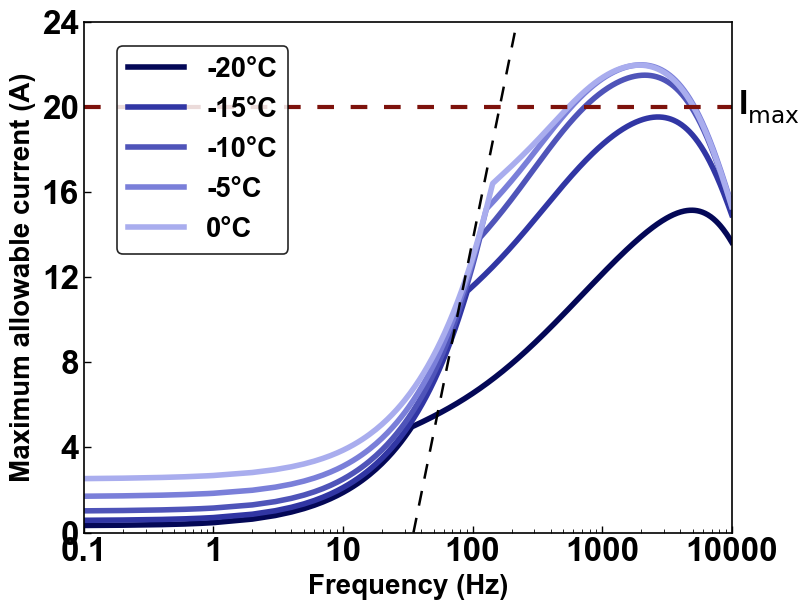

In [7]:
# -*- coding: utf-8 -*-

"""
Plot:
Maximum allowable AC current vs frequency at different temperatures

Data source:
Fig3a.xlsx

Excel structure:
A: Frequency
B: -20 °C
C: -15 °C
D: -10 °C
E:  -5 °C
F:   0 °C
"""

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 0. USER SETTINGS
# =========================================================

# ---------- Input Excel ----------
EXCEL_PATH = r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\Fig3a.xlsx"

# 从截图看 sheet 名应该是“电流幅值”
SHEET_NAME = "电流幅值"

# Excel 列名
FREQ_COLUMN = "频率"

# 温度列
TEMP_COLUMNS = {
    -20: "-20°C",
    -15: "-15°C",
    -10: "-10°C",
    -5:  "-5°C",
    0:   "0°C",
}


# ---------- Output ----------
OUTPUT_DIR = r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2"
OUTPUT_NAME = "Fig3a_imax_vs_frequency.png"

SAVE_DPI = 300
SAVE_FIG = True


# ---------- Figure ----------
FIGSIZE = (8.2, 6.2)
FACE_COLOR = "white"


# ---------- Font ----------
FONT_FAMILY = ["Arial", "DejaVu Sans", "Liberation Sans"]

LABEL_SIZE = 20
TICK_SIZE = 24
LEGEND_SIZE = 20
ANNOTATION_SIZE = 24

LABEL_WEIGHT = "bold"
TICK_WEIGHT = "bold"
LEGEND_WEIGHT = "bold"
ANNOTATION_WEIGHT = "bold"


# ---------- Axis ----------
X_LABEL = "Frequency (Hz)"
Y_LABEL = "Maximum allowable current (A)"

# 根据原来的图先保留
X_LIM = (0.1, 10000)
Y_LIM = (0, 24)

X_TICKS = [0.1, 1, 10, 100, 1000, 10000]
X_TICKLABELS = ["0.1", "1", "10", "100", "1000", "10000"]

Y_TICKS = [0, 4, 8, 12, 16, 20, 24]


# ---------- Curve style ----------
LINE_WIDTH = 4

LINE_COLORS = {
    "-20°C": "#040857",
    "-15°C": "#3136A4",
    "-10°C": "#4F54B9",
    "-5°C":  "#7A7FD9",
    "0°C":   "#A9ADEE",
}


# =========================================================
# Optional: Imax horizontal line
# =========================================================

DRAW_IMAX_LINE = True

IMAX_VALUE = 20.0

IMAX_LINE_COLOR = "#7D120C"
IMAX_LINE_STYLE = (0, (4, 4))
IMAX_LINE_WIDTH = 3

IMAX_TEXT = r"$I_{\mathrm{max}}$"

# 这里 x 使用坐标轴比例
IMAX_TEXT_X = 1.01
IMAX_TEXT_Y = 20.0


# =========================================================
# Optional: slanted boundary line
# =========================================================

DRAW_SLANTED_LINE = True

SLANTED_LINE_X1 = 35
SLANTED_LINE_Y1 = 0

SLANTED_LINE_X2 = 220
SLANTED_LINE_Y2 = 24

SLANTED_LINE_COLOR = "black"
SLANTED_LINE_STYLE = (0, (6, 5))
SLANTED_LINE_WIDTH = 1.8


# =========================================================
# Boundary labels
# =========================================================

DRAW_BOUNDARY_LABELS = False

PLATING_TEXT = "Lithium plating boundary"

PLATING_ARROW_XY = (1.2, 5.8)
PLATING_ARROW_TEXTXY = (12.0, 5.8)

PLATING_ARROW_COLOR = "#F39C12"
PLATING_ARROW_WIDTH = 1.6
PLATING_ARROW_STYLE = "->"


VOLTAGE_TEXT = "Voltage boundary"

VOLTAGE_ARROW_XY = (1700, 5.8)
VOLTAGE_ARROW_TEXTXY = (220, 5.8)

VOLTAGE_ARROW_COLOR = "#B07B3B"
VOLTAGE_ARROW_WIDTH = 1.6
VOLTAGE_ARROW_STYLE = "->"


# =========================================================
# Legend
# =========================================================

SHOW_LEGEND = True

LEGEND_LOC = "upper left"
LEGEND_BBOX = (0.03, 0.98)

LEGEND_FRAMEON = True
LEGEND_FACE_COLOR = "white"
LEGEND_EDGE_COLOR = "black"
LEGEND_FRAME_ALPHA = 0.85
LEGEND_FRAME_LINEWIDTH = 1.2


# =========================================================
# Grid / spine / ticks
# =========================================================

SHOW_GRID = False

GRID_ALPHA = 0.30
GRID_LINESTYLE = "--"
GRID_LINEWIDTH = 0.6

SPINE_WIDTH = 1.2

TICK_WIDTH = 1.0
TICK_LENGTH = 5


# =========================================================
# 1. HELPER FUNCTIONS
# =========================================================

def make_slanted_line_logx(x1, y1, x2, y2, n=300):
    """
    Generate a visually straight line in log-x coordinates.
    """

    logx = np.linspace(
        np.log10(x1),
        np.log10(x2),
        n
    )

    x = 10 ** logx

    y = np.interp(
        logx,
        [np.log10(x1), np.log10(x2)],
        [y1, y2]
    )

    return x, y


def set_ticklabel_weight(ax, weight="bold"):

    for label in ax.get_xticklabels():
        label.set_fontweight(weight)

    for label in ax.get_yticklabels():
        label.set_fontweight(weight)


# =========================================================
# 2. READ EXCEL
# =========================================================

print("Reading Excel:")
print(EXCEL_PATH)

df = pd.read_excel(
    EXCEL_PATH,
    sheet_name=SHEET_NAME
)


# ---------------------------------------------------------
# 清理列名
# ---------------------------------------------------------

df.columns = [
    str(col).strip()
    for col in df.columns
]


print("\nExcel columns:")
print(df.columns.tolist())


# ---------------------------------------------------------
# 找 frequency
# ---------------------------------------------------------

if FREQ_COLUMN not in df.columns:
    raise ValueError(
        f"Cannot find frequency column '{FREQ_COLUMN}'.\n"
        f"Available columns are:\n{df.columns.tolist()}"
    )


frequency = pd.to_numeric(
    df[FREQ_COLUMN],
    errors="coerce"
)


# =========================================================
# 3. PLOT
# =========================================================

plt.rcParams["font.sans-serif"] = FONT_FAMILY
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False


fig, ax = plt.subplots(
    figsize=FIGSIZE,
    facecolor=FACE_COLOR
)


# =========================================================
# Plot temperature curves
# =========================================================

for temp, label in TEMP_COLUMNS.items():

    # pandas 读取 Excel 数字标题后，
    # 我们前面已经全部转成了字符串
    column_name = str(temp)

    if column_name not in df.columns:
        print(
            f"[WARNING] Column '{column_name}' "
            f"for {label} was not found."
        )
        continue

    current = pd.to_numeric(
        df[column_name],
        errors="coerce"
    )

    # 去掉空值
    valid = (
        np.isfinite(frequency)
        & np.isfinite(current)
        & (frequency > 0)
    )

    x = frequency[valid].to_numpy()
    y = current[valid].to_numpy()

    # 按频率排序，防止 Excel 行顺序有问题
    sort_id = np.argsort(x)

    x = x[sort_id]
    y = y[sort_id]

    ax.plot(
        x,
        y,
        color=LINE_COLORS[label],
        linewidth=LINE_WIDTH,
        label=label
    )


# =========================================================
# Imax horizontal line
# =========================================================

if DRAW_IMAX_LINE:

    ax.axhline(
        IMAX_VALUE,
        color=IMAX_LINE_COLOR,
        linestyle=IMAX_LINE_STYLE,
        linewidth=IMAX_LINE_WIDTH
    )

    ax.text(
        IMAX_TEXT_X,
        IMAX_TEXT_Y,
        IMAX_TEXT,
        transform=ax.get_yaxis_transform(),
        fontsize=ANNOTATION_SIZE,
        fontweight=ANNOTATION_WEIGHT,
        ha="left",
        va="center",
        color="black"
    )


# =========================================================
# Slanted boundary line
# =========================================================

if DRAW_SLANTED_LINE:

    x_line, y_line = make_slanted_line_logx(
        SLANTED_LINE_X1,
        SLANTED_LINE_Y1,
        SLANTED_LINE_X2,
        SLANTED_LINE_Y2,
        n=300
    )

    ax.plot(
        x_line,
        y_line,
        color=SLANTED_LINE_COLOR,
        linestyle=SLANTED_LINE_STYLE,
        linewidth=SLANTED_LINE_WIDTH
    )


# =========================================================
# Boundary labels
# =========================================================

if DRAW_BOUNDARY_LABELS:

    ax.annotate(
        PLATING_TEXT,
        xy=PLATING_ARROW_XY,
        xytext=PLATING_ARROW_TEXTXY,

        fontsize=ANNOTATION_SIZE,
        fontweight=ANNOTATION_WEIGHT,
        color=PLATING_ARROW_COLOR,

        arrowprops=dict(
            arrowstyle=PLATING_ARROW_STYLE,
            color=PLATING_ARROW_COLOR,
            lw=PLATING_ARROW_WIDTH
        )
    )

    ax.annotate(
        VOLTAGE_TEXT,
        xy=VOLTAGE_ARROW_XY,
        xytext=VOLTAGE_ARROW_TEXTXY,

        fontsize=ANNOTATION_SIZE,
        fontweight=ANNOTATION_WEIGHT,
        color=VOLTAGE_ARROW_COLOR,

        arrowprops=dict(
            arrowstyle=VOLTAGE_ARROW_STYLE,
            color=VOLTAGE_ARROW_COLOR,
            lw=VOLTAGE_ARROW_WIDTH
        )
    )


# =========================================================
# 4. AXIS SETTINGS
# =========================================================

ax.set_xscale("log")

ax.set_xlim(X_LIM)
ax.set_ylim(Y_LIM)


ax.set_xlabel(
    X_LABEL,
    fontsize=LABEL_SIZE,
    fontweight=LABEL_WEIGHT
)

ax.set_ylabel(
    Y_LABEL,
    fontsize=LABEL_SIZE,
    fontweight=LABEL_WEIGHT
)


# ---------- ticks ----------
ax.set_xticks(X_TICKS)

ax.set_xticklabels(
    X_TICKLABELS,
    fontsize=TICK_SIZE
)


ax.set_yticks(Y_TICKS)

ax.set_yticklabels(
    [str(v) for v in Y_TICKS],
    fontsize=TICK_SIZE
)


ax.tick_params(
    axis="both",
    which="major",
    width=TICK_WIDTH,
    length=TICK_LENGTH,
    direction="in"
)

# log 坐标的小刻度
ax.tick_params(
    axis="x",
    which="minor",
    direction="in",
    length=3
)


set_ticklabel_weight(
    ax,
    TICK_WEIGHT
)


# =========================================================
# Grid
# =========================================================

if SHOW_GRID:

    ax.grid(
        True,
        which="major",
        linestyle=GRID_LINESTYLE,
        linewidth=GRID_LINEWIDTH,
        alpha=GRID_ALPHA
    )


# =========================================================
# Spines
# =========================================================

for spine in ax.spines.values():
    spine.set_linewidth(SPINE_WIDTH)


# =========================================================
# Legend
# =========================================================

if SHOW_LEGEND:

    leg = ax.legend(
        loc=LEGEND_LOC,
        bbox_to_anchor=LEGEND_BBOX,
        frameon=LEGEND_FRAMEON,
        fontsize=LEGEND_SIZE
    )

    frame = leg.get_frame()

    frame.set_edgecolor(
        LEGEND_EDGE_COLOR
    )

    frame.set_facecolor(
        LEGEND_FACE_COLOR
    )

    frame.set_alpha(
        LEGEND_FRAME_ALPHA
    )

    frame.set_linewidth(
        LEGEND_FRAME_LINEWIDTH
    )

    for text in leg.get_texts():
        text.set_fontweight(
            LEGEND_WEIGHT
        )


# =========================================================
# Layout
# =========================================================

plt.tight_layout()


# =========================================================
# 5. SAVE
# =========================================================

if SAVE_FIG:

    out_dir = Path(
        OUTPUT_DIR
    )

    out_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    save_path = (
        out_dir
        / OUTPUT_NAME
    )

    fig.savefig(
        save_path,
        dpi=SAVE_DPI,
        bbox_inches="tight",
        facecolor=FACE_COLOR
    )

    print("\nFigure saved to:")
    print(save_path)


plt.show()

Available sheets:
['95', '90', '85', '80']

Columns in sheet 80:
['频率', '-20℃', '-15℃', '-10℃', '-5℃', '0℃']
-20°C: 10009 points
-15°C: 10009 points
-10°C: 10009 points
 -5°C: 10009 points
  0°C: 10009 points

SOH = 80%, -20°C peak
Peak frequency = 5354 Hz
Peak current   = 7.22959 A

80% SOH left boundary / -20°C curve:
Intersection frequency = 0.938915 Hz
Intersection current   = 2.00154 A

Figure saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_3\Fig3d_SOH80_final.png


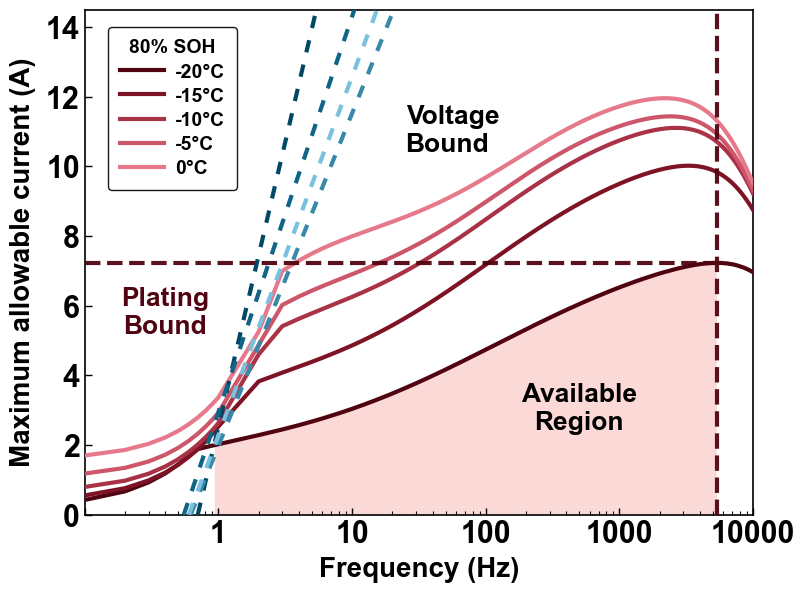

In [18]:
# -*- coding: utf-8 -*-

"""
Fig. 3d
Maximum allowable current vs frequency at SOH = 80%

Data source:
    Fig3d.xlsx

Main curves:
    sheet = "80"

    -20°C
    -15°C
    -10°C
    -5°C
    0°C

Key points:
1. Raw Excel frequency/current values are used directly.
2. No PCHIP interpolation.
3. No smoothing.
4. Raw frequency values are NOT converted with np.log10().
5. The x-axis DISPLAY is logarithmic.
6. -20°C peak frequency/current are obtained automatically
   from the SOH = 80% Excel data.
7. The four blue SOH boundaries remain.
8. NO SOH legend is drawn above the figure.
9. Axes position is fixed explicitly so removing the upper
   legend does not change the figure proportion.
"""


from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 0. USER SETTINGS
# =========================================================


# ---------------------------------------------------------
# Input
# ---------------------------------------------------------

EXCEL_PATH = (
    r"C:\baidunetdiskdownload\各类文档"
    r"\2025-07-15-NC重大"
    r"\Fig3d.xlsx"
)

MAIN_SHEET = "80"


# ---------------------------------------------------------
# Output
# ---------------------------------------------------------

OUTPUT_DIR = (
    r"C:\baidunetdiskdownload\各类文档"
    r"\2025-07-15-NC重大"
    r"\出图"
    r"\Figure_3"
)

OUTPUT_NAME = "Fig3d_SOH80_final.png"

SAVE_FIG = True

SAVE_DPI = 300


# =========================================================
# Figure
# =========================================================

FIGSIZE = (8.2, 6.2)

FACE_COLOR = "white"


# ---------------------------------------------------------
# IMPORTANT:
# Fixed axes position
#
# [left, bottom, width, height]
#
# 以后想调整图的整体比例，主要改这里。
# ---------------------------------------------------------

AX_LEFT = 0.155
AX_BOTTOM = 0.155
AX_WIDTH = 0.815
AX_HEIGHT = 0.815


# =========================================================
# Fonts
# =========================================================

FONT_FAMILY = [
    "Arial",
    "DejaVu Sans",
    "Liberation Sans",
]

LABEL_SIZE = 20

TICK_SIZE = 22

LEGEND_SIZE = 14

ANNOTATION_SIZE = 19


LABEL_WEIGHT = "bold"

TICK_WEIGHT = "bold"

LEGEND_WEIGHT = "bold"

ANNOTATION_WEIGHT = "bold"


# =========================================================
# Axes
# =========================================================

X_LABEL = "Frequency (Hz)"

Y_LABEL = "Maximum allowable current (A)"


X_LIM = (
    0.1,
    10000,
)

Y_LIM = (
    0,
    14.5,
)


# ---------------------------------------------------------
# Log x-axis ticks
# ---------------------------------------------------------

X_TICKS = [
    0.1,
    1,
    10,
    100,
    1000,
    10000,
]


# 第一项不显示 0.1
X_TICKLABELS = [
    "",
    "1",
    "10",
    "100",
    "1000",
    "10000",
]


Y_TICKS = [
    0,
    2,
    4,
    6,
    8,
    10,
    12,
    14,
]


# =========================================================
# 80% SOH curves
# =========================================================

TEMP_ORDER = [
    -20,
    -15,
    -10,
    -5,
    0,
]


TEMP_LABELS = {

    -20: "-20°C",

    -15: "-15°C",

    -10: "-10°C",

    -5: "-5°C",

    0: "0°C",

}


CURVE_COLORS = {

    -20: "#500411",

    -15: "#7E1325",

    -10: "#A93246",

    -5: "#CD566A",

    0: "#E6798B",

}


CURVE_LINE_WIDTH = 3.0


# =========================================================
# SOH left boundaries
# =========================================================

SOH_ORDER = [
    "95",
    "90",
    "85",
    "80",
]


SOH_COLORS = {

    "95": "#024864",

    "90": "#106485",

    "85": "#3788A9",

    "80": "#79C1DD",

}


# ---------------------------------------------------------
# Boundary endpoints
#
# x remains REAL frequency in Hz.
#
# These are used to construct straight lines
# in log-frequency DISPLAY space.
# ---------------------------------------------------------

BOUNDARY_INFO = {

    "95": {

        "x1": 0.70,

        "y1": 0.0,

        "x2": 4.50,

        "y2": 13.2,

    },


    "90": {

        "x1": 0.55,

        "y1": 0.0,

        "x2": 8.00,

        "y2": 13.2,

    },


    "85": {

        "x1": 0.62,

        "y1": 0.0,

        "x2": 15.0,

        "y2": 13.2,

    },


    "80": {

        "x1": 0.60,

        "y1": 0.0,

        "x2": 11.5,

        "y2": 13.2,

    },

}


DRAW_LEFT_BOUNDARIES = True


BOUNDARY_LINESTYLE = (
    0,
    (3, 3),
)

BOUNDARY_LINEWIDTH = 3.0


# =========================================================
# Horizontal plating boundary
# =========================================================

DRAW_HORIZONTAL_BOUNDARY = True


HLINE_COLOR = CURVE_COLORS[-20]

HLINE_STYLE = "--"

HLINE_WIDTH = 3.0

HLINE_ALPHA = 0.95


# =========================================================
# Right voltage boundary
# =========================================================

DRAW_RIGHT_BOUNDARY = True


RIGHT_BOUNDARY_COLOR = CURVE_COLORS[-20]

RIGHT_BOUNDARY_STYLE = "--"

RIGHT_BOUNDARY_WIDTH = 3.0

RIGHT_BOUNDARY_ALPHA = 0.95


# =========================================================
# Available region
# =========================================================

FILL_AVAILABLE_REGION = True


FILL_COLOR = "#F1948A"

FILL_ALPHA = 0.35

FILL_EDGE_COLOR = "none"


# =========================================================
# Annotations
# =========================================================

DRAW_ANNOTATIONS = True


PLATING_TEXT = "Plating\nBound"

VOLTAGE_TEXT = "Voltage\nBound"

AVAILABLE_TEXT = "Available\nRegion"


# ---------------------------------------------------------
# Axes fraction coordinates
# ---------------------------------------------------------

PLATING_TEXT_X = 0.12

PLATING_TEXT_Y = 0.40


VOLTAGE_TEXT_X = 0.48

VOLTAGE_TEXT_Y = 0.76


AVAILABLE_TEXT_X = 0.74

AVAILABLE_TEXT_Y = 0.21


# =========================================================
# Temperature legend
# =========================================================

SHOW_CURVE_LEGEND = True


CURVE_LEGEND_LOC = "upper left"

CURVE_LEGEND_BBOX = (
    0.035,
    0.965,
)


CURVE_LEGEND_FRAMEON = True

CURVE_LEGEND_FACE = "white"

CURVE_LEGEND_EDGE = "black"

CURVE_LEGEND_ALPHA = 0.90

CURVE_LEGEND_LINEWIDTH = 1.0


# =========================================================
# Grid / ticks / spines
# =========================================================

SHOW_GRID = False


GRID_ALPHA = 0.25

GRID_LINESTYLE = "--"

GRID_LINEWIDTH = 0.6


SPINE_WIDTH = 1.2


TICK_WIDTH = 1.0

TICK_LENGTH = 5


# =========================================================
# Z-order
# =========================================================

FILL_ZORDER = 1

CURVE_ZORDER = 4

HLINE_ZORDER = 6

RIGHT_BOUNDARY_ZORDER = 6

LEFT_BOUNDARY_ZORDER = 8


# =========================================================
# 1. HELPER FUNCTIONS
# =========================================================


def normalize_column_name(name):

    """
    Convert:

        -20°C
        -20℃
        -20

    into:

        -20
    """

    s = str(name).strip()

    s = s.replace(" ", "")

    s = s.replace("°C", "")

    s = s.replace("℃", "")

    s = s.replace("°c", "")

    s = s.replace("C", "")

    s = s.replace("c", "")

    return s


# ---------------------------------------------------------

def find_frequency_column(df):

    candidates = [

        "频率",

        "Frequency",

        "frequency",

        "Freq",

        "freq",

        "f",

    ]


    for name in candidates:

        if name in df.columns:

            return name


    raise ValueError(

        "Cannot find frequency column.\n"

        f"Available columns:\n"

        f"{df.columns.tolist()}"

    )


# ---------------------------------------------------------

def find_temperature_column(
    df,
    temperature,
):

    target = str(
        int(temperature)
    )


    for column in df.columns:

        normalized = normalize_column_name(
            column
        )


        if normalized == target:

            return column


    raise ValueError(

        f"Cannot find {temperature}°C column.\n"

        f"Available columns:\n"

        f"{df.columns.tolist()}"

    )


# ---------------------------------------------------------

def extract_curve(
    df,
    temperature,
):

    """
    Extract raw Excel frequency/current values.

    No interpolation.
    No log10 transformation.
    """

    freq_col = find_frequency_column(
        df
    )


    temp_col = find_temperature_column(
        df,
        temperature,
    )


    x = pd.to_numeric(

        df[freq_col],

        errors="coerce",

    ).to_numpy(
        dtype=float
    )


    y = pd.to_numeric(

        df[temp_col],

        errors="coerce",

    ).to_numpy(
        dtype=float
    )


    valid = (

        np.isfinite(x)

        &

        np.isfinite(y)

        &

        (x > 0)

    )


    x = x[valid]

    y = y[valid]


    order = np.argsort(
        x
    )


    x = x[order]

    y = y[order]


    return x, y


# ---------------------------------------------------------

def find_peak(
    x,
    y,
):

    """
    Find maximum current directly
    from the raw Excel curve.
    """

    idx = np.argmax(
        y
    )


    return (

        float(x[idx]),

        float(y[idx]),

        int(idx),

    )


# ---------------------------------------------------------

def make_slanted_line_logx(
    x1,
    y1,
    x2,
    y2,
    n=500,
):

    """
    Create a visually straight line
    on logarithmic x-axis.

    x remains REAL frequency.
    """

    logx = np.linspace(

        np.log10(x1),

        np.log10(x2),

        n,

    )


    x = 10 ** logx


    y = np.linspace(

        y1,

        y2,

        n,

    )


    return x, y


# ---------------------------------------------------------

def extend_boundary_to_top_logx(
    x1,
    y1,
    x2,
    y2,
    y_top,
):

    """
    Extend the boundary to the top
    while preserving its straight appearance
    in log-frequency display space.
    """

    logx1 = np.log10(
        x1
    )

    logx2 = np.log10(
        x2
    )


    ratio = (

        (y_top - y1)

        /

        (y2 - y1)

    )


    logx_top = (

        logx1

        +

        ratio

        *

        (logx2 - logx1)

    )


    x_top = (
        10 ** logx_top
    )


    return (
        x_top,
        y_top,
    )


# ---------------------------------------------------------

def boundary_y_logx(
    x,
    x1,
    y1,
    x2,
    y2,
):

    """
    Calculate boundary y at real frequency x.
    """

    logx = np.log10(
        x
    )

    logx1 = np.log10(
        x1
    )

    logx2 = np.log10(
        x2
    )


    slope = (

        (y2 - y1)

        /

        (logx2 - logx1)

    )


    y = (

        y1

        +

        slope

        *

        (logx - logx1)

    )


    return y


# ---------------------------------------------------------

def find_curve_boundary_intersection(
    x_curve,
    y_curve,
    boundary,
):

    """
    Find first intersection between:
        raw Excel -20°C curve

    and:
        80% SOH log-x boundary.
    """

    x1 = boundary["x1"]

    y1 = boundary["y1"]

    x2 = boundary["x2"]

    y2 = boundary["y2"]


    y_boundary = boundary_y_logx(

        x_curve,

        x1,
        y1,

        x2,
        y2,

    )


    diff = (

        y_curve

        -

        y_boundary

    )


    valid_search = (

        (x_curve >= x1)

        &

        (x_curve <= x2 * 2.0)

    )


    indices = np.where(
        valid_search
    )[0]


    if len(indices) < 2:

        return None, None


    for j in range(

        len(indices) - 1

    ):


        i1 = indices[j]

        i2 = indices[j + 1]


        d1 = diff[i1]

        d2 = diff[i2]


        if d1 == 0:

            return (

                float(
                    x_curve[i1]
                ),

                float(
                    y_curve[i1]
                ),

            )


        if d1 * d2 < 0:


            ratio = (

                -d1

                /

                (d2 - d1)

            )


            # interpolation in log-frequency
            logx1_data = np.log10(
                x_curve[i1]
            )

            logx2_data = np.log10(
                x_curve[i2]
            )


            logx_int = (

                logx1_data

                +

                ratio

                *

                (
                    logx2_data
                    -
                    logx1_data
                )

            )


            x_int = (
                10 ** logx_int
            )


            y_int = (

                y_curve[i1]

                +

                ratio

                *

                (
                    y_curve[i2]
                    -
                    y_curve[i1]
                )

            )


            return (

                float(x_int),

                float(y_int),

            )


    return None, None


# ---------------------------------------------------------

def set_ticklabel_weight(
    ax,
    weight="bold",
):

    for label in (

        ax.get_xticklabels()

        +

        ax.get_yticklabels()

    ):

        label.set_fontweight(
            weight
        )


# =========================================================
# 2. READ EXCEL
# =========================================================

excel_path = Path(
    EXCEL_PATH
)


if not excel_path.exists():

    raise FileNotFoundError(

        f"Excel file not found:\n"

        f"{EXCEL_PATH}"

    )


excel_file = pd.ExcelFile(
    EXCEL_PATH
)


print(
    "=" * 70
)

print(
    "Available sheets:"
)

print(
    excel_file.sheet_names
)

print(
    "=" * 70
)


if MAIN_SHEET not in excel_file.sheet_names:

    raise ValueError(

        f"Cannot find sheet '{MAIN_SHEET}'.\n"

        f"Available sheets:\n"

        f"{excel_file.sheet_names}"

    )


df = pd.read_excel(

    EXCEL_PATH,

    sheet_name=MAIN_SHEET,

)


df.columns = [

    str(c).strip()

    for c in df.columns

]


print(
    "\nColumns in sheet 80:"
)

print(
    df.columns.tolist()
)


# =========================================================
# 3. EXTRACT SOH = 80% CURVES
# =========================================================

CURVE_DATA = {}


for temperature in TEMP_ORDER:


    x, y = extract_curve(

        df,

        temperature,

    )


    CURVE_DATA[temperature] = (
        x,
        y,
    )


    print(

        f"{temperature:>3}°C: "

        f"{len(x)} points"

    )


# =========================================================
# 4. AUTOMATIC -20°C PEAK
# =========================================================

x_minus20, y_minus20 = (
    CURVE_DATA[-20]
)


PEAK_X, PEAK_Y, PEAK_INDEX = find_peak(

    x_minus20,

    y_minus20,

)


print(
    "\n" + "=" * 70
)

print(
    "SOH = 80%, -20°C peak"
)

print(
    f"Peak frequency = {PEAK_X:.6g} Hz"
)

print(
    f"Peak current   = {PEAK_Y:.6g} A"
)

print(
    "=" * 70
)


# =========================================================
# 5. LEFT INTERSECTION
# =========================================================

boundary80 = (
    BOUNDARY_INFO["80"]
)


INTERSECTION_X, INTERSECTION_Y = (
    find_curve_boundary_intersection(

        x_minus20,

        y_minus20,

        boundary80,

    )
)


if INTERSECTION_X is not None:

    print(
        "\n80% SOH left boundary / -20°C curve:"
    )

    print(

        f"Intersection frequency = "

        f"{INTERSECTION_X:.6g} Hz"

    )

    print(

        f"Intersection current   = "

        f"{INTERSECTION_Y:.6g} A"

    )


else:

    print(

        "\n[WARNING] "

        "No intersection detected."

    )


# =========================================================
# 6. MATPLOTLIB GLOBAL SETTINGS
# =========================================================

plt.rcParams[
    "font.sans-serif"
] = FONT_FAMILY


plt.rcParams[
    "font.family"
] = "sans-serif"


plt.rcParams[
    "axes.unicode_minus"
] = False


# =========================================================
# 7. CREATE FIGURE
# =========================================================

# ---------------------------------------------------------
# Important:
#
# We do NOT use plt.subplots()
# We do NOT use tight_layout()
# We do NOT use subplots_adjust()
#
# The plotting area is fixed explicitly.
# ---------------------------------------------------------

fig = plt.figure(

    figsize=FIGSIZE,

    facecolor=FACE_COLOR,

)


ax = fig.add_axes(

    [
        AX_LEFT,
        AX_BOTTOM,
        AX_WIDTH,
        AX_HEIGHT,
    ]

)


# =========================================================
# LOGARITHMIC X AXIS
# =========================================================

ax.set_xscale(
    "log"
)


# =========================================================
# 8. AVAILABLE REGION
# =========================================================

if (

    FILL_AVAILABLE_REGION

    and

    INTERSECTION_X is not None

):


    mask = (

        (x_minus20 >= INTERSECTION_X)

        &

        (x_minus20 <= PEAK_X)

    )


    x_fill = (
        x_minus20[mask].copy()
    )


    y_fill = (
        y_minus20[mask].copy()
    )


    # -----------------------------------------------------
    # Add exact left intersection
    # -----------------------------------------------------

    if (

        len(x_fill) == 0

        or

        x_fill[0] > INTERSECTION_X

    ):


        x_fill = np.insert(

            x_fill,

            0,

            INTERSECTION_X,

        )


        y_fill = np.insert(

            y_fill,

            0,

            INTERSECTION_Y,

        )


    # -----------------------------------------------------
    # Add exact peak
    # -----------------------------------------------------

    if x_fill[-1] < PEAK_X:


        x_fill = np.append(

            x_fill,

            PEAK_X,

        )


        y_fill = np.append(

            y_fill,

            PEAK_Y,

        )


    ax.fill_between(

        x_fill,

        0,

        y_fill,

        facecolor=FILL_COLOR,

        alpha=FILL_ALPHA,

        edgecolor=FILL_EDGE_COLOR,

        zorder=FILL_ZORDER,

    )


# =========================================================
# 9. SOH = 80% RAW EXCEL CURVES
# =========================================================

curve_handles = []


for temperature in TEMP_ORDER:


    x, y = CURVE_DATA[
        temperature
    ]


    line, = ax.plot(

        x,

        y,

        color=CURVE_COLORS[
            temperature
        ],

        linewidth=CURVE_LINE_WIDTH,

        label=TEMP_LABELS[
            temperature
        ],

        zorder=CURVE_ZORDER,

    )


    curve_handles.append(
        line
    )


# =========================================================
# 10. HORIZONTAL PLATING BOUNDARY
# =========================================================

if DRAW_HORIZONTAL_BOUNDARY:


    ax.hlines(

        y=PEAK_Y,

        xmin=X_LIM[0],

        xmax=PEAK_X,

        colors=HLINE_COLOR,

        linestyles=HLINE_STYLE,

        linewidth=HLINE_WIDTH,

        alpha=HLINE_ALPHA,

        zorder=HLINE_ZORDER,

    )


# =========================================================
# 11. RIGHT VOLTAGE BOUNDARY
# =========================================================

if DRAW_RIGHT_BOUNDARY:


    ax.vlines(

        x=PEAK_X,

        ymin=0,

        ymax=Y_LIM[1],

        colors=RIGHT_BOUNDARY_COLOR,

        linestyles=RIGHT_BOUNDARY_STYLE,

        linewidth=RIGHT_BOUNDARY_WIDTH,

        alpha=RIGHT_BOUNDARY_ALPHA,

        zorder=RIGHT_BOUNDARY_ZORDER,

    )


# =========================================================
# 12. LEFT SOH BOUNDARIES
# =========================================================

if DRAW_LEFT_BOUNDARIES:


    for soh in SOH_ORDER:


        info = BOUNDARY_INFO[
            soh
        ]


        x_top, y_top = (
            extend_boundary_to_top_logx(

                info["x1"],

                info["y1"],

                info["x2"],

                info["y2"],

                Y_LIM[1],

            )
        )


        xb, yb = (
            make_slanted_line_logx(

                info["x1"],

                info["y1"],

                x_top,

                y_top,

                n=500,

            )
        )


        ax.plot(

            xb,

            yb,

            color=SOH_COLORS[
                soh
            ],

            linestyle=BOUNDARY_LINESTYLE,

            linewidth=BOUNDARY_LINEWIDTH,

            zorder=LEFT_BOUNDARY_ZORDER,

        )


# =========================================================
# 13. AXES SETTINGS
# =========================================================

ax.set_xlim(
    X_LIM
)


ax.set_ylim(
    Y_LIM
)


ax.set_xlabel(

    X_LABEL,

    fontsize=LABEL_SIZE,

    fontweight=LABEL_WEIGHT,

    labelpad=6,

)


ax.set_ylabel(

    Y_LABEL,

    fontsize=LABEL_SIZE,

    fontweight=LABEL_WEIGHT,

    labelpad=7,

)


# ---------------------------------------------------------
# x ticks
# ---------------------------------------------------------

ax.set_xticks(
    X_TICKS
)


ax.set_xticklabels(

    X_TICKLABELS,

    fontsize=TICK_SIZE,

)


# ---------------------------------------------------------
# y ticks
# ---------------------------------------------------------

ax.set_yticks(
    Y_TICKS
)


ax.set_yticklabels(

    [
        str(v)
        for v in Y_TICKS
    ],

    fontsize=TICK_SIZE,

)


# ---------------------------------------------------------
# ticks
# ---------------------------------------------------------

ax.tick_params(

    axis="both",

    which="major",

    direction="in",

    width=TICK_WIDTH,

    length=TICK_LENGTH,

)


ax.tick_params(

    axis="x",

    which="minor",

    direction="in",

    width=0.8,

    length=3,

)


set_ticklabel_weight(

    ax,

    TICK_WEIGHT,

)


# =========================================================
# 14. SPINES
# =========================================================

for spine in ax.spines.values():

    spine.set_linewidth(
        SPINE_WIDTH
    )


# =========================================================
# 15. GRID
# =========================================================

if SHOW_GRID:


    ax.grid(

        True,

        which="major",

        linestyle=GRID_LINESTYLE,

        linewidth=GRID_LINEWIDTH,

        alpha=GRID_ALPHA,

    )


# =========================================================
# 16. ANNOTATIONS
# =========================================================

if DRAW_ANNOTATIONS:


    ax.text(

        PLATING_TEXT_X,

        PLATING_TEXT_Y,

        PLATING_TEXT,

        transform=ax.transAxes,

        fontsize=ANNOTATION_SIZE,

        fontweight=ANNOTATION_WEIGHT,

        color=CURVE_COLORS[-20],

        horizontalalignment="center",

        verticalalignment="center",

        zorder=20,

    )


    ax.text(

        VOLTAGE_TEXT_X,

        VOLTAGE_TEXT_Y,

        VOLTAGE_TEXT,

        transform=ax.transAxes,

        fontsize=ANNOTATION_SIZE,

        fontweight=ANNOTATION_WEIGHT,

        color="black",

        horizontalalignment="left",

        verticalalignment="center",

        zorder=20,

    )


    ax.text(

        AVAILABLE_TEXT_X,

        AVAILABLE_TEXT_Y,

        AVAILABLE_TEXT,

        transform=ax.transAxes,

        fontsize=ANNOTATION_SIZE,

        fontweight=ANNOTATION_WEIGHT,

        color="black",

        horizontalalignment="center",

        verticalalignment="center",

        zorder=20,

    )


# =========================================================
# 17. TEMPERATURE LEGEND
#
# Only this legend is retained.
# =========================================================

if SHOW_CURVE_LEGEND:


    leg = ax.legend(

        handles=curve_handles,

        loc=CURVE_LEGEND_LOC,

        bbox_to_anchor=CURVE_LEGEND_BBOX,

        frameon=CURVE_LEGEND_FRAMEON,

        fontsize=LEGEND_SIZE,

        title="80% SOH",

        title_fontsize=LEGEND_SIZE,

        borderpad=0.60,

        labelspacing=0.32,

        handlelength=2.25,

        handletextpad=0.60,

        borderaxespad=0.0,

    )


    frame = leg.get_frame()


    frame.set_facecolor(
        CURVE_LEGEND_FACE
    )


    frame.set_edgecolor(
        CURVE_LEGEND_EDGE
    )


    frame.set_alpha(
        CURVE_LEGEND_ALPHA
    )


    frame.set_linewidth(
        CURVE_LEGEND_LINEWIDTH
    )


    for text in leg.get_texts():

        text.set_fontweight(
            LEGEND_WEIGHT
        )


    leg.get_title().set_fontweight(
        LEGEND_WEIGHT
    )


# =========================================================
# 18. SAVE
# =========================================================

if SAVE_FIG:


    out_dir = Path(
        OUTPUT_DIR
    )


    out_dir.mkdir(

        parents=True,

        exist_ok=True,

    )


    save_path = (

        out_dir

        /

        OUTPUT_NAME

    )


    # -----------------------------------------------------
    # IMPORTANT:
    #
    # NO bbox_inches="tight"
    #
    # Therefore the final saved PNG strictly keeps
    # FIGSIZE = (8.2, 6.2)
    # -----------------------------------------------------

    fig.savefig(

        save_path,

        dpi=SAVE_DPI,

        facecolor=FACE_COLOR,

    )


    print(
        "\nFigure saved to:"
    )


    print(
        save_path
    )


# =========================================================
# 19. SHOW
# =========================================================

plt.show()


===== Calculated heating rates =====

SoC = 70%
  Experimental stage rates (°C/min): [0.876, 0.571, 0.716]
  Simulation   stage rates (°C/min): [0.989, 0.649, 0.719]
  Experimental overall avg rate (°C/min): 0.730
  Simulation   overall avg rate (°C/min): 0.735
  Relative difference (%): 0.685

SoC = 50%
  Experimental stage rates (°C/min): [2.592, 4.385, 4.003]
  Simulation   stage rates (°C/min): [2.542, 4.288, 4.021]
  Experimental overall avg rate (°C/min): 3.788
  Simulation   overall avg rate (°C/min): 3.758
  Relative difference (%): 0.800

SoC = 30%
  Experimental stage rates (°C/min): [3.681, 6.193, 5.73]
  Simulation   stage rates (°C/min): [3.951, 5.996, 5.437]
  Experimental overall avg rate (°C/min): 5.350
  Simulation   overall avg rate (°C/min): 5.203
  Relative difference (%): 2.745

Figure saved to: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\SOC_stage_heating_rate_bar_chart_rounded.png


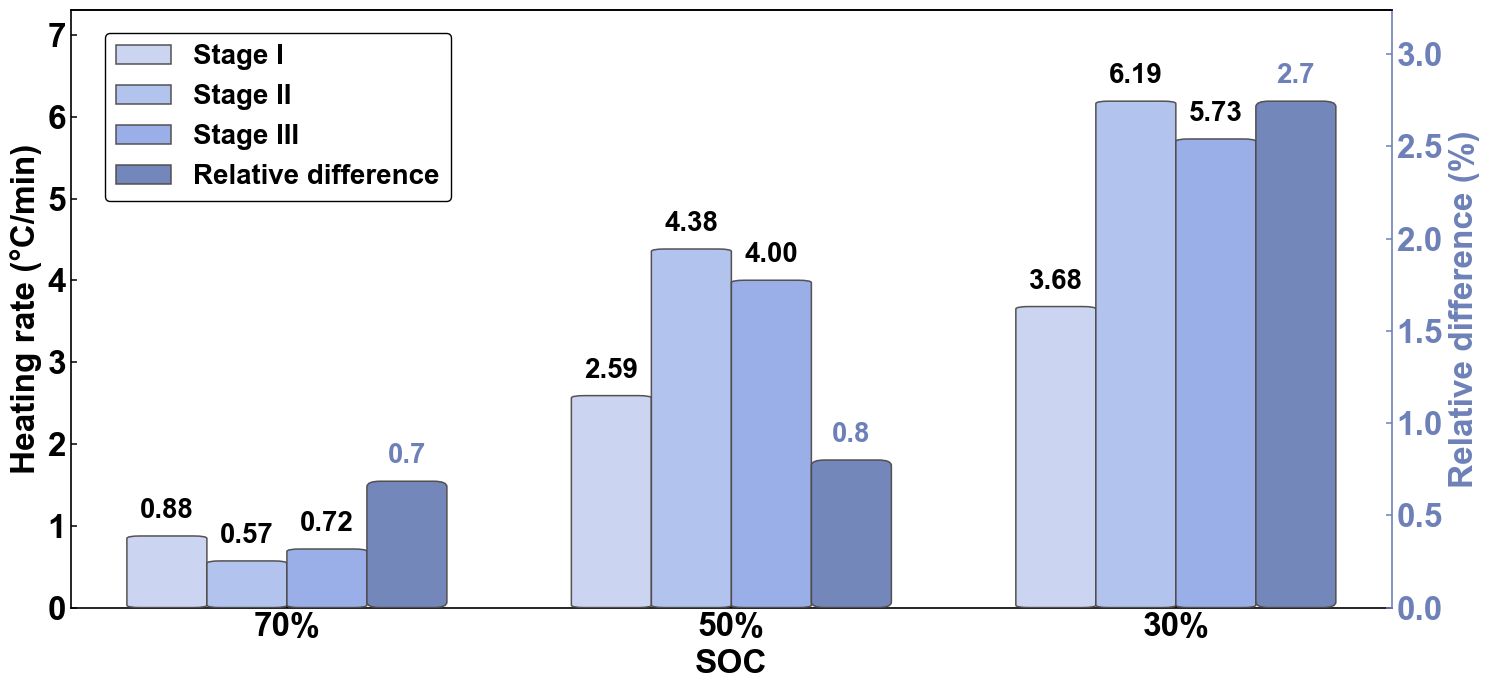

In [20]:
# -*- coding: utf-8 -*-
"""
Bar-chart summary of temperature-rise behavior for three SOC cases.

For each SOC, four bars are plotted:
1. Stage I heating rate (Experimental)
2. Stage II heating rate (Experimental)
3. Stage III heating rate (Experimental)
4. Relative difference between experimental and simulated
   overall average heating rate

Additional feature:
- Simulated heating rates of Stage I / II / III are shown
  as hollow circle markers located exactly at the centers
  of the corresponding experimental bars.

Main visual settings improved:
1. Right y-axis uses the same color as the relative-difference bar
2. Legend is placed at the upper left
3. Rounded bars are used
4. Simulation markers are aligned with the correct bars
"""

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Patch

from scipy.interpolate import PchipInterpolator


# =========================================================
# 0. USER SETTINGS
# =========================================================

# ---------- Output ----------
OUTPUT_DIR = r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2"
OUTPUT_NAME = "SOC_stage_heating_rate_bar_chart_rounded.png"

SAVE_FIG = True
SAVE_DPI = 300
SAVE_BBOX = "tight"
SAVE_PAD_INCHES = 0.10

# ---------- Figure ----------
FIGSIZE = (15, 7)   # 3:2
FIG_FACE_COLOR = "white"
AX_FACE_COLOR = "white"

# ---------- Font ----------
FONT_FAMILY = ["Arial", "DejaVu Sans", "Liberation Sans"]

LABEL_SIZE = 24
TICK_SIZE = 24
LEGEND_SIZE = 20
ANNOTATION_SIZE = 20

LABEL_WEIGHT = "bold"
TICK_WEIGHT = "bold"
LEGEND_WEIGHT = "bold"

# ---------- Axis labels ----------
X_LABEL = "SOC"
Y1_LABEL = "Heating rate (°C/min)"
Y2_LABEL = "Relative difference (%)"

# ---------- Bar style ----------
BAR_WIDTH = 0.18

BAR_COLORS = {
    "Stage I":   "#C9D3F2",
    "Stage II":  "#AEC0ED",
    "Stage III": "#95AAE6",
    "Relative":  "#6D81B8",
}

BAR_ALPHA = 0.95
BAR_EDGE_COLOR = "#4E4A4A"
BAR_EDGE_WIDTH = 1.1

# Rounded bar setting
USE_ROUNDED_BAR = True
BAR_ROUNDING_SIZE = 0.03   # moderate round corner



# ---------- Relative-axis color ----------
RIGHT_AXIS_COLOR = BAR_COLORS["Relative"]

# ---------- Legend ----------
SHOW_LEGEND = True
LEGEND_LOC = "upper left"
LEGEND_BBOX_TO_ANCHOR = (0.015, 0.985)

LEGEND_FRAMEON = True
LEGEND_EDGE_COLOR = "black"
LEGEND_FACE_COLOR = "white"
LEGEND_FRAME_ALPHA = 1.0
LEGEND_FRAME_LINEWIDTH = 1.0

# ---------- Axes / ticks ----------
TICK_DIRECTION = "in"
TICK_WIDTH = 1.1
TICK_LENGTH = 4
SPINE_WIDTH = 1.2

SHOW_GRID = False
GRID_LINESTYLE = "--"
GRID_ALPHA = 0.20
GRID_LINEWIDTH = 0.6

# ---------- Interpolation ----------
N_DENSE = 1200

# ---------- Stage definitions ----------
# Each tuple is: (t_start, t_end)
STAGE_WINDOWS = {
    "SoC = 70%": [
        (0, 120),     # Stage I
        (120, 360),   # Stage II
        (360, 1200),  # Stage III
    ],
    "SoC = 50%": [
        (0, 100),     # Stage I
        (100, 220),   # Stage II
        (220, 396),   # Stage III
    ],
    "SoC = 30%": [
        (0, 80),      # Stage I
        (80, 160),    # Stage II
        (160, 286),   # Stage III
    ],
}

# ---------- Axis limits ----------
Y1_LIM = None      # e.g. (0, 7)
Y2_LIM = None      # e.g. (0, 3)

# ---------- Annotation ----------
SHOW_BAR_VALUE = True

# relative-position offset above bars
LEFT_BAR_TEXT_DY_RATIO = 0.02
RIGHT_BAR_TEXT_DY_RATIO = 0.02


# =========================================================
# 1. APPROXIMATE EXTRACTED DATA
# =========================================================

CASES = [
    {
        "name": "SoC = 70%",
        "exp_x": np.array([0, 100, 200, 320, 360, 450, 650, 850, 1050, 1200], dtype=float),
        "exp_y": np.array([-20.0, -18.5, -17.4, -16.3, -15.9, -14.0, -11.2, -8.8, -6.8, -5.4], dtype=float),

        "sim_x": np.array([0, 100, 200, 320, 360, 450, 650, 850, 1050, 1200], dtype=float),
        "sim_y": np.array([-20.0, -18.3, -17.1, -15.8, -15.5, -14.2, -11.3, -8.9, -6.9, -5.3], dtype=float),
    },

    {
        "name": "SoC = 50%",
        "exp_x": np.array([0, 50, 100, 150, 200, 250, 300, 350, 396], dtype=float),
        "exp_y": np.array([-20.0, -17.8, -15.6, -12.0, -8.4, -4.7, -1.0, 2.0, 5.0], dtype=float),

        "sim_x": np.array([0, 50, 100, 150, 200, 250, 300, 350, 396], dtype=float),
        "sim_y": np.array([-20.0, -17.9, -15.7, -12.3, -8.7, -5.0, -1.3, 1.7, 4.8], dtype=float),
    },

    {
        "name": "SoC = 30%",
        "exp_x": np.array([0, 40, 80, 120, 150, 180, 220, 250, 286], dtype=float),
        "exp_y": np.array([-20.0, -17.4, -15.0, -11.3, -8.0, -4.4, -0.8, 2.2, 5.5], dtype=float),

        "sim_x": np.array([0, 40, 80, 120, 150, 180, 220, 250, 286], dtype=float),
        "sim_y": np.array([-20.0, -17.6, -14.7, -10.8, -7.8, -4.8, -1.5, 1.4, 4.8], dtype=float),
    },
]


# =========================================================
# 2. HELPER FUNCTIONS
# =========================================================

def interpolate_curve(x_anchor, y_anchor, n_dense=1200):
    x_anchor = np.asarray(x_anchor, dtype=float)
    y_anchor = np.asarray(y_anchor, dtype=float)

    f = PchipInterpolator(x_anchor, y_anchor)
    x_dense = np.linspace(x_anchor.min(), x_anchor.max(), n_dense)
    y_dense = f(x_dense)

    return x_dense, y_dense


def calc_stage_rate(x_dense, y_dense, t_start, t_end):
    """
    Heating rate from linear fit over a stage.
    Output unit: °C/min
    """
    mask = (x_dense >= t_start) & (x_dense <= t_end)
    x_seg = x_dense[mask]
    y_seg = y_dense[mask]

    if len(x_seg) < 2:
        return np.nan

    a, b = np.polyfit(x_seg, y_seg, 1)
    rate_c_per_min = a * 60.0
    return rate_c_per_min


def calc_overall_avg_rate(x, y):
    """
    Overall average heating rate using endpoints.
    Output unit: °C/min
    """
    dt = x[-1] - x[0]
    dT = y[-1] - y[0]

    if dt == 0:
        return np.nan

    return dT / dt * 60.0


def set_ticklabel_fontweight(ax, weight="bold"):
    for lbl in ax.get_xticklabels():
        lbl.set_fontweight(weight)
    for lbl in ax.get_yticklabels():
        lbl.set_fontweight(weight)


def add_rounded_bar(
    ax,
    x_center,
    height,
    width,
    facecolor,
    edgecolor="black",
    linewidth=1.0,
    alpha=1.0,
    rounding_size=0.03,
    zorder=3,
):
    """
    Draw one rounded bar and return its metadata.
    """
    x0 = x_center - width / 2
    y0 = 0.0

    patch = FancyBboxPatch(
        (x0, y0),
        width,
        height,
        boxstyle=f"round,pad=0,rounding_size={rounding_size}",
        linewidth=linewidth,
        edgecolor=edgecolor,
        facecolor=facecolor,
        alpha=alpha,
        mutation_aspect=1.0,
        zorder=zorder,
    )
    ax.add_patch(patch)

    return {
        "patch": patch,
        "x_center": x_center,
        "height": height,
        "width": width,
    }


def add_bar_group(
    ax,
    x_centers,
    heights,
    width,
    facecolor,
    edgecolor,
    linewidth,
    alpha,
    rounding_size,
    zorder=3,
):
    """
    Draw a group of rounded bars.
    """
    bars = []
    for xc, h in zip(x_centers, heights):
        bar_info = add_rounded_bar(
            ax=ax,
            x_center=xc,
            height=h,
            width=width,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha,
            rounding_size=rounding_size,
            zorder=zorder,
        )
        bars.append(bar_info)
    return bars


def annotate_bar_group(
    ax,
    bars,
    fmt="{:.2f}",
    color="black",
    fontsize=11,
    fontweight="bold",
    dy_ratio=0.02,
):
    """
    Annotate custom rounded bars.
    """
    y0, y1 = ax.get_ylim()
    span = y1 - y0
    dy = dy_ratio * span

    for bar in bars:
        h = bar["height"]
        xc = bar["x_center"]

        ax.text(
            xc,
            h + dy,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            fontweight=fontweight,
            color=color,
            zorder=10,
        )


# =========================================================
# 3. CALCULATE STAGE RATES
# =========================================================

results = []

for case in CASES:
    name = case["name"]

    exp_x_dense, exp_y_dense = interpolate_curve(case["exp_x"], case["exp_y"], n_dense=N_DENSE)
    sim_x_dense, sim_y_dense = interpolate_curve(case["sim_x"], case["sim_y"], n_dense=N_DENSE)

    stage_windows = STAGE_WINDOWS[name]

    exp_stage_rates = []
    sim_stage_rates = []

    for t_start, t_end in stage_windows:
        exp_rate = calc_stage_rate(exp_x_dense, exp_y_dense, t_start, t_end)
        sim_rate = calc_stage_rate(sim_x_dense, sim_y_dense, t_start, t_end)

        exp_stage_rates.append(exp_rate)
        sim_stage_rates.append(sim_rate)

    exp_overall = calc_overall_avg_rate(case["exp_x"], case["exp_y"])
    sim_overall = calc_overall_avg_rate(case["sim_x"], case["sim_y"])

    relative_diff = abs(sim_overall - exp_overall) / abs(exp_overall) * 100.0

    results.append({
        "name": name,
        "exp_stage_rates": exp_stage_rates,
        "sim_stage_rates": sim_stage_rates,
        "exp_overall": exp_overall,
        "sim_overall": sim_overall,
        "relative_diff": relative_diff,
    })

# Console output
print("\n===== Calculated heating rates =====")
for r in results:
    print(f"\n{r['name']}")
    print(f"  Experimental stage rates (°C/min): {[round(v, 3) for v in r['exp_stage_rates']]}")
    print(f"  Simulation   stage rates (°C/min): {[round(v, 3) for v in r['sim_stage_rates']]}")
    print(f"  Experimental overall avg rate (°C/min): {r['exp_overall']:.3f}")
    print(f"  Simulation   overall avg rate (°C/min): {r['sim_overall']:.3f}")
    print(f"  Relative difference (%): {r['relative_diff']:.3f}")


# =========================================================
# 4. PLOT
# =========================================================

plt.rcParams["font.sans-serif"] = FONT_FAMILY
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False

fig, ax1 = plt.subplots(figsize=FIGSIZE, facecolor=FIG_FACE_COLOR)
fig.patch.set_facecolor(FIG_FACE_COLOR)
ax1.set_facecolor(AX_FACE_COLOR)

ax2 = ax1.twinx()
ax2.set_facecolor("none")

soc_labels = [r["name"].replace("SoC = ", "") for r in results]
x = np.arange(len(soc_labels), dtype=float)

offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * BAR_WIDTH

stage1_vals = [r["exp_stage_rates"][0] for r in results]
stage2_vals = [r["exp_stage_rates"][1] for r in results]
stage3_vals = [r["exp_stage_rates"][2] for r in results]
relative_vals = [r["relative_diff"] for r in results]

sim_stage1 = [r["sim_stage_rates"][0] for r in results]
sim_stage2 = [r["sim_stage_rates"][1] for r in results]
sim_stage3 = [r["sim_stage_rates"][2] for r in results]

centers1 = x + offsets[0]
centers2 = x + offsets[1]
centers3 = x + offsets[2]
centers4 = x + offsets[3]

# ----- set x range manually so patches are fully shown -----
x_left = (x[0] + offsets[0]) - BAR_WIDTH * 1.2
x_right = (x[-1] + offsets[3]) + BAR_WIDTH * 1.2
ax1.set_xlim(x_left, x_right)

# ----- pre-set y ranges if not given -----
if Y1_LIM is None:
    all_left_vals = stage1_vals + stage2_vals + stage3_vals + sim_stage1 + sim_stage2 + sim_stage3
    y1_max = max(all_left_vals)
    ax1.set_ylim(0, y1_max * 1.18)

if Y2_LIM is None:
    y2_max = max(relative_vals)
    ax2.set_ylim(0, y2_max * 1.18)

# ----- draw rounded bars -----
if USE_ROUNDED_BAR:
    bars1 = add_bar_group(
        ax1, centers1, stage1_vals,
        BAR_WIDTH, BAR_COLORS["Stage I"],
        BAR_EDGE_COLOR, BAR_EDGE_WIDTH, BAR_ALPHA,
        BAR_ROUNDING_SIZE, zorder=3
    )

    bars2 = add_bar_group(
        ax1, centers2, stage2_vals,
        BAR_WIDTH, BAR_COLORS["Stage II"],
        BAR_EDGE_COLOR, BAR_EDGE_WIDTH, BAR_ALPHA,
        BAR_ROUNDING_SIZE, zorder=3
    )

    bars3 = add_bar_group(
        ax1, centers3, stage3_vals,
        BAR_WIDTH, BAR_COLORS["Stage III"],
        BAR_EDGE_COLOR, BAR_EDGE_WIDTH, BAR_ALPHA,
        BAR_ROUNDING_SIZE, zorder=3
    )

    bars4 = add_bar_group(
        ax2, centers4, relative_vals,
        BAR_WIDTH, BAR_COLORS["Relative"],
        BAR_EDGE_COLOR, BAR_EDGE_WIDTH, BAR_ALPHA,
        BAR_ROUNDING_SIZE, zorder=3
    )
else:
    raise NotImplementedError("This version is intended for rounded bars only.")



# ----- x ticks -----
ax1.set_xticks(x)
ax1.set_xticklabels(soc_labels)

# ----- labels -----
ax1.set_xlabel(
    X_LABEL,
    fontsize=LABEL_SIZE,
    fontweight=LABEL_WEIGHT
)

ax1.set_ylabel(
    Y1_LABEL,
    fontsize=LABEL_SIZE,
    fontweight=LABEL_WEIGHT,
    color="black"
)

ax2.set_ylabel(
    Y2_LABEL,
    fontsize=LABEL_SIZE,
    fontweight=LABEL_WEIGHT,
    color=RIGHT_AXIS_COLOR
)

# ----- ticks -----
ax1.tick_params(
    axis="both",
    direction=TICK_DIRECTION,
    width=TICK_WIDTH,
    length=TICK_LENGTH,
    labelsize=TICK_SIZE,
    colors="black"
)

ax2.tick_params(
    axis="y",
    direction=TICK_DIRECTION,
    width=TICK_WIDTH,
    length=TICK_LENGTH,
    labelsize=TICK_SIZE,
    colors=RIGHT_AXIS_COLOR
)

set_ticklabel_fontweight(ax1, TICK_WEIGHT)

for lbl in ax2.get_yticklabels():
    lbl.set_fontweight(TICK_WEIGHT)
    lbl.set_color(RIGHT_AXIS_COLOR)

# ----- spines -----
for side in ["left", "bottom", "top"]:
    ax1.spines[side].set_linewidth(SPINE_WIDTH)
    ax1.spines[side].set_color("black")

ax1.spines["right"].set_visible(False)

ax2.spines["right"].set_linewidth(SPINE_WIDTH)
ax2.spines["right"].set_color(RIGHT_AXIS_COLOR)
ax2.spines["top"].set_linewidth(SPINE_WIDTH)
ax2.spines["top"].set_color("black")
ax2.spines["left"].set_visible(False)
ax2.spines["bottom"].set_visible(False)

ax2.yaxis.label.set_color(RIGHT_AXIS_COLOR)

# ----- grid -----
if SHOW_GRID:
    ax1.grid(
        True,
        linestyle=GRID_LINESTYLE,
        alpha=GRID_ALPHA,
        linewidth=GRID_LINEWIDTH,
        axis="y"
    )

# ----- annotate values -----
if SHOW_BAR_VALUE:
    annotate_bar_group(
        ax1, bars1,
        fmt="{:.2f}",
        color="black",
        fontsize=ANNOTATION_SIZE,
        fontweight="bold",
        dy_ratio=LEFT_BAR_TEXT_DY_RATIO
    )

    annotate_bar_group(
        ax1, bars2,
        fmt="{:.2f}",
        color="black",
        fontsize=ANNOTATION_SIZE,
        fontweight="bold",
        dy_ratio=LEFT_BAR_TEXT_DY_RATIO
    )

    annotate_bar_group(
        ax1, bars3,
        fmt="{:.2f}",
        color="black",
        fontsize=ANNOTATION_SIZE,
        fontweight="bold",
        dy_ratio=LEFT_BAR_TEXT_DY_RATIO
    )

    annotate_bar_group(
        ax2, bars4,
        fmt="{:.1f}",
        color=RIGHT_AXIS_COLOR,
        fontsize=ANNOTATION_SIZE,
        fontweight="bold",
        dy_ratio=RIGHT_BAR_TEXT_DY_RATIO
    )

# ----- legend proxies -----
# ----- legend proxies -----
legend_handles = [
    Patch(
        facecolor=BAR_COLORS["Stage I"],
        edgecolor=BAR_EDGE_COLOR,
        linewidth=BAR_EDGE_WIDTH,
        alpha=BAR_ALPHA,
        label="Stage I"
    ),

    Patch(
        facecolor=BAR_COLORS["Stage II"],
        edgecolor=BAR_EDGE_COLOR,
        linewidth=BAR_EDGE_WIDTH,
        alpha=BAR_ALPHA,
        label="Stage II"
    ),

    Patch(
        facecolor=BAR_COLORS["Stage III"],
        edgecolor=BAR_EDGE_COLOR,
        linewidth=BAR_EDGE_WIDTH,
        alpha=BAR_ALPHA,
        label="Stage III"
    ),

    Patch(
        facecolor=BAR_COLORS["Relative"],
        edgecolor=BAR_EDGE_COLOR,
        linewidth=BAR_EDGE_WIDTH,
        alpha=BAR_ALPHA,
        label="Relative difference"
    ),
]

# ----- legend -----
if SHOW_LEGEND:
    leg = ax1.legend(
        handles=legend_handles,
        loc=LEGEND_LOC,
        bbox_to_anchor=LEGEND_BBOX_TO_ANCHOR,
        frameon=LEGEND_FRAMEON,
        fontsize=LEGEND_SIZE,
    )

    frame = leg.get_frame()
    frame.set_edgecolor(LEGEND_EDGE_COLOR)
    frame.set_facecolor(LEGEND_FACE_COLOR)
    frame.set_alpha(LEGEND_FRAME_ALPHA)
    frame.set_linewidth(LEGEND_FRAME_LINEWIDTH)

    for t in leg.get_texts():
        t.set_fontweight(LEGEND_WEIGHT)

# =========================================================
# 5. SAVE / SHOW
# =========================================================

fig.tight_layout(
     
)

if SAVE_FIG:
    out_dir = Path(OUTPUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)
    save_path = out_dir / OUTPUT_NAME

    fig.savefig(
        save_path,
        dpi=SAVE_DPI,
        bbox_inches=SAVE_BBOX,
        pad_inches=SAVE_PAD_INCHES,
        facecolor=FIG_FACE_COLOR
    )
    print(f"\nFigure saved to: {save_path}")

plt.show()


Calculated SOH heating-rate results

SOH = 95%
  Experimental stage rates (°C/min): [2.166, 3.116, 2.707]
  Simulated stage rates (°C/min): [2.201, 3.13, 2.503]
  Experimental overall rate: 2.727 °C/min
  Simulated overall rate: 2.705 °C/min
  Relative difference: 0.800%

SOH = 90%
  Experimental stage rates (°C/min): [2.166, 3.094, 2.718]
  Simulated stage rates (°C/min): [2.201, 3.108, 2.515]
  Experimental overall rate: 2.727 °C/min
  Simulated overall rate: 2.705 °C/min
  Relative difference: 0.800%

SOH = 85%
  Experimental stage rates (°C/min): [1.734, 2.737, 1.43]
  Simulated stage rates (°C/min): [1.806, 2.611, 1.484]
  Experimental overall rate: 1.899 °C/min
  Simulated overall rate: 1.891 °C/min
  Relative difference: 0.400%

SOH = 80%
  Experimental stage rates (°C/min): [1.734, 2.722, 1.435]
  Simulated stage rates (°C/min): [1.806, 2.596, 1.484]
  Experimental overall rate: 1.899 °C/min
  Simulated overall rate: 1.884 °C/min
  Relative difference: 0.800%

Figure saved to:

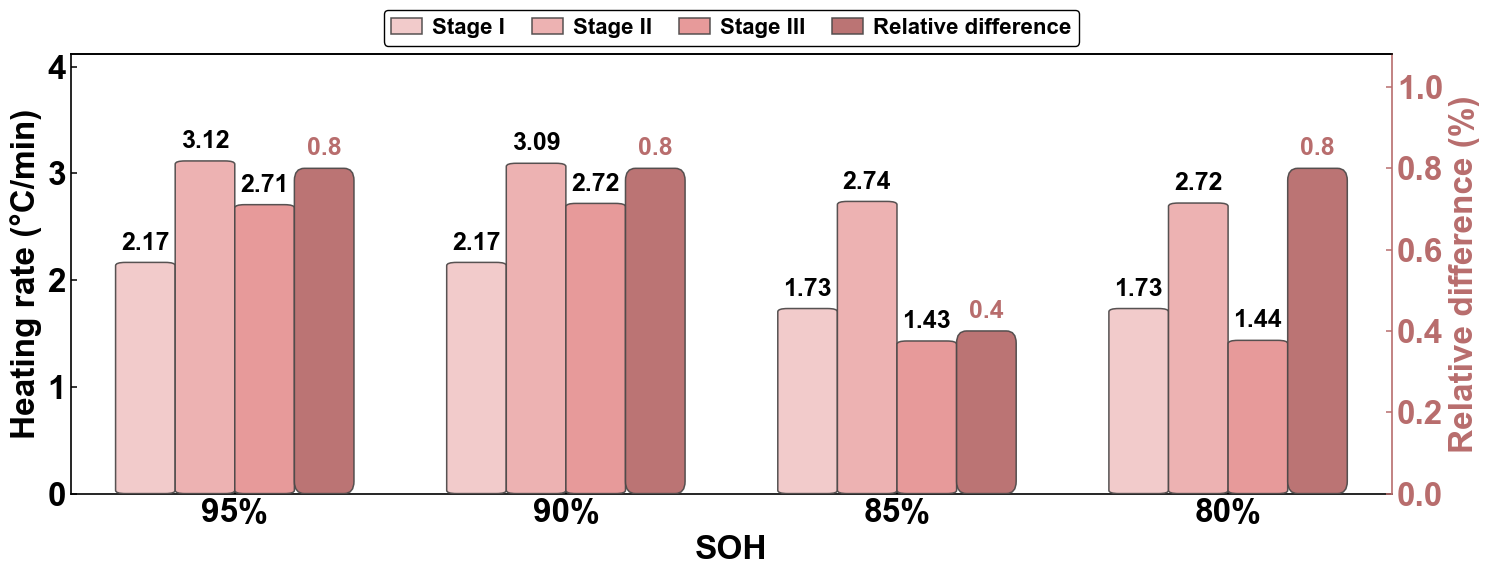

In [127]:
# -*- coding: utf-8 -*-
"""
Heating-rate bar chart for four SOH cases.

For each SOH, four rounded bars are plotted:
1. Stage I experimental heating rate
2. Stage II experimental heating rate
3. Stage III experimental heating rate
4. Relative difference between experimental and simulated
   overall average heating rates

Features:
1. Four SOH cases: 95%, 90%, 85%, and 80%.
2. Rounded bars.
3. No simulation markers.
4. Left axis: heating rate (°C/min).
5. Right axis: relative difference (%).
6. Right axis has the same color as the relative-difference bars.
7. Four-column legend placed outside the upper boundary.
8. Bar values are shown above each bar.
"""

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Patch
from scipy.interpolate import PchipInterpolator


# =========================================================
# 0. USER SETTINGS
# =========================================================

# ---------------------------------------------------------
# Output
# ---------------------------------------------------------
OUTPUT_DIR = (
    r"C:\baidunetdiskdownload\各类文档"
    r"\2025-07-15-NC重大\出图\Figure_2"
)

OUTPUT_NAME = "SOH_stage_heating_rate_bar_chart_rounded.png"

SAVE_FIG = True
SAVE_DPI = 300
SAVE_BBOX = "tight"
SAVE_PAD_INCHES = 0.10


# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
FIGSIZE = (15, 7)

FIG_FACE_COLOR = "white"
AX_FACE_COLOR = "white"


# ---------------------------------------------------------
# Font
# ---------------------------------------------------------
FONT_FAMILY = [
    "Arial",
    "DejaVu Sans",
    "Liberation Sans",
]

LABEL_SIZE = 24
TICK_SIZE = 24
LEGEND_SIZE = 16
ANNOTATION_SIZE = 18

LABEL_WEIGHT = "bold"
TICK_WEIGHT = "bold"
LEGEND_WEIGHT = "bold"


# ---------------------------------------------------------
# Axis labels
# ---------------------------------------------------------
X_LABEL = "SOH"
Y1_LABEL = "Heating rate (°C/min)"
Y2_LABEL = "Relative difference (%)"


# ---------------------------------------------------------
# Bar style
# ---------------------------------------------------------
BAR_WIDTH = 0.18

BAR_COLORS = {
    "Stage I": "#F2C9C9",
    "Stage II": "#EDAEAE",
    "Stage III": "#E69595",
    "Relative": "#B86D6D",
}

BAR_ALPHA = 0.95

BAR_EDGE_COLOR = "#4E4A4A"
BAR_EDGE_WIDTH = 1.1

# Rounded-corner size
BAR_ROUNDING_SIZE = 0.03


# ---------------------------------------------------------
# Right-axis color
# ---------------------------------------------------------
RIGHT_AXIS_COLOR = BAR_COLORS["Relative"]


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------
SHOW_LEGEND = True

# Place the legend above the axes.
LEGEND_LOC = "lower center"
LEGEND_BBOX_TO_ANCHOR = (0.5, 1.02)
LEGEND_NCOL = 4

LEGEND_FRAMEON = True
LEGEND_EDGE_COLOR = "black"
LEGEND_FACE_COLOR = "white"
LEGEND_FRAME_ALPHA = 1.0
LEGEND_FRAME_LINEWIDTH = 1.0

LEGEND_BORDERPAD = 0.35
LEGEND_LABELSPACING = 0.20
LEGEND_HANDLELENGTH = 1.4
LEGEND_HANDLETEXTPAD = 0.45
LEGEND_COLUMNSPACING = 1.2


# ---------------------------------------------------------
# Axis and ticks
# ---------------------------------------------------------
TICK_DIRECTION = "in"
TICK_WIDTH = 1.1
TICK_LENGTH = 4

SPINE_WIDTH = 1.2

SHOW_GRID = False

GRID_LINESTYLE = "--"
GRID_ALPHA = 0.20
GRID_LINEWIDTH = 0.6


# ---------------------------------------------------------
# Interpolation
# ---------------------------------------------------------
N_PRE = 500
N_POST = 900


# ---------------------------------------------------------
# Stage definitions
# ---------------------------------------------------------
# Each tuple:
#     (start time, end time)
#
# Modify these boundaries when a different stage definition
# is required.

STAGE_WINDOWS = {
    "SOH = 95%": [
        (0, 140),
        (140, 320),
        (320, 550),
    ],

    "SOH = 90%": [
        (0, 140),
        (140, 320),
        (320, 550),
    ],

    "SOH = 85%": [
        (0, 180),
        (180, 400),
        (400, 790),
    ],

    "SOH = 80%": [
        (0, 180),
        (180, 400),
        (400, 790),
    ],
}


# ---------------------------------------------------------
# Axis limits
# ---------------------------------------------------------
# Use None for automatic determination.

Y1_LIM = None
Y2_LIM = None

# Leave enough space above the bars for value labels.
Y1_UPPER_FACTOR = 1.32
Y2_UPPER_FACTOR = 1.35


# ---------------------------------------------------------
# Bar annotations
# ---------------------------------------------------------
SHOW_BAR_VALUES = True

LEFT_BAR_TEXT_FORMAT = "{:.2f}"
RIGHT_BAR_TEXT_FORMAT = "{:.1f}"

LEFT_BAR_TEXT_COLOR = "black"
RIGHT_BAR_TEXT_COLOR = RIGHT_AXIS_COLOR

LEFT_BAR_TEXT_DY_RATIO = 0.018
RIGHT_BAR_TEXT_DY_RATIO = 0.018


# ---------------------------------------------------------
# Figure layout
# ---------------------------------------------------------
# Reserve the upper area for the four-column legend.
TIGHT_LAYOUT_RECT = [0.00, 0.00, 1.00, 0.84]


# =========================================================
# 1. APPROXIMATE EXTRACTED SOH DATA
# =========================================================

CASES = [
    {
        "name": "SOH = 95%",

        "exp_x": np.array(
            [
                0, 40, 80, 120, 140, 200,
                260, 320, 380, 440, 500, 550,
            ],
            dtype=float,
        ),

        "exp_y": np.array(
            [
                -20.0, -18.2, -16.8, -15.4, -15.0, -11.5,
                -8.4, -5.6, -2.8, -0.2, 2.5, 5.0,
            ],
            dtype=float,
        ),

        "sim_x": np.array(
            [
                0, 40, 80, 120, 140, 200,
                260, 320, 380, 440, 500, 550,
            ],
            dtype=float,
        ),

        "sim_y": np.array(
            [
                -20.0, -18.1, -16.7, -15.3, -14.8, -11.0,
                -8.0, -5.2, -2.5, -0.1, 2.3, 4.8,
            ],
            dtype=float,
        ),

        "event_x": 140,
    },

    {
        "name": "SOH = 90%",

        "exp_x": np.array(
            [
                0, 40, 80, 120, 140, 200,
                260, 320, 380, 440, 500, 550,
            ],
            dtype=float,
        ),

        "exp_y": np.array(
            [
                -20.0, -18.2, -16.8, -15.4, -15.0, -11.6,
                -8.5, -5.7, -2.9, -0.3, 2.4, 5.0,
            ],
            dtype=float,
        ),

        "sim_x": np.array(
            [
                0, 40, 80, 120, 140, 200,
                260, 320, 380, 440, 500, 550,
            ],
            dtype=float,
        ),

        "sim_y": np.array(
            [
                -20.0, -18.1, -16.7, -15.3, -14.8, -11.1,
                -8.1, -5.3, -2.6, -0.2, 2.2, 4.8,
            ],
            dtype=float,
        ),

        "event_x": 140,
    },

    {
        "name": "SOH = 85%",

        "exp_x": np.array(
            [
                0, 50, 100, 150, 180, 240, 320,
                400, 480, 560, 640, 720, 790,
            ],
            dtype=float,
        ),

        "exp_y": np.array(
            [
                -20.0, -17.8, -16.2, -15.1, -14.9, -11.2,
                -7.8, -4.4, -1.6, 0.6, 2.5, 4.0, 5.0,
            ],
            dtype=float,
        ),

        "sim_x": np.array(
            [
                0, 50, 100, 150, 180, 240, 320,
                400, 480, 560, 640, 720, 790,
            ],
            dtype=float,
        ),

        "sim_y": np.array(
            [
                -20.0, -17.7, -16.1, -14.9, -14.6, -11.7,
                -8.3, -4.9, -1.9, 0.4, 2.3, 3.9, 4.9,
            ],
            dtype=float,
        ),

        "event_x": 180,
    },

    {
        "name": "SOH = 80%",

        "exp_x": np.array(
            [
                0, 50, 100, 150, 180, 240, 320,
                400, 480, 560, 640, 720, 790,
            ],
            dtype=float,
        ),

        "exp_y": np.array(
            [
                -20.0, -17.8, -16.2, -15.1, -14.9, -11.3,
                -7.9, -4.5, -1.7, 0.5, 2.4, 3.9, 5.0,
            ],
            dtype=float,
        ),

        "sim_x": np.array(
            [
                0, 50, 100, 150, 180, 240, 320,
                400, 480, 560, 640, 720, 790,
            ],
            dtype=float,
        ),

        "sim_y": np.array(
            [
                -20.0, -17.7, -16.1, -14.9, -14.6, -11.8,
                -8.4, -5.0, -2.0, 0.3, 2.2, 3.8, 4.8,
            ],
            dtype=float,
        ),

        "event_x": 180,
    },
]


# =========================================================
# 2. HELPER FUNCTIONS
# =========================================================

def piecewise_pchip(
    x_anchor,
    y_anchor,
    event_x,
    n_pre=500,
    n_post=900,
):
    """
    Perform separate PCHIP interpolation before and after
    the transition point.
    """

    x_anchor = np.asarray(
        x_anchor,
        dtype=float,
    )

    y_anchor = np.asarray(
        y_anchor,
        dtype=float,
    )

    if len(x_anchor) != len(y_anchor):
        raise ValueError(
            "x_anchor and y_anchor must have the same length."
        )

    if np.any(np.diff(x_anchor) <= 0):
        raise ValueError(
            "x_anchor must be strictly increasing."
        )

    pre_mask = x_anchor <= event_x
    post_mask = x_anchor >= event_x

    if pre_mask.sum() < 2 or post_mask.sum() < 2:
        interpolation = PchipInterpolator(
            x_anchor,
            y_anchor,
        )

        x_dense = np.linspace(
            x_anchor.min(),
            x_anchor.max(),
            n_pre + n_post,
        )

        y_dense = interpolation(
            x_dense,
        )

        return x_dense, y_dense

    x_pre = x_anchor[pre_mask]
    y_pre = y_anchor[pre_mask]

    x_post = x_anchor[post_mask]
    y_post = y_anchor[post_mask]

    pre_interpolation = PchipInterpolator(
        x_pre,
        y_pre,
    )

    post_interpolation = PchipInterpolator(
        x_post,
        y_post,
    )

    x_pre_dense = np.linspace(
        x_pre.min(),
        x_pre.max(),
        n_pre,
    )

    x_post_dense = np.linspace(
        x_post.min(),
        x_post.max(),
        n_post,
    )

    y_pre_dense = pre_interpolation(
        x_pre_dense,
    )

    y_post_dense = post_interpolation(
        x_post_dense,
    )

    x_dense = np.concatenate(
        [
            x_pre_dense,
            x_post_dense[1:],
        ]
    )

    y_dense = np.concatenate(
        [
            y_pre_dense,
            y_post_dense[1:],
        ]
    )

    return x_dense, y_dense


def calculate_stage_rate(
    x_dense,
    y_dense,
    start_time,
    end_time,
):
    """
    Calculate the stage heating rate through linear fitting.

    Output unit:
        °C/min
    """

    mask = (
        (x_dense >= start_time)
        & (x_dense <= end_time)
    )

    x_segment = x_dense[mask]
    y_segment = y_dense[mask]

    if len(x_segment) < 2:
        raise ValueError(
            f"Insufficient data between "
            f"{start_time} and {end_time} s."
        )

    slope, _ = np.polyfit(
        x_segment,
        y_segment,
        1,
    )

    return float(
        slope * 60.0
    )


def calculate_overall_average_rate(
    x_values,
    y_values,
):
    """
    Calculate the overall average heating rate using endpoints.

    Output unit:
        °C/min
    """

    x_values = np.asarray(
        x_values,
        dtype=float,
    )

    y_values = np.asarray(
        y_values,
        dtype=float,
    )

    delta_time = (
        x_values[-1]
        - x_values[0]
    )

    delta_temperature = (
        y_values[-1]
        - y_values[0]
    )

    if delta_time <= 0:
        raise ValueError(
            "Total time must be positive."
        )

    return float(
        delta_temperature
        / delta_time
        * 60.0
    )


def calculate_relative_difference(
    experimental_value,
    simulated_value,
):
    """
    Relative difference:

        |simulation - experiment| / |experiment| × 100%
    """

    if np.isclose(
        experimental_value,
        0.0,
    ):
        return np.nan

    return float(
        abs(
            simulated_value
            - experimental_value
        )
        / abs(experimental_value)
        * 100.0
    )


def set_ticklabel_fontweight(
    axis,
    weight="bold",
):
    """Set all tick labels to the selected font weight."""

    for label in axis.get_xticklabels():
        label.set_fontweight(weight)

    for label in axis.get_yticklabels():
        label.set_fontweight(weight)


def add_rounded_bar(
    axis,
    x_center,
    height,
    width,
    facecolor,
):
    """Draw one rounded bar."""

    x_left = (
        x_center
        - width / 2.0
    )

    patch = FancyBboxPatch(
        (x_left, 0.0),
        width,
        height,

        boxstyle=(
            f"round,pad=0,"
            f"rounding_size={BAR_ROUNDING_SIZE}"
        ),

        linewidth=BAR_EDGE_WIDTH,
        edgecolor=BAR_EDGE_COLOR,
        facecolor=facecolor,
        alpha=BAR_ALPHA,
        mutation_aspect=1.0,
        zorder=3,
    )

    axis.add_patch(
        patch
    )

    return {
        "patch": patch,
        "x_center": float(x_center),
        "height": float(height),
    }


def add_bar_group(
    axis,
    centers,
    heights,
    facecolor,
):
    """Draw a complete rounded-bar group."""

    bars = []

    for center, height in zip(
        centers,
        heights,
    ):
        bars.append(
            add_rounded_bar(
                axis=axis,
                x_center=center,
                height=height,
                width=BAR_WIDTH,
                facecolor=facecolor,
            )
        )

    return bars


def annotate_bar_group(
    axis,
    bars,
    text_format,
    text_color,
    dy_ratio,
):
    """Write values above rounded bars."""

    y_lower, y_upper = axis.get_ylim()

    y_span = (
        y_upper
        - y_lower
    )

    text_offset = (
        dy_ratio
        * y_span
    )

    for bar in bars:
        axis.text(
            bar["x_center"],
            bar["height"] + text_offset,
            text_format.format(
                bar["height"]
            ),

            ha="center",
            va="bottom",

            fontsize=ANNOTATION_SIZE,
            fontweight="bold",
            color=text_color,
            zorder=10,
        )


# =========================================================
# 3. CALCULATE STAGE RATES
# =========================================================

results = []

for case in CASES:
    case_name = case["name"]

    if case_name not in STAGE_WINDOWS:
        raise KeyError(
            f"No stage windows were defined for {case_name}."
        )

    stage_windows = STAGE_WINDOWS[
        case_name
    ]

    if len(stage_windows) != 3:
        raise ValueError(
            f"{case_name} must contain exactly three stages."
        )

    exp_x_dense, exp_y_dense = piecewise_pchip(
        x_anchor=case["exp_x"],
        y_anchor=case["exp_y"],
        event_x=case["event_x"],
        n_pre=N_PRE,
        n_post=N_POST,
    )

    sim_x_dense, sim_y_dense = piecewise_pchip(
        x_anchor=case["sim_x"],
        y_anchor=case["sim_y"],
        event_x=case["event_x"],
        n_pre=N_PRE,
        n_post=N_POST,
    )

    experimental_stage_rates = []
    simulated_stage_rates = []

    for start_time, end_time in stage_windows:
        experimental_stage_rates.append(
            calculate_stage_rate(
                exp_x_dense,
                exp_y_dense,
                start_time,
                end_time,
            )
        )

        simulated_stage_rates.append(
            calculate_stage_rate(
                sim_x_dense,
                sim_y_dense,
                start_time,
                end_time,
            )
        )

    experimental_overall_rate = (
        calculate_overall_average_rate(
            case["exp_x"],
            case["exp_y"],
        )
    )

    simulated_overall_rate = (
        calculate_overall_average_rate(
            case["sim_x"],
            case["sim_y"],
        )
    )

    relative_difference = (
        calculate_relative_difference(
            experimental_overall_rate,
            simulated_overall_rate,
        )
    )

    results.append(
        {
            "name": case_name,
            "experimental_stage_rates": experimental_stage_rates,
            "simulated_stage_rates": simulated_stage_rates,
            "experimental_overall_rate": experimental_overall_rate,
            "simulated_overall_rate": simulated_overall_rate,
            "relative_difference": relative_difference,
        }
    )


# =========================================================
# 4. PRINT RESULTS
# =========================================================

print("\n" + "=" * 72)
print("Calculated SOH heating-rate results")

for result in results:
    experimental_rates = [
        round(value, 3)
        for value in result["experimental_stage_rates"]
    ]

    simulated_rates = [
        round(value, 3)
        for value in result["simulated_stage_rates"]
    ]

    print(f"\n{result['name']}")

    print(
        "  Experimental stage rates (°C/min): "
        f"{experimental_rates}"
    )

    print(
        "  Simulated stage rates (°C/min): "
        f"{simulated_rates}"
    )

    print(
        "  Experimental overall rate: "
        f"{result['experimental_overall_rate']:.3f} °C/min"
    )

    print(
        "  Simulated overall rate: "
        f"{result['simulated_overall_rate']:.3f} °C/min"
    )

    print(
        "  Relative difference: "
        f"{result['relative_difference']:.3f}%"
    )

print("=" * 72)


# =========================================================
# 5. PLOT
# =========================================================

plt.rcParams["font.sans-serif"] = FONT_FAMILY
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False


fig, ax_left = plt.subplots(
    figsize=FIGSIZE,
    facecolor=FIG_FACE_COLOR,
)

fig.patch.set_facecolor(
    FIG_FACE_COLOR
)

ax_left.set_facecolor(
    AX_FACE_COLOR
)


# Right axis
ax_right = ax_left.twinx()

ax_right.patch.set_visible(
    False
)

# Ensure right-axis bars remain visible above the left-axis patch.
ax_right.set_zorder(
    ax_left.get_zorder() + 1
)


# ---------------------------------------------------------
# Prepare values and positions
# ---------------------------------------------------------
soh_labels = [
    result["name"].replace(
        "SOH = ",
        ""
    )
    for result in results
]

x_group = np.arange(
    len(soh_labels),
    dtype=float,
)

bar_offsets = (
    np.array(
        [-1.5, -0.5, 0.5, 1.5]
    )
    * BAR_WIDTH
)


stage_1_values = [
    result["experimental_stage_rates"][0]
    for result in results
]

stage_2_values = [
    result["experimental_stage_rates"][1]
    for result in results
]

stage_3_values = [
    result["experimental_stage_rates"][2]
    for result in results
]

relative_values = [
    result["relative_difference"]
    for result in results
]


stage_1_centers = (
    x_group + bar_offsets[0]
)

stage_2_centers = (
    x_group + bar_offsets[1]
)

stage_3_centers = (
    x_group + bar_offsets[2]
)

relative_centers = (
    x_group + bar_offsets[3]
)


# ---------------------------------------------------------
# Axis ranges
# ---------------------------------------------------------
x_left_limit = (
    stage_1_centers[0]
    - BAR_WIDTH * 1.25
)

x_right_limit = (
    relative_centers[-1]
    + BAR_WIDTH * 1.25
)

ax_left.set_xlim(
    x_left_limit,
    x_right_limit,
)


if Y1_LIM is None:
    maximum_heating_rate = max(
        stage_1_values
        + stage_2_values
        + stage_3_values
    )

    ax_left.set_ylim(
        0,
        maximum_heating_rate
        * Y1_UPPER_FACTOR,
    )

else:
    ax_left.set_ylim(
        *Y1_LIM
    )


if Y2_LIM is None:
    maximum_relative_difference = max(
        relative_values
    )

    if maximum_relative_difference <= 0:
        maximum_relative_difference = 1.0

    ax_right.set_ylim(
        0,
        maximum_relative_difference
        * Y2_UPPER_FACTOR,
    )

else:
    ax_right.set_ylim(
        *Y2_LIM
    )


# ---------------------------------------------------------
# Rounded bars
# ---------------------------------------------------------
stage_1_bars = add_bar_group(
    axis=ax_left,
    centers=stage_1_centers,
    heights=stage_1_values,
    facecolor=BAR_COLORS["Stage I"],
)

stage_2_bars = add_bar_group(
    axis=ax_left,
    centers=stage_2_centers,
    heights=stage_2_values,
    facecolor=BAR_COLORS["Stage II"],
)

stage_3_bars = add_bar_group(
    axis=ax_left,
    centers=stage_3_centers,
    heights=stage_3_values,
    facecolor=BAR_COLORS["Stage III"],
)

relative_bars = add_bar_group(
    axis=ax_right,
    centers=relative_centers,
    heights=relative_values,
    facecolor=BAR_COLORS["Relative"],
)


# ---------------------------------------------------------
# Bar-value annotations
# ---------------------------------------------------------
if SHOW_BAR_VALUES:
    annotate_bar_group(
        axis=ax_left,
        bars=stage_1_bars,
        text_format=LEFT_BAR_TEXT_FORMAT,
        text_color=LEFT_BAR_TEXT_COLOR,
        dy_ratio=LEFT_BAR_TEXT_DY_RATIO,
    )

    annotate_bar_group(
        axis=ax_left,
        bars=stage_2_bars,
        text_format=LEFT_BAR_TEXT_FORMAT,
        text_color=LEFT_BAR_TEXT_COLOR,
        dy_ratio=LEFT_BAR_TEXT_DY_RATIO,
    )

    annotate_bar_group(
        axis=ax_left,
        bars=stage_3_bars,
        text_format=LEFT_BAR_TEXT_FORMAT,
        text_color=LEFT_BAR_TEXT_COLOR,
        dy_ratio=LEFT_BAR_TEXT_DY_RATIO,
    )

    annotate_bar_group(
        axis=ax_right,
        bars=relative_bars,
        text_format=RIGHT_BAR_TEXT_FORMAT,
        text_color=RIGHT_BAR_TEXT_COLOR,
        dy_ratio=RIGHT_BAR_TEXT_DY_RATIO,
    )


# ---------------------------------------------------------
# X ticks
# ---------------------------------------------------------
ax_left.set_xticks(
    x_group
)

ax_left.set_xticklabels(
    soh_labels
)


# ---------------------------------------------------------
# Axis labels
# ---------------------------------------------------------
ax_left.set_xlabel(
    X_LABEL,
    fontsize=LABEL_SIZE,
    fontweight=LABEL_WEIGHT,
)

ax_left.set_ylabel(
    Y1_LABEL,
    fontsize=LABEL_SIZE,
    fontweight=LABEL_WEIGHT,
    color="black",
)

ax_right.set_ylabel(
    Y2_LABEL,
    fontsize=LABEL_SIZE,
    fontweight=LABEL_WEIGHT,
    color=RIGHT_AXIS_COLOR,
)


# ---------------------------------------------------------
# Tick styles
# ---------------------------------------------------------
ax_left.tick_params(
    axis="both",
    direction=TICK_DIRECTION,
    width=TICK_WIDTH,
    length=TICK_LENGTH,
    labelsize=TICK_SIZE,
    colors="black",
)

ax_right.tick_params(
    axis="y",
    direction=TICK_DIRECTION,
    width=TICK_WIDTH,
    length=TICK_LENGTH,
    labelsize=TICK_SIZE,
    colors=RIGHT_AXIS_COLOR,
)


set_ticklabel_fontweight(
    ax_left,
    TICK_WEIGHT,
)

for tick_label in ax_right.get_yticklabels():
    tick_label.set_fontweight(
        TICK_WEIGHT
    )

    tick_label.set_color(
        RIGHT_AXIS_COLOR
    )


# ---------------------------------------------------------
# Axis spines
# ---------------------------------------------------------
for side in [
    "left",
    "bottom",
    "top",
]:
    ax_left.spines[side].set_linewidth(
        SPINE_WIDTH
    )

    ax_left.spines[side].set_color(
        "black"
    )


ax_left.spines["right"].set_visible(
    False
)


ax_right.spines["right"].set_linewidth(
    SPINE_WIDTH
)

ax_right.spines["right"].set_color(
    RIGHT_AXIS_COLOR
)

ax_right.spines["top"].set_linewidth(
    SPINE_WIDTH
)

ax_right.spines["top"].set_color(
    "black"
)

ax_right.spines["left"].set_visible(
    False
)

ax_right.spines["bottom"].set_visible(
    False
)

ax_right.yaxis.label.set_color(
    RIGHT_AXIS_COLOR
)


# ---------------------------------------------------------
# Grid
# ---------------------------------------------------------
if SHOW_GRID:
    ax_left.grid(
        True,
        axis="y",
        linestyle=GRID_LINESTYLE,
        alpha=GRID_ALPHA,
        linewidth=GRID_LINEWIDTH,
        zorder=0,
    )


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------
legend_handles = [
    Patch(
        facecolor=BAR_COLORS["Stage I"],
        edgecolor=BAR_EDGE_COLOR,
        linewidth=BAR_EDGE_WIDTH,
        alpha=BAR_ALPHA,
        label="Stage I",
    ),

    Patch(
        facecolor=BAR_COLORS["Stage II"],
        edgecolor=BAR_EDGE_COLOR,
        linewidth=BAR_EDGE_WIDTH,
        alpha=BAR_ALPHA,
        label="Stage II",
    ),

    Patch(
        facecolor=BAR_COLORS["Stage III"],
        edgecolor=BAR_EDGE_COLOR,
        linewidth=BAR_EDGE_WIDTH,
        alpha=BAR_ALPHA,
        label="Stage III",
    ),

    Patch(
        facecolor=BAR_COLORS["Relative"],
        edgecolor=BAR_EDGE_COLOR,
        linewidth=BAR_EDGE_WIDTH,
        alpha=BAR_ALPHA,
        label="Relative difference",
    ),
]


if SHOW_LEGEND:
    legend = ax_left.legend(
        handles=legend_handles,

        loc=LEGEND_LOC,
        bbox_to_anchor=LEGEND_BBOX_TO_ANCHOR,
        ncol=LEGEND_NCOL,

        frameon=LEGEND_FRAMEON,
        fontsize=LEGEND_SIZE,

        borderpad=LEGEND_BORDERPAD,
        labelspacing=LEGEND_LABELSPACING,
        handlelength=LEGEND_HANDLELENGTH,
        handletextpad=LEGEND_HANDLETEXTPAD,
        columnspacing=LEGEND_COLUMNSPACING,

        borderaxespad=0.0,
    )

    legend_frame = legend.get_frame()

    legend_frame.set_edgecolor(
        LEGEND_EDGE_COLOR
    )

    legend_frame.set_facecolor(
        LEGEND_FACE_COLOR
    )

    legend_frame.set_alpha(
        LEGEND_FRAME_ALPHA
    )

    legend_frame.set_linewidth(
        LEGEND_FRAME_LINEWIDTH
    )

    for legend_text in legend.get_texts():
        legend_text.set_fontweight(
            LEGEND_WEIGHT
        )


# =========================================================
# 6. SAVE AND SHOW
# =========================================================

# Reserve space above the axes for the external legend.
fig.tight_layout(
    rect=TIGHT_LAYOUT_RECT
)


if SAVE_FIG:
    output_directory = Path(
        OUTPUT_DIR
    )

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    output_path = (
        output_directory
        / OUTPUT_NAME
    )

    fig.savefig(
        output_path,
        dpi=SAVE_DPI,
        bbox_inches=SAVE_BBOX,
        pad_inches=SAVE_PAD_INCHES,
        facecolor=FIG_FACE_COLOR,
    )

    print(
        f"\nFigure saved to:\n"
        f"{output_path}"
    )


plt.show()

C:\Users\TT-we\AppData\Local\Temp\ipykernel_42812\2659032808.py:331: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


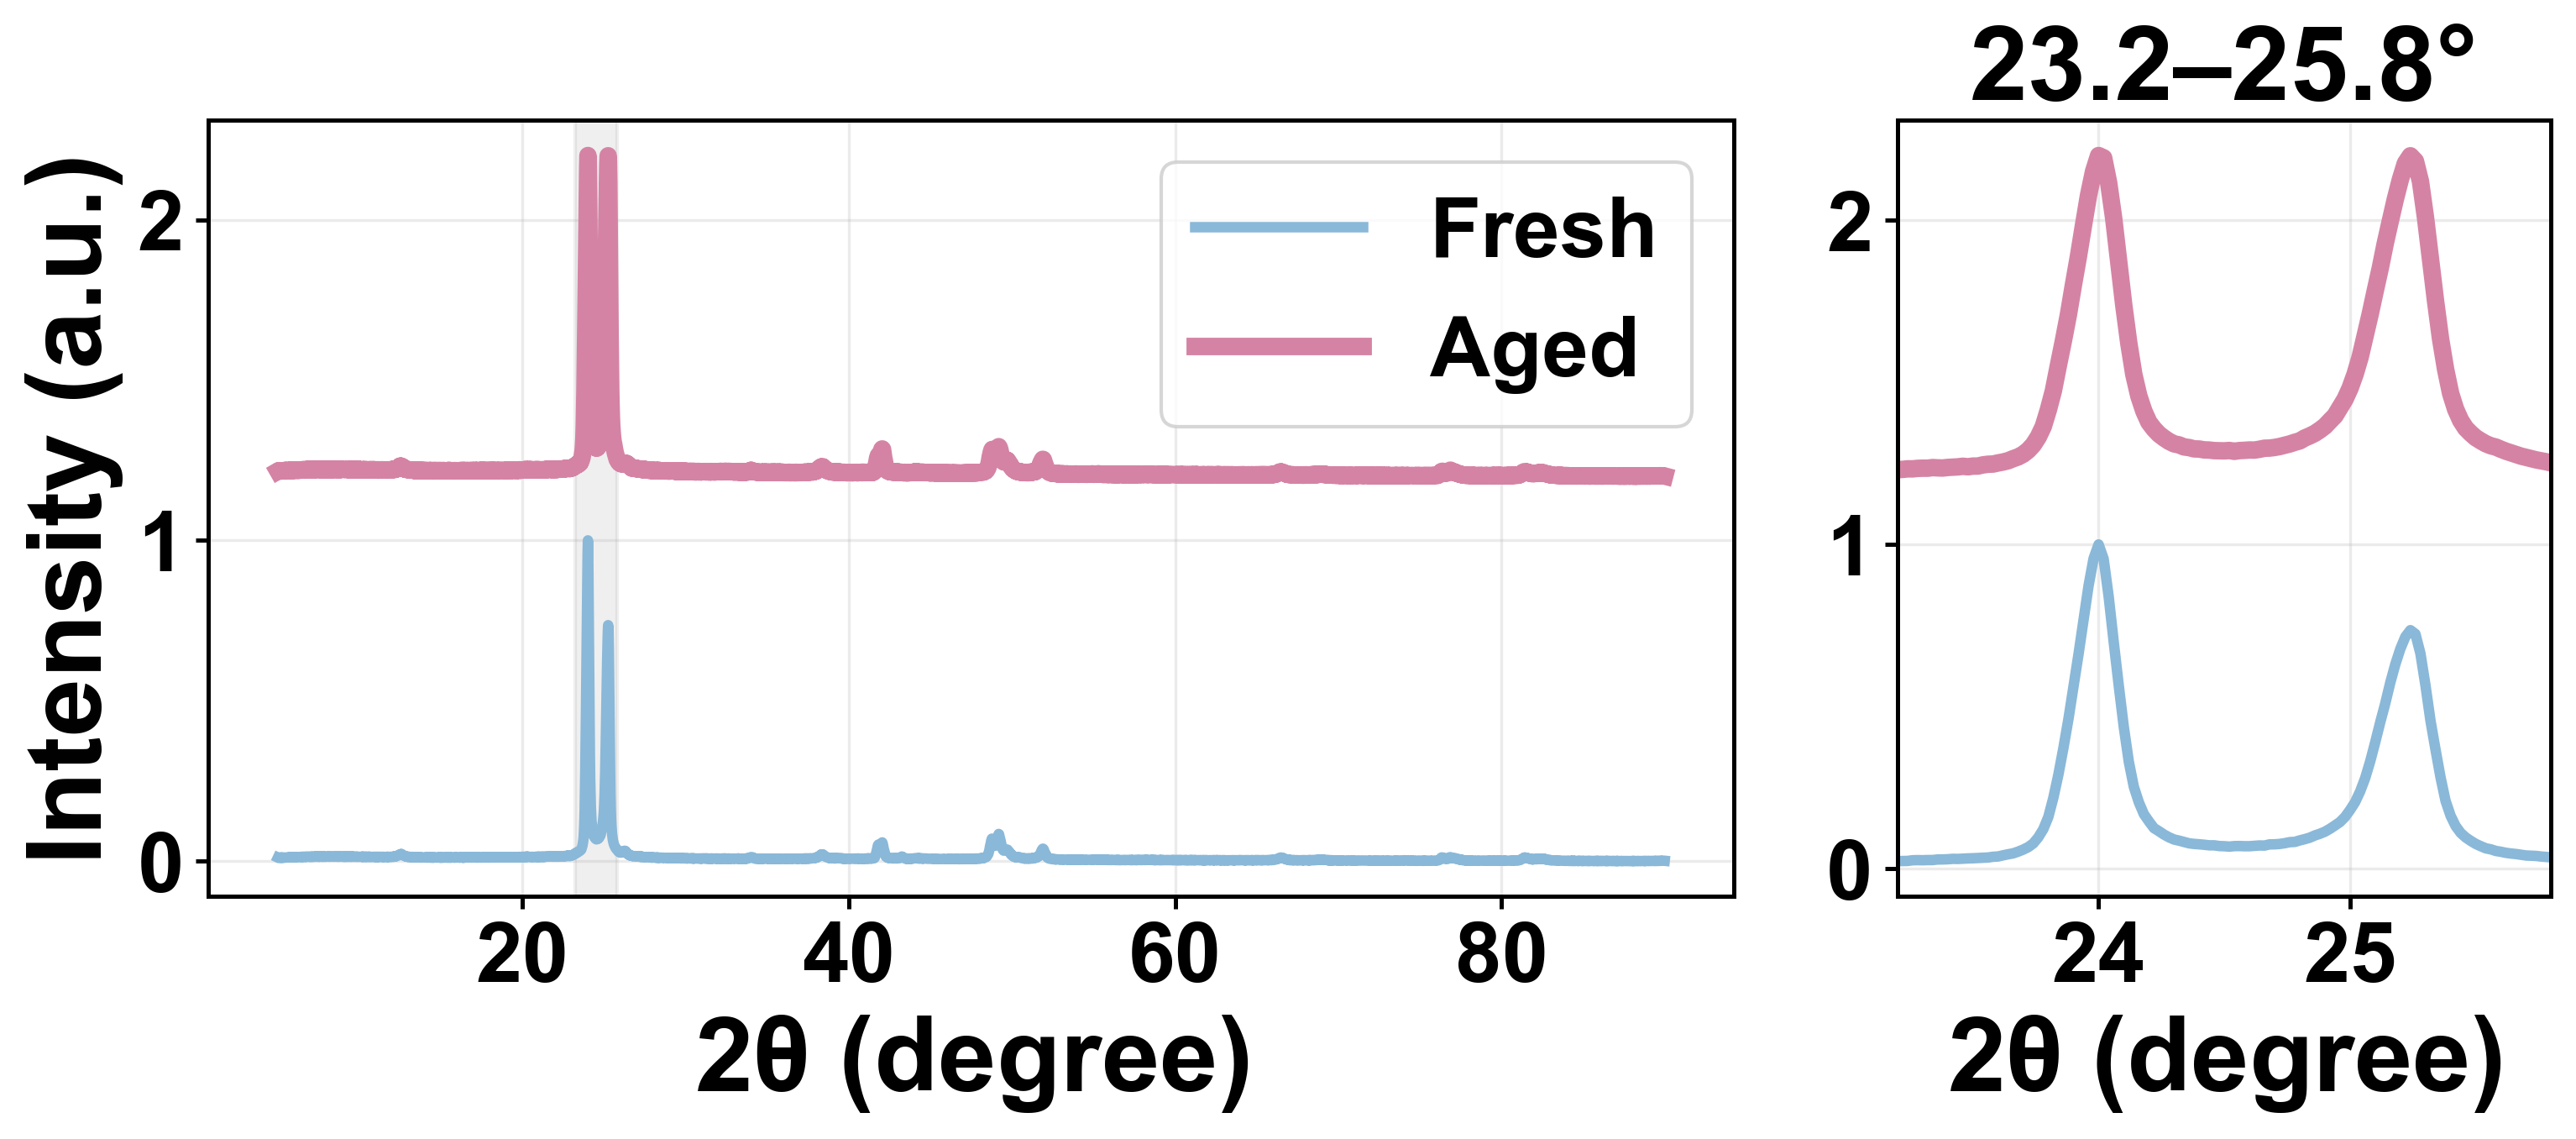

Done.
Figure PNG saved to: c:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\xrd_compare_outputs\Anode_XRD_Fresh_vs_Aged_singleZoom.png
Figure PDF saved to: c:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\xrd_compare_outputs\Anode_XRD_Fresh_vs_Aged_singleZoom.pdf
Peak summary saved to: c:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\xrd_compare_outputs\Anode_XRD_Fresh_vs_Aged_singleZoom_peak_summary.xlsx


In [140]:
# -*- coding: utf-8 -*-
"""
Fresh vs aged anode XRD comparison
Jupyter version - single zoom panel
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 0. USER SETTINGS
# =========================================================

# -------------------------
# Paths
# -------------------------
BASE_DIR = Path.cwd()

FRESH_FILE = BASE_DIR / "C2 -.txt"   # 新鲜负极
AGED_FILE  = BASE_DIR / "C1 -.txt"   # 老化负极

OUTPUT_DIR = BASE_DIR / "xrd_compare_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG  = OUTPUT_DIR / "Anode_XRD_Fresh_vs_Aged_singleZoom.png"
OUT_PDF  = OUTPUT_DIR / "Anode_XRD_Fresh_vs_Aged_singleZoom.pdf"
OUT_XLSX = OUTPUT_DIR / "Anode_XRD_Fresh_vs_Aged_singleZoom_peak_summary.xlsx"


# -------------------------
# Figure layout
# -------------------------
FIGSIZE = (12, 4)   # 可改成 (12, 5)
DPI = 300

# 是否上下错位显示
USE_VERTICAL_OFFSET = True
FRESH_OFFSET = 0.00
AGED_OFFSET  = 1.20 if USE_VERTICAL_OFFSET else 0.00

# 只保留一个放大区域
ZOOM_WINDOW = (23.2, 25.8, "23.2–25.8°")

# 是否显示放大图标题
SHOW_ZOOM_TITLE = True


# -------------------------
# Text style settings
# 所有文字大小、粗细统一在这里改
# -------------------------
FONT_FAMILY = "Arial"

MAIN_XLABEL_SIZE   = 30
MAIN_YLABEL_SIZE   = 30
MAIN_LABEL_WEIGHT  = "bold"

ZOOM_XLABEL_SIZE   = 30
ZOOM_YLABEL_SIZE   = 30
ZOOM_LABEL_WEIGHT  = "bold"

ZOOM_TITLE_SIZE    = 30
ZOOM_TITLE_WEIGHT  = "bold"

LEGEND_SIZE        = 24
LEGEND_WEIGHT      = "bold"

TICK_SIZE_MAIN     = 24
TICK_SIZE_ZOOM     = 24

TICK_WEIGHT_MAIN = "bold"
TICK_WEIGHT_ZOOM = "bold"

SPINE_WIDTH_MAIN   = 1.2
SPINE_WIDTH_ZOOM   = 1.2


# -------------------------
# Line / color style settings
# 所有颜色、线型、线宽统一在这里改
# -------------------------
FRESH_COLOR        = "#8ab8d8"
AGED_COLOR         = "#d583a4"

FRESH_LINESTYLE    = "-"
AGED_LINESTYLE     = "-"

FRESH_LINEWIDTH    = 3
AGED_LINEWIDTH     = 5

ZOOMBOX_COLOR      = "gray"
ZOOMBOX_ALPHA      = 0.12

GRID_ALPHA         = 0.25
GRID_LINESTYLE     = "-"
GRID_LINEWIDTH     = 0.8

LEGEND_FRAMEON     = True

# 保存图片边距
BBOX_INCHES = "tight"


# =========================================================
# 1. FUNCTIONS
# =========================================================

def read_xrd_txt(file_path):
    """
    读取 XRD txt 文件。
    自动跳过 # 开头注释行。
    数据格式：
        2theta   intensity
    """
    file_path = Path(file_path)

    data = []
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue

            parts = line.replace(",", " ").split()
            if len(parts) < 2:
                continue

            try:
                x = float(parts[0])
                y = float(parts[1])
                data.append([x, y])
            except ValueError:
                continue

    arr = np.array(data, dtype=float)
    if arr.size == 0:
        raise ValueError(f"没有读取到有效 XRD 数据：{file_path}")

    df = pd.DataFrame(arr, columns=["two_theta", "intensity"])
    df = df.dropna()
    df = df.sort_values("two_theta").reset_index(drop=True)
    return df


def normalize_intensity(y):
    y = np.asarray(y, dtype=float)
    ymin = np.nanmin(y)
    ymax = np.nanmax(y)

    if not np.isfinite(ymax - ymin) or abs(ymax - ymin) < 1e-12:
        return np.zeros_like(y)

    return (y - ymin) / (ymax - ymin)


def get_window_data(df, x1, x2):
    mask = (df["two_theta"] >= x1) & (df["two_theta"] <= x2)
    return df.loc[mask].copy()


def find_peak_in_window(df, x1, x2, label):
    sub = get_window_data(df, x1, x2)
    if len(sub) == 0:
        return {
            "Sample": label,
            "Window_start_deg": x1,
            "Window_end_deg": x2,
            "Peak_2theta_deg": np.nan,
            "Peak_intensity_raw": np.nan,
        }

    idx = sub["intensity"].idxmax()
    return {
        "Sample": label,
        "Window_start_deg": x1,
        "Window_end_deg": x2,
        "Peak_2theta_deg": df.loc[idx, "two_theta"],
        "Peak_intensity_raw": df.loc[idx, "intensity"],
    }


def set_axes_style(ax, tick_size=10, spine_width=1.2, tick_weight="bold"):
    ax.tick_params(axis="both", labelsize=tick_size, width=spine_width)

    for label in ax.get_xticklabels():
        label.set_fontweight(tick_weight)

    for label in ax.get_yticklabels():
        label.set_fontweight(tick_weight)

    for spine in ax.spines.values():
        spine.set_linewidth(spine_width)

    ax.grid(True, alpha=GRID_ALPHA, linestyle=GRID_LINESTYLE, linewidth=GRID_LINEWIDTH)


# =========================================================
# 2. GLOBAL FONT SETTINGS
# =========================================================

plt.rcParams["font.family"] = FONT_FAMILY
plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 3. READ DATA
# =========================================================

fresh = read_xrd_txt(FRESH_FILE)
aged  = read_xrd_txt(AGED_FILE)

fresh["norm"] = normalize_intensity(fresh["intensity"])
aged["norm"]  = normalize_intensity(aged["intensity"])

fresh["plot_y"] = fresh["norm"] + FRESH_OFFSET
aged["plot_y"]  = aged["norm"]  + AGED_OFFSET


# =========================================================
# 4. PEAK SUMMARY
# =========================================================

x1, x2, zoom_title = ZOOM_WINDOW

peak_tbl = pd.DataFrame([
    find_peak_in_window(fresh, x1, x2, "Fresh anode"),
    find_peak_in_window(aged,  x1, x2, "Aged anode"),
])

peak_tbl.to_excel(OUT_XLSX, index=False)


# =========================================================
# 5. PLOT
# =========================================================

fig = plt.figure(figsize=FIGSIZE, dpi=DPI)

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[3.5, 1.5],
    wspace=0.15,
)

ax_main = fig.add_subplot(gs[0, 0])
ax_zoom = fig.add_subplot(gs[0, 1])

# -------------------------
# Main plot
# -------------------------
ax_main.plot(
    fresh["two_theta"], fresh["plot_y"],
    color=FRESH_COLOR,
    linestyle=FRESH_LINESTYLE,
    linewidth=FRESH_LINEWIDTH,
    label="Fresh",
)

ax_main.plot(
    aged["two_theta"], aged["plot_y"],
    color=AGED_COLOR,
    linestyle=AGED_LINESTYLE,
    linewidth=AGED_LINEWIDTH,
    label="Aged",
)

ax_main.axvspan(x1, x2, color=ZOOMBOX_COLOR, alpha=ZOOMBOX_ALPHA)

ax_main.set_xlabel(r"2$\theta$ (degree)", fontsize=MAIN_XLABEL_SIZE, fontweight=MAIN_LABEL_WEIGHT)
ax_main.set_ylabel("Intensity (a.u.)", fontsize=MAIN_YLABEL_SIZE, fontweight=MAIN_LABEL_WEIGHT)

leg_main = ax_main.legend(frameon=LEGEND_FRAMEON, fontsize=LEGEND_SIZE, loc="upper right")
for txt in leg_main.get_texts():
    txt.set_fontweight(LEGEND_WEIGHT)

set_axes_style(
    ax_main,
    tick_size=TICK_SIZE_MAIN,
    spine_width=SPINE_WIDTH_MAIN,
    tick_weight=TICK_WEIGHT_MAIN
)

set_axes_style(
    ax_zoom,
    tick_size=TICK_SIZE_ZOOM,
    spine_width=SPINE_WIDTH_ZOOM,
    tick_weight=TICK_WEIGHT_ZOOM
)


# -------------------------
# Zoom plot
# -------------------------
sub_fresh = get_window_data(fresh, x1, x2)
sub_aged  = get_window_data(aged,  x1, x2)

ax_zoom.plot(
    sub_fresh["two_theta"], sub_fresh["plot_y"],
    color=FRESH_COLOR,
    linestyle=FRESH_LINESTYLE,
    linewidth=FRESH_LINEWIDTH,
    label="Fresh",
)

ax_zoom.plot(
    sub_aged["two_theta"], sub_aged["plot_y"],
    color=AGED_COLOR,
    linestyle=AGED_LINESTYLE,
    linewidth=AGED_LINEWIDTH,
    label="Aged",
)

ax_zoom.set_xlim(x1, x2)

if SHOW_ZOOM_TITLE:
    ax_zoom.set_title(zoom_title, fontsize=ZOOM_TITLE_SIZE, fontweight=ZOOM_TITLE_WEIGHT)

ax_zoom.set_xlabel(r"2$\theta$ (degree)", fontsize=ZOOM_XLABEL_SIZE, fontweight=ZOOM_LABEL_WEIGHT)

# leg_zoom = ax_zoom.legend(frameon=LEGEND_FRAMEON, fontsize=LEGEND_SIZE, loc="upper right")
# for txt in leg_zoom.get_texts():
#     txt.set_fontweight(LEGEND_WEIGHT)

set_axes_style(ax_zoom, tick_size=TICK_SIZE_ZOOM, spine_width=SPINE_WIDTH_ZOOM)


plt.tight_layout()

# 保存
fig.savefig(OUT_PNG, dpi=DPI, bbox_inches=BBOX_INCHES)
fig.savefig(OUT_PDF, bbox_inches=BBOX_INCHES)

# Jupyter 直接显示
plt.show()

print("Done.")
print(f"Figure PNG saved to: {OUT_PNG}")
print(f"Figure PDF saved to: {OUT_PDF}")
print(f"Peak summary saved to: {OUT_XLSX}")

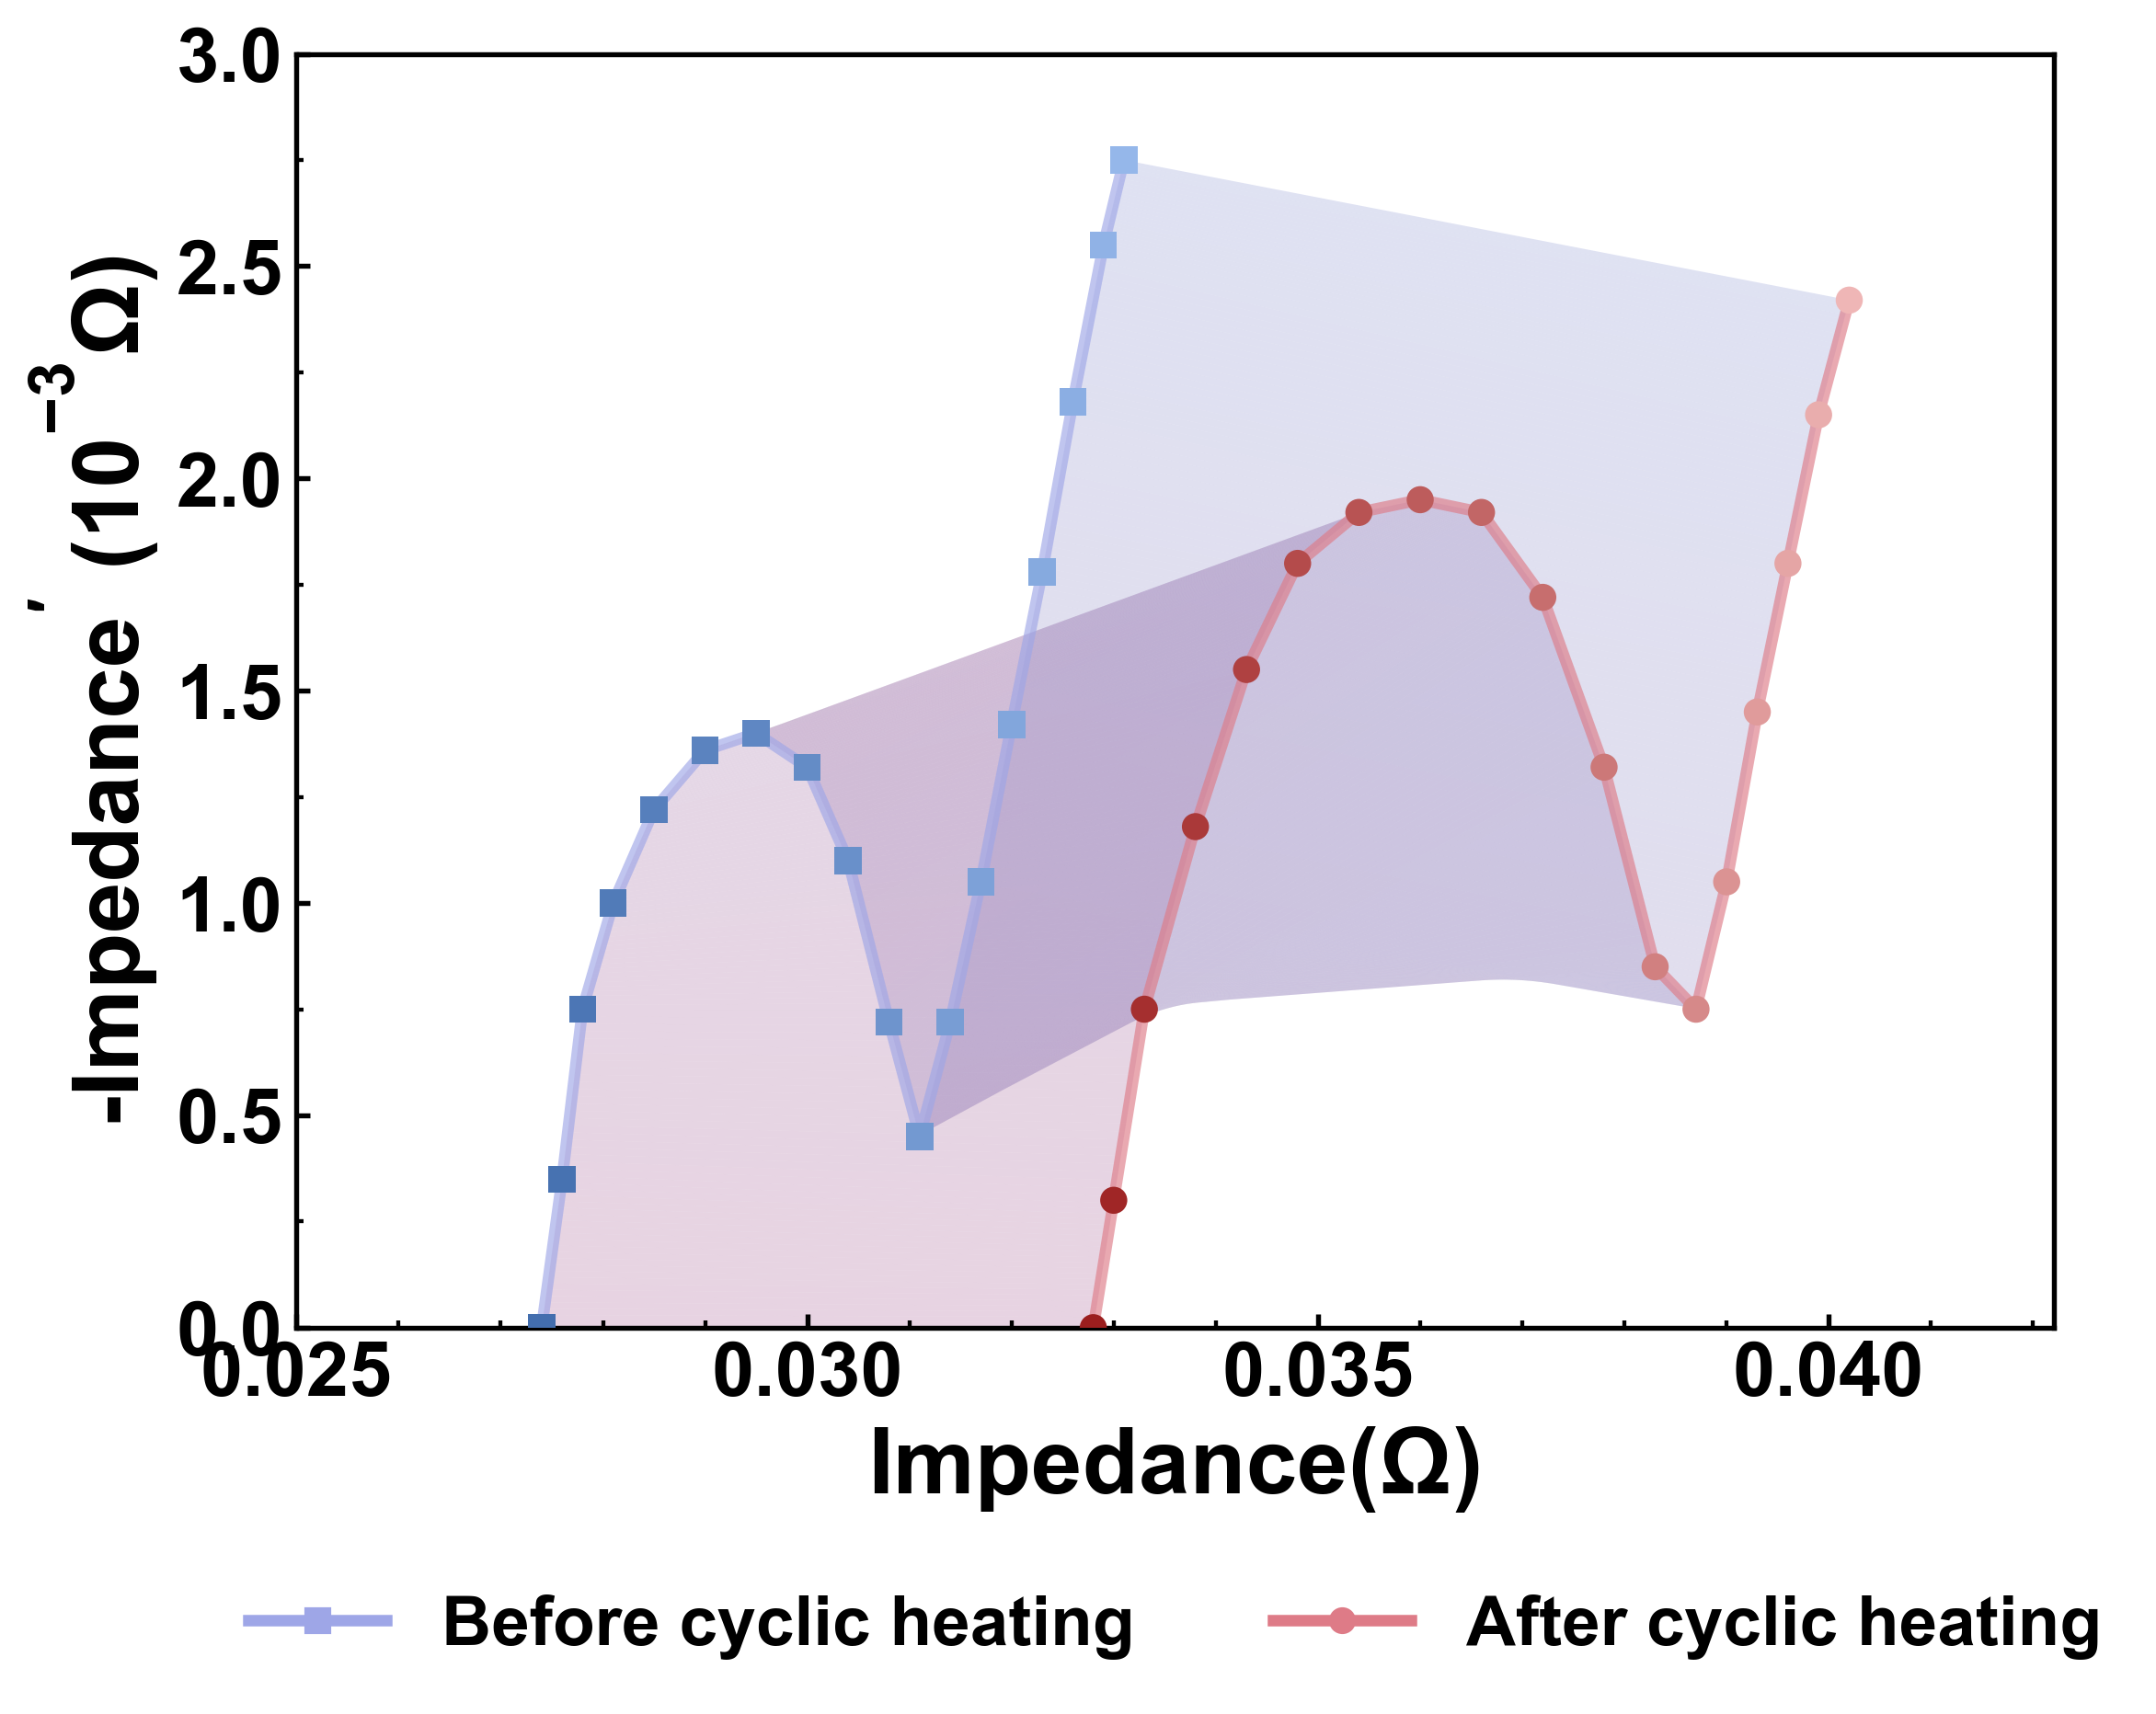

Done.
PNG saved to: c:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\eis_pseudo3d_outputs\EIS_before_after_pseudo3D_fill.png
PDF saved to: c:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\eis_pseudo3d_outputs\EIS_before_after_pseudo3D_fill.pdf
Used point count = 18
Arrow extra per segment = 1
Gradient fill = True, fill alpha = 0.28


In [186]:
# -*- coding: utf-8 -*-
"""
Pseudo-3D EIS plot with embedded data
- points use custom gradient colors
- arrows use custom gradient colors
- arrows include original point-to-point arrows + interpolated arrows
- continuous gradient fill between two EIS curves
- axis tick intervals are adjustable
- y-axis can be displayed in scientific scale
- all parameters are placed at the top
- Jupyter direct display
"""

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.collections import PolyCollection


# =========================================================
# 0. USER SETTINGS
# =========================================================

# -------------------------
# Embedded data
# Format: [Zre, -Zim]
# Order: high frequency -> low frequency
# The i-th point in BEFORE corresponds to the i-th point in AFTER
# -------------------------
BEFORE_POINTS = np.array([
    [0.0274, 0.0000],
    [0.0276, 0.00035],
    [0.0278, 0.00075],
    [0.0281, 0.00100],
    [0.0285, 0.00122],
    [0.0290, 0.00136],
    [0.0295, 0.00140],
    [0.0300, 0.00132],
    [0.0304, 0.00110],
    [0.0308, 0.00072],
    [0.0311, 0.00045],
    [0.0314, 0.00072],
    [0.0317, 0.00105],
    [0.0320, 0.00142],
    [0.0323, 0.00178],
    [0.0326, 0.00218],
    [0.0329, 0.00255],
    [0.0331, 0.00275],
], dtype=float)

AFTER_POINTS = np.array([
    [0.0328, 0.0000],
    [0.0330, 0.00030],
    [0.0333, 0.00075],
    [0.0338, 0.00118],
    [0.0343, 0.00155],
    [0.0348, 0.00180],
    [0.0354, 0.00192],
    [0.0360, 0.00195],
    [0.0366, 0.00192],
    [0.0372, 0.00172],
    [0.0378, 0.00132],
    [0.0383, 0.00085],
    [0.0387, 0.00075],
    [0.0390, 0.00105],
    [0.0393, 0.00145],
    [0.0396, 0.00180],
    [0.0399, 0.00215],
    [0.0402, 0.00242],
], dtype=float)

AUTO_TRIM_TO_SAME_LENGTH = True


# -------------------------
# Output / figure settings
# -------------------------
BASE_DIR = Path.cwd()

OUTPUT_DIR = BASE_DIR / "eis_pseudo3d_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUTPUT_DIR / "EIS_before_after_pseudo3D_fill.png"
OUT_PDF = OUTPUT_DIR / "EIS_before_after_pseudo3D_fill.pdf"

FIGSIZE = (8, 7)
DPI = 300
BBOX_INCHES = "tight"

X_LIM = (0.025, 0.0422)
Y_LIM = (0.0000, 0.0030)

SHOW_TITLE = False
TITLE_TEXT = ""

SHOW_GRID = False
SHOW_LEGEND = True


# -------------------------
# Axis tick settings
# 横纵坐标显示间距
# -------------------------
X_MAJOR_INTERVAL = 0.005
X_MINOR_INTERVAL = 0.001

Y_MAJOR_INTERVAL = 0.0005
Y_MINOR_INTERVAL = 0.00025

X_TICK_DECIMALS = 3

# 纵轴科学计数法
Y_USE_SCI_FORMAT = True
Y_SCI_FACTOR = 1e-3
Y_TICK_DECIMALS_SCI = 1

# 如果不用科学计数法，纵轴保留几位小数
Y_TICK_DECIMALS_NORMAL = 4


# -------------------------
# Text style settings
# -------------------------
FONT_FAMILY = "Arial"

XLABEL_TEXT = "Impedance(Ω)"
YLABEL_TEXT = r"-Impedance$^\prime$ ($10^{-3}$Ω)"
# 如果你想恢复普通标签，用这一行：
# YLABEL_TEXT = "-Impedance′(Ω)"

XLABEL_SIZE = 24
YLABEL_SIZE = 24
LABEL_WEIGHT = "bold"

TICK_SIZE = 20
TICK_WEIGHT = "bold"

LEGEND_SIZE = 18
LEGEND_WEIGHT = "bold"
LEGEND_LOC = "lower right"

SPINE_WIDTH = 1.3


SHOW_LEGEND = True

LEGEND_LOC = "upper center"
LEGEND_BBOX_TO_ANCHOR = (0.5, -0.16)   # x=0.5 居中；y 越小越往下
LEGEND_NCOL = 2                        # 两个 legend 横向排列
LEGEND_FRAMEON = False

# -------------------------
# Base curve settings
# -------------------------
SHOW_BASE_CURVE = True

BEFORE_BASE_COLOR = "#9EA6E7"
AFTER_BASE_COLOR  = "#DE7B87"

BEFORE_LINESTYLE = "-"
AFTER_LINESTYLE  = "-"

BEFORE_LINEWIDTH = 3
AFTER_LINEWIDTH  = 3

BEFORE_LINE_ALPHA = 0.65
AFTER_LINE_ALPHA  = 0.65


# -------------------------
# Point settings
# -------------------------
SHOW_POINTS = True

BEFORE_MARKER = "s"
AFTER_MARKER  = "o"

BEFORE_MARKER_SIZE = 50
AFTER_MARKER_SIZE  = 50

MARKER_EDGE_COLOR = "none"
MARKER_EDGE_WIDTH = 0.0

POINTS_USE_GRADIENT = True
POINTS_USE_CUSTOM_GRADIENT = True

# BEFORE 点渐变：高频端 -> 低频端
BEFORE_POINT_START_COLOR = "#3360A2"
BEFORE_POINT_END_COLOR   = "#9DBEF0"

# AFTER 点渐变：高频端 -> 低频端
AFTER_POINT_START_COLOR  = "#8b0000"
AFTER_POINT_END_COLOR    = "#f7c6c6"

# 如果 POINTS_USE_CUSTOM_GRADIENT = False，才会使用下面两个 colormap 名称
BEFORE_POINTS_CMAP = "Blues"
AFTER_POINTS_CMAP  = "Reds"

# 控制点渐变不要太淡
POINT_GRADIENT_MIN = 0.15
POINT_GRADIENT_MAX = 0.92

# True: 高频更接近 start_color，低频更接近 end_color
POINT_HIGH_TO_LOW = True


# -------------------------
# Gradient filled area between two curves
# 两条 EIS 曲线之间的连续渐变填充
# -------------------------
DRAW_GRADIENT_FILL = True

FILL_STEPS = 400
FILL_ALPHA = 0.28
FILL_ZORDER = 0.5

# 填充渐变色：高频端 -> 低频端
FILL_START_COLOR = "#b55283"
FILL_END_COLOR   = "#85a2e0"

# 控制填充颜色不要太淡
FILL_GRADIENT_MIN = 0.22
FILL_GRADIENT_MAX = 0.86

# True: 高频端用 FILL_START_COLOR，低频端用 FILL_END_COLOR
FILL_HIGH_TO_LOW = True

FILL_EDGE_COLOR = "none"


# -------------------------
# Arrow settings
# -------------------------
DRAW_ARROWS = False

# 原始点对点箭头
ARROW_INCLUDE_ORIGINAL_POINTS = True

# 每隔几个原始点画箭头；1 = 每个点都画
ARROW_STEP = 1

# 除了原始点对点箭头外，在相邻点之间插入额外箭头
# 0 = 不插值，只画原始点对点
# 1 = 每两个相邻点之间额外插 1 根
# 2 = 每两个相邻点之间额外插 2 根
ARROW_EXTRA_PER_SEGMENT = 1

ARROW_SKIP_FIRST_N = 0
ARROW_SKIP_LAST_N  = 0

ARROW_ALPHA = 0.95
ARROW_LINEWIDTH = 3
ARROW_HEAD_SCALE = 12

ARROW_USE_GRADIENT_COLOR = True
ARROW_USE_CUSTOM_GRADIENT = True

# 箭头渐变：高频端 -> 低频端
ARROW_START_COLOR = "#b55283"
ARROW_END_COLOR   = "#85a2e0"

# 箭头绘制顺序
# "highfreq_on_top": 高频端最后画，压在上面
# "lowfreq_on_top" : 低频端最后画，压在上面
ARROW_DRAW_ORDER = "highfreq_on_top"

# 如果 ARROW_USE_CUSTOM_GRADIENT = False，才会使用这个 colormap
ARROW_CMAP = "Reds"

ARROW_FIXED_COLOR = "#ff4d4d"

# 控制箭头渐变不要太淡
ARROW_GRADIENT_MIN = 0.30
ARROW_GRADIENT_MAX = 0.92

# True: 高频用 start_color，低频用 end_color
ARROW_HIGH_TO_LOW = True


# =========================================================
# 1. FUNCTIONS
# =========================================================

def make_df(points, label):
    n = points.shape[0]
    df = pd.DataFrame(points, columns=["Zre", "MinusZim"])
    df["FrequencyOrder"] = np.linspace(1.0, 0.0, n)   # 1 = high freq, 0 = low freq
    df["Sample"] = label
    return df


def trim_two_dfs(df1, df2):
    if len(df1) == len(df2):
        return df1.copy(), df2.copy()

    if not AUTO_TRIM_TO_SAME_LENGTH:
        raise ValueError("The two datasets have different lengths. Please align them manually.")

    n = min(len(df1), len(df2))
    return df1.iloc[:n].reset_index(drop=True), df2.iloc[:n].reset_index(drop=True)


def build_custom_cmap(start_color, end_color, cmap_name="custom_cmap"):
    return LinearSegmentedColormap.from_list(cmap_name, [start_color, end_color])


def map_order_to_color_values(order_vals, high_to_low=True):
    """
    order_vals: 1(high freq) -> 0(low freq)
    return normalized values in [0,1]
    """
    order_vals = np.asarray(order_vals, dtype=float)

    if high_to_low:
        # high freq -> start color, low freq -> end color
        return 1.0 - order_vals
    else:
        return order_vals


def apply_gradient_range(cval, cmin, cmax):
    return cmin + cval * (cmax - cmin)


def get_point_colors(order_vals, use_gradient, use_custom_gradient,
                     start_color, end_color, cmap_name,
                     grad_min, grad_max, high_to_low,
                     fallback_color):
    """
    Return RGBA colors for points.
    """
    if not use_gradient:
        return fallback_color

    cval = map_order_to_color_values(order_vals, high_to_low=high_to_low)
    cval_use = apply_gradient_range(cval, grad_min, grad_max)

    if use_custom_gradient:
        cmap = build_custom_cmap(start_color, end_color, cmap_name="custom_point_cmap")
    else:
        cmap = cm.get_cmap(cmap_name)

    return cmap(cval_use)


def set_axes_style(ax):
    ax.tick_params(
        axis="both",
        labelsize=TICK_SIZE,
        width=SPINE_WIDTH,
        which="major",
        direction="in"
    )

    ax.tick_params(
        axis="both",
        width=SPINE_WIDTH * 0.8,
        which="minor",
        direction="in"
    )

    # ---------- tick interval ----------
    if X_MAJOR_INTERVAL is not None:
        ax.xaxis.set_major_locator(MultipleLocator(X_MAJOR_INTERVAL))
    if X_MINOR_INTERVAL is not None:
        ax.xaxis.set_minor_locator(MultipleLocator(X_MINOR_INTERVAL))

    if Y_MAJOR_INTERVAL is not None:
        ax.yaxis.set_major_locator(MultipleLocator(Y_MAJOR_INTERVAL))
    if Y_MINOR_INTERVAL is not None:
        ax.yaxis.set_minor_locator(MultipleLocator(Y_MINOR_INTERVAL))

    # ---------- tick label format ----------
    ax.xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x:.{X_TICK_DECIMALS}f}")
    )

    if Y_USE_SCI_FORMAT:
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda y, pos: f"{y / Y_SCI_FACTOR:.{Y_TICK_DECIMALS_SCI}f}")
        )
    else:
        ax.yaxis.set_major_formatter(
            FuncFormatter(lambda y, pos: f"{y:.{Y_TICK_DECIMALS_NORMAL}f}")
        )

    # ---------- tick label font weight ----------
    for lab in ax.get_xticklabels():
        lab.set_fontweight(TICK_WEIGHT)
    for lab in ax.get_yticklabels():
        lab.set_fontweight(TICK_WEIGHT)

    for spine in ax.spines.values():
        spine.set_linewidth(SPINE_WIDTH)

    if SHOW_GRID:
        ax.grid(True, alpha=0.25)


def plot_curve_and_points(ax, df, base_color, linestyle, linewidth,
                          marker, marker_size,
                          use_gradient, use_custom_gradient,
                          start_color, end_color, cmap_name,
                          grad_min, grad_max, high_to_low,
                          label, line_alpha):
    """
    Plot base curve + optional gradient points.
    """
    if SHOW_BASE_CURVE:
        ax.plot(
            df["Zre"], df["MinusZim"],
            color=base_color,
            linestyle=linestyle,
            linewidth=linewidth,
            alpha=line_alpha,
            zorder=2.0
        )

    point_colors = get_point_colors(
        order_vals=df["FrequencyOrder"].values,
        use_gradient=use_gradient,
        use_custom_gradient=use_custom_gradient,
        start_color=start_color,
        end_color=end_color,
        cmap_name=cmap_name,
        grad_min=grad_min,
        grad_max=grad_max,
        high_to_low=high_to_low,
        fallback_color=base_color
    )

    if SHOW_POINTS:
        ax.scatter(
            df["Zre"], df["MinusZim"],
            c=point_colors,
            s=marker_size,
            marker=marker,
            edgecolors=MARKER_EDGE_COLOR,
            linewidths=MARKER_EDGE_WIDTH,
            zorder=4.0,
            label=label
        )


def interpolate_points(points, idx_float):
    """
    Interpolate a point on a polyline by fractional index.
    idx_float = 0 means point 0.
    idx_float = 1.5 means midpoint between point 1 and point 2.
    """
    n = len(points)

    if idx_float <= 0:
        return points[0, 0], points[0, 1]
    if idx_float >= n - 1:
        return points[-1, 0], points[-1, 1]

    i0 = int(np.floor(idx_float))
    i1 = i0 + 1
    a = idx_float - i0

    x = (1.0 - a) * points[i0, 0] + a * points[i1, 0]
    y = (1.0 - a) * points[i0, 1] + a * points[i1, 1]

    return x, y


def add_gradient_fill_between_curves(ax, before_df, after_df):
    """
    Fill the area between before/after EIS curves using many small
    quadrilateral patches with continuous gradient colors.

    This is more suitable than fill_between because the two EIS curves
    are two matched 2D polylines, not upper/lower functions of the same x.
    """
    if not DRAW_GRADIENT_FILL:
        return

    before_points = before_df[["Zre", "MinusZim"]].values
    after_points  = after_df[["Zre", "MinusZim"]].values

    n = min(len(before_points), len(after_points))
    if n < 2:
        return

    idx_vals = np.linspace(0, n - 1, FILL_STEPS + 1)

    polys = []
    color_vals = []

    for j in range(len(idx_vals) - 1):
        idx0 = idx_vals[j]
        idx1 = idx_vals[j + 1]

        xb0, yb0 = interpolate_points(before_points, idx0)
        xb1, yb1 = interpolate_points(before_points, idx1)

        xa0, ya0 = interpolate_points(after_points, idx0)
        xa1, ya1 = interpolate_points(after_points, idx1)

        # Small quadrilateral:
        # before(idx0) -> before(idx1) -> after(idx1) -> after(idx0)
        poly = [
            [xb0, yb0],
            [xb1, yb1],
            [xa1, ya1],
            [xa0, ya0],
        ]
        polys.append(poly)

        # idx=0 高频端，idx=n-1 低频端
        order_val = 1.0 - ((idx0 + idx1) / 2.0) / max(n - 1, 1)
        cval = map_order_to_color_values(order_val, high_to_low=FILL_HIGH_TO_LOW)
        cval = apply_gradient_range(cval, FILL_GRADIENT_MIN, FILL_GRADIENT_MAX)
        color_vals.append(float(cval))

    cmap_fill = build_custom_cmap(
        FILL_START_COLOR,
        FILL_END_COLOR,
        cmap_name="custom_fill_cmap"
    )

    facecolors = [cmap_fill(v) for v in color_vals]

    pc = PolyCollection(
        polys,
        facecolors=facecolors,
        edgecolors=FILL_EDGE_COLOR,
        alpha=FILL_ALPHA,
        zorder=FILL_ZORDER
    )

    ax.add_collection(pc)


def add_all_arrows(ax, before_df, after_df):
    """
    Add arrows from before to after.
    Includes original point-to-point arrows and optional interpolated arrows.
    Arrow draw order can be controlled so that one color range appears on top.
    """
    if not DRAW_ARROWS:
        return

    before_points = before_df[["Zre", "MinusZim"]].values
    after_points  = after_df[["Zre", "MinusZim"]].values

    n = min(len(before_points), len(after_points))

    start_i = ARROW_SKIP_FIRST_N
    end_i = n - 1 - ARROW_SKIP_LAST_N

    if end_i < start_i:
        return

    idx_float_list = []

    for i in range(start_i, end_i + 1, ARROW_STEP):

        # original point-to-point arrow
        if ARROW_INCLUDE_ORIGINAL_POINTS:
            idx_float_list.append(float(i))

        # interpolated arrows between i and i+1
        if i < end_i and ARROW_EXTRA_PER_SEGMENT > 0:
            for k in range(1, ARROW_EXTRA_PER_SEGMENT + 1):
                frac = k / (ARROW_EXTRA_PER_SEGMENT + 1)
                idx_float_list.append(i + frac)

    idx_float_arr = np.array(idx_float_list, dtype=float)

    # idx=0 -> high frequency side
    # idx=n-1 -> low frequency side
    order_vals = 1.0 - idx_float_arr / max(n - 1, 1)

    cval = map_order_to_color_values(order_vals, high_to_low=ARROW_HIGH_TO_LOW)
    cval_use = apply_gradient_range(cval, ARROW_GRADIENT_MIN, ARROW_GRADIENT_MAX)

    if ARROW_USE_GRADIENT_COLOR:
        if ARROW_USE_CUSTOM_GRADIENT:
            cmap_arrow = build_custom_cmap(
                ARROW_START_COLOR,
                ARROW_END_COLOR,
                cmap_name="custom_arrow_cmap"
            )
        else:
            cmap_arrow = cm.get_cmap(ARROW_CMAP)

    # --------------------------------------------------
    # control draw order
    # highfreq_on_top: draw low-frequency arrows first, then high-frequency arrows
    # lowfreq_on_top : draw high-frequency arrows first, then low-frequency arrows
    # --------------------------------------------------
    draw_indices = np.arange(len(idx_float_arr))

    if ARROW_DRAW_ORDER == "highfreq_on_top":
        # low freq first, high freq last
        sort_key = order_vals
        draw_indices = draw_indices[np.argsort(sort_key)]
    elif ARROW_DRAW_ORDER == "lowfreq_on_top":
        # high freq first, low freq last
        sort_key = order_vals
        draw_indices = draw_indices[np.argsort(sort_key)[::-1]]

    for j in draw_indices:
        idxf = idx_float_arr[j]

        xb, yb = interpolate_points(before_points, idxf)
        xa, ya = interpolate_points(after_points,  idxf)

        if ARROW_USE_GRADIENT_COLOR:
            color_arrow = cmap_arrow(cval_use[j])
        else:
            color_arrow = ARROW_FIXED_COLOR

        arrow = FancyArrowPatch(
            (xb, yb),
            (xa, ya),
            arrowstyle="-|>",
            mutation_scale=ARROW_HEAD_SCALE,
            linewidth=ARROW_LINEWIDTH,
            color=color_arrow,
            alpha=ARROW_ALPHA,
            zorder=3.0
        )
        ax.add_patch(arrow)


# =========================================================
# 2. GLOBAL FONT SETTINGS
# =========================================================

plt.rcParams["font.family"] = FONT_FAMILY
plt.rcParams["axes.unicode_minus"] = False


# =========================================================
# 3. BUILD DATA
# =========================================================

before_df = make_df(BEFORE_POINTS, "Before cyclic heating")
after_df  = make_df(AFTER_POINTS,  "After cyclic heating")

before_df, after_df = trim_two_dfs(before_df, after_df)


# =========================================================
# 4. PLOT
# =========================================================

fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

# 先画填充，放在最底层
add_gradient_fill_between_curves(ax, before_df, after_df)

# 再画两条边界线和可选点
plot_curve_and_points(
    ax=ax,
    df=before_df,
    base_color=BEFORE_BASE_COLOR,
    linestyle=BEFORE_LINESTYLE,
    linewidth=BEFORE_LINEWIDTH,
    marker=BEFORE_MARKER,
    marker_size=BEFORE_MARKER_SIZE,
    use_gradient=POINTS_USE_GRADIENT,
    use_custom_gradient=POINTS_USE_CUSTOM_GRADIENT,
    start_color=BEFORE_POINT_START_COLOR,
    end_color=BEFORE_POINT_END_COLOR,
    cmap_name=BEFORE_POINTS_CMAP,
    grad_min=POINT_GRADIENT_MIN,
    grad_max=POINT_GRADIENT_MAX,
    high_to_low=POINT_HIGH_TO_LOW,
    label="Before cyclic heating",
    line_alpha=BEFORE_LINE_ALPHA
)

plot_curve_and_points(
    ax=ax,
    df=after_df,
    base_color=AFTER_BASE_COLOR,
    linestyle=AFTER_LINESTYLE,
    linewidth=AFTER_LINEWIDTH,
    marker=AFTER_MARKER,
    marker_size=AFTER_MARKER_SIZE,
    use_gradient=POINTS_USE_GRADIENT,
    use_custom_gradient=POINTS_USE_CUSTOM_GRADIENT,
    start_color=AFTER_POINT_START_COLOR,
    end_color=AFTER_POINT_END_COLOR,
    cmap_name=AFTER_POINTS_CMAP,
    grad_min=POINT_GRADIENT_MIN,
    grad_max=POINT_GRADIENT_MAX,
    high_to_low=POINT_HIGH_TO_LOW,
    label="After cyclic heating",
    line_alpha=AFTER_LINE_ALPHA
)

# 最后画箭头
add_all_arrows(ax, before_df, after_df)

ax.set_xlabel(XLABEL_TEXT, fontsize=XLABEL_SIZE, fontweight=LABEL_WEIGHT)
ax.set_ylabel(YLABEL_TEXT, fontsize=YLABEL_SIZE, fontweight=LABEL_WEIGHT)

if SHOW_TITLE:
    ax.set_title(TITLE_TEXT)

if X_LIM is not None:
    ax.set_xlim(X_LIM)
if Y_LIM is not None:
    ax.set_ylim(Y_LIM)

set_axes_style(ax)

if SHOW_LEGEND:
    legend_handles = [
        Line2D(
            [0], [0],
            color=BEFORE_BASE_COLOR,
            linestyle=BEFORE_LINESTYLE,
            linewidth=BEFORE_LINEWIDTH,
            marker="" if not SHOW_POINTS else BEFORE_MARKER,
            markersize=6,
            label="Before cyclic heating"
        ),
        Line2D(
            [0], [0],
            color=AFTER_BASE_COLOR,
            linestyle=AFTER_LINESTYLE,
            linewidth=AFTER_LINEWIDTH,
            marker="" if not SHOW_POINTS else AFTER_MARKER,
            markersize=6,
            label="After cyclic heating"
        ),
    ]

    leg = ax.legend(
        handles=legend_handles,
        frameon=LEGEND_FRAMEON,
        fontsize=LEGEND_SIZE,
        loc=LEGEND_LOC,
        bbox_to_anchor=LEGEND_BBOX_TO_ANCHOR,
        ncol=LEGEND_NCOL
    )

    for txt in leg.get_texts():
        txt.set_fontweight(LEGEND_WEIGHT)

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(OUT_PNG, dpi=DPI, bbox_inches=BBOX_INCHES)
fig.savefig(OUT_PDF, bbox_inches=BBOX_INCHES)

plt.show()

print("Done.")
print(f"PNG saved to: {OUT_PNG}")
print(f"PDF saved to: {OUT_PDF}")
print(f"Used point count = {len(before_df)}")
print(f"Arrow extra per segment = {ARROW_EXTRA_PER_SEGMENT}")
print(f"Gradient fill = {DRAW_GRADIENT_FILL}, fill alpha = {FILL_ALPHA}")

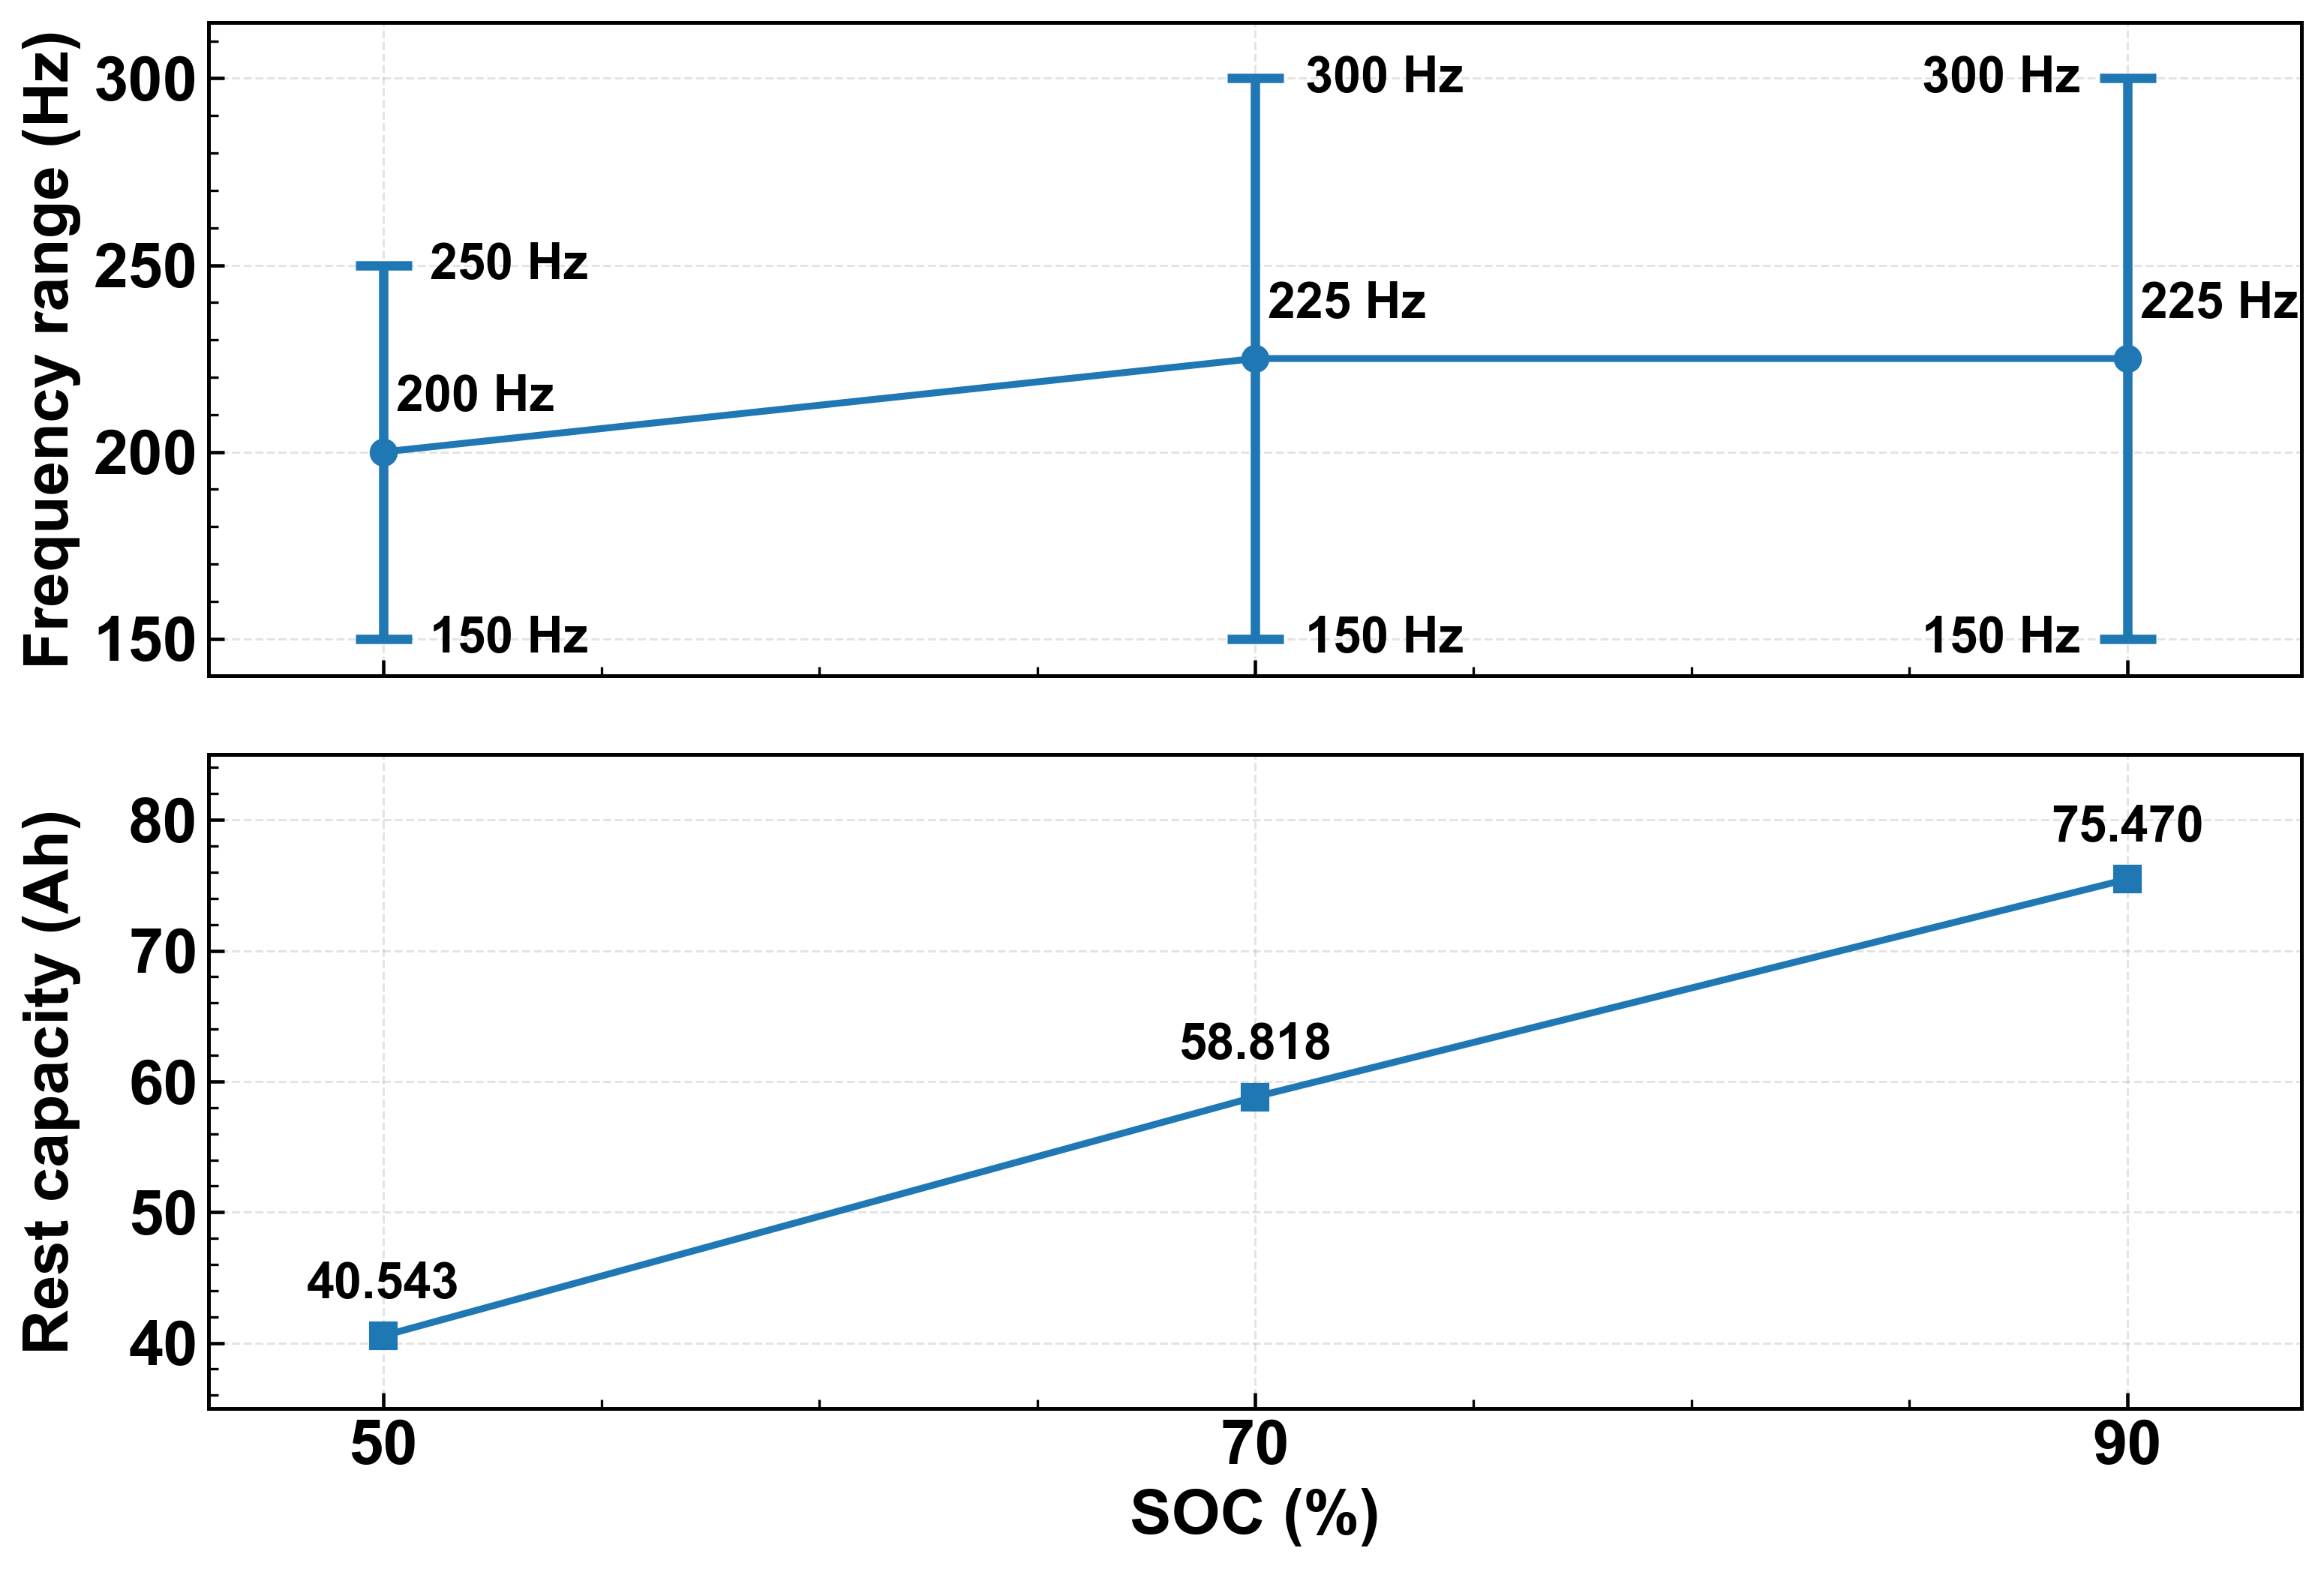

PNG saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\SOC_frequency_range_and_discharge_capacity.png
PDF saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\SOC_frequency_range_and_discharge_capacity.pdf


In [118]:
# -*- coding: utf-8 -*-
"""
Two vertically stacked plots:

Upper plot:
    Variable-frequency range represented by:
    1. Interval midpoint line
    2. Error bars showing lower and upper frequency limits

Lower plot:
    Discharge capacity after test

The overall figure ratio is 3:2.
"""

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# 0. USER SETTINGS
# =========================================================

# ---------- Output ----------
OUTPUT_DIR = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = "SOC_frequency_range_and_discharge_capacity"


# ---------- Figure ----------
FIGSIZE = (12, 8)       # Overall aspect ratio = 3:2
DPI = 300

LINE_WIDTH = 2.2
MARKER_SIZE = 8

AXIS_LABEL_SIZE = 20
TICK_LABEL_SIZE = 20
LEGEND_SIZE = 11
ANNOTATION_SIZE = 16

# Error-bar appearance
CAP_SIZE = 9
CAP_THICKNESS = 3
ERROR_LINE_WIDTH = 3

# Distance between the two subplots
SUBPLOT_HSPACE = 0.12

# Whether to show grid lines
SHOW_GRID = True


# =========================================================
# 1. DATA
# =========================================================

soc = np.array([50, 70, 90])

# Variable-frequency range
frequency_lower = np.array([150, 150, 150])
frequency_upper = np.array([250, 300, 300])

# Interval midpoint
frequency_midpoint = (
    frequency_lower + frequency_upper
) / 2.0

# Error-bar distances
frequency_error_lower = (
    frequency_midpoint - frequency_lower
)

frequency_error_upper = (
    frequency_upper - frequency_midpoint
)

frequency_error = np.vstack([
    frequency_error_lower,
    frequency_error_upper
])

# Discharge capacity after test
discharge_capacity = np.array([
    40.543,
    58.818,
    75.470
])


# =========================================================
# 2. CREATE FIGURE
# =========================================================

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=FIGSIZE,
    dpi=DPI,
    sharex=True,
    gridspec_kw={
        "height_ratios": [1, 1],
        "hspace": SUBPLOT_HSPACE
    }
)


# =========================================================
# 3. UPPER PLOT: VARIABLE-FREQUENCY RANGE
# =========================================================

frequency_line = ax1.errorbar(
    soc,
    frequency_midpoint,
    yerr=frequency_error,

    fmt="o-",
    linewidth=LINE_WIDTH,
    markersize=MARKER_SIZE,

    capsize=CAP_SIZE,
    capthick=CAP_THICKNESS,
    elinewidth=ERROR_LINE_WIDTH,

    label="Frequency range"
)

ax1.set_ylabel(
    "Frequency range (Hz)",
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

# Leave sufficient space for the 300 Hz upper cap
ax1.set_ylim(140, 315)

# Frequency-range annotations
for i, (x, low, mid, high) in enumerate(zip(
    soc,
    frequency_lower,
    frequency_midpoint,
    frequency_upper
)):
    # ===== 中点标注 =====
    ax1.annotate(
        f"{mid:.0f} Hz",
        xy=(x, mid),
        xytext=(4, 10),
        textcoords="offset points",
        ha="left",
        va="bottom",
        fontsize=ANNOTATION_SIZE,
        fontweight="bold"
    )

    # ===== 上下限左右分开 =====
    if i == 0:
        # 第1个点：上下限放左侧
        high_offset = (15, 0)
        high_ha = "left"

        low_offset = (15, 0)
        low_ha = "left"

    elif i == 1:
        # 第2个点：上下限放右侧
        high_offset = (16, 0)
        high_ha = "left"

        low_offset = (16, 0)
        low_ha = "left"

    else:
        # 第3个点：可以继续放左侧，避免又堆在一边
        high_offset = (-15, 0)
        high_ha = "right"

        low_offset = (-15, 0)
        low_ha = "right"

    # 上限
    ax1.annotate(
        f"{high:.0f} Hz",
        xy=(x, high),
        xytext=high_offset,
        textcoords="offset points",
        ha=high_ha,
        va="center",
        fontsize=ANNOTATION_SIZE,
        fontweight="bold"
    )

    # 下限
    ax1.annotate(
        f"{low:.0f} Hz",
        xy=(x, low),
        xytext=low_offset,
        textcoords="offset points",
        ha=low_ha,
        va="center",
        fontsize=ANNOTATION_SIZE,
        fontweight="bold"
    )

# legend1 = ax1.legend(
#     loc="lower right",
#     prop={
#         "size": LEGEND_SIZE,
#         "weight": "bold"
#     },
#     frameon=True,
#     fancybox=False,
#     framealpha=0.95
# )

# legend1.get_frame().set_linewidth(0.8)


# =========================================================
# 4. LOWER PLOT: DISCHARGE CAPACITY
# =========================================================

capacity_line, = ax2.plot(
    soc,
    discharge_capacity,
    marker="s",
    linewidth=LINE_WIDTH,
    markersize=MARKER_SIZE,
    label="Rest capacity"
)

ax2.set_xlabel(
    "SOC (%)",
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

ax2.set_ylabel(
    "Rest capacity (Ah)",
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

ax2.set_ylim(35, 85)

# Capacity annotations
for x, value in zip(soc, discharge_capacity):
    ax2.annotate(
        f"{value:.3f}",
        xy=(x, value),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=ANNOTATION_SIZE,
        fontweight="bold"
    )

# legend2 = ax2.legend(
#     loc="lower right",
#     prop={
#         "size": LEGEND_SIZE,
#         "weight": "bold"
#     },
#     frameon=True,
#     fancybox=False,
#     framealpha=0.95
# )

# legend2.get_frame().set_linewidth(0.8)


# =========================================================
# 5. AXIS SETTINGS
# =========================================================

ax2.set_xticks(soc)
ax2.set_xticklabels([
    "50",
    "70",
    "90"
])

# Add a small horizontal margin
ax1.set_xlim(46, 94)

for ax in (ax1, ax2):

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=TICK_LABEL_SIZE,
        direction="in",
        length=5,
        width=1.1
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        length=3,
        width=0.8
    )

    ax.minorticks_on()

    # Bold tick labels
    plt.setp(
        ax.get_xticklabels(),
        fontweight="bold"
    )

    plt.setp(
        ax.get_yticklabels(),
        fontweight="bold"
    )

    # Border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    if SHOW_GRID:
        ax.grid(
            True,
            which="major",
            linestyle="--",
            linewidth=0.7,
            alpha=0.35
        )


# The upper plot shares the x-axis, so hide its x tick labels
ax1.tick_params(
    axis="x",
    labelbottom=False
)


# =========================================================
# 6. SAVE AND SHOW
# =========================================================

fig.align_ylabels([ax1, ax2])

png_path = OUTPUT_DIR / f"{OUTPUT_NAME}.png"
pdf_path = OUTPUT_DIR / f"{OUTPUT_NAME}.pdf"

fig.savefig(
    png_path,
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"PNG saved to:\n{png_path}")
print(f"PDF saved to:\n{pdf_path}")


Capacity oscillation and trend statistics
Mean:                50.726400 Ah
Variance:            0.00057530 Ah²
Standard deviation:  0.023985 Ah
Mean ± std:          [50.702415, 50.750385] Ah
Trend slope:         0.00039333 Ah/cycle
Fitted total change: 0.023600 Ah
R²:                  0.151269
Classification:      Nearly stationary oscillation


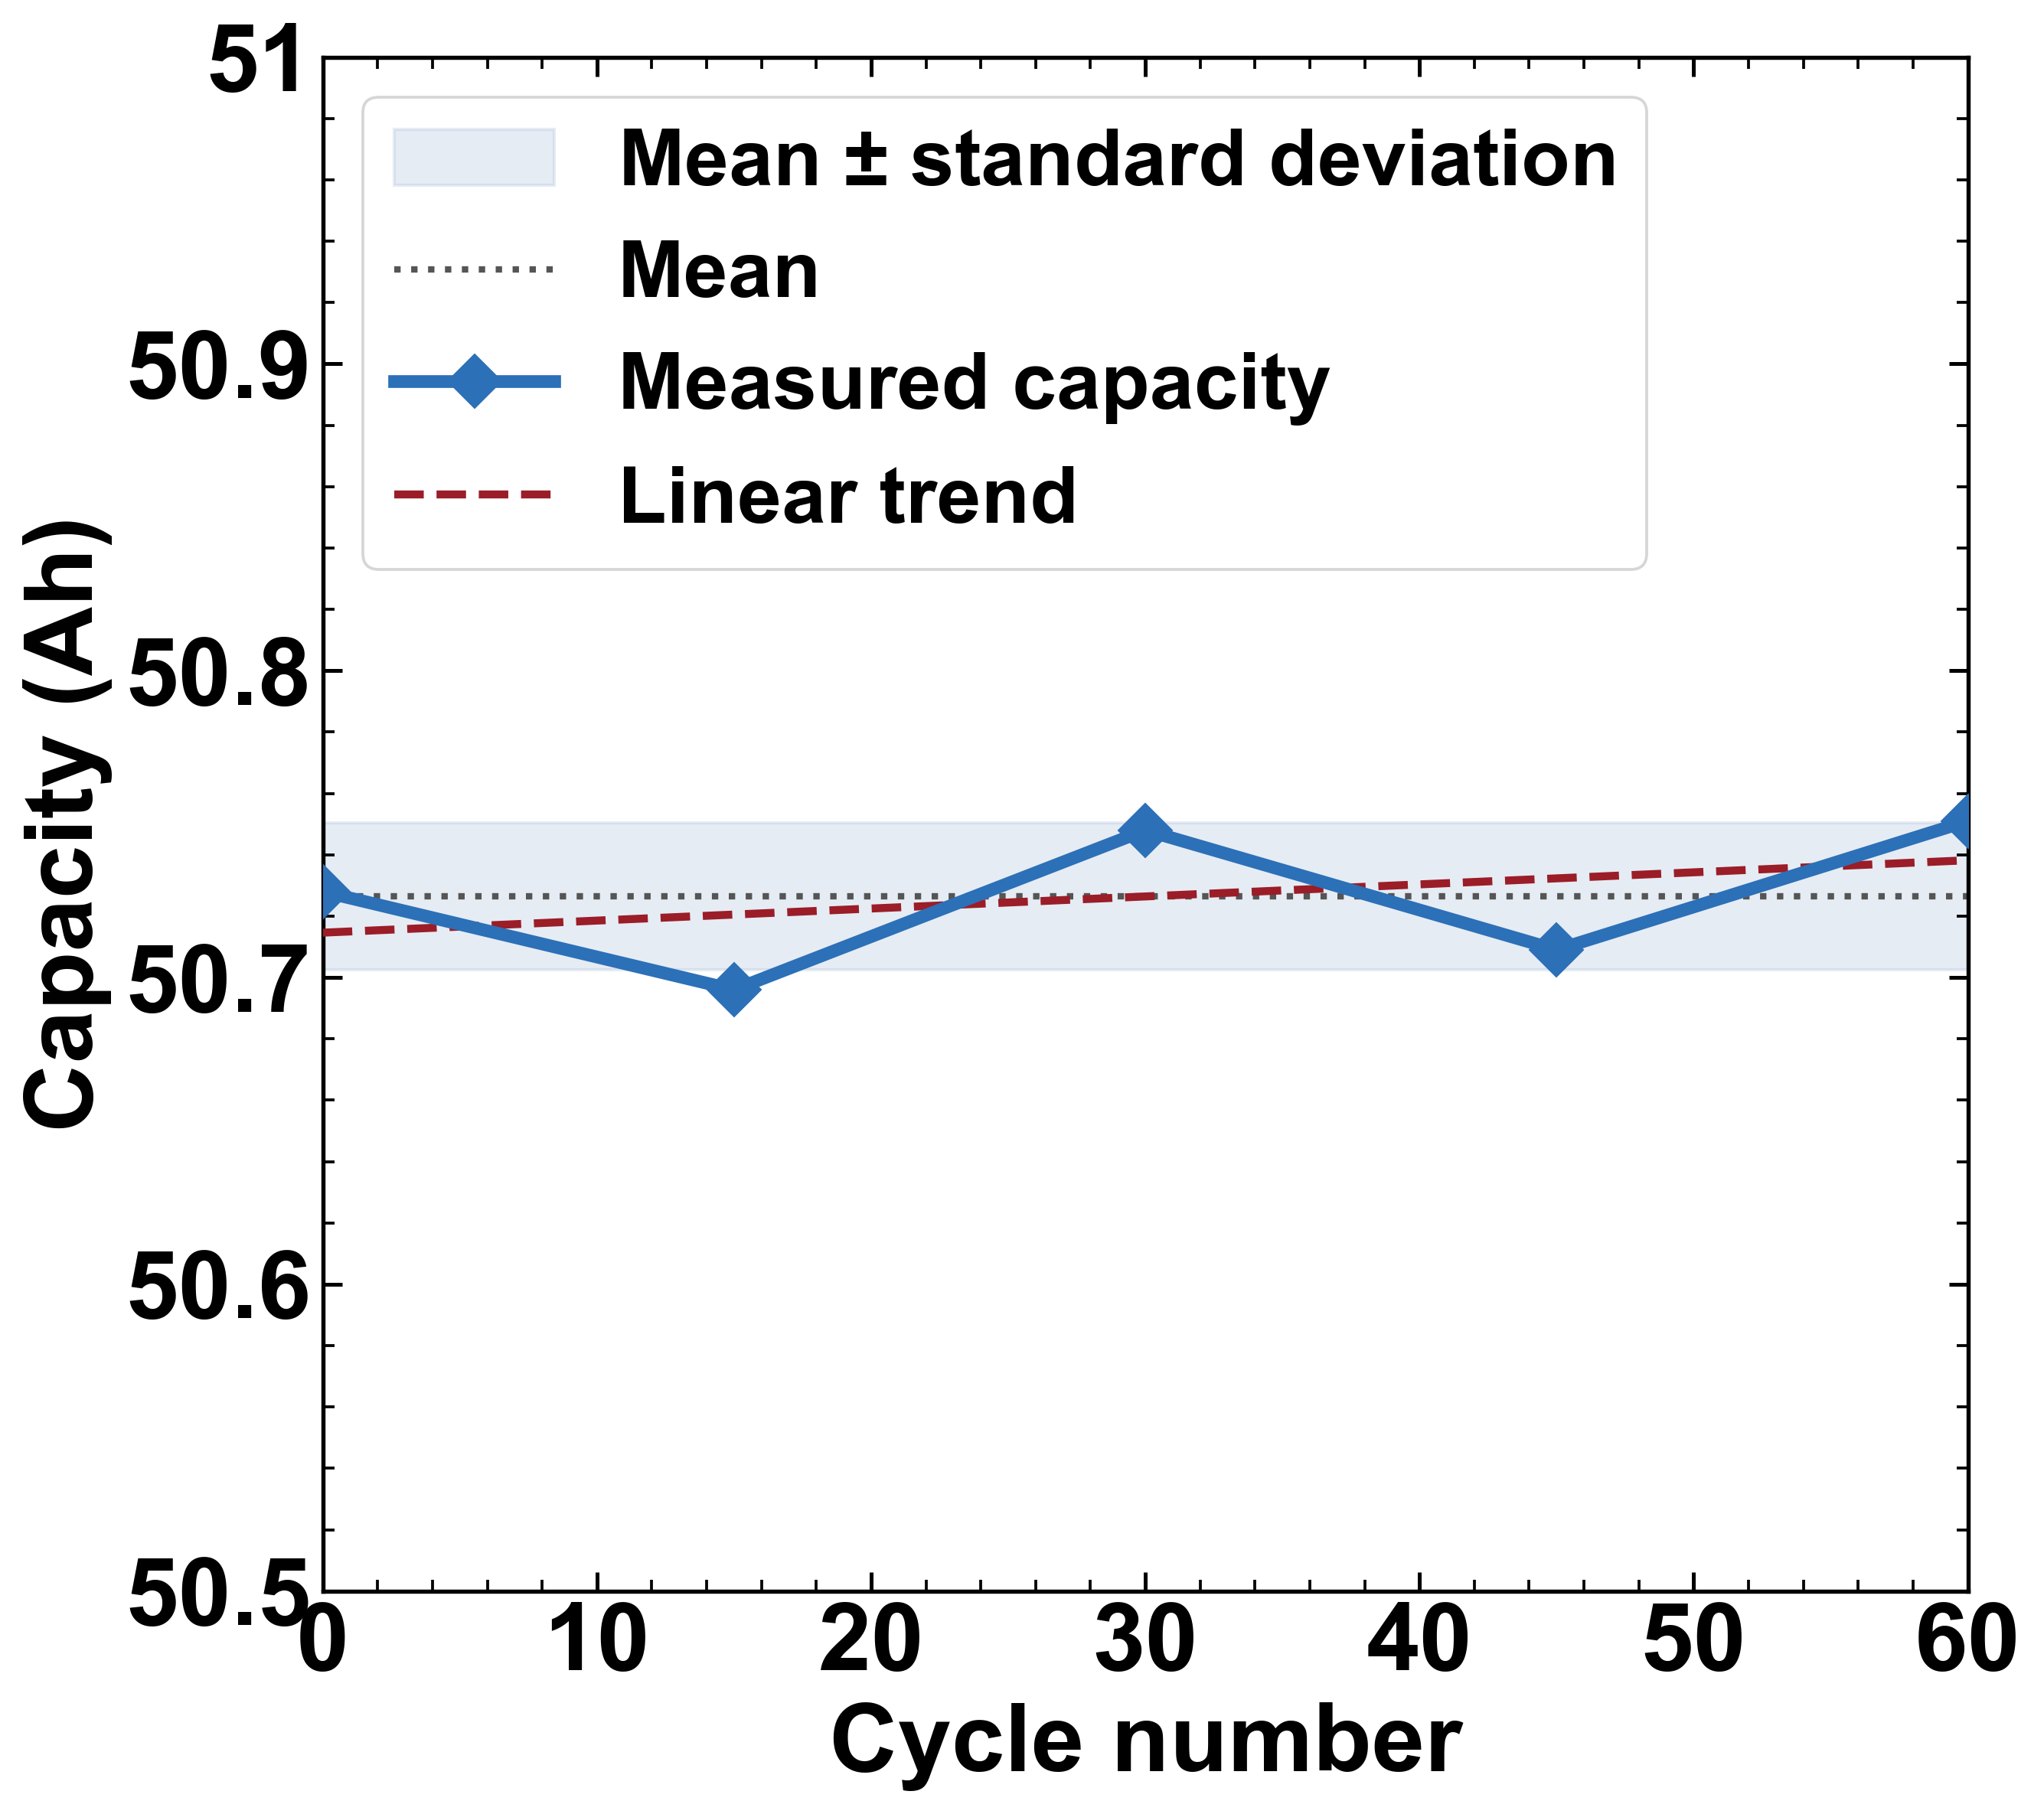


PNG saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Battery_capacity_vs_cycle_number_with_trend.png
PDF saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Battery_capacity_vs_cycle_number_with_trend.pdf


In [262]:
# -*- coding: utf-8 -*-
"""
Battery capacity versus cycle number.

Added features:
1. Linear dashed trend line.
2. Mean-capacity line.
3. Mean ± standard deviation oscillation band.
4. Annotation of mean, variance, standard deviation, slope,
   fitted total change, R², and trend classification.
"""

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter


# =========================================================
# 0. ALL USER-ADJUSTABLE SETTINGS
# =========================================================

# ---------------------------------------------------------
# Output
# ---------------------------------------------------------
OUTPUT_DIR = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = "Battery_capacity_vs_cycle_number_with_trend"

SAVE_PNG = True
SAVE_PDF = True

DPI = 300
BBOX_INCHES = "tight"
PAD_INCHES = 0.10


# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
FIGSIZE = (9, 8)

FIG_FACE_COLOR = "white"
AX_FACE_COLOR = "white"


# ---------------------------------------------------------
# Original capacity curve
# ---------------------------------------------------------
DATA_LINE_WIDTH = 4.0
DATA_MARKER = "D"
DATA_MARKER_SIZE = 11
DATA_MARKER_EDGE_WIDTH = 1.5

DATA_COLOR = "#2C70B7"
DATA_LABEL = "Measured capacity"


# ---------------------------------------------------------
# Trend line
# ---------------------------------------------------------
SHOW_TREND_LINE = True

TREND_LINE_COLOR = "#9A1D28"
TREND_LINE_STYLE = "--"
TREND_LINE_WIDTH = 2.5
TREND_LINE_LABEL = "Linear trend"

TREND_DENSE_POINTS = 500


# ---------------------------------------------------------
# Mean and oscillation interval
# ---------------------------------------------------------
SHOW_MEAN_LINE = True
SHOW_OSCILLATION_BAND = True

MEAN_LINE_COLOR = "#555555"
MEAN_LINE_STYLE = ":"
MEAN_LINE_WIDTH = 2.0
MEAN_LINE_LABEL = "Mean"

BAND_COLOR = "#A8BDD8"
BAND_ALPHA = 0.28
BAND_LABEL = r"Mean $\pm$ standard deviation"


# ---------------------------------------------------------
# Statistical calculation
# ---------------------------------------------------------
# 0: population variance
# 1: sample variance
VARIANCE_DDOF = 1

# Trend classification:
# If |fitted total change| <= this factor × standard deviation,
# classify it as nearly stationary oscillation.
STATIONARY_CHANGE_STD_RATIO = 1.0


# ---------------------------------------------------------
# Statistical annotation
# ---------------------------------------------------------
SHOW_STATISTICS_TEXT = False

STATISTICS_TEXT_POSITION = (0.97, 0.05)

STATISTICS_TEXT_SIZE = 13
STATISTICS_TEXT_COLOR = "black"
STATISTICS_TEXT_WEIGHT = "bold"

STATISTICS_TEXT_BOX = {
    "facecolor": "white",
    "edgecolor": "black",
    "boxstyle": "square,pad=0.40",
    "alpha": 0.92,
}


# ---------------------------------------------------------
# Axis labels
# ---------------------------------------------------------
X_LABEL = "Cycle number"
Y_LABEL = "Capacity (Ah)"

AXIS_LABEL_SIZE = 30
TICK_LABEL_SIZE = 30


# ---------------------------------------------------------
# Axis ranges
# ---------------------------------------------------------
X_LIM = (0, 60)
Y_LIM = (50.5, 51.0)


# ---------------------------------------------------------
# Tick intervals
# ---------------------------------------------------------
X_MAJOR_INTERVAL = 10
X_MINOR_INTERVAL = 2

Y_MAJOR_INTERVAL = 0.1
Y_MINOR_INTERVAL = 0.02


# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------
SHOW_LEGEND = True

LEGEND_LOCATION = "upper left"
LEGEND_FONT_SIZE = 25
LEGEND_FRAMEON = True
LEGEND_NCOL = 1


# ---------------------------------------------------------
# Grid
# ---------------------------------------------------------
SHOW_GRID = False

GRID_MAJOR_LINESTYLE = "-"
GRID_MAJOR_LINEWIDTH = 0.7
GRID_MAJOR_ALPHA = 0.40

GRID_MINOR_LINESTYLE = "--"
GRID_MINOR_LINEWIDTH = 0.6
GRID_MINOR_ALPHA = 0.35


# ---------------------------------------------------------
# Axis appearance
# ---------------------------------------------------------
SPINE_WIDTH = 1.3

MAJOR_TICK_LENGTH = 6
MAJOR_TICK_WIDTH = 1.2

MINOR_TICK_LENGTH = 3.5
MINOR_TICK_WIDTH = 0.9


# =========================================================
# 1. DATA
# =========================================================

cycle_number = np.array(
    [
        0,
        15,
        30,
        45,
        60,
    ],
    dtype=float,
)

battery_capacity = np.array(
    [
        50.728,
        50.696,
        50.748,
        50.709,
        50.751,
    ],
    dtype=float,
)


# =========================================================
# 2. DATA CHECK
# =========================================================

if len(cycle_number) != len(battery_capacity):
    raise ValueError(
        "cycle_number and battery_capacity must have equal lengths."
    )

valid_mask = (
    np.isfinite(cycle_number)
    & np.isfinite(battery_capacity)
)

x_valid = cycle_number[valid_mask]
y_valid = battery_capacity[valid_mask]

if len(x_valid) < 2:
    raise ValueError(
        "At least two valid data points are required."
    )

if np.any(np.diff(x_valid) <= 0):
    raise ValueError(
        "Cycle numbers must be strictly increasing."
    )


# =========================================================
# 3. STATISTICS AND TREND
# =========================================================

# Expected value
capacity_mean = float(
    np.mean(y_valid)
)

# Variance and standard deviation
capacity_variance = float(
    np.var(
        y_valid,
        ddof=VARIANCE_DDOF,
    )
)

capacity_std = float(
    np.std(
        y_valid,
        ddof=VARIANCE_DDOF,
    )
)

band_lower = (
    capacity_mean
    - capacity_std
)

band_upper = (
    capacity_mean
    + capacity_std
)


# Linear fitting
trend_slope, trend_intercept = np.polyfit(
    x_valid,
    y_valid,
    1,
)

trend_x = np.linspace(
    x_valid.min(),
    x_valid.max(),
    TREND_DENSE_POINTS,
)

trend_y = (
    trend_slope * trend_x
    + trend_intercept
)


# Predicted values at original points
fitted_values = (
    trend_slope * x_valid
    + trend_intercept
)

residual_sum_squares = float(
    np.sum(
        (y_valid - fitted_values) ** 2
    )
)

total_sum_squares = float(
    np.sum(
        (y_valid - capacity_mean) ** 2
    )
)

if total_sum_squares > 0:
    r_squared = (
        1.0
        - residual_sum_squares
        / total_sum_squares
    )
else:
    r_squared = np.nan


# Total fitted change over the entire cycle range
fitted_total_change = float(
    trend_slope
    * (
        x_valid[-1]
        - x_valid[0]
    )
)


# ---------------------------------------------------------
# Trend classification
# ---------------------------------------------------------
stationary_threshold = (
    STATIONARY_CHANGE_STD_RATIO
    * capacity_std
)

if abs(fitted_total_change) <= stationary_threshold:
    trend_description = "Nearly stationary oscillation"

elif trend_slope < 0:
    trend_description = "Decreasing trend"

else:
    trend_description = "Increasing trend"


# =========================================================
# 4. PRINT RESULTS
# =========================================================

print("\n" + "=" * 72)
print("Capacity oscillation and trend statistics")
print("=" * 72)

print(
    f"Mean:                "
    f"{capacity_mean:.6f} Ah"
)

print(
    f"Variance:            "
    f"{capacity_variance:.8f} Ah²"
)

print(
    f"Standard deviation:  "
    f"{capacity_std:.6f} Ah"
)

print(
    f"Mean ± std:          "
    f"[{band_lower:.6f}, {band_upper:.6f}] Ah"
)

print(
    f"Trend slope:         "
    f"{trend_slope:.8f} Ah/cycle"
)

print(
    f"Fitted total change: "
    f"{fitted_total_change:.6f} Ah"
)

print(
    f"R²:                  "
    f"{r_squared:.6f}"
)

print(
    f"Classification:      "
    f"{trend_description}"
)

print("=" * 72)


# =========================================================
# 5. CREATE FIGURE
# =========================================================

fig, ax = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI,
    facecolor=FIG_FACE_COLOR,
)

ax.set_facecolor(
    AX_FACE_COLOR
)


# ---------------------------------------------------------
# Oscillation band
# ---------------------------------------------------------
if SHOW_OSCILLATION_BAND:
    ax.axhspan(
        band_lower,
        band_upper,
        color=BAND_COLOR,
        alpha=BAND_ALPHA,
        label=BAND_LABEL,
        zorder=1,
    )


# ---------------------------------------------------------
# Mean line
# ---------------------------------------------------------
if SHOW_MEAN_LINE:
    ax.axhline(
        y=capacity_mean,
        color=MEAN_LINE_COLOR,
        linestyle=MEAN_LINE_STYLE,
        linewidth=MEAN_LINE_WIDTH,
        label=MEAN_LINE_LABEL,
        zorder=2,
    )


# ---------------------------------------------------------
# Original data
# ---------------------------------------------------------
ax.plot(
    x_valid,
    y_valid,
    color=DATA_COLOR,
    marker=DATA_MARKER,
    linewidth=DATA_LINE_WIDTH,
    markersize=DATA_MARKER_SIZE,
    markeredgewidth=DATA_MARKER_EDGE_WIDTH,
    label=DATA_LABEL,
    zorder=5,
)


# ---------------------------------------------------------
# Trend line
# ---------------------------------------------------------
if SHOW_TREND_LINE:
    ax.plot(
        trend_x,
        trend_y,
        color=TREND_LINE_COLOR,
        linestyle=TREND_LINE_STYLE,
        linewidth=TREND_LINE_WIDTH,
        label=TREND_LINE_LABEL,
        zorder=4,
    )


# =========================================================
# 6. AXIS LABELS
# =========================================================

ax.set_xlabel(
    X_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold",
)

ax.set_ylabel(
    Y_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold",
)


# =========================================================
# 7. AXIS LIMITS AND TICKS
# =========================================================

ax.set_xlim(
    *X_LIM
)

ax.set_ylim(
    *Y_LIM
)


ax.xaxis.set_major_locator(
    MultipleLocator(
        X_MAJOR_INTERVAL
    )
)

ax.xaxis.set_minor_locator(
    MultipleLocator(
        X_MINOR_INTERVAL
    )
)

ax.yaxis.set_major_locator(
    MultipleLocator(
        Y_MAJOR_INTERVAL
    )
)

ax.yaxis.set_minor_locator(
    MultipleLocator(
        Y_MINOR_INTERVAL
    )
)


# Display 51 instead of 51.0
def y_tick_formatter(value, position):
    if abs(
        value
        - round(value)
    ) < 1e-8:
        return f"{value:.0f}"

    return f"{value:.1f}"


ax.yaxis.set_major_formatter(
    FuncFormatter(
        y_tick_formatter
    )
)


# =========================================================
# 8. STATISTICAL ANNOTATION
# =========================================================

if SHOW_STATISTICS_TEXT:
    statistics_text = (
        f"Mean = {capacity_mean:.4f} Ah\n"
        f"Variance = {capacity_variance:.2e} Ah²\n"
        f"Std. dev. = {capacity_std:.4f} Ah\n"
        f"Slope = {trend_slope:.2e} Ah/cycle\n"
        f"Fitted Δ = {fitted_total_change:+.4f} Ah\n"
        f"$R^2$ = {r_squared:.3f}\n"
        f"{trend_description}"
    )

    ax.text(
        STATISTICS_TEXT_POSITION[0],
        STATISTICS_TEXT_POSITION[1],
        statistics_text,

        transform=ax.transAxes,

        ha="right",
        va="bottom",

        fontsize=STATISTICS_TEXT_SIZE,
        fontweight=STATISTICS_TEXT_WEIGHT,
        color=STATISTICS_TEXT_COLOR,

        bbox=STATISTICS_TEXT_BOX,
        zorder=10,
    )


# =========================================================
# 9. TICK AND BORDER STYLE
# =========================================================

ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    length=MAJOR_TICK_LENGTH,
    width=MAJOR_TICK_WIDTH,
    labelsize=TICK_LABEL_SIZE,
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=MINOR_TICK_LENGTH,
    width=MINOR_TICK_WIDTH,
)


plt.setp(
    ax.get_xticklabels(),
    fontweight="bold",
)

plt.setp(
    ax.get_yticklabels(),
    fontweight="bold",
)


for spine in ax.spines.values():
    spine.set_linewidth(
        SPINE_WIDTH
    )


# =========================================================
# 10. GRID
# =========================================================

if SHOW_GRID:
    ax.grid(
        True,
        which="major",
        linestyle=GRID_MAJOR_LINESTYLE,
        linewidth=GRID_MAJOR_LINEWIDTH,
        alpha=GRID_MAJOR_ALPHA,
    )

    ax.grid(
        True,
        which="minor",
        linestyle=GRID_MINOR_LINESTYLE,
        linewidth=GRID_MINOR_LINEWIDTH,
        alpha=GRID_MINOR_ALPHA,
    )


# =========================================================
# 11. LEGEND
# =========================================================

if SHOW_LEGEND:
    legend = ax.legend(
        loc=LEGEND_LOCATION,
        ncol=LEGEND_NCOL,
        fontsize=LEGEND_FONT_SIZE,
        frameon=LEGEND_FRAMEON,
    )

    legend.get_frame().set_linewidth(
        0.9
    )

    for legend_text in legend.get_texts():
        legend_text.set_fontweight(
            "bold"
        )


# =========================================================
# 12. SAVE AND SHOW
# =========================================================

fig.tight_layout()

png_path = (
    OUTPUT_DIR
    / f"{OUTPUT_NAME}.png"
)

pdf_path = (
    OUTPUT_DIR
    / f"{OUTPUT_NAME}.pdf"
)


if SAVE_PNG:
    fig.savefig(
        png_path,
        dpi=DPI,
        bbox_inches=BBOX_INCHES,
        pad_inches=PAD_INCHES,
    )


if SAVE_PDF:
    fig.savefig(
        pdf_path,
        bbox_inches=BBOX_INCHES,
        pad_inches=PAD_INCHES,
    )


plt.show()
plt.close(fig)

print(f"\nPNG saved to:\n{png_path}")
print(f"PDF saved to:\n{pdf_path}")

Input file:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\模组加热策略_温度数据_SOC07_20230212_1518.csv
Requested data rows: 85000–88100
Requested number of rows: 3101
CSV file read successfully
Encoding:  utf-16
Separator: '\t'
Rows read: 88100
Columns:   18

Valid numeric data count:
  Sensor1: 3101 valid, 0 missing
  Sensor2: 3101 valid, 0 missing
  Sensor3: 3101 valid, 0 missing
  Sensor4: 3101 valid, 0 missing
  Sensor5: 3101 valid, 0 missing
  Sensor6: 3101 valid, 0 missing
  Sensor7: 3101 valid, 0 missing


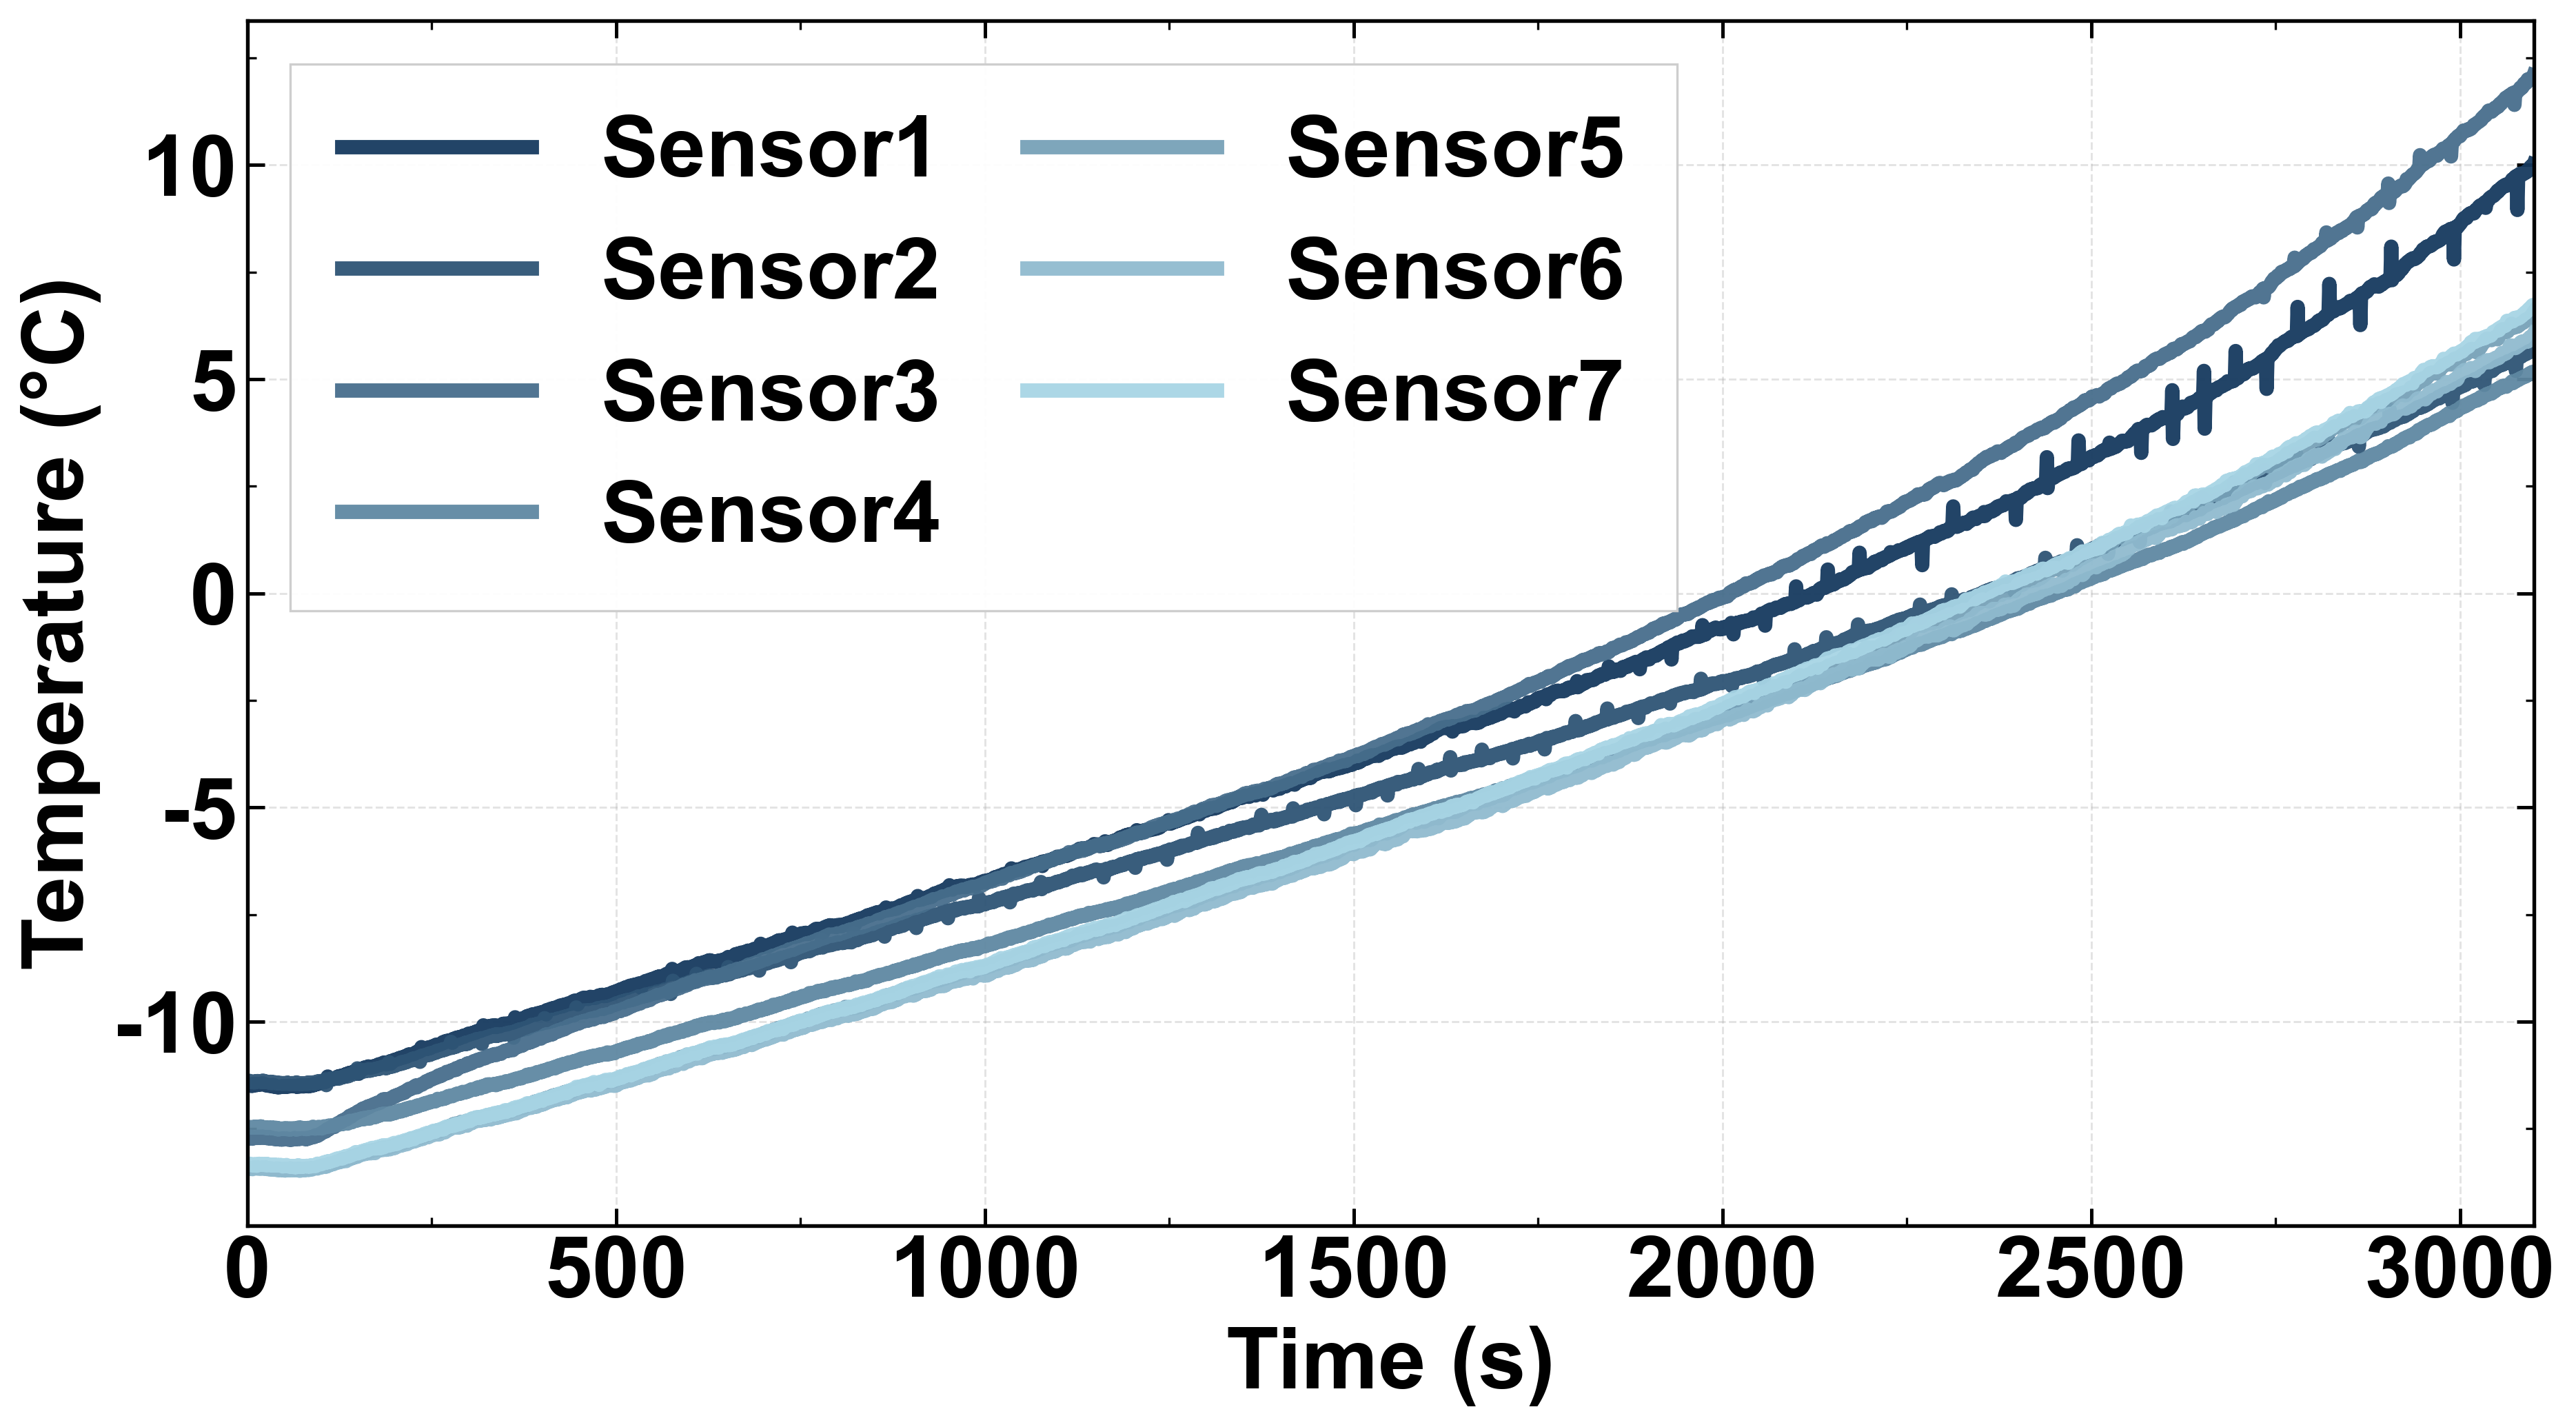


Plotting completed
Extracted data rows: 85000–88100
Number of plotted points per complete curve: 3101
Gradient start color: #163A5F
Gradient end color:   #A8D5E5
PNG saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\T1-T7_temperature_rows_28000-30100.png
PDF saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\T1-T7_temperature_rows_28000-30100.pdf


In [137]:
# -*- coding: utf-8 -*-
"""
Extract T1–T7 from rows 28000–30100 and plot them in one figure.

Main functions:
1. Automatically detect UTF-16 / UTF-8 / GBK encoding.
2. Automatically detect tab, comma, semicolon, or pipe separator.
3. Extract columns T1–T7.
4. Extract data rows 28000–30100, including both endpoints.
5. Apply gradient colors according to sensor number.
6. Keep the overall figure aspect ratio at 9:5.
7. Save PNG and PDF files.
"""

from pathlib import Path
import codecs
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import AutoMinorLocator


# =========================================================
# 0. USER SETTINGS
# =========================================================

# ---------- Input file ----------
INPUT_FILE = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大"
    r"\模组加热策略_温度数据_SOC07_20230212_1518.csv"
)

# Data-row range
# The first row below the CSV header is treated as data row 1.
ROW_START = 85000
ROW_END = 88100

# Required temperature columns
TEMPERATURE_COLUMNS = [
    "Sensor1",
    "Sensor2",
    "Sensor3",
    "Sensor4",
    "Sensor5",
    "Sensor6",
    "Sensor7",
]


# ---------- Output ----------
OUTPUT_DIR = INPUT_FILE.parent / "出图"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = "T1-T7_temperature_rows_28000-30100"


# ---------- X-axis mode ----------
# "row":
#     Use original CSV data-row numbers, namely 28000–30100.
#
# "relative":
#     Use relative point numbers, namely 0–2100.
#
# "time":
#     Convert relative point numbers to time according to SAMPLE_INTERVAL_S.
X_AXIS_MODE = "time"

# Only used when X_AXIS_MODE = "time"
SAMPLE_INTERVAL_S = 1.0


# ---------- Gradient colors ----------
# T1 corresponds to START_COLOR.
# T7 corresponds to END_COLOR.
START_COLOR = "#163A5F"
END_COLOR = "#A8D5E5"

# Examples:
#
# Red gradient:
# START_COLOR = "#881922"
# END_COLOR = "#E8B6BB"
#
# Purple gradient:
# START_COLOR = "#552A5D"
# END_COLOR = "#D8BEDA"
#
# Green gradient:
# START_COLOR = "#174F3D"
# END_COLOR = "#B7D9CA"

# Reverse the gradient if needed
REVERSE_GRADIENT = False


# ---------- Figure ----------
# 12.6 / 7.0 = 1.8 = 9 / 5
FIGSIZE = (12.6, 7.0)
DPI = 300

LINE_WIDTH = 5
LINE_ALPHA = 0.95

AXIS_LABEL_SIZE = 30
TICK_LABEL_SIZE = 30
LEGEND_SIZE = 30

Y_LABEL = "Temperature (°C)"

SHOW_GRID = True
SHOW_LEGEND = True

LEGEND_LOCATION = "best"
LEGEND_NCOL = 2

# Bold axis tick values
BOLD_TICK_LABELS = True

# Transparent output background
TRANSPARENT_BACKGROUND = False


# =========================================================
# 1. HELPER FUNCTIONS
# =========================================================

def clean_column_name(column_name):
    """
    Clean BOM, NUL bytes, full-width spaces, and surrounding spaces.
    """
    return (
        str(column_name)
        .replace("\ufeff", "")
        .replace("\x00", "")
        .replace("\u3000", " ")
        .strip()
    )


def detect_encoding_from_bytes(file_path):
    """
    Detect likely encoding using BOM and NUL-byte distribution.
    """
    with open(file_path, "rb") as file:
        sample = file.read(16384)

    if not sample:
        raise ValueError("The input file is empty.")

    # BOM detection
    if sample.startswith(codecs.BOM_UTF8):
        return "utf-8-sig"

    if sample.startswith(codecs.BOM_UTF16_LE):
        return "utf-16"

    if sample.startswith(codecs.BOM_UTF16_BE):
        return "utf-16"

    # NUL-byte detection
    nul_count = sample.count(b"\x00")
    nul_ratio = nul_count / len(sample)

    if nul_ratio > 0.05:
        even_nul_count = sample[0::2].count(b"\x00")
        odd_nul_count = sample[1::2].count(b"\x00")

        # UTF-16LE usually contains more NUL bytes at odd positions
        if odd_nul_count > even_nul_count:
            return "utf-16-le"

        return "utf-16-be"

    return None


def read_csv_robustly(
    file_path,
    maximum_rows,
    required_columns
):
    """
    Try multiple encoding and separator combinations until T1–T7
    are correctly identified.
    """

    detected_encoding = detect_encoding_from_bytes(file_path)

    encoding_candidates = []

    if detected_encoding is not None:
        encoding_candidates.append(detected_encoding)

    encoding_candidates.extend([
        "utf-16",
        "utf-16-le",
        "utf-16-be",
        "utf-8-sig",
        "gb18030",
        "gbk",
        "utf-8",
    ])

    # Remove duplicate items while preserving order
    encoding_candidates = list(
        dict.fromkeys(encoding_candidates)
    )

    # Device CSV files are frequently tab-separated
    separator_candidates = [
        "\t",
        ",",
        ";",
        "|",
    ]

    error_records = []

    for encoding in encoding_candidates:
        for separator in separator_candidates:

            try:
                dataframe = pd.read_csv(
                    file_path,
                    encoding=encoding,
                    sep=separator,
                    engine="python",
                    nrows=maximum_rows,
                    skip_blank_lines=True
                )

                # Clean all column names
                dataframe.columns = [
                    clean_column_name(column)
                    for column in dataframe.columns
                ]

                # Do not accept an incorrect one-column parse
                if len(dataframe.columns) <= 1:
                    error_records.append(
                        f"encoding={encoding}, "
                        f"separator={repr(separator)}: "
                        "only one column detected"
                    )
                    continue

                # Case-insensitive column mapping
                column_mapping = {
                    clean_column_name(column).upper(): column
                    for column in dataframe.columns
                }

                missing_columns = [
                    required_column
                    for required_column in required_columns
                    if required_column.upper() not in column_mapping
                ]

                if missing_columns:
                    error_records.append(
                        f"encoding={encoding}, "
                        f"separator={repr(separator)}: "
                        f"missing columns {missing_columns}"
                    )
                    continue

                # Rename the matched columns to standard T1–T7 names
                rename_mapping = {
                    column_mapping[required_column.upper()]: required_column
                    for required_column in required_columns
                }

                dataframe = dataframe.rename(
                    columns=rename_mapping
                )

                print("=" * 72)
                print("CSV file read successfully")
                print(f"Encoding:  {encoding}")
                print(f"Separator: {repr(separator)}")
                print(f"Rows read: {len(dataframe)}")
                print(f"Columns:   {len(dataframe.columns)}")
                print("=" * 72)

                return dataframe

            except (
                UnicodeDecodeError,
                UnicodeError,
                pd.errors.ParserError,
                csv.Error,
                ValueError
            ) as error:

                error_records.append(
                    f"encoding={encoding}, "
                    f"separator={repr(separator)}: "
                    f"{type(error).__name__}: {error}"
                )

    recent_errors = "\n".join(
        error_records[-15:]
    )

    raise RuntimeError(
        "The CSV file could not be read correctly.\n\n"
        "Recent attempts:\n"
        f"{recent_errors}"
    )


def generate_gradient_colors(
    start_color,
    end_color,
    number_of_colors,
    reverse=False
):
    """
    Generate a linear gradient between two colors.
    """

    color_map = LinearSegmentedColormap.from_list(
        "temperature_gradient",
        [start_color, end_color]
    )

    positions = np.linspace(
        0.0,
        1.0,
        number_of_colors
    )

    colors = [
        color_map(position)
        for position in positions
    ]

    if reverse:
        colors = colors[::-1]

    return colors


# =========================================================
# 2. CHECK INPUT SETTINGS
# =========================================================

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Input CSV file not found:\n{INPUT_FILE}"
    )

if ROW_START < 1:
    raise ValueError(
        "ROW_START must be greater than or equal to 1."
    )

if ROW_END < ROW_START:
    raise ValueError(
        "ROW_END must be greater than or equal to ROW_START."
    )

number_of_requested_rows = ROW_END - ROW_START + 1

print(f"Input file:\n{INPUT_FILE}")
print(
    f"Requested data rows: "
    f"{ROW_START}–{ROW_END}"
)
print(
    f"Requested number of rows: "
    f"{number_of_requested_rows}"
)


# =========================================================
# 3. READ CSV
# =========================================================

# Read only up to ROW_END because later rows are unnecessary
df = read_csv_robustly(
    file_path=INPUT_FILE,
    maximum_rows=ROW_END,
    required_columns=TEMPERATURE_COLUMNS
)


# =========================================================
# 4. EXTRACT T1–T7 AND ROWS 28000–30100
# =========================================================

if len(df) < ROW_END:
    raise ValueError(
        f"The CSV contains only {len(df)} data rows, "
        f"but row {ROW_END} was requested."
    )

# pandas iloc starts from zero and excludes its end index:
#
# data row 28000 -> iloc index 27999
# data row 30100 -> iloc end index 30100
temperature_df = df.iloc[
    ROW_START - 1:ROW_END
][TEMPERATURE_COLUMNS].copy()

temperature_df = temperature_df.reset_index(
    drop=True
)

# Convert to numeric data
temperature_df = temperature_df.apply(
    pd.to_numeric,
    errors="coerce"
)

if len(temperature_df) != number_of_requested_rows:
    raise ValueError(
        "The extracted number of rows is inconsistent with "
        "the requested range."
    )

# Check whether all selected columns are empty
if not temperature_df.notna().any().any():
    raise ValueError(
        "No valid numeric data were found in T1–T7."
    )

print("\nValid numeric data count:")

for column in TEMPERATURE_COLUMNS:
    valid_count = temperature_df[column].notna().sum()
    missing_count = temperature_df[column].isna().sum()

    print(
        f"  {column}: "
        f"{valid_count} valid, "
        f"{missing_count} missing"
    )


# =========================================================
# 5. PREPARE X-AXIS
# =========================================================

if X_AXIS_MODE.lower() == "row":

    x_data = np.arange(
        ROW_START,
        ROW_END + 1,
        dtype=float
    )

    x_label = "Data row"

elif X_AXIS_MODE.lower() == "relative":

    x_data = np.arange(
        number_of_requested_rows,
        dtype=float
    )

    x_label = "Sample index"

elif X_AXIS_MODE.lower() == "time":

    x_data = (
        np.arange(
            number_of_requested_rows,
            dtype=float
        )
        * SAMPLE_INTERVAL_S
    )

    x_label = "Time (s)"

else:
    raise ValueError(
        'X_AXIS_MODE must be "row", "relative", or "time".'
    )


# =========================================================
# 6. GENERATE GRADIENT COLORS
# =========================================================

curve_colors = generate_gradient_colors(
    start_color=START_COLOR,
    end_color=END_COLOR,
    number_of_colors=len(TEMPERATURE_COLUMNS),
    reverse=REVERSE_GRADIENT
)


# =========================================================
# 7. CREATE FIGURE
# =========================================================

fig, ax = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI
)

for column, curve_color in zip(
    TEMPERATURE_COLUMNS,
    curve_colors
):
    y_data = temperature_df[column].to_numpy(
        dtype=float
    )

    valid_mask = (
        np.isfinite(x_data)
        & np.isfinite(y_data)
    )

    if np.count_nonzero(valid_mask) < 2:
        print(
            f"Warning: {column} contains fewer "
            "than two valid data points."
        )
        continue

    ax.plot(
        x_data[valid_mask],
        y_data[valid_mask],
        color=curve_color,
        linewidth=LINE_WIDTH,
        alpha=LINE_ALPHA,
        label=column
    )


# =========================================================
# 8. AXIS LABELS
# =========================================================

ax.set_xlabel(
    x_label,
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

ax.set_ylabel(
    Y_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

ax.set_xlim(
    x_data[0],
    x_data[-1]
)


# =========================================================
# 9. TICK SETTINGS
# =========================================================

ax.tick_params(
    axis="both",
    which="major",
    labelsize=TICK_LABEL_SIZE,
    direction="in",
    top=True,
    right=True,
    length=6,
    width=1.2
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=3,
    width=0.8
)

ax.xaxis.set_minor_locator(
    AutoMinorLocator(2)
)

ax.yaxis.set_minor_locator(
    AutoMinorLocator(2)
)

if BOLD_TICK_LABELS:
    plt.setp(
        ax.get_xticklabels(),
        fontweight="bold"
    )

    plt.setp(
        ax.get_yticklabels(),
        fontweight="bold"
    )

for spine in ax.spines.values():
    spine.set_linewidth(1.3)


# =========================================================
# 10. GRID
# =========================================================

if SHOW_GRID:
    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35
    )


# =========================================================
# 11. LEGEND
# =========================================================

if SHOW_LEGEND:
    legend = ax.legend(
        loc=LEGEND_LOCATION,
        ncol=LEGEND_NCOL,
        prop={
            "size": LEGEND_SIZE,
            "weight": "bold"
        },
        frameon=True,
        fancybox=False,
        framealpha=0.95,
        borderpad=0.6,
        handlelength=2.2,
        columnspacing=1.0
    )

    legend.get_frame().set_linewidth(0.8)


# =========================================================
# 12. SAVE AND SHOW
# =========================================================

fig.tight_layout()

png_path = OUTPUT_DIR / f"{OUTPUT_NAME}.png"
pdf_path = OUTPUT_DIR / f"{OUTPUT_NAME}.pdf"

fig.savefig(
    png_path,
    dpi=DPI,
    bbox_inches="tight",
    transparent=TRANSPARENT_BACKGROUND
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    transparent=TRANSPARENT_BACKGROUND
)

plt.show()
plt.close(fig)


# =========================================================
# 13. PRINT OUTPUT INFORMATION
# =========================================================

print("\n" + "=" * 72)
print("Plotting completed")
print(
    f"Extracted data rows: "
    f"{ROW_START}–{ROW_END}"
)
print(
    f"Number of plotted points per complete curve: "
    f"{number_of_requested_rows}"
)
print(f"Gradient start color: {START_COLOR}")
print(f"Gradient end color:   {END_COLOR}")
print(f"PNG saved to:\n{png_path}")
print(f"PDF saved to:\n{pdf_path}")
print("=" * 72)

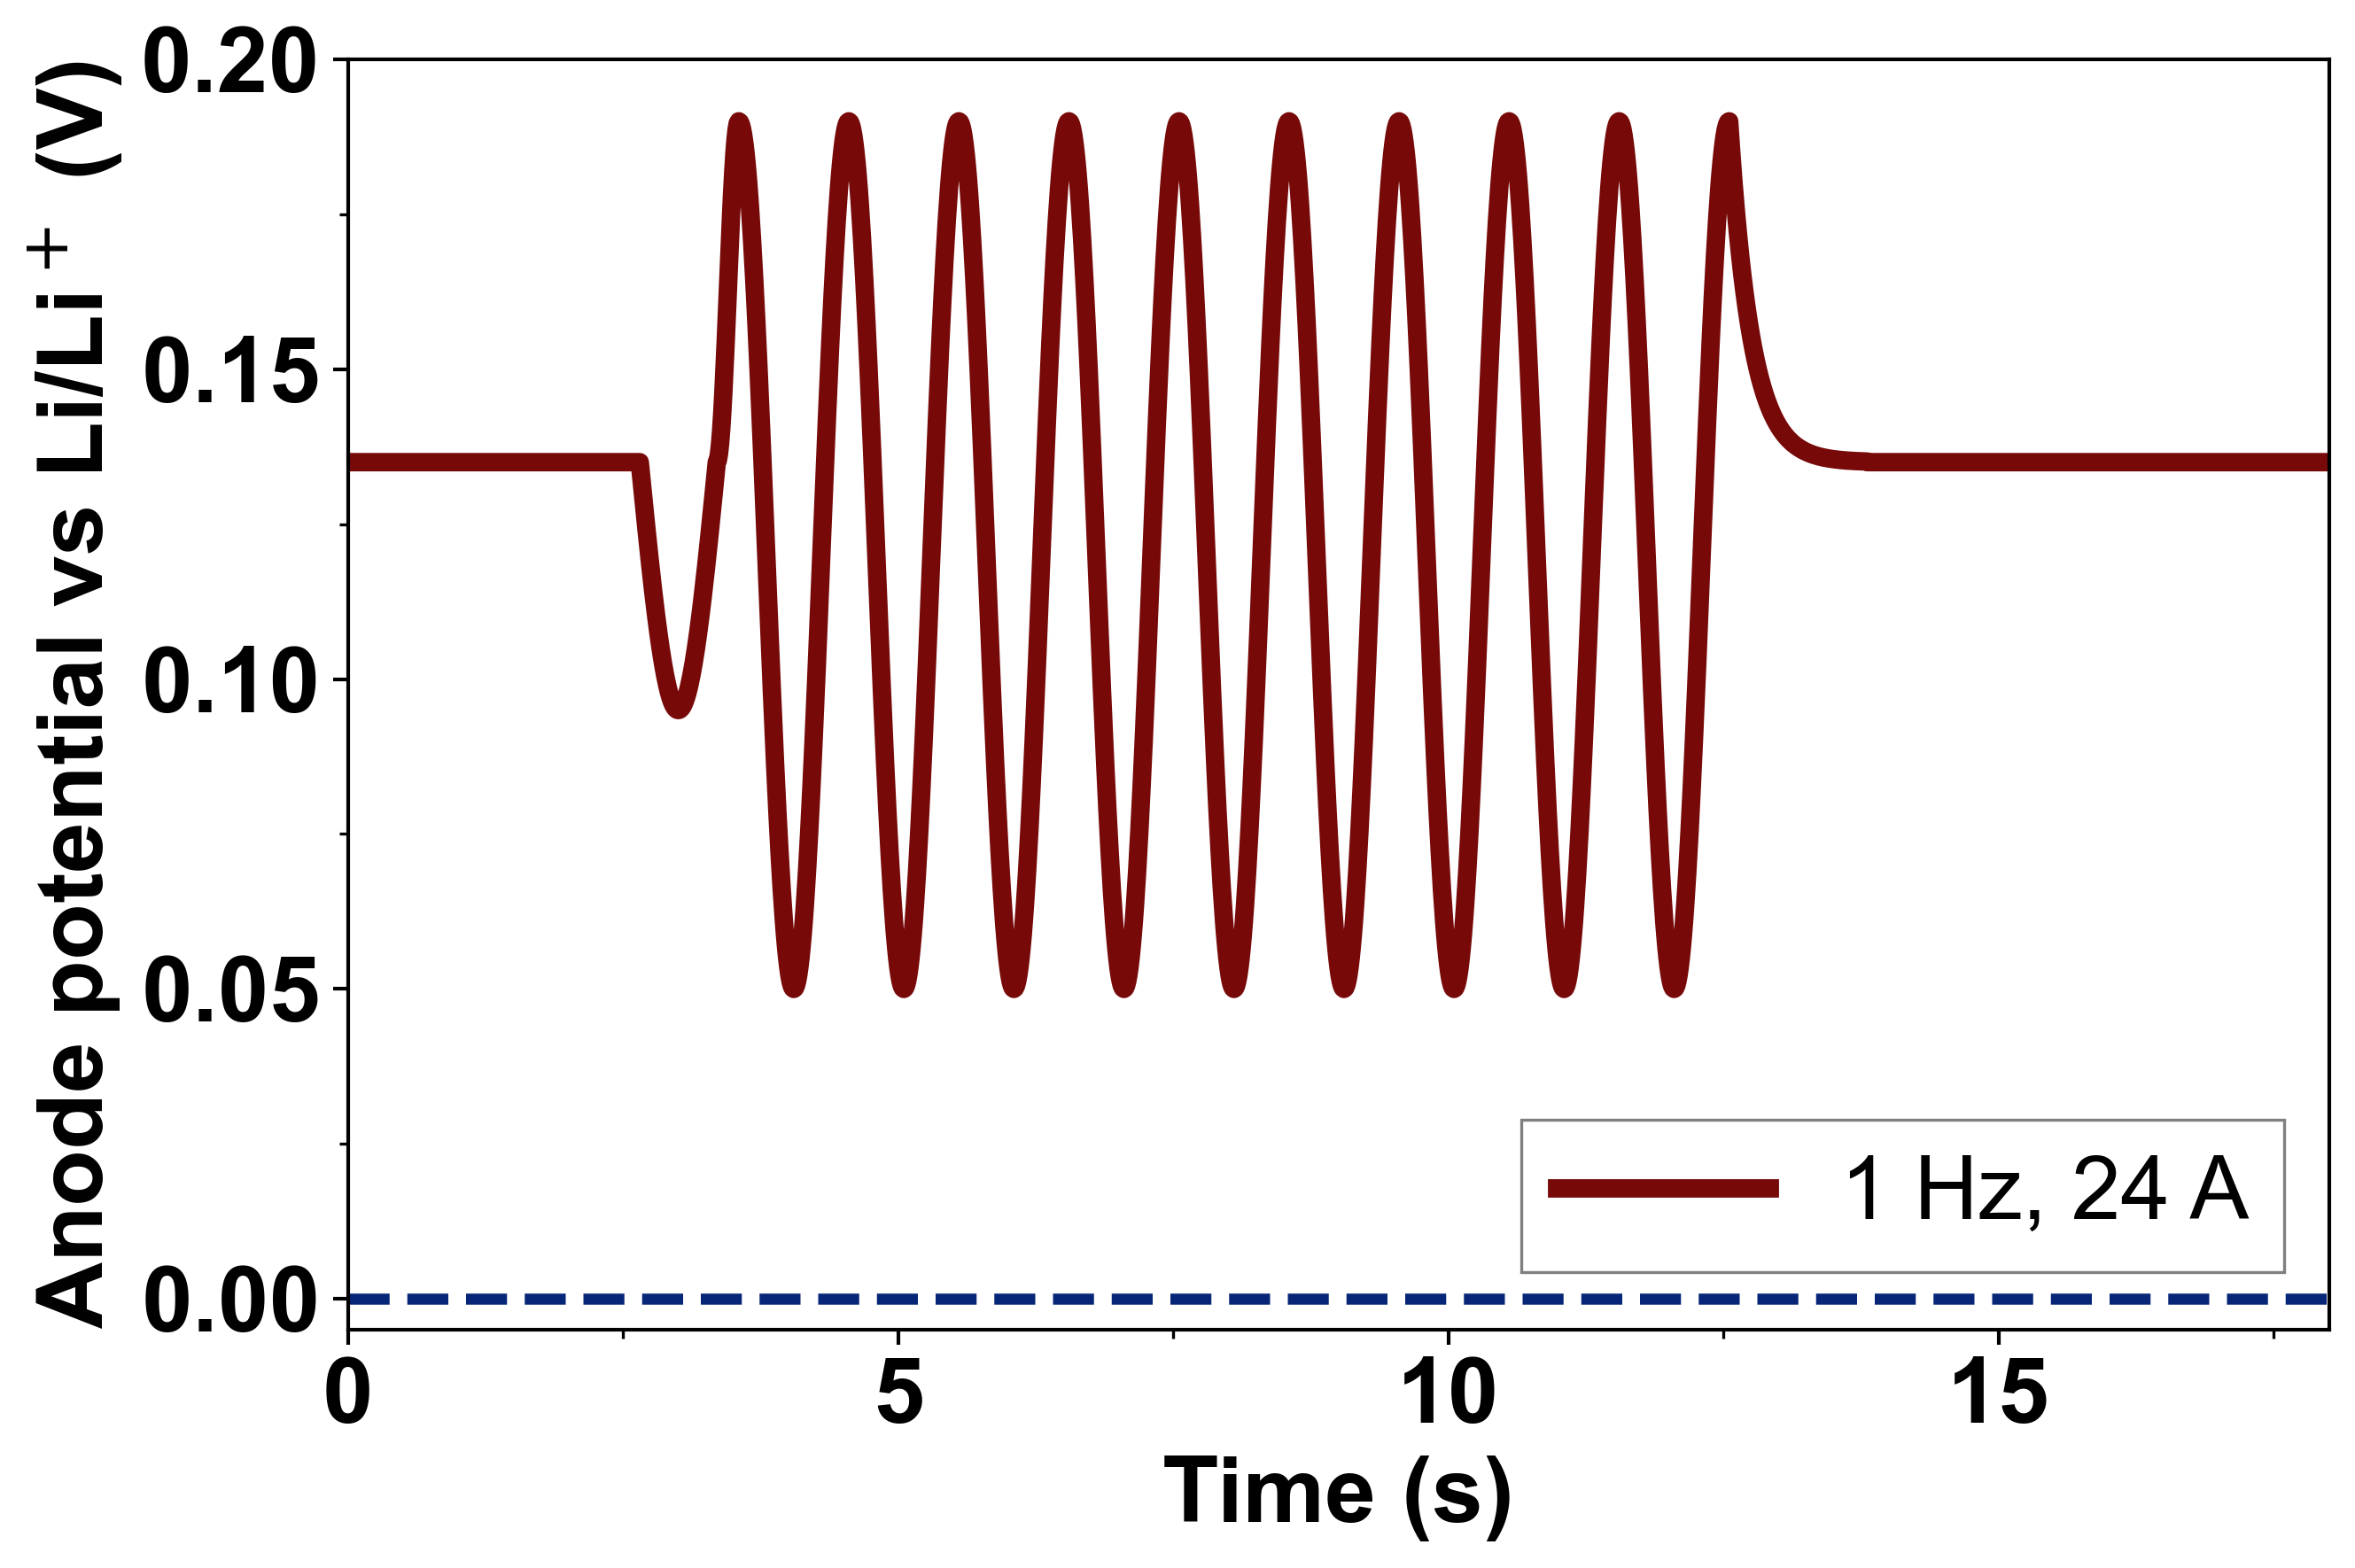

PNG saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Anode_potential_vs_time_1Hz_24A.png
PDF saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Anode_potential_vs_time_1Hz_24A.pdf


In [147]:
# -*- coding: utf-8 -*-
"""
Reconstruct and plot the curve from the provided figure.

Features:
1. English labels
2. Figure aspect ratio = 3:2
3. Upper y-limit kept at 0.20 V
4. Lower y-limit slightly below 0 V to show the 0 V position
5. A horizontal boundary line at 0 V
6. Curve shape approximated from the supplied image
"""

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter


# =========================================================
# 0. USER SETTINGS
# =========================================================

OUTPUT_DIR = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = "Anode_potential_vs_time_1Hz_24A"

# Figure ratio = 3:2
FIGSIZE = (9, 6)
DPI = 300

LINE_WIDTH = 5

AXIS_LABEL_SIZE = 25
TICK_LABEL_SIZE = 25
LEGEND_SIZE = 24

# Axes limits
X_MIN = 0.0
X_MAX = 18.0

# Keep the upper limit consistent with the original figure,
# while shifting the lower limit slightly downward to show 0 V.
Y_MIN = -0.005
Y_MAX = 0.20

# Curve color
CURVE_COLOR = "#770909"

# Background
AXES_FACE_COLOR = "#ffffff"

# Legend text
LEGEND_LABEL = "1 Hz, 24 A"

SHOW_GRID = False


# =========================================================
# 1. RECONSTRUCT APPROXIMATE DATA
# =========================================================
#
# Approximate features extracted from the figure:
# - Baseline before excitation: ~0.135 V
# - A short dip near 3 s down to ~0.095 V
# - 1 Hz oscillation from roughly 3.5 s to 12.5 s
# - Oscillation range approximately 0.05–0.19 V
# - Relaxation back to ~0.135 V after 12.5 s
#

t = np.linspace(X_MIN, X_MAX, 1801)   # 0.01 s step
v = np.full_like(t, 0.135)


# ----- Segment 1: initial baseline -----
# 0–2.65 s: ~0.135 V
mask_1 = (t >= 0.0) & (t < 2.65)
v[mask_1] = 0.135


# ----- Segment 2: short dip -----
# 2.65–3.35 s: dip from ~0.135 to ~0.095 and recover
mask_2 = (t >= 2.65) & (t < 3.35)
u2 = (t[mask_2] - 2.65) / (3.35 - 2.65)
v[mask_2] = 0.135 - 0.040 * np.sin(np.pi * u2)


# ----- Segment 3: short rise to oscillation maximum -----
# 3.35–3.55 s: smooth rise from 0.135 to 0.19
mask_3 = (t >= 3.35) & (t < 3.55)
u3 = (t[mask_3] - 3.35) / (3.55 - 3.35)
v[mask_3] = 0.135 + (0.190 - 0.135) * (1 - np.cos(np.pi * u3)) / 2


# ----- Segment 4: 1 Hz oscillation -----
# 3.55–12.55 s
# Middle level ≈ 0.12 V, amplitude ≈ 0.07 V
# Therefore range ≈ 0.05–0.19 V
mask_4 = (t >= 3.55) & (t <= 12.55)
tau4 = t[mask_4] - 3.55
v[mask_4] = 0.120 + 0.070 * np.cos(2 * np.pi * 1.0 * tau4)


# ----- Segment 5: relaxation -----
# 12.55–13.80 s: exponential-like decay toward 0.135 V
mask_5 = (t > 12.55) & (t <= 13.80)
tau5 = t[mask_5] - 12.55
v_start = 0.190
v_end = 0.135
decay_rate = 5.0
v[mask_5] = v_end + (v_start - v_end) * np.exp(-decay_rate * tau5)


# ----- Segment 6: final baseline -----
mask_6 = (t > 13.80)
v[mask_6] = 0.135


# =========================================================
# 2. CREATE FIGURE
# =========================================================

fig, ax = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI
)

ax.set_facecolor(AXES_FACE_COLOR)

ax.plot(
    t,
    v,
    color=CURVE_COLOR,
    linewidth=LINE_WIDTH,
    label=LEGEND_LABEL
)


# =========================================================
# 3. ADD 0 V HORIZONTAL BOUNDARY LINE
# =========================================================

ax.axhline(
    y=0.0,
    color="#082678",
    linewidth=3.0,
    linestyle="--"
)


# =========================================================
# 4. AXIS LABELS
# =========================================================

ax.set_xlabel(
    "Time (s)",
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

ax.set_ylabel(
    r"Anode potential vs Li/Li$^+$ (V)",
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)


# =========================================================
# 5. AXIS LIMITS
# =========================================================

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)


# =========================================================
# 6. TICKS
# =========================================================

ax.xaxis.set_major_locator(MultipleLocator(5))
ax.xaxis.set_minor_locator(MultipleLocator(2.5))

ax.yaxis.set_major_locator(MultipleLocator(0.05))
ax.yaxis.set_minor_locator(MultipleLocator(0.025))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=1.0,
    labelsize=TICK_LABEL_SIZE
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="out",
    length=2.5,
    width=0.8
)

# Bold tick labels
plt.setp(ax.get_xticklabels(), fontweight="bold")
plt.setp(ax.get_yticklabels(), fontweight="bold")

# Spine widths
for spine in ax.spines.values():
    spine.set_linewidth(1.0)


# =========================================================
# 7. GRID
# =========================================================

if SHOW_GRID:
    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )


# =========================================================
# 8. LEGEND
# =========================================================

legend = ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.57, 0.20),
    prop={
        "size": LEGEND_SIZE,
        "weight": "normal"
    },
    frameon=True,
    fancybox=False,
    framealpha=1.0,
    edgecolor="gray",
    handlelength=2.4
)

legend.get_frame().set_linewidth(0.8)


# =========================================================
# 9. SAVE AND SHOW
# =========================================================

fig.tight_layout()

png_path = OUTPUT_DIR / f"{OUTPUT_NAME}.png"
pdf_path = OUTPUT_DIR / f"{OUTPUT_NAME}.pdf"

fig.savefig(
    png_path,
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print(f"PNG saved to:\n{png_path}")
print(f"PDF saved to:\n{pdf_path}")

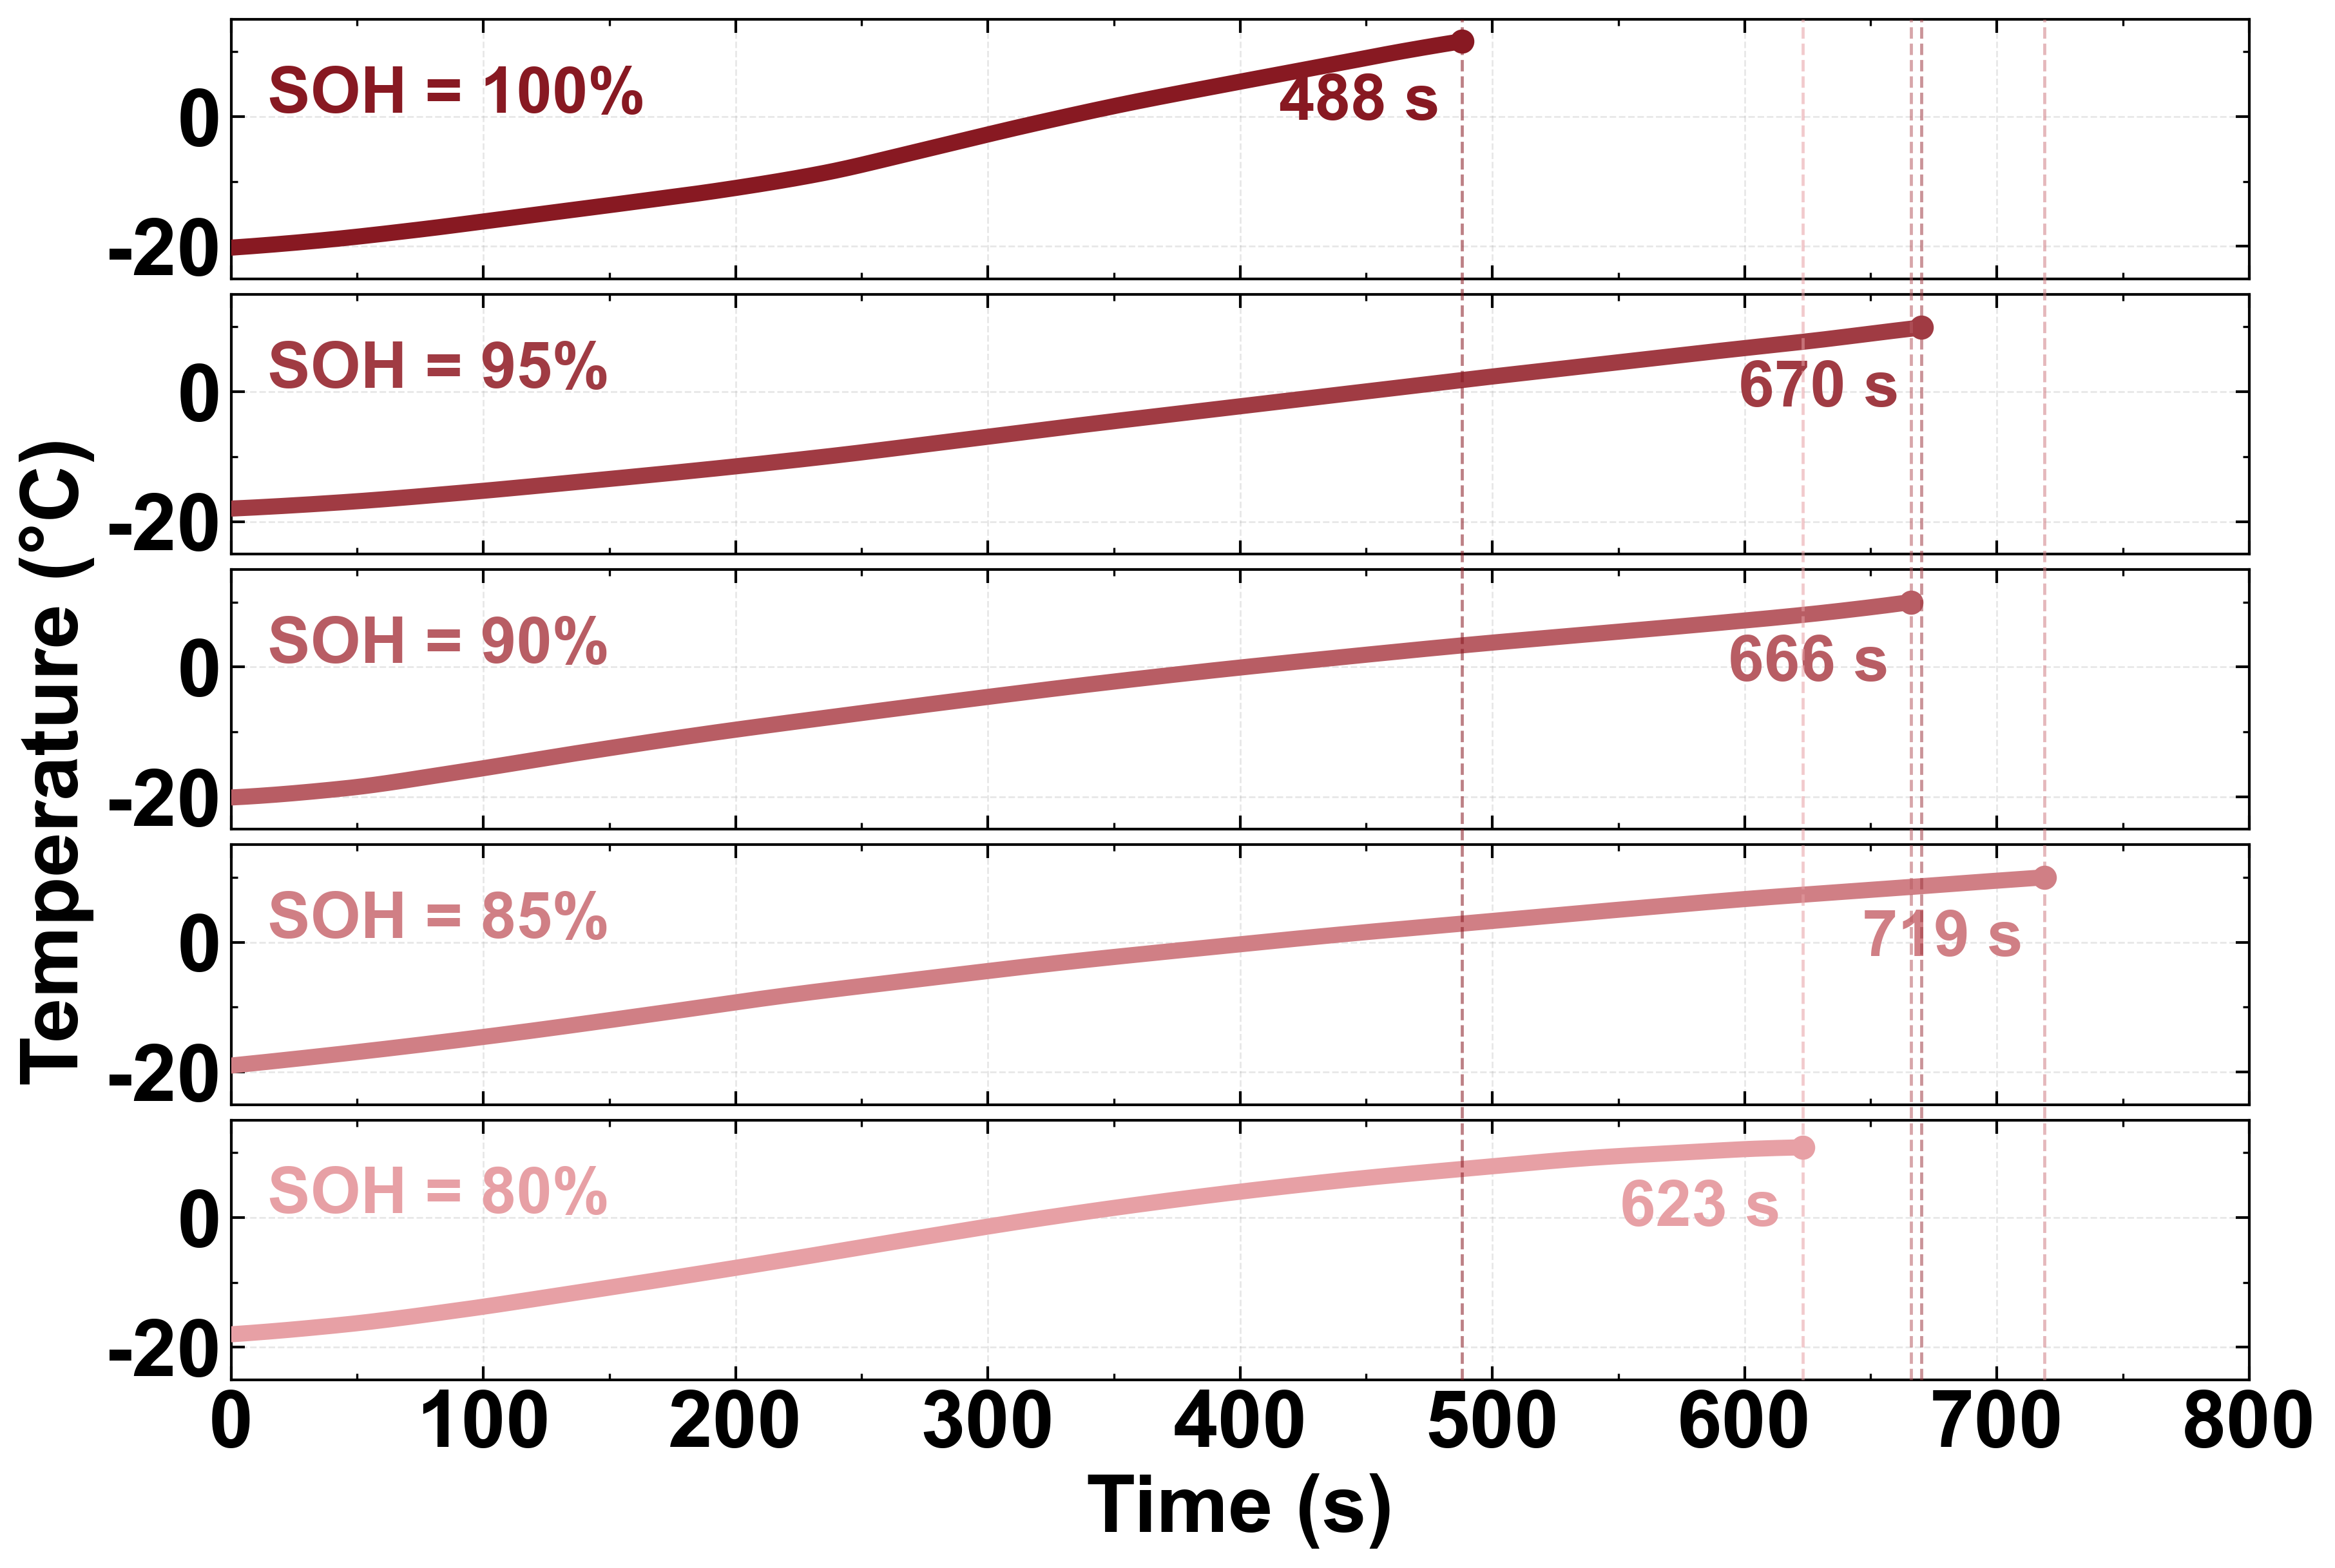


Plotting completed
Heating end times:
  SOH = 100%: 488 s
  SOH =  95%: 670 s
  SOH =  90%: 666 s
  SOH =  85%: 719 s
  SOH =  80%: 623 s

PNG saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\SOC50_experimental_heating_curves_5SOH.png

PDF saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\SOC50_experimental_heating_curves_5SOH.pdf


In [161]:
# -*- coding: utf-8 -*-
"""
Experimental heating curves at SOC = 50% for different SOHs.

Features:
1. Experimental curves only.
2. Five vertically stacked subplots.
3. Shared Time (s) x-axis.
4. Overall figure ratio = 3:2.
5. Heating end times retain one-second differences.
6. Vertical lines at all heating end times continuously span
   the complete subplot region.
7. Experimental curves use a red color gradient.

Note:
The data are approximately digitized from the supplied figures.
"""

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from scipy.interpolate import PchipInterpolator


# =========================================================
# 0. USER SETTINGS
# =========================================================

# ---------- Output ----------
OUTPUT_DIR = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = "SOC50_experimental_heating_curves_5SOH"


# ---------- Figure ----------
# 12 / 8 = 3 / 2
FIGSIZE = (12, 8)
DPI = 300

# Distance between adjacent subplots
SUBPLOT_HSPACE = 0.06

# Figure margins
LEFT_MARGIN = 0.11
RIGHT_MARGIN = 0.98
BOTTOM_MARGIN = 0.10
TOP_MARGIN = 0.98


# ---------- Curve ----------
LINE_WIDTH = 6
LINE_ALPHA = 1.0

# Endpoint marker
END_MARKER = "o"
END_MARKER_SIZE =8


# ---------- Font ----------
AXIS_LABEL_SIZE = 30
TICK_LABEL_SIZE = 30
SOH_TEXT_SIZE = 24
END_TIME_TEXT_SIZE = 24


# ---------- Axes ----------
X_LABEL = "Time (s)"
Y_LABEL = "Temperature (°C)"

X_MIN = 0
X_MAX = 800

Y_MIN = -25
Y_MAX = 15

X_MAJOR_INTERVAL = 100
Y_MAJOR_INTERVAL = 20

SHOW_GRID = True


# ---------- Experimental color gradient ----------
# SOH = 100% uses the dark color.
# SOH = 80% uses the light color.
COLOR_START = "#881922"
COLOR_END = "#E7A0A5"

REVERSE_GRADIENT = False


# ---------- End-time vertical lines ----------
SHOW_GLOBAL_END_LINES = True

# True:
# Each vertical line uses the same color as its corresponding SOH curve.
#
# False:
# All vertical lines use END_LINE_COLOR.
END_LINE_USE_CURVE_COLOR = True

END_LINE_COLOR = "#555555"
END_LINE_WIDTH = 1.15
END_LINE_STYLE = "--"
END_LINE_ALPHA = 0.55

# End-time annotation
SHOW_END_TIME_TEXT = True

# Offset in screen points:
# positive x -> right
# positive y -> upward
END_TIME_TEXT_OFFSET = (-8, -12)


# =========================================================
# 1. HEATING END TIMES
# =========================================================
#
# Approximate end times digitized from the original figures.
# The values deliberately retain one-second differences rather
# than being rounded to the nearest 10 seconds.
#
# These values can be independently adjusted later.

HEATING_END_TIMES = {
    100: 488,
    95: 670,
    90: 666,
    85: 719,
    80: 623,
}


# =========================================================
# 2. APPROXIMATELY DIGITIZED EXPERIMENTAL DATA
# =========================================================
#
# Each time array ends exactly at the corresponding value in
# HEATING_END_TIMES.

curve_data = {
    100: {
        "t": np.array([
            0, 35, 75, 115, 155, 195,
            235, 275, 315, 355, 395,
            435, 465, 488
        ], dtype=float),

        "temperature": np.array([
            -20.2, -19.1, -17.4, -15.4, -13.4, -11.3,
            -8.7, -5.1, -1.4, 2.0, 5.0,
            7.9, 10.1, 11.6
        ], dtype=float),
    },

    95: {
        "t": np.array([
            0, 45, 90, 140, 190, 240,
            290, 340, 390, 440, 490,
            540, 590, 630, 655, 670
        ], dtype=float),

        "temperature": np.array([
            -18.0, -17.0, -15.6, -13.8, -11.9, -9.8,
            -7.4, -5.0, -2.7, -0.4, 1.9,
            4.1, 6.3, 8.0, 9.2, 9.9
        ], dtype=float),
    },

    90: {
        "t": np.array([
            0, 45, 90, 140, 190, 240,
            290, 340, 390, 440, 490,
            540, 590, 625, 650, 666
        ], dtype=float),

        "temperature": np.array([
            -20.1, -18.7, -16.2, -13.1, -10.2, -7.6,
            -5.1, -2.7, -0.5, 1.5, 3.4,
            5.1, 6.8, 8.1, 9.2, 10.0
        ], dtype=float),
    },

    85: {
        "t": np.array([
            0, 55, 110, 165, 220, 275,
            330, 385, 440, 495, 550,
            605, 655, 690, 719
        ], dtype=float),

        "temperature": np.array([
            -19.0, -16.7, -14.1, -11.2, -8.2, -5.6,
            -3.1, -0.9, 1.2, 3.1, 5.0,
            6.8, 8.2, 9.2, 10.0
        ], dtype=float),
    },

    80: {
        "t": np.array([
            0, 45, 90, 135, 180, 225,
            270, 315, 360, 405, 450,
            495, 540, 580, 605, 623
        ], dtype=float),

        "temperature": np.array([
            -18.0, -16.5, -14.3, -11.7, -9.0, -6.2,
            -3.3, -0.5, 2.0, 4.2, 6.1,
            7.7, 9.2, 10.1, 10.6, 10.8
        ], dtype=float),
    },
}


# =========================================================
# 3. HELPER FUNCTIONS
# =========================================================

def generate_gradient_colors(
    start_color,
    end_color,
    number_of_colors,
    reverse=False
):
    """
    Generate a linear gradient between two colors.
    """
    color_map = LinearSegmentedColormap.from_list(
        "experimental_gradient",
        [start_color, end_color]
    )

    positions = np.linspace(
        0.0,
        1.0,
        number_of_colors
    )

    colors = [
        color_map(position)
        for position in positions
    ]

    if reverse:
        colors = colors[::-1]

    return colors


def smooth_curve(x, y, number_of_points=600):
    """
    Smooth the digitized data using shape-preserving PCHIP interpolation.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError(
            "The time and temperature arrays must have the same length."
        )

    if np.any(np.diff(x) <= 0):
        raise ValueError(
            "The time data must be strictly increasing."
        )

    interpolator = PchipInterpolator(
        x,
        y
    )

    x_dense = np.linspace(
        x[0],
        x[-1],
        number_of_points
    )

    y_dense = interpolator(
        x_dense
    )

    return x_dense, y_dense


def validate_end_times(data_dictionary, end_time_dictionary):
    """
    Confirm that the last time of each curve equals its designated
    heating end time.
    """
    for soh, end_time in end_time_dictionary.items():

        if soh not in data_dictionary:
            raise KeyError(
                f"SOH = {soh}% is missing from curve_data."
            )

        data_end_time = float(
            data_dictionary[soh]["t"][-1]
        )

        if not np.isclose(
            data_end_time,
            float(end_time)
        ):
            raise ValueError(
                f"SOH = {soh}%: the last time in curve_data "
                f"is {data_end_time} s, but HEATING_END_TIMES "
                f"is set to {end_time} s."
            )


# =========================================================
# 4. PREPARE DATA AND COLORS
# =========================================================

soh_list = [
    100,
    95,
    90,
    85,
    80,
]

validate_end_times(
    curve_data,
    HEATING_END_TIMES
)

curve_colors = generate_gradient_colors(
    start_color=COLOR_START,
    end_color=COLOR_END,
    number_of_colors=len(soh_list),
    reverse=REVERSE_GRADIENT
)

color_by_soh = {
    soh: color
    for soh, color in zip(
        soh_list,
        curve_colors
    )
}


# =========================================================
# 5. CREATE FIGURE
# =========================================================

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=FIGSIZE,
    dpi=DPI,
    sharex=True,
    sharey=True
)

fig.subplots_adjust(
    left=LEFT_MARGIN,
    right=RIGHT_MARGIN,
    bottom=BOTTOM_MARGIN,
    top=TOP_MARGIN,
    hspace=SUBPLOT_HSPACE
)


# =========================================================
# 6. DRAW EACH EXPERIMENTAL CURVE
# =========================================================

for ax, soh in zip(
    axes,
    soh_list
):
    data = curve_data[soh]

    time_original = data["t"]
    temperature_original = data["temperature"]

    time_dense, temperature_dense = smooth_curve(
        time_original,
        temperature_original,
        number_of_points=600
    )

    curve_color = color_by_soh[soh]
    end_time = float(HEATING_END_TIMES[soh])
    end_temperature = float(temperature_original[-1])

    # Experimental curve
    ax.plot(
        time_dense,
        temperature_dense,
        color=curve_color,
        linewidth=LINE_WIDTH,
        alpha=LINE_ALPHA,
        zorder=3
    )

    # Endpoint marker
    ax.plot(
        end_time,
        end_temperature,
        marker=END_MARKER,
        markersize=END_MARKER_SIZE,
        markerfacecolor=curve_color,
        markeredgecolor=curve_color,
        linestyle="none",
        zorder=5
    )

    # SOH label
    ax.text(
        0.018,
        0.82,
        f"SOH = {soh}%",
        transform=ax.transAxes,
        fontsize=SOH_TEXT_SIZE,
        fontweight="bold",
        ha="left",
        va="top",
        color=curve_color,
        zorder=6
    )

    # Exact end-time label beside its own endpoint
    if SHOW_END_TIME_TEXT:
        ax.annotate(
            f"{end_time:.0f} s",
            xy=(
                end_time,
                end_temperature
            ),
            xytext=END_TIME_TEXT_OFFSET,
            textcoords="offset points",

            # 标注位于结束点左下侧
            ha="right",
            va="top",

            fontsize=END_TIME_TEXT_SIZE,
            fontweight="bold",
            color=curve_color,
            zorder=7
        )

    # Shared limits
    ax.set_xlim(
        X_MIN,
        X_MAX
    )

    ax.set_ylim(
        Y_MIN,
        Y_MAX
    )

    # Tick settings
    ax.xaxis.set_major_locator(
        MultipleLocator(X_MAJOR_INTERVAL)
    )

    ax.xaxis.set_minor_locator(
        AutoMinorLocator(2)
    )

    ax.yaxis.set_major_locator(
        MultipleLocator(Y_MAJOR_INTERVAL)
    )

    ax.yaxis.set_minor_locator(
        AutoMinorLocator(2)
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=TICK_LABEL_SIZE,
        direction="in",
        top=True,
        right=True,
        length=5,
        width=1.0
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction="in",
        top=True,
        right=True,
        length=2.5,
        width=0.8
    )

    # Bold tick numbers
    plt.setp(
        ax.get_yticklabels(),
        fontweight="bold"
    )

    # Border thickness
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    # Grid
    if SHOW_GRID:
        ax.grid(
            True,
            which="major",
            linestyle="--",
            linewidth=0.65,
            alpha=0.30,
            zorder=0
        )


# =========================================================
# 7. SHARED AXIS LABELS
# =========================================================

axes[-1].set_xlabel(
    X_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

fig.text(
    0.035,
    0.5,
    Y_LABEL,
    ha="center",
    va="center",
    rotation="vertical",
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

# Only the bottom subplot displays x-axis tick labels
for ax in axes[:-1]:
    ax.tick_params(
        axis="x",
        labelbottom=False
    )

plt.setp(
    axes[-1].get_xticklabels(),
    fontweight="bold"
)


# =========================================================
# 8. DRAW CONTINUOUS GLOBAL END-TIME LINES
# =========================================================
#
# The lines are added in figure coordinates after the subplot
# positions have been finalized. Therefore, every vertical line
# remains continuous through the gaps between the five axes.

if SHOW_GLOBAL_END_LINES:

    # Update the transformations and subplot positions
    fig.canvas.draw()

    # Bottom and top of the complete five-subplot plotting region
    figure_y_bottom = axes[-1].get_position().y0
    figure_y_top = axes[0].get_position().y1

    for soh in soh_list:
        end_time = float(
            HEATING_END_TIMES[soh]
        )

        # Convert x=end_time from axis data coordinates
        # into figure coordinates.
        display_xy = axes[-1].transData.transform(
            (end_time, 0)
        )

        figure_xy = fig.transFigure.inverted().transform(
            display_xy
        )

        figure_x = figure_xy[0]

        if END_LINE_USE_CURVE_COLOR:
            vertical_line_color = color_by_soh[soh]
        else:
            vertical_line_color = END_LINE_COLOR

        global_vertical_line = Line2D(
            [figure_x, figure_x],
            [figure_y_bottom, figure_y_top],
            transform=fig.transFigure,
            color=vertical_line_color,
            linewidth=END_LINE_WIDTH,
            linestyle=END_LINE_STYLE,
            alpha=END_LINE_ALPHA,
            zorder=2,
            clip_on=False
        )

        fig.add_artist(
            global_vertical_line
        )


# =========================================================
# 9. SAVE AND SHOW
# =========================================================

png_path = OUTPUT_DIR / f"{OUTPUT_NAME}.png"
pdf_path = OUTPUT_DIR / f"{OUTPUT_NAME}.pdf"

fig.savefig(
    png_path,
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)


# =========================================================
# 10. PRINT INFORMATION
# =========================================================

print("\n" + "=" * 72)
print("Plotting completed")
print("Heating end times:")

for soh in soh_list:
    print(
        f"  SOH = {soh:>3}%: "
        f"{HEATING_END_TIMES[soh]:.0f} s"
    )

print(f"\nPNG saved to:\n{png_path}")
print(f"\nPDF saved to:\n{pdf_path}")
print("=" * 72)

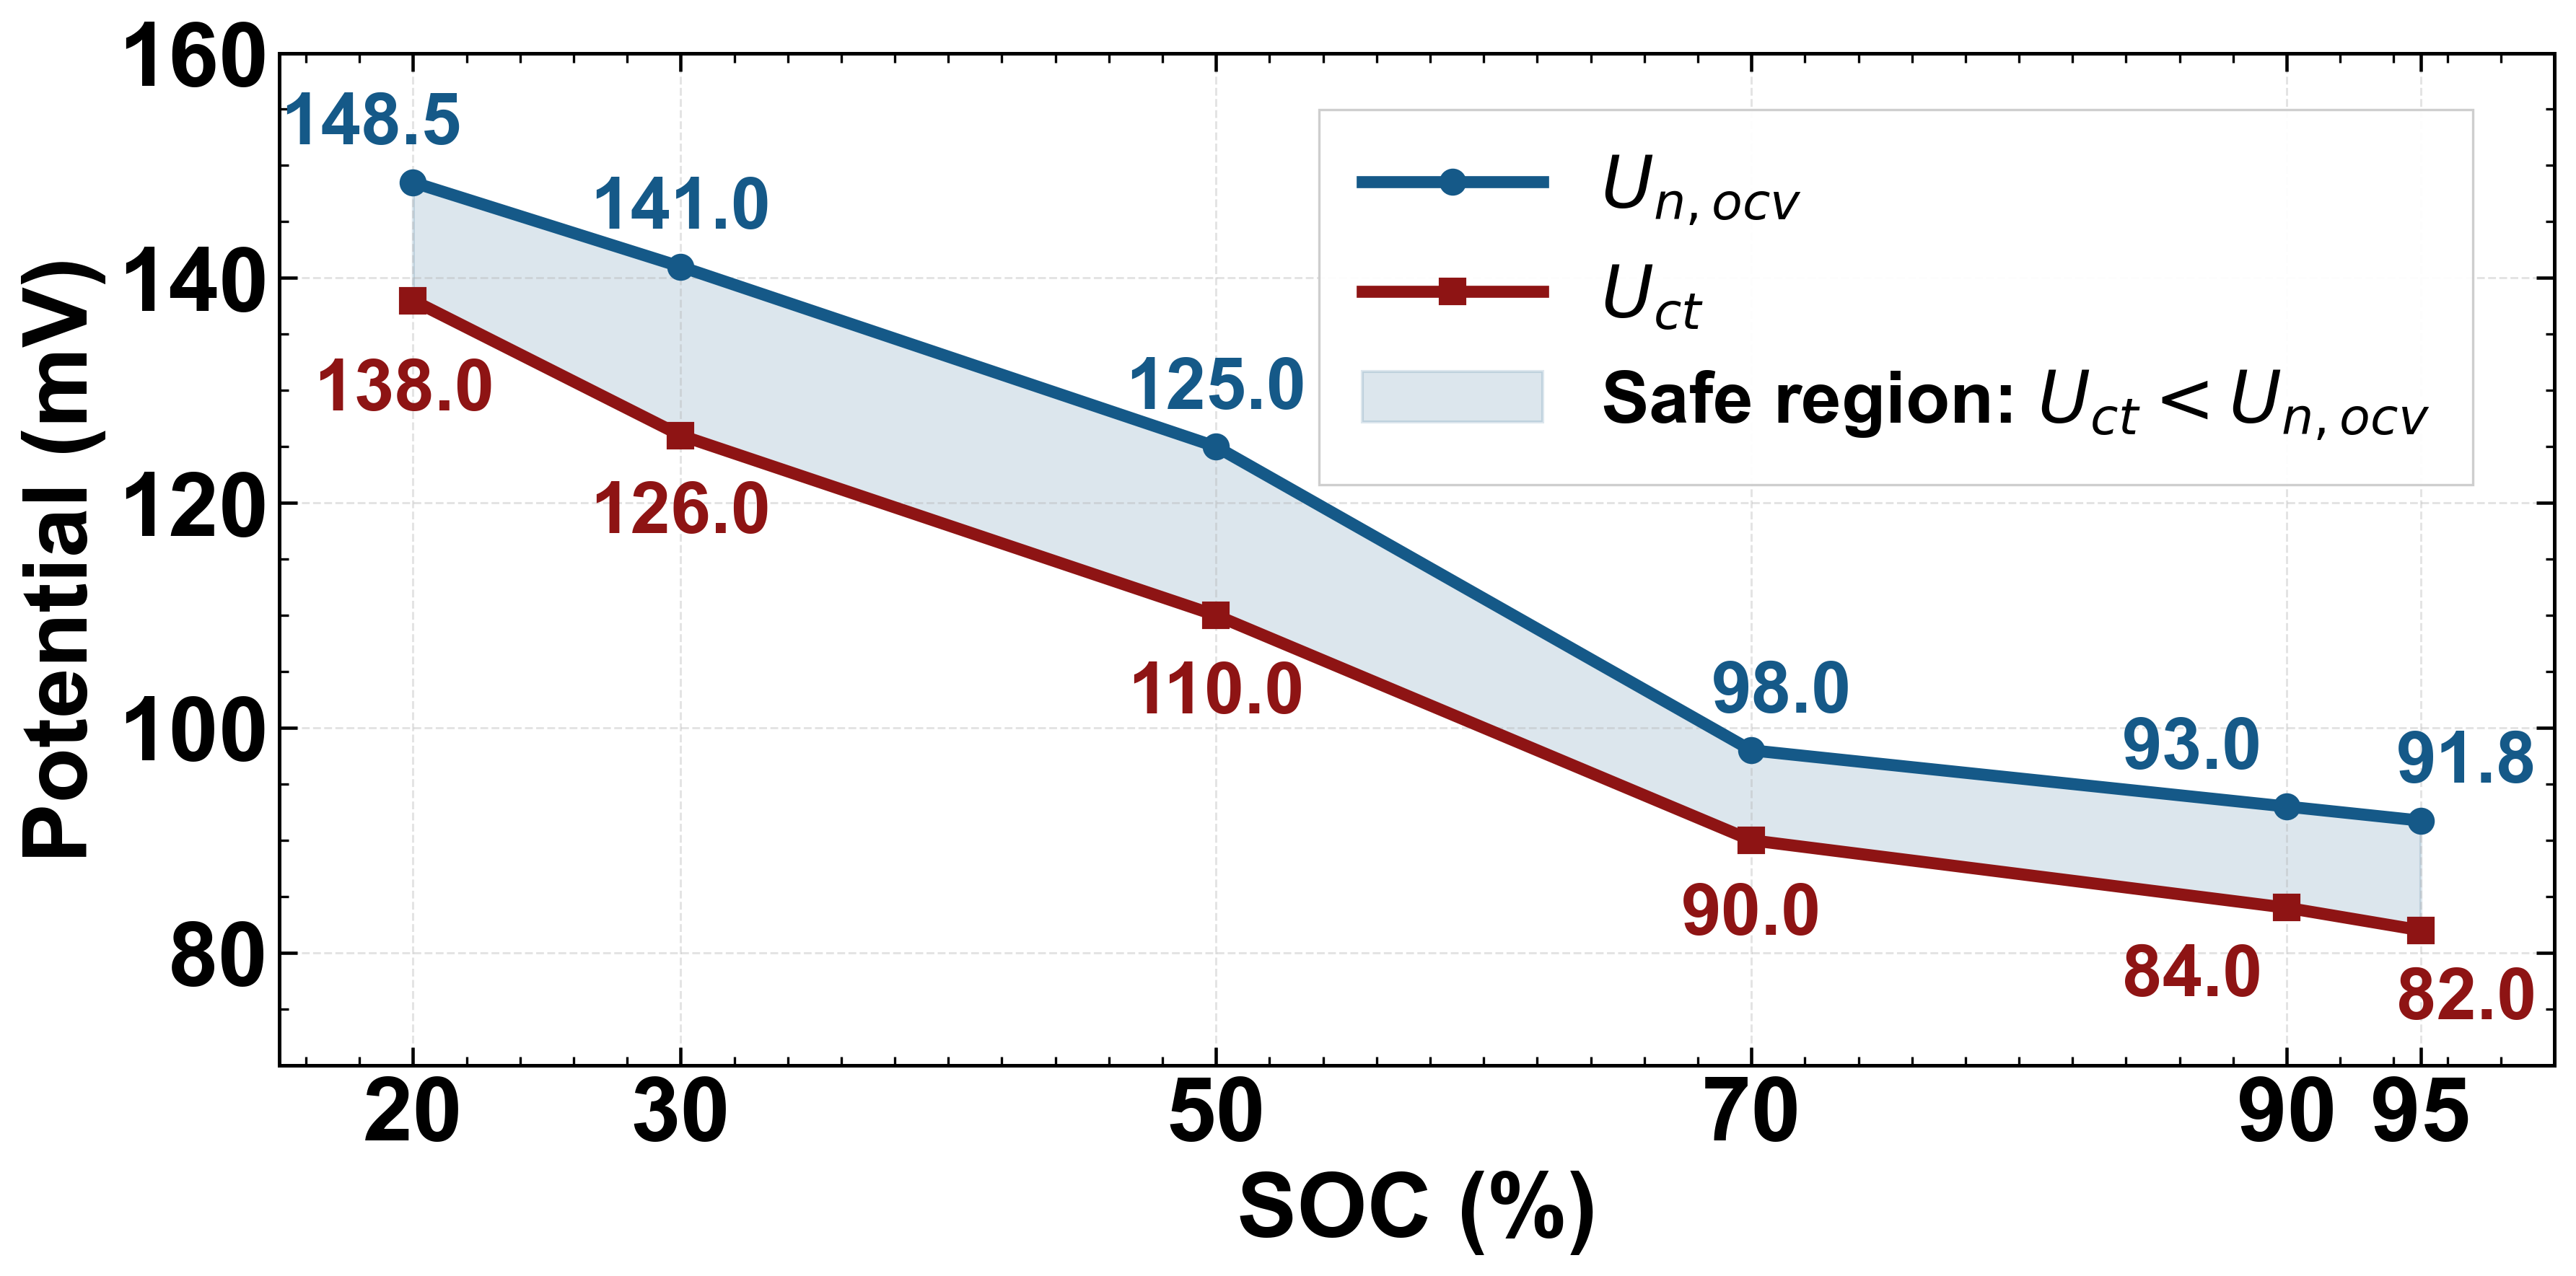

Plotting completed.
SOC points: [95.0, 90.0, 70.0, 50.0, 30.0, 20.0]
U_n,ocv (mV): [91.75, 93.0, 98.0, 125.0, 141.0, 148.5]
U_ct (mV): [82.0, 84.0, 90.0, 110.0, 126.0, 138.0]
Criterion satisfied: True
PNG saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Uct_vs_Unocv_different_SOC.png
PDF saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Uct_vs_Unocv_different_SOC.pdf


In [188]:
# -*- coding: utf-8 -*-
"""
Compare U_ct and U_n,ocv at different SOC values.

Figure meaning:
- Curve 1: anode open-circuit potential U_n,ocv
- Curve 2: U_ct obtained from actual/model data

Criterion:
If U_ct < U_n,ocv at every SOC point, the anti-lithium-plating
criterion is satisfied.

Figure ratio: 3:2
"""

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# 0. USER SETTINGS
# =========================================================

OUTPUT_DIR = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = "Uct_vs_Unocv_different_SOC"

# ---------- Figure ----------
FIGSIZE = (12, 6)   # 3:2
DPI = 300

LINE_WIDTH = 4
MARKER_SIZE = 8

AXIS_LABEL_SIZE = 30
TICK_LABEL_SIZE = 30
LEGEND_SIZE = 24
ANNOTATION_SIZE = 24

SHOW_GRID = True
SHOW_TITLE = False

TITLE_TEXT = "Comparison of $U_{ct}$ and $U_{n,ocv}$ at different SOC values"

X_LABEL = "SOC (%)"
Y_LABEL = "Potential (mV)"

# ---------- Axis range ----------
X_LIM = (15, 100)
Y_LIM = (70, 160)

# ---------- Colors ----------
COLOR_UNOCV = "#155988"   # blue
COLOR_UCT   = "#8e1414"   # red

# ---------- Fill area when Uct < Unocv ----------
SHOW_FILLED_SAFE_REGION = True
SAFE_REGION_ALPHA = 0.15

# ---------- Whether to display text annotations ----------
SHOW_VALUE_LABELS = True


# =========================================================
# 1. DATA
# =========================================================
#
# U_n,ocv data extracted from the first figure:
# SOC = 90%, 70%, 50%, 30%, 10%
# U_n,ocv = 93, 98, 125, 141, 156 mV
#
# Since the later validation pages use SOC = 95%, 90%, 70%, 50%, 30%, 20%,
# we extend the U_n,ocv data as follows:
#
# - SOC = 95%: linearly extrapolated from the 90% and 70% points
# - SOC = 20%: linearly interpolated from the 30% and 10% points

soc = np.array([95, 90, 70, 50, 30, 20], dtype=float)

u_n_ocv = np.array([
    91.75,   # extrapolated from 90% and 70%
    93.00,   # extracted
    98.00,   # extracted
    125.00,  # extracted
    141.00,  # extracted
    148.50   # interpolated from 30% and 10%
], dtype=float)


# =========================================================
# IMPORTANT:
# Replace the following U_ct values with your actual results
# obtained from the second-order fractional-order model / actual data.
# =========================================================
#
# Example only:
# These values are placeholders so that the code can run immediately.
# Please replace them with your real U_ct values.
#
# For example, if you want to compare the maximum U_ct under each SOC,
# then fill the maximum U_ct for each SOC here.

u_ct = np.array([
    82.0,   # SOC 95%
    84.0,   # SOC 90%
    90.0,   # SOC 70%
    110.0,  # SOC 50%
    126.0,  # SOC 30%
    138.0   # SOC 20%
], dtype=float)


# =========================================================
# 2. CHECK
# =========================================================

if len(soc) != len(u_n_ocv) or len(soc) != len(u_ct):
    raise ValueError(
        "soc, u_n_ocv, and u_ct must have the same length."
    )

# Sort by SOC from low to high for nicer plotting
sort_index = np.argsort(soc)
soc_plot = soc[sort_index]
u_n_ocv_plot = u_n_ocv[sort_index]
u_ct_plot = u_ct[sort_index]

# Whether the criterion is satisfied
criterion_satisfied = np.all(u_ct_plot < u_n_ocv_plot)


# =========================================================
# 3. CREATE FIGURE
# =========================================================

fig, ax = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI
)

# Curve 1: U_n,ocv
ax.plot(
    soc_plot,
    u_n_ocv_plot,
    color=COLOR_UNOCV,
    linewidth=LINE_WIDTH,
    marker="o",
    markersize=MARKER_SIZE,
    label=r"$U_{n,ocv}$"
)

# Curve 2: U_ct
ax.plot(
    soc_plot,
    u_ct_plot,
    color=COLOR_UCT,
    linewidth=LINE_WIDTH,
    marker="s",
    markersize=MARKER_SIZE,
    label=r"$U_{ct}$"
)

# Fill safe region
if SHOW_FILLED_SAFE_REGION:
    ax.fill_between(
        soc_plot,
        u_ct_plot,
        u_n_ocv_plot,
        where=(u_n_ocv_plot >= u_ct_plot),
        interpolate=True,
        alpha=SAFE_REGION_ALPHA,
        color=COLOR_UNOCV,
        label=r"Safe region: $U_{ct} < U_{n,ocv}$"
    )


# =========================================================
# 4. VALUE LABELS
# =========================================================

if SHOW_VALUE_LABELS:
    # 各 SOC 下蓝色 U_n,ocv 数值的标注偏移
    # 格式：SOC: ((水平偏移, 垂直偏移), 水平对齐方式, 垂直对齐方式)
    UNOCV_LABEL_SETTINGS = {
        20: ((16, 8), "right", "bottom"),
        30: ((0, 8), "center", "bottom"),
        50: ((0, 8), "center", "bottom"),
        70: ((10, 8), "center", "bottom"),

        # 右侧两个点左右错开，避免 93.0 和 91.8 靠太近
        90: ((-8, 8), "right", "bottom"),
        95: ((-8, 8), "left", "bottom"),
    }

    for x, y in zip(soc_plot, u_n_ocv_plot):

        offset, horizontal_alignment, vertical_alignment = (
            UNOCV_LABEL_SETTINGS[int(x)]
        )

        ax.annotate(
            f"{y:.1f}",
            xy=(x, y),
            xytext=offset,
            textcoords="offset points",
            ha=horizontal_alignment,
            va=vertical_alignment,
            fontsize=ANNOTATION_SIZE,
            fontweight="bold",
            color=COLOR_UNOCV,
            zorder=5
        )

    UCT_LABEL_SETTINGS = {
        20: ((-3, -19), "center"),
        30: ((0, -15), "center"),
        50: ((0, -15), "center"),
        70: ((0, -14), "center"),

        # 右侧两个点左右错开，避免 84.0 和 82.0 重叠
        90: ((-8, -12), "right"),
        95: ((-8, -12), "left"),
    }

    for x, y in zip(soc_plot, u_ct_plot):

        offset, horizontal_alignment = UCT_LABEL_SETTINGS[int(x)]

        ax.annotate(
            f"{y:.1f}",
            xy=(x, y),
            xytext=offset,
            textcoords="offset points",
            ha=horizontal_alignment,
            va="top",
            fontsize=ANNOTATION_SIZE,
            fontweight="bold",
            color=COLOR_UCT,
            zorder=5
        )


# =========================================================
# 5. AXIS SETTINGS
# =========================================================

ax.set_xlabel(
    X_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

ax.set_ylabel(
    Y_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

if SHOW_TITLE:
    ax.set_title(
        TITLE_TEXT,
        fontsize=17,
        fontweight="bold",
        pad=12
    )

ax.set_xlim(*X_LIM)
ax.set_ylim(*Y_LIM)

ax.set_xticks([20, 30, 50, 70, 90, 95])

ax.tick_params(
    axis="both",
    which="major",
    labelsize=TICK_LABEL_SIZE,
    direction="in",
    top=True,
    right=True,
    length=6,
    width=1.1
)

ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=3,
    width=0.8
)

ax.minorticks_on()

plt.setp(ax.get_xticklabels(), fontweight="bold")
plt.setp(ax.get_yticklabels(), fontweight="bold")

for spine in ax.spines.values():
    spine.set_linewidth(1.2)

if SHOW_GRID:
    ax.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35
    )


# =========================================================
# 6. LEGEND
# =========================================================

legend = ax.legend(
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    prop={
        "size": LEGEND_SIZE,
        "weight": "bold"
    },
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    borderpad=0.6,
    handlelength=2.5
)
legend.get_frame().set_linewidth(0.8)



# =========================================================
# 8. SAVE AND SHOW
# =========================================================

fig.tight_layout()

png_path = OUTPUT_DIR / f"{OUTPUT_NAME}.png"
pdf_path = OUTPUT_DIR / f"{OUTPUT_NAME}.pdf"

fig.savefig(
    png_path,
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Plotting completed.")
print("SOC points:", soc.tolist())
print("U_n,ocv (mV):", u_n_ocv.tolist())
print("U_ct (mV):", u_ct.tolist())
print("Criterion satisfied:", criterion_satisfied)
print(f"PNG saved to:\n{png_path}")
print(f"PDF saved to:\n{pdf_path}")

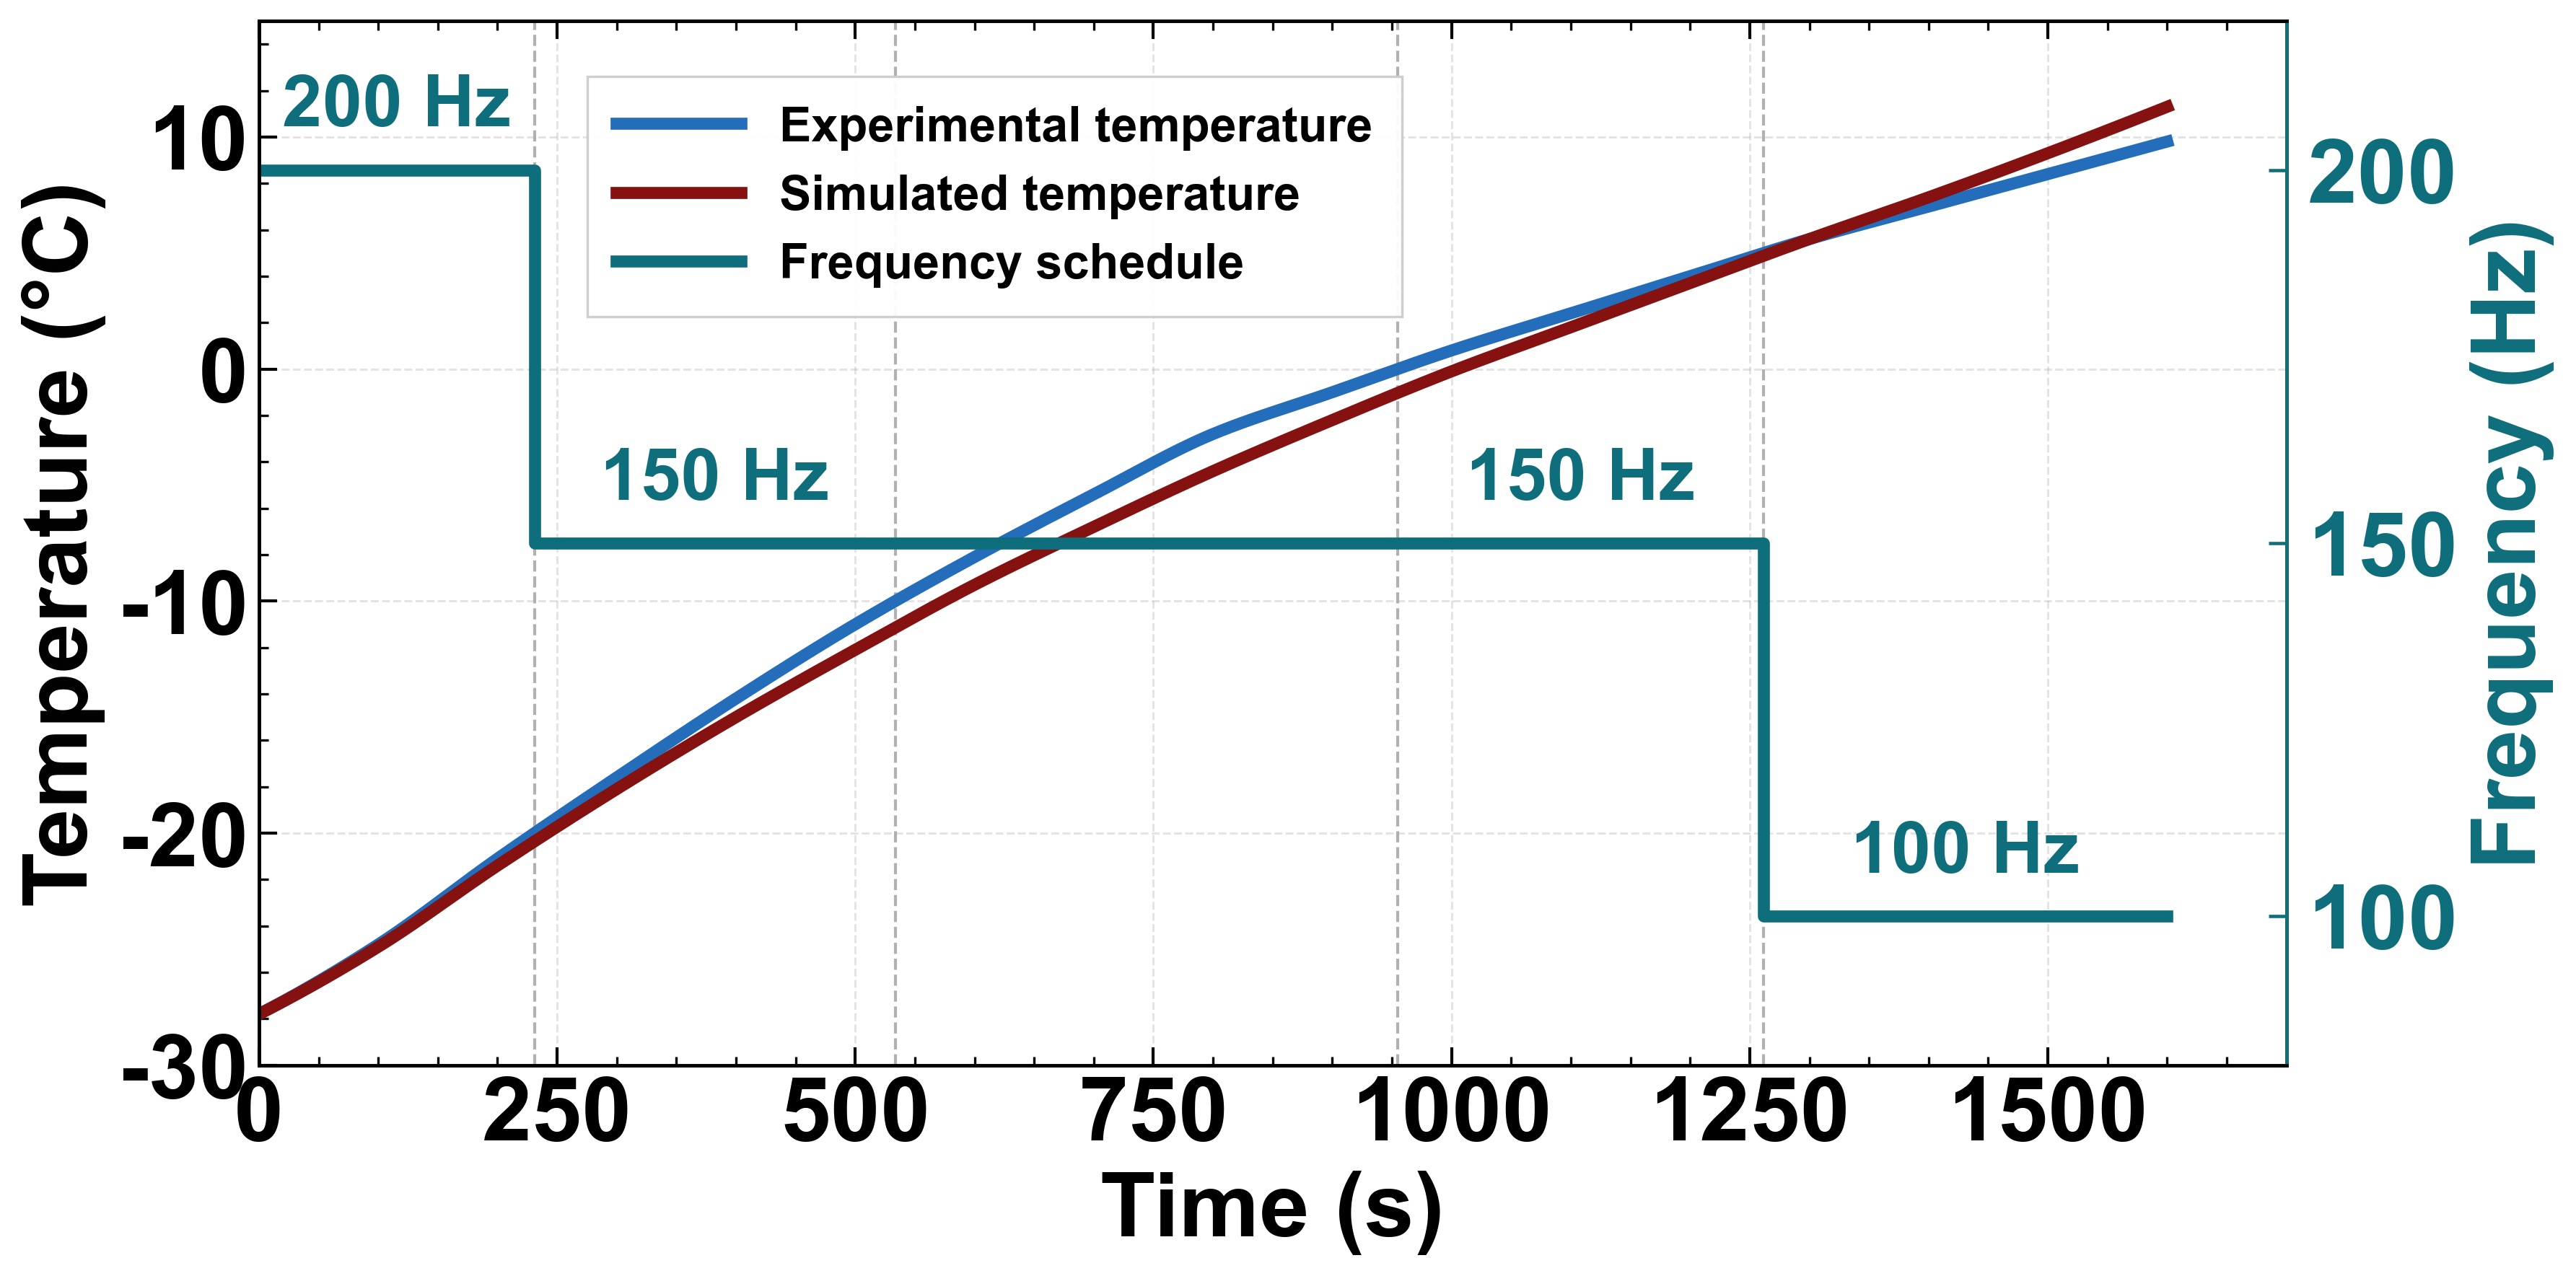

Plotting completed.
PNG saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\SOC50_temperature_and_frequency_dual_y.png
PDF saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\SOC50_temperature_and_frequency_dual_y.pdf

Estimated stage transition times based on the experimental curve:
  T =  -20 °C  -->  t ≈ 230.9 s
  T =  -10 °C  -->  t ≈ 533.5 s
  T =    0 °C  -->  t ≈ 954.8 s
  T =    5 °C  -->  t ≈ 1261.5 s


: 

In [ ]:
# -*- coding: utf-8 -*-
"""
Dual-y plot for SOC = 50%:

Left y-axis:
    Experimental and simulated temperature curves
Right y-axis:
    Frequency schedule in different temperature stages

The temperature data are approximately digitized from the provided figure.
The frequency stages are determined according to the table:
    -30 to -20 °C : 200 Hz
    -20 to -10 °C : 150 Hz
    -10 to   0 °C : 150 Hz
      0 to   5 °C : 150 Hz
      5 to  10 °C : 100 Hz

Figure aspect ratio = 2:1
"""

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from matplotlib.ticker import NullLocator


# =========================================================
# 0. USER SETTINGS
# =========================================================

OUTPUT_DIR = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = "SOC50_temperature_and_frequency_dual_y"

# Figure ratio = 2:1
FIGSIZE = (12, 6)
DPI = 300

# Line styles
TEMP_LINE_WIDTH = 4
FREQ_LINE_WIDTH = 4
MARKER_SIZE = 0

# Fonts
AXIS_LABEL_SIZE = 30
TICK_LABEL_SIZE = 30
LEGEND_SIZE = 16
ANNOTATION_SIZE = 24
TITLE_SIZE = 30

SHOW_TITLE = False
TITLE_TEXT = "SOC = 50%: temperature and frequency schedule"

# Axes labels
X_LABEL = "Time (s)"
Y1_LABEL = "Temperature (°C)"
Y2_LABEL = "Frequency (Hz)"

# Axis ranges
X_LIM = (0, 1700)
Y1_LIM = (-30, 15)
Y2_LIM = (80, 210)

SHOW_GRID = True

# Colors
COLOR_EXP = "#236DBB"       # blue
COLOR_SIM = "#851111"       # orange
COLOR_FREQ = "#0F6E7B"      # green
COLOR_BOUNDARY = "#888888"  # gray

# Legend
LEGEND_LOC = "upper right"
LEGEND_BBOX = (0.98, 0.98)

# Temperature-stage boundaries to show as vertical lines
SHOW_STAGE_BOUNDARIES = True
BOUNDARY_LINESTYLE = "--"
BOUNDARY_LINEWIDTH = 1.0
BOUNDARY_ALPHA = 0.65

# Show frequency labels
SHOW_FREQUENCY_LABELS = True

# ---------- Right frequency axis ----------
FREQUENCY_Y_MIN = 80
FREQUENCY_Y_MAX = 220

# 右轴只显示实际使用的三个频率
FREQUENCY_MAJOR_TICKS = [100, 150, 200]


# ---------- Legend position ----------
# 坐标采用轴内相对位置：
# (0, 0) = 左下角
# (1, 1) = 右上角
LEGEND_LOC = "upper left"
LEGEND_BBOX = (0.15, 0.97)

LEGEND_NCOL = 1


# =========================================================
# 1. APPROXIMATELY DIGITIZED TEMPERATURE DATA
# =========================================================
#
# These data are approximately extracted from the SOC50% figure.
# Blue line: experimental value
# Orange line: simulated value

time_exp = np.array([
    0, 100, 200, 300, 400, 500, 600, 700, 800,
    900, 1000, 1100, 1200, 1300, 1400, 1500, 1600
], dtype=float)

temp_exp = np.array([
    -27.8, -24.8, -21.1, -17.6, -14.2, -11.0, -8.1, -5.4, -2.8,
    -1.0, 0.8, 2.4, 4.0, 5.6, 7.0, 8.4, 9.8
], dtype=float)

time_sim = np.array([
    0, 100, 200, 300, 400, 500, 600, 700, 800,
    900, 1000, 1100, 1200, 1300, 1400, 1500, 1600
], dtype=float)

temp_sim = np.array([
    -27.8, -24.9, -21.4, -18.1, -15.0, -12.1, -9.3, -6.8, -4.4,
    -2.2, -0.1, 1.8, 3.7, 5.6, 7.4, 9.3, 11.3
], dtype=float)


# =========================================================
# 2. FREQUENCY STAGE TABLE (FROM THE LEFT TABLE)
# =========================================================

# Temperature interval lower bound, upper bound, frequency
stage_table = [
    (-30, -20, 200),
    (-20, -10, 150),
    (-10,   0, 150),
    (  0,   5, 150),
    (  5,  10, 100),
]


# =========================================================
# 3. HELPER FUNCTIONS
# =========================================================

def make_smooth_curve(x, y, n_points=1200):
    """
    Smooth the digitized curve using PCHIP interpolation.
    """
    interpolator = PchipInterpolator(x, y)
    x_dense = np.linspace(x.min(), x.max(), n_points)
    y_dense = interpolator(x_dense)
    return x_dense, y_dense


def find_crossing_time(x, y, target):
    """
    Find the approximate time when y crosses the target value.
    Assumes y is monotonic increasing.
    """
    for i in range(len(y) - 1):
        y0 = y[i]
        y1 = y[i + 1]

        if (y0 <= target <= y1) or (y1 <= target <= y0):
            x0 = x[i]
            x1 = x[i + 1]

            if abs(y1 - y0) < 1e-12:
                return x0

            ratio = (target - y0) / (y1 - y0)
            return x0 + ratio * (x1 - x0)

    return None


# =========================================================
# 4. GENERATE SMOOTH TEMPERATURE CURVES
# =========================================================

t_exp_dense, temp_exp_dense = make_smooth_curve(time_exp, temp_exp)
t_sim_dense, temp_sim_dense = make_smooth_curve(time_sim, temp_sim)


# =========================================================
# 5. DETERMINE STAGE TRANSITION TIMES
# =========================================================
#
# The frequency schedule is generated according to the experimental
# temperature curve.

# Starting time and ending time
t_start = float(t_exp_dense[0])
t_end = float(t_exp_dense[-1])

# Stage boundaries in temperature
temperature_boundaries = [-20, -10, 0, 5, 10]

# Find the crossing time for each temperature boundary
boundary_times = []

for boundary in temperature_boundaries:
    crossing_time = find_crossing_time(
        t_exp_dense,
        temp_exp_dense,
        boundary
    )

    if crossing_time is not None:
        boundary_times.append((boundary, crossing_time))

# Build stage time segments
# Example:
# [0, t(-20), t(-10), t(0), t(5), t(10)]
stage_times = [t_start]
stage_times.extend([item[1] for item in boundary_times])

# If the last crossing is not exactly the end time, add the end time
if stage_times[-1] < t_end:
    stage_times.append(t_end)

# Frequency values for each interval
stage_frequencies = [200, 150, 150, 150, 100]

# For step plotting with where='post', the y array should match x length
freq_step_x = np.array(stage_times, dtype=float)
freq_step_y = np.array([200, 150, 150, 150, 100, 100], dtype=float)

# If there are not enough stage transitions for any reason,
# fall back safely
if len(freq_step_x) != len(freq_step_y):
    freq_step_x = np.array([0, 200, 600, 1000, 1300, t_end], dtype=float)
    freq_step_y = np.array([200, 150, 150, 150, 100, 100], dtype=float)


# =========================================================
# 6. CREATE FIGURE
# =========================================================

fig, ax1 = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI
)

# Left y-axis: temperature
line_exp, = ax1.plot(
    t_exp_dense,
    temp_exp_dense,
    color=COLOR_EXP,
    linewidth=TEMP_LINE_WIDTH,
    label="Experimental temperature"
)

line_sim, = ax1.plot(
    t_sim_dense,
    temp_sim_dense,
    color=COLOR_SIM,
    linewidth=TEMP_LINE_WIDTH,
    label="Simulated temperature"
)

ax1.set_xlabel(
    X_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

ax1.set_ylabel(
    Y1_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold"
)

if SHOW_TITLE:
    ax1.set_title(
        TITLE_TEXT,
        fontsize=TITLE_SIZE,
        fontweight="bold",
        pad=10
    )

ax1.set_xlim(*X_LIM)
ax1.set_ylim(*Y1_LIM)

# Right y-axis: frequency
ax2 = ax1.twinx()

line_freq, = ax2.step(
    freq_step_x,
    freq_step_y,
    where="post",
    color=COLOR_FREQ,
    linewidth=FREQ_LINE_WIDTH,
    linestyle="-",
    label="Frequency schedule"
)

ax2.set_ylabel(
    Y2_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight="bold",
    color=COLOR_FREQ
)

from matplotlib.ticker import NullLocator

ax2.set_ylim(
    FREQUENCY_Y_MIN,
    FREQUENCY_Y_MAX
)

# 右轴只显示这些主刻度
ax2.set_yticks(FREQUENCY_MAJOR_TICKS)

# 关闭右轴小刻度
ax2.yaxis.set_minor_locator(NullLocator())

ax2.tick_params(
    axis="y",
    which="major",
    direction="in",
    right=True,
    left=False,
    labelright=True,
    labelleft=False,
    length=6,
    width=1.1,
    labelsize=TICK_LABEL_SIZE,
    pad=7,

    # 关键：颜色改成和频率线一致
    colors=COLOR_FREQ
)

ax2.tick_params(
    axis="y",
    which="minor",
    right=False,
    left=False
)

# 右侧数字颜色、粗体
plt.setp(
    ax2.get_yticklabels(),
    fontweight="bold",
    color=COLOR_FREQ
)

# 右侧 spine 也改成同色
ax2.spines["right"].set_color(COLOR_FREQ)
ax2.yaxis.label.set_color(COLOR_FREQ)
plt.setp(
    ax2.get_yticklabels(),
    fontweight="bold"
)


# =========================================================
# 7. STAGE BOUNDARY LINES
# =========================================================

if SHOW_STAGE_BOUNDARIES:
    for temp_boundary, crossing_time in boundary_times:
        ax1.axvline(
            x=crossing_time,
            color=COLOR_BOUNDARY,
            linestyle=BOUNDARY_LINESTYLE,
            linewidth=BOUNDARY_LINEWIDTH,
            alpha=BOUNDARY_ALPHA,
            zorder=0
        )


# =========================================================
# 8. FREQUENCY LABELS
# =========================================================

if SHOW_FREQUENCY_LABELS:
    for i in range(len(freq_step_x) - 1):

        # 跳过中间那个 150 Hz
        if i == 2:
            continue

        x_mid = 0.5 * (freq_step_x[i] + freq_step_x[i + 1])
        y_val = freq_step_y[i]

        ax2.text(
            x_mid,
            y_val + 4,
            f"{int(y_val)} Hz",
            color=COLOR_FREQ,
            fontsize=ANNOTATION_SIZE,
            fontweight="bold",
            ha="center",
            va="bottom"
        )

# =========================================================
# 9. TICKS AND STYLE
# =========================================================

# =========================================================
# LEFT AXIS TICKS
# =========================================================

ax1.tick_params(
    axis="both",
    which="major",
    labelsize=TICK_LABEL_SIZE,
    direction="in",
    top=True,
    bottom=True,
    left=True,
    right=False,
    length=6,
    width=1.0
)

ax1.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    bottom=True,
    left=True,
    right=False,
    length=3,
    width=0.8
)

# 左侧温度轴可以保留小刻度
ax1.minorticks_on()

plt.setp(
    ax1.get_xticklabels(),
    fontweight="bold"
)

plt.setp(
    ax1.get_yticklabels(),
    fontweight="bold"
)

# Make tick labels bold
plt.setp(ax1.get_xticklabels(), fontweight="bold")
plt.setp(ax1.get_yticklabels(), fontweight="bold")
plt.setp(ax2.get_yticklabels(), fontweight="bold")

# Spine width
for spine in ax1.spines.values():
    spine.set_linewidth(1.1)

for spine in ax2.spines.values():
    spine.set_linewidth(1.1)

# Grid
if SHOW_GRID:
    ax1.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.7,
        alpha=0.35
    )


# =========================================================
# 10. LEGEND
# =========================================================

handles = [
    line_exp,
    line_sim,
    line_freq
]

labels = [
    handle.get_label()
    for handle in handles
]

legend = ax1.legend(
    handles,
    labels,

    # 控制 legend 的锚点和位置
    loc=LEGEND_LOC,
    bbox_to_anchor=LEGEND_BBOX,
    bbox_transform=ax1.transAxes,

    ncol=LEGEND_NCOL,

    prop={
        "size": LEGEND_SIZE,
        "weight": "bold"
    },

    frameon=True,
    fancybox=False,
    framealpha=0.95,
    borderpad=0.6,
    handlelength=2.6,
    columnspacing=1.0
)

legend.get_frame().set_linewidth(0.8)


# =========================================================
# 11. SAVE AND SHOW
# =========================================================

fig.tight_layout()

png_path = OUTPUT_DIR / f"{OUTPUT_NAME}.png"
pdf_path = OUTPUT_DIR / f"{OUTPUT_NAME}.pdf"

fig.savefig(
    png_path,
    dpi=DPI,
    bbox_inches="tight"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

print("Plotting completed.")
print(f"PNG saved to:\n{png_path}")
print(f"PDF saved to:\n{pdf_path}")

print("\nEstimated stage transition times based on the experimental curve:")
for temp_boundary, crossing_time in boundary_times:
    print(f"  T = {temp_boundary:>4} °C  -->  t ≈ {crossing_time:.1f} s")

c:\Users\TT-we\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



Detected BcuSnsrT channels:
['BcuSnsrT1[℃]', 'BcuSnsrT2[℃]', 'BcuSnsrT3[℃]', 'BcuSnsrT4[℃]', 'BcuSnsrT5[℃]', 'BcuSnsrT6[℃]', 'BcuSnsrT7[℃]', 'BcuSnsrT8[℃]', 'BcuSnsrT9[℃]', 'BcuSnsrT10[℃]', 'BcuSnsrT11[℃]', 'BcuSnsrT12[℃]', 'BcuSnsrT13[℃]', 'BcuSnsrT14[℃]', 'BcuSnsrT15[℃]', 'BcuSnsrT16[℃]', 'BcuSnsrT17[℃]', 'BcuSnsrT18[℃]']
Total sensor channels: 18


C:\Users\TT-we\AppData\Local\Temp\ipykernel_42812\710763624.py:413: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime_time = pd.to_datetime(series, errors="coerce")



Detected BcuSnsrT channels:
['BcuSnsrT1[℃]', 'BcuSnsrT2[℃]', 'BcuSnsrT3[℃]', 'BcuSnsrT4[℃]', 'BcuSnsrT5[℃]', 'BcuSnsrT6[℃]', 'BcuSnsrT7[℃]', 'BcuSnsrT8[℃]', 'BcuSnsrT9[℃]', 'BcuSnsrT10[℃]', 'BcuSnsrT11[℃]', 'BcuSnsrT12[℃]', 'BcuSnsrT13[℃]', 'BcuSnsrT14[℃]', 'BcuSnsrT15[℃]', 'BcuSnsrT16[℃]', 'BcuSnsrT17[℃]', 'BcuSnsrT18[℃]']
Total sensor channels: 18


C:\Users\TT-we\AppData\Local\Temp\ipykernel_42812\710763624.py:413: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime_time = pd.to_datetime(series, errors="coerce")
c:\Users\TT-we\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")



Detected BcuSnsrT channels:
['BcuSnsrT1[℃]', 'BcuSnsrT2[℃]', 'BcuSnsrT3[℃]', 'BcuSnsrT4[℃]', 'BcuSnsrT5[℃]', 'BcuSnsrT6[℃]', 'BcuSnsrT7[℃]', 'BcuSnsrT8[℃]', 'BcuSnsrT9[℃]', 'BcuSnsrT10[℃]', 'BcuSnsrT11[℃]', 'BcuSnsrT12[℃]', 'BcuSnsrT13[℃]', 'BcuSnsrT14[℃]', 'BcuSnsrT15[℃]', 'BcuSnsrT16[℃]', 'BcuSnsrT17[℃]', 'BcuSnsrT18[℃]']
Total sensor channels: 18

87 Ah pack heating-rate statistics

SOC = 90%
File: 2026.06.03.10.35.27.648_纹波设备.通道_策略1_001.xlsx
Heating window: 0.00-2548.57 s (automatic peak detection)
Count:   18
Mean:    1.0474
Min:     0.9450
Q1:      0.9923
Median:  1.0632
Q3:      1.1104
Max:     1.1341

SOC = 70%
File: 2026.06.04.14.51.27.299_纹波设备.通道_策略2_001.xlsx
Heating window: 0.00-2580.00 s (manual)
Count:   18
Mean:    1.0251
Min:     0.9336
Q1:      0.9802
Median:  1.0503
Q3:      1.0713
Max:     1.0969

SOC = 50%
File: 2026.06.05.11.04.59.690_纹波设备.通道_策略3_001.xlsx
Heating window: 0.00-2432.81 s (automatic peak detection)
Count:   18
Mean:    1.0954
Min:     0.9902
Q1:      

C:\Users\TT-we\AppData\Local\Temp\ipykernel_42812\710763624.py:413: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datetime_time = pd.to_datetime(series, errors="coerce")



PNG saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\pack_and_module_heating_rate_boxplot.png


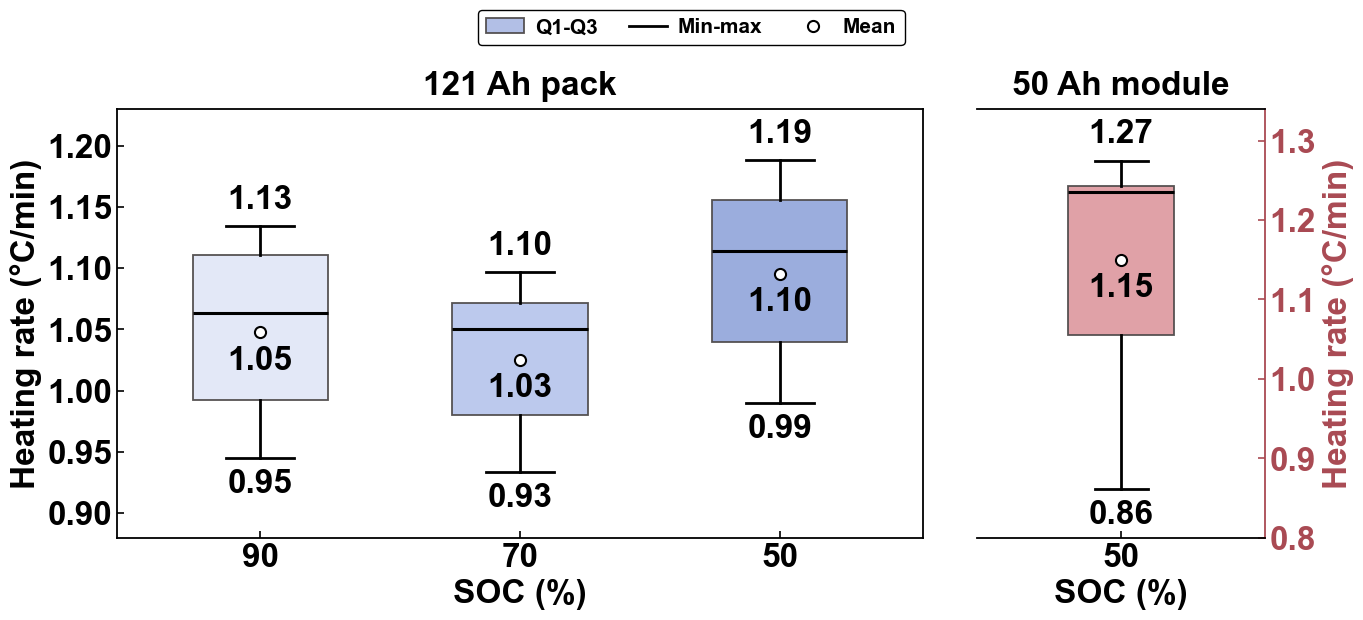


Excel summary saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\Figure_2\pack_and_module_heating_rate_boxplot_summary.xlsx


In [279]:
# -*- coding: utf-8 -*-
"""
Combined heating-rate boxplot:

Left panel:
    87 Ah pack, SOC = 90%, 70%, and 50%.
    Data are read directly from the three Excel files.

Right panel:
    50 Ah module, SOC = 50%.
    Battery-surface-temperature curves for cells 1-12 were approximately
    digitized from the supplied figures. Only the blue surface-temperature
    curves are used.

For every channel/cell:
    average heating rate = temperature rise / heating duration

Boxplot definition:
    box       = Q1-Q3
    center line = median
    whiskers  = minimum-maximum
    white circle = mean
"""

# =========================================================
# 0. ALL USER-ADJUSTABLE SETTINGS
# =========================================================

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ---------------------------------------------------------
# 0.1 Input: 87 Ah pack Excel files
# ---------------------------------------------------------

BASE_DIR = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大"
)

SHEET_NAME = "数据记录"

PACK_CASE_SETTINGS = [
    {
        "soc": 90,
        "file_name": "2026.06.03.10.35.27.648_纹波设备.通道_策略1_001.xlsx",
        "color": "#E2E7F7",
    },
    {
        "soc": 70,
        "file_name": "2026.06.04.14.51.27.299_纹波设备.通道_策略2_001.xlsx",
        "color": "#B9C6EC",
    },
    {
        "soc": 50,
        "file_name": "2026.06.05.11.04.59.690_纹波设备.通道_策略3_001.xlsx",
        "color": "#96A9DC",
    },
]


# ---------------------------------------------------------
# 0.2 BcuSnsrT channel selection
# ---------------------------------------------------------

# Accept BcuSnsrT followed by a numeric ID.
SENSOR_COLUMN_PATTERN = r"BcuSnsrT\s*[_\-]?\s*0*(\d+)"

# Exclude statistical columns such as Max, Min, Avg, and Mean.
EXCLUDED_SENSOR_KEYWORDS = [
    "max",
    "min",
    "avg",
    "average",
    "mean",
]

# Exclude specified sensor IDs, e.g. [17, 18].
EXCLUDE_SENSOR_NUMBERS = []

# Delete the final data rows, not sensor columns.
DROP_LAST_N_ROWS = 3

MIN_SENSOR_COUNT = 2
MIN_VALID_SENSORS_PER_ROW = 2
MIN_POINTS_PER_SENSOR = 5


# ---------------------------------------------------------
# 0.3 Time settings for Excel data
# ---------------------------------------------------------

TIME_COLUMN_CANDIDATES = [
    "Time(s)",
    "Time (s)",
    "Time",
    "time",
    "时间(s)",
    "时间（s）",
    "时间",
    "采样时间(s)",
    "采样时间",
    "记录时间",
]

# Numeric time already in seconds: 1.0
# Numeric time in milliseconds: 0.001
TIME_SCALE_TO_SECONDS = 1.0

NORMALIZE_TIME_TO_ZERO = True
USE_INDEX_AS_TIME_IF_NOT_FOUND = True
FALLBACK_SAMPLE_INTERVAL_S = 1.0


# ---------------------------------------------------------
# 0.4 Heating windows for the 87 Ah pack
# ---------------------------------------------------------

# "auto_peak": from first valid sample to the peak mean temperature.
# "full": use the complete valid record.
DEFAULT_HEATING_WINDOW_MODE = "auto_peak"

# Manual time windows in seconds. None uses the default mode.
PACK_MANUAL_HEATING_WINDOWS_S = {
    90: None,
    70: (0.0, 2580.0),
    50: None,
}

PEAK_SMOOTH_WINDOW_POINTS = 21
MIN_HEATING_DURATION_S = 10.0


# ---------------------------------------------------------
# 0.5 Heating-rate calculation
# ---------------------------------------------------------

# "endpoint": (T_end - T_start) / (t_end - t_start)
# "linear_fit": linear-regression slope over the full heating window
PACK_RATE_METHOD = "endpoint"
MODULE_RATE_METHOD = "endpoint"

PACK_ENDPOINT_AVERAGE_POINTS = 10
MODULE_ENDPOINT_AVERAGE_POINTS = 1

# "C_per_min" or "C_per_s"
RATE_OUTPUT_UNIT = "C_per_min"
USE_ABSOLUTE_RATE = False


# ---------------------------------------------------------
# 0.6 Digitized 50 Ah module data
# ---------------------------------------------------------

# These values were approximately digitized from the supplied figures.
# Only the blue battery-surface-temperature curves are included.
# Time unit: s; temperature unit: °C.
MODULE_SOC = 50
MODULE_CAPACITY_AH = 50
MODULE_COLOR = "#DF9CA2"
MODULE_AXIS_COLOR = "#A94A53"

MODULE_TIME_S = np.array(
    [0, 200, 400, 600, 800, 1000, 1200, 1400, 1600],
    dtype=float,
)

MODULE_SURFACE_TEMPERATURE_C = {
    1:  [-14.14, -11.37, -8.99, -6.70, -4.19, -1.18,  2.64,  7.57, 13.90],
    2:  [-14.10, -11.50, -8.98, -6.28, -3.17,  0.60,  5.29, 11.13, 18.37],
    3:  [-14.16, -11.36, -8.75, -6.03, -2.92,  0.85,  5.59, 11.56, 19.06],
    4:  [-14.10, -11.35, -8.86, -6.29, -3.31,  0.43,  5.27, 11.54, 19.58],
    5:  [-14.30, -11.45, -8.88, -6.24, -3.19,  0.59,  5.44, 11.69, 19.69],
    6:  [-14.26, -11.69, -9.51, -7.47, -5.34, -2.90,  0.10,  3.90,  8.72],
    7:  [-14.17, -11.59, -9.40, -7.37, -5.23, -2.74,  0.33,  4.25,  9.25],
    8:  [-14.09, -11.02, -8.32, -5.64, -2.67,  0.94,  5.51, 11.38, 18.87],
    9:  [-13.52, -11.03, -8.59, -5.93, -2.81,  1.05,  5.89, 11.97, 19.56],
    10: [-13.95, -11.35, -8.88, -6.27, -3.23,  0.53,  5.29, 11.34, 18.96],
    11: [-13.97, -11.30, -8.78, -6.14, -3.07,  0.70,  5.47, 11.52, 19.15],
    12: [-14.01, -11.05, -8.60, -6.33, -3.90, -0.97,  2.78,  7.71, 14.15],
}


# ---------------------------------------------------------
# 0.7 Output
# ---------------------------------------------------------

OUTPUT_DIR = BASE_DIR / "出图" / "Figure_2"
OUTPUT_BASENAME = "pack_and_module_heating_rate_boxplot"

SAVE_PNG = True
SAVE_PDF = False
SAVE_EXCEL_SUMMARY = True

DPI = 300
BBOX_INCHES = "tight"
PAD_INCHES = 0.10


# ---------------------------------------------------------
# 0.8 Figure layout
# ---------------------------------------------------------

FIGSIZE = (13.5, 6.4)
FIG_FACE_COLOR = "white"
AX_FACE_COLOR = "white"

PANEL_WIDTH_RATIOS = (3.5, 1.25)
PANEL_WSPACE = 0.10

FIG_LEFT = 0.075
FIG_RIGHT = 0.925
FIG_BOTTOM = 0.15
FIG_TOP = 0.82

MAIN_PANEL_TITLE = "121 Ah pack"
MODULE_PANEL_TITLE = "50 Ah module"
SHOW_PANEL_TITLES = True


# ---------------------------------------------------------
# 0.9 Fonts
# ---------------------------------------------------------

FONT_FAMILY = [
    "Arial",
    "DejaVu Sans",
    "Liberation Sans",
]

FONT_WEIGHT = "bold"
AXIS_LABEL_FONTSIZE = 24
TICK_FONTSIZE = 24
ANNOTATION_FONTSIZE = 24
LEGEND_FONTSIZE = 15
PANEL_TITLE_FONTSIZE = 24


# ---------------------------------------------------------
# 0.10 Axis labels and ranges
# ---------------------------------------------------------

MAIN_X_LABEL = "SOC (%)"
MODULE_X_LABEL = "SOC (%)"

if RATE_OUTPUT_UNIT == "C_per_min":
    MAIN_Y_LABEL = "Heating rate (°C/min)"
    MODULE_Y_LABEL = "Heating rate (°C/min)"
else:
    MAIN_Y_LABEL = "Heating rate (°C/s)"
    MODULE_Y_LABEL = "Heating rate (°C/s)"

# Independent y-axis ranges.
MAIN_Y_LIMIT = (0.88, 1.23)
MODULE_Y_LIMIT = (0.80, 1.34)

MAIN_Y_TICKS = np.arange(0.90, 1.21, 0.05)
MODULE_Y_TICKS = np.arange(0.80, 1.31, 0.10)

MAIN_X_LIMIT = (-0.55, 2.55)
MODULE_X_LIMIT = (-0.65, 0.65)


# ---------------------------------------------------------
# 0.11 Boxplot appearance
# ---------------------------------------------------------

MAIN_BOX_WIDTH = 0.52
MODULE_BOX_WIDTH = 0.48
BOX_ALPHA = 0.95

BOX_EDGE_COLOR = "#4E4A4A"
BOX_EDGE_WIDTH = 1.3

MEDIAN_COLOR = "black"
MEDIAN_LINEWIDTH = 2.2

WHISKER_COLOR = "black"
WHISKER_LINEWIDTH = 2.0
CAP_LINEWIDTH = 2.0

MEAN_MARKER = "o"
MEAN_MARKER_SIZE = 8
MEAN_MARKER_FACE = "white"
MEAN_MARKER_EDGE = "black"
MEAN_MARKER_EDGEWIDTH = 1.5

SHOW_INDIVIDUAL_POINTS = False
POINT_SIZE = 24
POINT_ALPHA = 0.40
POINT_COLOR = "black"
POINT_JITTER = 0.07
RANDOM_SEED = 42


# ---------------------------------------------------------
# 0.12 Value annotations
# ---------------------------------------------------------

SHOW_MEAN_VALUE = True
SHOW_MIN_MAX_VALUES = True

VALUE_FORMAT = "{:.2f}"
VALUE_COLOR = "black"

MEAN_TEXT_X_OFFSET = 0.0
MEAN_TEXT_Y_OFFSET_RATIO = 0.030
MAX_TEXT_OFFSET_RATIO = 0.025
MIN_TEXT_OFFSET_RATIO = 0.025


# ---------------------------------------------------------
# 0.13 Axes, grid, and ticks
# ---------------------------------------------------------

SPINE_LINEWIDTH = 1.3
TICK_DIRECTION = "in"
TICK_WIDTH = 1.2
TICK_LENGTH = 5

SHOW_GRID = False
GRID_AXIS = "y"
GRID_LINESTYLE = "--"
GRID_LINEWIDTH = 0.8
GRID_ALPHA = 0.30
GRID_COLOR = "gray"


# ---------------------------------------------------------
# 0.14 Figure-level legend
# ---------------------------------------------------------

SHOW_LEGEND = True
LEGEND_LOC = "upper center"
LEGEND_BBOX_TO_ANCHOR = (0.5, 0.975)
LEGEND_NCOL = 3

LEGEND_FRAMEON = True
LEGEND_EDGE_COLOR = "black"
LEGEND_FACE_COLOR = "white"
LEGEND_FRAME_ALPHA = 1.0
LEGEND_FRAME_LINEWIDTH = 1.0

LEGEND_HANDLELENGTH = 1.8
LEGEND_COLUMNSPACING = 1.5
LEGEND_HANDLETEXTPAD = 0.55


# =========================================================
# 1. HELPER FUNCTIONS
# =========================================================


def clean_column_name(column_name):
    """Clean an Excel column name."""
    return (
        str(column_name)
        .replace("\ufeff", "")
        .replace("\n", "")
        .strip()
    )


def resolve_excel_path(base_dir, file_name):
    """Resolve the intended Excel path, including minor suffix differences."""
    file_path = base_dir / file_name

    if file_path.exists():
        return file_path

    if file_path.suffix == "":
        xlsx_path = file_path.with_suffix(".xlsx")
        if xlsx_path.exists():
            return xlsx_path

    candidates = list(base_dir.glob(f"{file_path.stem}*.xlsx"))

    if len(candidates) == 1:
        return candidates[0]

    raise FileNotFoundError(f"Input Excel file not found:\n{file_path}")


def detect_time_column(dataframe):
    """Detect a likely time column."""
    columns = list(dataframe.columns)

    for candidate in TIME_COLUMN_CANDIDATES:
        if candidate in columns:
            return candidate

    for column in columns:
        lower_name = str(column).lower()
        if "time" in lower_name or "时间" in str(column):
            return column

    return None


def convert_time_to_seconds(series):
    """Convert numeric or datetime-like time data to seconds."""
    numeric_time = pd.to_numeric(series, errors="coerce")

    if numeric_time.notna().sum() >= 2:
        time_seconds = numeric_time * TIME_SCALE_TO_SECONDS
    else:
        datetime_time = pd.to_datetime(series, errors="coerce")

        if datetime_time.notna().sum() < 2:
            raise ValueError(
                "The detected time column cannot be converted to seconds."
            )

        first_valid_time = datetime_time.dropna().iloc[0]
        time_seconds = (datetime_time - first_valid_time).dt.total_seconds()

    if NORMALIZE_TIME_TO_ZERO and time_seconds.notna().any():
        first_valid_value = time_seconds.dropna().iloc[0]
        time_seconds = time_seconds - first_valid_value

    return time_seconds


def extract_sensor_columns(dataframe):
    """Extract BcuSnsrT columns with numeric IDs and exclude summary columns."""
    sensor_items = []

    for column in dataframe.columns:
        column_text = clean_column_name(column)
        column_lower = column_text.lower()

        if "bcusnsrt" not in column_lower:
            continue

        if any(keyword in column_lower for keyword in EXCLUDED_SENSOR_KEYWORDS):
            continue

        matched = re.search(
            SENSOR_COLUMN_PATTERN,
            column_text,
            flags=re.IGNORECASE,
        )

        if matched is None:
            continue

        sensor_number = int(matched.group(1))

        if sensor_number in EXCLUDE_SENSOR_NUMBERS:
            continue

        sensor_items.append((sensor_number, column, column_text))

    sensor_items.sort(key=lambda item: item[0])

    unique_items = []
    used_numbers = set()

    for item in sensor_items:
        if item[0] in used_numbers:
            continue
        unique_items.append(item)
        used_numbers.add(item[0])

    if len(unique_items) < MIN_SENSOR_COUNT:
        possible_columns = [
            str(column)
            for column in dataframe.columns
            if "bcusnsrt" in str(column).lower()
        ]
        raise ValueError(
            f"Only {len(unique_items)} valid numbered BcuSnsrT channels were found.\n"
            f"Possible BcuSnsrT columns:\n{possible_columns}"
        )

    original_columns = [item[1] for item in unique_items]
    standardized_columns = [f"BcuSnsrT{item[0]}" for item in unique_items]

    print("\nDetected BcuSnsrT channels:")
    print([item[2] for item in unique_items])
    print(f"Total sensor channels: {len(unique_items)}")

    return original_columns, standardized_columns


def read_pack_strategy_data(file_path):
    """Read time and numbered BcuSnsrT channels from one Excel file."""
    dataframe = pd.read_excel(
        file_path,
        sheet_name=SHEET_NAME,
        engine="openpyxl",
    )

    dataframe.columns = [clean_column_name(column) for column in dataframe.columns]

    if DROP_LAST_N_ROWS > 0 and len(dataframe) > DROP_LAST_N_ROWS:
        dataframe = dataframe.iloc[:-DROP_LAST_N_ROWS].copy()

    original_sensor_columns, sensor_columns = extract_sensor_columns(dataframe)

    temperature_dataframe = dataframe[original_sensor_columns].copy()
    temperature_dataframe.columns = sensor_columns
    temperature_dataframe = temperature_dataframe.apply(pd.to_numeric, errors="coerce")

    time_column = detect_time_column(dataframe)

    if time_column is not None:
        time_series = convert_time_to_seconds(dataframe[time_column])
    else:
        if not USE_INDEX_AS_TIME_IF_NOT_FOUND:
            raise ValueError(f"No time column was detected in:\n{file_path}")

        time_series = pd.Series(
            np.arange(len(dataframe), dtype=float) * FALLBACK_SAMPLE_INTERVAL_S,
            index=dataframe.index,
        )

    combined = temperature_dataframe.copy()
    combined.insert(
        0,
        "__time_s__",
        pd.to_numeric(time_series, errors="coerce"),
    )

    valid_row_mask = (
        combined[sensor_columns].notna().sum(axis=1)
        >= MIN_VALID_SENSORS_PER_ROW
    )
    valid_row_mask &= combined["__time_s__"].notna()

    combined = (
        combined.loc[valid_row_mask]
        .sort_values("__time_s__")
        .drop_duplicates(subset="__time_s__", keep="first")
        .reset_index(drop=True)
    )

    if combined.empty:
        raise ValueError(f"No valid sensor data were found in:\n{file_path}")

    return combined, sensor_columns, time_column


def determine_pack_heating_window(dataframe, sensor_columns, soc):
    """Determine the heating window for one pack SOC case."""
    manual_window = PACK_MANUAL_HEATING_WINDOWS_S.get(soc, None)
    time_values = dataframe["__time_s__"].to_numpy(dtype=float)

    if manual_window is not None:
        start_time, end_time = manual_window
        source = "manual"

    elif DEFAULT_HEATING_WINDOW_MODE == "full":
        start_time = float(time_values[0])
        end_time = float(time_values[-1])
        source = "full data"

    elif DEFAULT_HEATING_WINDOW_MODE == "auto_peak":
        mean_temperature = dataframe[sensor_columns].mean(axis=1, skipna=True)

        smooth_points = max(1, int(PEAK_SMOOTH_WINDOW_POINTS))
        smooth_temperature = mean_temperature.rolling(
            window=smooth_points,
            center=True,
            min_periods=1,
        ).mean()

        peak_position = int(np.nanargmax(smooth_temperature.to_numpy()))

        start_time = float(time_values[0])
        end_time = float(time_values[peak_position])
        source = "automatic peak detection"

    else:
        raise ValueError(
            "DEFAULT_HEATING_WINDOW_MODE must be 'auto_peak' or 'full'."
        )

    if end_time <= start_time:
        raise ValueError(
            f"Invalid heating window for SOC={soc}%: {start_time}-{end_time} s."
        )

    if end_time - start_time < MIN_HEATING_DURATION_S:
        raise ValueError(
            f"Heating window for SOC={soc}% is shorter than "
            f"{MIN_HEATING_DURATION_S} s."
        )

    window_dataframe = dataframe[
        (dataframe["__time_s__"] >= start_time)
        & (dataframe["__time_s__"] <= end_time)
    ].copy()

    if len(window_dataframe) < MIN_POINTS_PER_SENSOR:
        raise ValueError(
            f"Too few points inside the heating window for SOC={soc}%."
        )

    return window_dataframe, start_time, end_time, source


def calculate_average_heating_rate(
    time_values,
    temperature_values,
    method,
    endpoint_average_points,
):
    """Calculate one average heating rate."""
    time_values = np.asarray(time_values, dtype=float)
    temperature_values = np.asarray(temperature_values, dtype=float)

    valid_mask = np.isfinite(time_values) & np.isfinite(temperature_values)
    time_valid = time_values[valid_mask]
    temperature_valid = temperature_values[valid_mask]

    if len(time_valid) < 2:
        return np.nan

    if method == "linear_fit":
        slope_c_per_s, _ = np.polyfit(time_valid, temperature_valid, 1)

    elif method == "endpoint":
        point_count = min(
            max(1, int(endpoint_average_points)),
            max(1, len(time_valid) // 3),
        )

        start_time = float(np.mean(time_valid[:point_count]))
        end_time = float(np.mean(time_valid[-point_count:]))
        start_temperature = float(np.mean(temperature_valid[:point_count]))
        end_temperature = float(np.mean(temperature_valid[-point_count:]))

        duration = end_time - start_time
        if duration <= 0:
            return np.nan

        slope_c_per_s = (end_temperature - start_temperature) / duration

    else:
        raise ValueError("Rate method must be 'endpoint' or 'linear_fit'.")

    if USE_ABSOLUTE_RATE:
        slope_c_per_s = abs(slope_c_per_s)

    if RATE_OUTPUT_UNIT == "C_per_min":
        return float(slope_c_per_s * 60.0)

    if RATE_OUTPUT_UNIT == "C_per_s":
        return float(slope_c_per_s)

    raise ValueError("RATE_OUTPUT_UNIT must be 'C_per_min' or 'C_per_s'.")


def calculate_pack_sensor_rates(heating_dataframe, sensor_columns):
    """Calculate one average heating rate for every valid pack sensor."""
    time_values = heating_dataframe["__time_s__"].to_numpy(dtype=float)
    rates = {}

    for sensor_column in sensor_columns:
        rates[sensor_column] = calculate_average_heating_rate(
            time_values=time_values,
            temperature_values=heating_dataframe[sensor_column].to_numpy(dtype=float),
            method=PACK_RATE_METHOD,
            endpoint_average_points=PACK_ENDPOINT_AVERAGE_POINTS,
        )

    rate_series = pd.Series(rates, dtype=float).dropna()

    if len(rate_series) < MIN_SENSOR_COUNT:
        raise ValueError("Too few valid pack sensor heating rates.")

    return rate_series


def calculate_module_cell_rates():
    """Calculate heating rates from the digitized 50 Ah surface curves."""
    rates = {}

    for cell_id, temperatures in MODULE_SURFACE_TEMPERATURE_C.items():
        rates[f"Cell{cell_id}"] = calculate_average_heating_rate(
            time_values=MODULE_TIME_S,
            temperature_values=np.asarray(temperatures, dtype=float),
            method=MODULE_RATE_METHOD,
            endpoint_average_points=MODULE_ENDPOINT_AVERAGE_POINTS,
        )

    return pd.Series(rates, dtype=float).dropna()


def describe_values(values):
    """Return common distribution statistics."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    return {
        "count": len(values),
        "mean": float(np.mean(values)),
        "minimum": float(np.min(values)),
        "q1": float(np.percentile(values, 25)),
        "median": float(np.median(values)),
        "q3": float(np.percentile(values, 75)),
        "maximum": float(np.max(values)),
        "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
    }


def set_tick_labels_bold(axis):
    """Set all visible tick labels to bold."""
    for label in axis.get_xticklabels() + axis.get_yticklabels():
        label.set_fontweight(FONT_WEIGHT)


def draw_boxplot(axis, datasets, positions, widths, colors):
    """Draw min-max boxplots with mean markers."""
    result = axis.boxplot(
        datasets,
        positions=positions,
        widths=widths,
        whis=(0, 100),
        patch_artist=True,
        showmeans=True,
        showfliers=False,
        manage_ticks=False,
        medianprops={
            "color": MEDIAN_COLOR,
            "linewidth": MEDIAN_LINEWIDTH,
        },
        meanprops={
            "marker": MEAN_MARKER,
            "markerfacecolor": MEAN_MARKER_FACE,
            "markeredgecolor": MEAN_MARKER_EDGE,
            "markeredgewidth": MEAN_MARKER_EDGEWIDTH,
            "markersize": MEAN_MARKER_SIZE,
        },
        whiskerprops={
            "color": WHISKER_COLOR,
            "linewidth": WHISKER_LINEWIDTH,
        },
        capprops={
            "color": WHISKER_COLOR,
            "linewidth": CAP_LINEWIDTH,
        },
    )

    for box, color in zip(result["boxes"], colors):
        box.set_facecolor(color)
        box.set_edgecolor(BOX_EDGE_COLOR)
        box.set_linewidth(BOX_EDGE_WIDTH)
        box.set_alpha(BOX_ALPHA)

    return result


def annotate_distribution(axis, x_position, values, x_offset_sign=1.0):
    """Annotate mean, maximum, and minimum values."""
    stats = describe_values(values)
    y_lower, y_upper = axis.get_ylim()
    y_span = y_upper - y_lower

    if SHOW_MEAN_VALUE:
        axis.text(
            x_position + x_offset_sign * MEAN_TEXT_X_OFFSET,
            stats["mean"] - MEAN_TEXT_Y_OFFSET_RATIO * y_span,
            VALUE_FORMAT.format(stats["mean"]),
            ha="center",
            va="top",
            fontsize=ANNOTATION_FONTSIZE,
            fontweight=FONT_WEIGHT,
            color=VALUE_COLOR,
            zorder=12,
        )

    if SHOW_MIN_MAX_VALUES:
        axis.text(
            x_position,
            stats["maximum"] + MAX_TEXT_OFFSET_RATIO * y_span,
            VALUE_FORMAT.format(stats["maximum"]),
            ha="center",
            va="bottom",
            fontsize=ANNOTATION_FONTSIZE,
            fontweight=FONT_WEIGHT,
            color=VALUE_COLOR,
            zorder=12,
        )

        axis.text(
            x_position,
            stats["minimum"] - MIN_TEXT_OFFSET_RATIO * y_span,
            VALUE_FORMAT.format(stats["minimum"]),
            ha="center",
            va="top",
            fontsize=ANNOTATION_FONTSIZE,
            fontweight=FONT_WEIGHT,
            color=VALUE_COLOR,
            zorder=12,
        )


def style_axis(axis, y_label, y_limit, y_ticks, right_side=False):
    """Apply common axis styling."""
    axis.set_ylim(*y_limit)

    if y_ticks is not None:
        axis.set_yticks(y_ticks)

    axis.set_ylabel(
        y_label,
        fontsize=AXIS_LABEL_FONTSIZE,
        fontweight=FONT_WEIGHT,
        color=MODULE_AXIS_COLOR if right_side else "black",
    )

    axis.tick_params(
        axis="both",
        direction=TICK_DIRECTION,
        width=TICK_WIDTH,
        length=TICK_LENGTH,
        labelsize=TICK_FONTSIZE,
    )

    if right_side:
        axis.yaxis.tick_right()
        axis.yaxis.set_label_position("right")
        axis.tick_params(axis="y", colors=MODULE_AXIS_COLOR)
        axis.spines["left"].set_visible(False)
        axis.spines["right"].set_color(MODULE_AXIS_COLOR)
        axis.spines["right"].set_linewidth(SPINE_LINEWIDTH)
    else:
        axis.spines["left"].set_color("black")
        axis.spines["left"].set_linewidth(SPINE_LINEWIDTH)

    axis.spines["bottom"].set_linewidth(SPINE_LINEWIDTH)
    axis.spines["top"].set_linewidth(SPINE_LINEWIDTH)

    if not right_side:
        axis.spines["right"].set_linewidth(SPINE_LINEWIDTH)

    if SHOW_GRID:
        axis.grid(
            True,
            axis=GRID_AXIS,
            linestyle=GRID_LINESTYLE,
            linewidth=GRID_LINEWIDTH,
            alpha=GRID_ALPHA,
            color=GRID_COLOR,
            zorder=0,
        )

    set_tick_labels_bold(axis)


# =========================================================
# 2. READ AND CALCULATE THE 87 Ah PACK
# =========================================================

pack_results = []
pack_rate_tables = {}

for case_setting in PACK_CASE_SETTINGS:
    soc = case_setting["soc"]
    file_path = resolve_excel_path(BASE_DIR, case_setting["file_name"])

    raw_dataframe, sensor_columns, detected_time_column = read_pack_strategy_data(
        file_path
    )

    (
        heating_dataframe,
        start_time,
        end_time,
        window_source,
    ) = determine_pack_heating_window(
        raw_dataframe,
        sensor_columns,
        soc,
    )

    sensor_rates = calculate_pack_sensor_rates(
        heating_dataframe,
        sensor_columns,
    )

    stats = describe_values(sensor_rates.to_numpy(dtype=float))

    pack_results.append(
        {
            "SOC": soc,
            "file": file_path,
            "color": case_setting["color"],
            "time_column": (
                detected_time_column
                if detected_time_column is not None
                else "generated from row index"
            ),
            "heating_start_s": start_time,
            "heating_end_s": end_time,
            "heating_duration_s": end_time - start_time,
            "window_source": window_source,
            **stats,
        }
    )

    pack_rate_tables[soc] = (
        sensor_rates.rename("heating_rate")
        .reset_index()
        .rename(columns={"index": "sensor_channel"})
    )


# =========================================================
# 3. CALCULATE THE DIGITIZED 50 Ah MODULE
# =========================================================

module_cell_rates = calculate_module_cell_rates()
module_stats = describe_values(module_cell_rates.to_numpy(dtype=float))

module_result = {
    "SOC": MODULE_SOC,
    "capacity_Ah": MODULE_CAPACITY_AH,
    "source": "approximately digitized surface-temperature curves",
    **module_stats,
}


# =========================================================
# 4. CONSOLE OUTPUT
# =========================================================

print("\n" + "=" * 88)
print("87 Ah pack heating-rate statistics")
print("=" * 88)

for result in pack_results:
    print(f"\nSOC = {result['SOC']}%")
    print(f"File: {result['file'].name}")
    print(
        "Heating window: "
        f"{result['heating_start_s']:.2f}-"
        f"{result['heating_end_s']:.2f} s "
        f"({result['window_source']})"
    )
    print(f"Count:   {result['count']}")
    print(f"Mean:    {result['mean']:.4f}")
    print(f"Min:     {result['minimum']:.4f}")
    print(f"Q1:      {result['q1']:.4f}")
    print(f"Median:  {result['median']:.4f}")
    print(f"Q3:      {result['q3']:.4f}")
    print(f"Max:     {result['maximum']:.4f}")

print("\n" + "=" * 88)
print("50 Ah module, SOC = 50%, image-digitized surface-temperature statistics")
print("=" * 88)
print(f"Cell count: {module_result['count']}")
print(f"Mean:       {module_result['mean']:.4f}")
print(f"Min:        {module_result['minimum']:.4f}")
print(f"Q1:         {module_result['q1']:.4f}")
print(f"Median:     {module_result['median']:.4f}")
print(f"Q3:         {module_result['q3']:.4f}")
print(f"Max:        {module_result['maximum']:.4f}")


# =========================================================
# 5. CREATE THE TWO-PANEL FIGURE
# =========================================================

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.sans-serif"] = FONT_FAMILY
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False

fig = plt.figure(
    figsize=FIGSIZE,
    facecolor=FIG_FACE_COLOR,
)

grid_spec = fig.add_gridspec(
    1,
    2,
    width_ratios=PANEL_WIDTH_RATIOS,
    wspace=PANEL_WSPACE,
)

ax_main = fig.add_subplot(grid_spec[0, 0])
ax_module = fig.add_subplot(grid_spec[0, 1])

ax_main.set_facecolor(AX_FACE_COLOR)
ax_module.set_facecolor(AX_FACE_COLOR)


# ---------------------------------------------------------
# 5.1 Main panel: 87 Ah pack
# ---------------------------------------------------------

main_positions = np.arange(len(pack_results), dtype=float)
main_datasets = [
    pack_rate_tables[result["SOC"]]["heating_rate"].to_numpy(dtype=float)
    for result in pack_results
]
main_colors = [result["color"] for result in pack_results]

style_axis(
    axis=ax_main,
    y_label=MAIN_Y_LABEL,
    y_limit=MAIN_Y_LIMIT,
    y_ticks=MAIN_Y_TICKS,
    right_side=False,
)

if SHOW_PANEL_TITLES:
    ax_main.set_title(
        MAIN_PANEL_TITLE,
        fontsize=PANEL_TITLE_FONTSIZE,
        fontweight=FONT_WEIGHT,
        pad=10,
    )

draw_boxplot(
    axis=ax_main,
    datasets=main_datasets,
    positions=main_positions,
    widths=MAIN_BOX_WIDTH,
    colors=main_colors,
)

for index, values in enumerate(main_datasets):
    annotate_distribution(
        axis=ax_main,
        x_position=main_positions[index],
        values=values,
        x_offset_sign=1.0,
    )

# Set x-axis after drawing the boxplot so it cannot be reset.
ax_main.set_xlim(*MAIN_X_LIMIT)
ax_main.set_xticks(main_positions)
ax_main.set_xticklabels(
    [str(result["SOC"]) for result in pack_results],
    fontsize=TICK_FONTSIZE,
    fontweight=FONT_WEIGHT,
)
ax_main.set_xlabel(
    MAIN_X_LABEL,
    fontsize=AXIS_LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT,
)


# ---------------------------------------------------------
# 5.2 Right panel: 50 Ah module, independent right y-axis
# ---------------------------------------------------------

module_position = np.array([0.0])
module_dataset = [module_cell_rates.to_numpy(dtype=float)]

style_axis(
    axis=ax_module,
    y_label=MODULE_Y_LABEL,
    y_limit=MODULE_Y_LIMIT,
    y_ticks=MODULE_Y_TICKS,
    right_side=True,
)

if SHOW_PANEL_TITLES:
    ax_module.set_title(
        MODULE_PANEL_TITLE,
        fontsize=PANEL_TITLE_FONTSIZE,
        fontweight=FONT_WEIGHT,
        pad=10,
    )

draw_boxplot(
    axis=ax_module,
    datasets=module_dataset,
    positions=module_position,
    widths=MODULE_BOX_WIDTH,
    colors=[MODULE_COLOR],
)

annotate_distribution(
    axis=ax_module,
    x_position=module_position[0],
    values=module_dataset[0],
    x_offset_sign=-1.0,
)

# Set x-axis after drawing the boxplot so it cannot be reset.
ax_module.set_xlim(*MODULE_X_LIMIT)
ax_module.set_xticks(module_position)
ax_module.set_xticklabels(
    [str(MODULE_SOC)],
    fontsize=TICK_FONTSIZE,
    fontweight=FONT_WEIGHT,
)
ax_module.set_xlabel(
    MODULE_X_LABEL,
    fontsize=AXIS_LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT,
)


# ---------------------------------------------------------
# 5.3 Optional individual points
# ---------------------------------------------------------

if SHOW_INDIVIDUAL_POINTS:
    random_generator = np.random.default_rng(RANDOM_SEED)

    for index, values in enumerate(main_datasets):
        jitter = random_generator.uniform(
            -POINT_JITTER,
            POINT_JITTER,
            size=len(values),
        )
        ax_main.scatter(
            main_positions[index] + jitter,
            values,
            s=POINT_SIZE,
            alpha=POINT_ALPHA,
            color=POINT_COLOR,
            zorder=7,
        )

    module_values = module_dataset[0]
    jitter = random_generator.uniform(
        -POINT_JITTER,
        POINT_JITTER,
        size=len(module_values),
    )
    ax_module.scatter(
        module_position[0] + jitter,
        module_values,
        s=POINT_SIZE,
        alpha=POINT_ALPHA,
        color=POINT_COLOR,
        zorder=7,
    )


# ---------------------------------------------------------
# 5.4 Figure-level legend at the top
# ---------------------------------------------------------

if SHOW_LEGEND:
    legend_handles = [
        Patch(
            facecolor="#AEBCE5",
            edgecolor=BOX_EDGE_COLOR,
            linewidth=BOX_EDGE_WIDTH,
            alpha=BOX_ALPHA,
            label="Q1-Q3",
        ),
        Line2D(
            [0],
            [0],
            color=WHISKER_COLOR,
            linewidth=WHISKER_LINEWIDTH,
            label="Min-max",
        ),
        Line2D(
            [0],
            [0],
            linestyle="none",
            marker=MEAN_MARKER,
            markerfacecolor=MEAN_MARKER_FACE,
            markeredgecolor=MEAN_MARKER_EDGE,
            markeredgewidth=MEAN_MARKER_EDGEWIDTH,
            markersize=MEAN_MARKER_SIZE,
            label="Mean",
        ),
    ]

    legend = fig.legend(
        handles=legend_handles,
        loc=LEGEND_LOC,
        bbox_to_anchor=LEGEND_BBOX_TO_ANCHOR,
        ncol=LEGEND_NCOL,
        frameon=LEGEND_FRAMEON,
        fontsize=LEGEND_FONTSIZE,
        handlelength=LEGEND_HANDLELENGTH,
        columnspacing=LEGEND_COLUMNSPACING,
        handletextpad=LEGEND_HANDLETEXTPAD,
        borderaxespad=0.0,
    )

    frame = legend.get_frame()
    frame.set_edgecolor(LEGEND_EDGE_COLOR)
    frame.set_facecolor(LEGEND_FACE_COLOR)
    frame.set_alpha(LEGEND_FRAME_ALPHA)
    frame.set_linewidth(LEGEND_FRAME_LINEWIDTH)

    for legend_text in legend.get_texts():
        legend_text.set_fontweight(FONT_WEIGHT)


# ---------------------------------------------------------
# 5.5 Final layout
# ---------------------------------------------------------

fig.subplots_adjust(
    left=FIG_LEFT,
    right=FIG_RIGHT,
    bottom=FIG_BOTTOM,
    top=FIG_TOP,
    wspace=PANEL_WSPACE,
)


# =========================================================
# 6. SAVE FIGURE
# =========================================================

png_path = OUTPUT_DIR / f"{OUTPUT_BASENAME}.png"
pdf_path = OUTPUT_DIR / f"{OUTPUT_BASENAME}.pdf"

if SAVE_PNG:
    fig.savefig(
        png_path,
        dpi=DPI,
        bbox_inches=BBOX_INCHES,
        pad_inches=PAD_INCHES,
        facecolor=FIG_FACE_COLOR,
    )
    print(f"\nPNG saved to:\n{png_path}")

if SAVE_PDF:
    fig.savefig(
        pdf_path,
        bbox_inches=BBOX_INCHES,
        pad_inches=PAD_INCHES,
        facecolor=FIG_FACE_COLOR,
    )
    print(f"\nPDF saved to:\n{pdf_path}")

plt.show()


# =========================================================
# 7. SAVE EXCEL SUMMARY
# =========================================================

if SAVE_EXCEL_SUMMARY:
    excel_path = OUTPUT_DIR / f"{OUTPUT_BASENAME}_summary.xlsx"

    pack_summary_dataframe = pd.DataFrame(pack_results).copy()
    pack_summary_dataframe["file"] = pack_summary_dataframe["file"].astype(str)

    module_rate_dataframe = (
        module_cell_rates.rename("heating_rate")
        .reset_index()
        .rename(columns={"index": "cell"})
    )

    module_temperature_dataframe = pd.DataFrame(
        {
            "Time_s": MODULE_TIME_S,
            **{
                f"Cell{cell_id}_surface_C": values
                for cell_id, values in MODULE_SURFACE_TEMPERATURE_C.items()
            },
        }
    )

    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        pack_summary_dataframe.to_excel(
            writer,
            sheet_name="Pack_Summary",
            index=False,
        )

        for soc, rate_table in pack_rate_tables.items():
            rate_table.to_excel(
                writer,
                sheet_name=f"Pack_SOC{soc}",
                index=False,
            )

        pd.DataFrame([module_result]).to_excel(
            writer,
            sheet_name="Module_Summary",
            index=False,
        )

        module_rate_dataframe.to_excel(
            writer,
            sheet_name="Module_CellRates",
            index=False,
        )

        module_temperature_dataframe.to_excel(
            writer,
            sheet_name="Module_DigitizedTemp",
            index=False,
        )

    print(f"\nExcel summary saved to:\n{excel_path}")


50 Ah CSV read successfully
Encoding:  utf-16
Separator: '\t'
Rows read: 88100
Excel maximum-temperature data read successfully
File: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\变频90%加热.xlsx
Sheet: 数据记录
Current column: 电流幅值[A]
Temperature column: 最高温度[℃]
Nonzero-current rows retained: 898


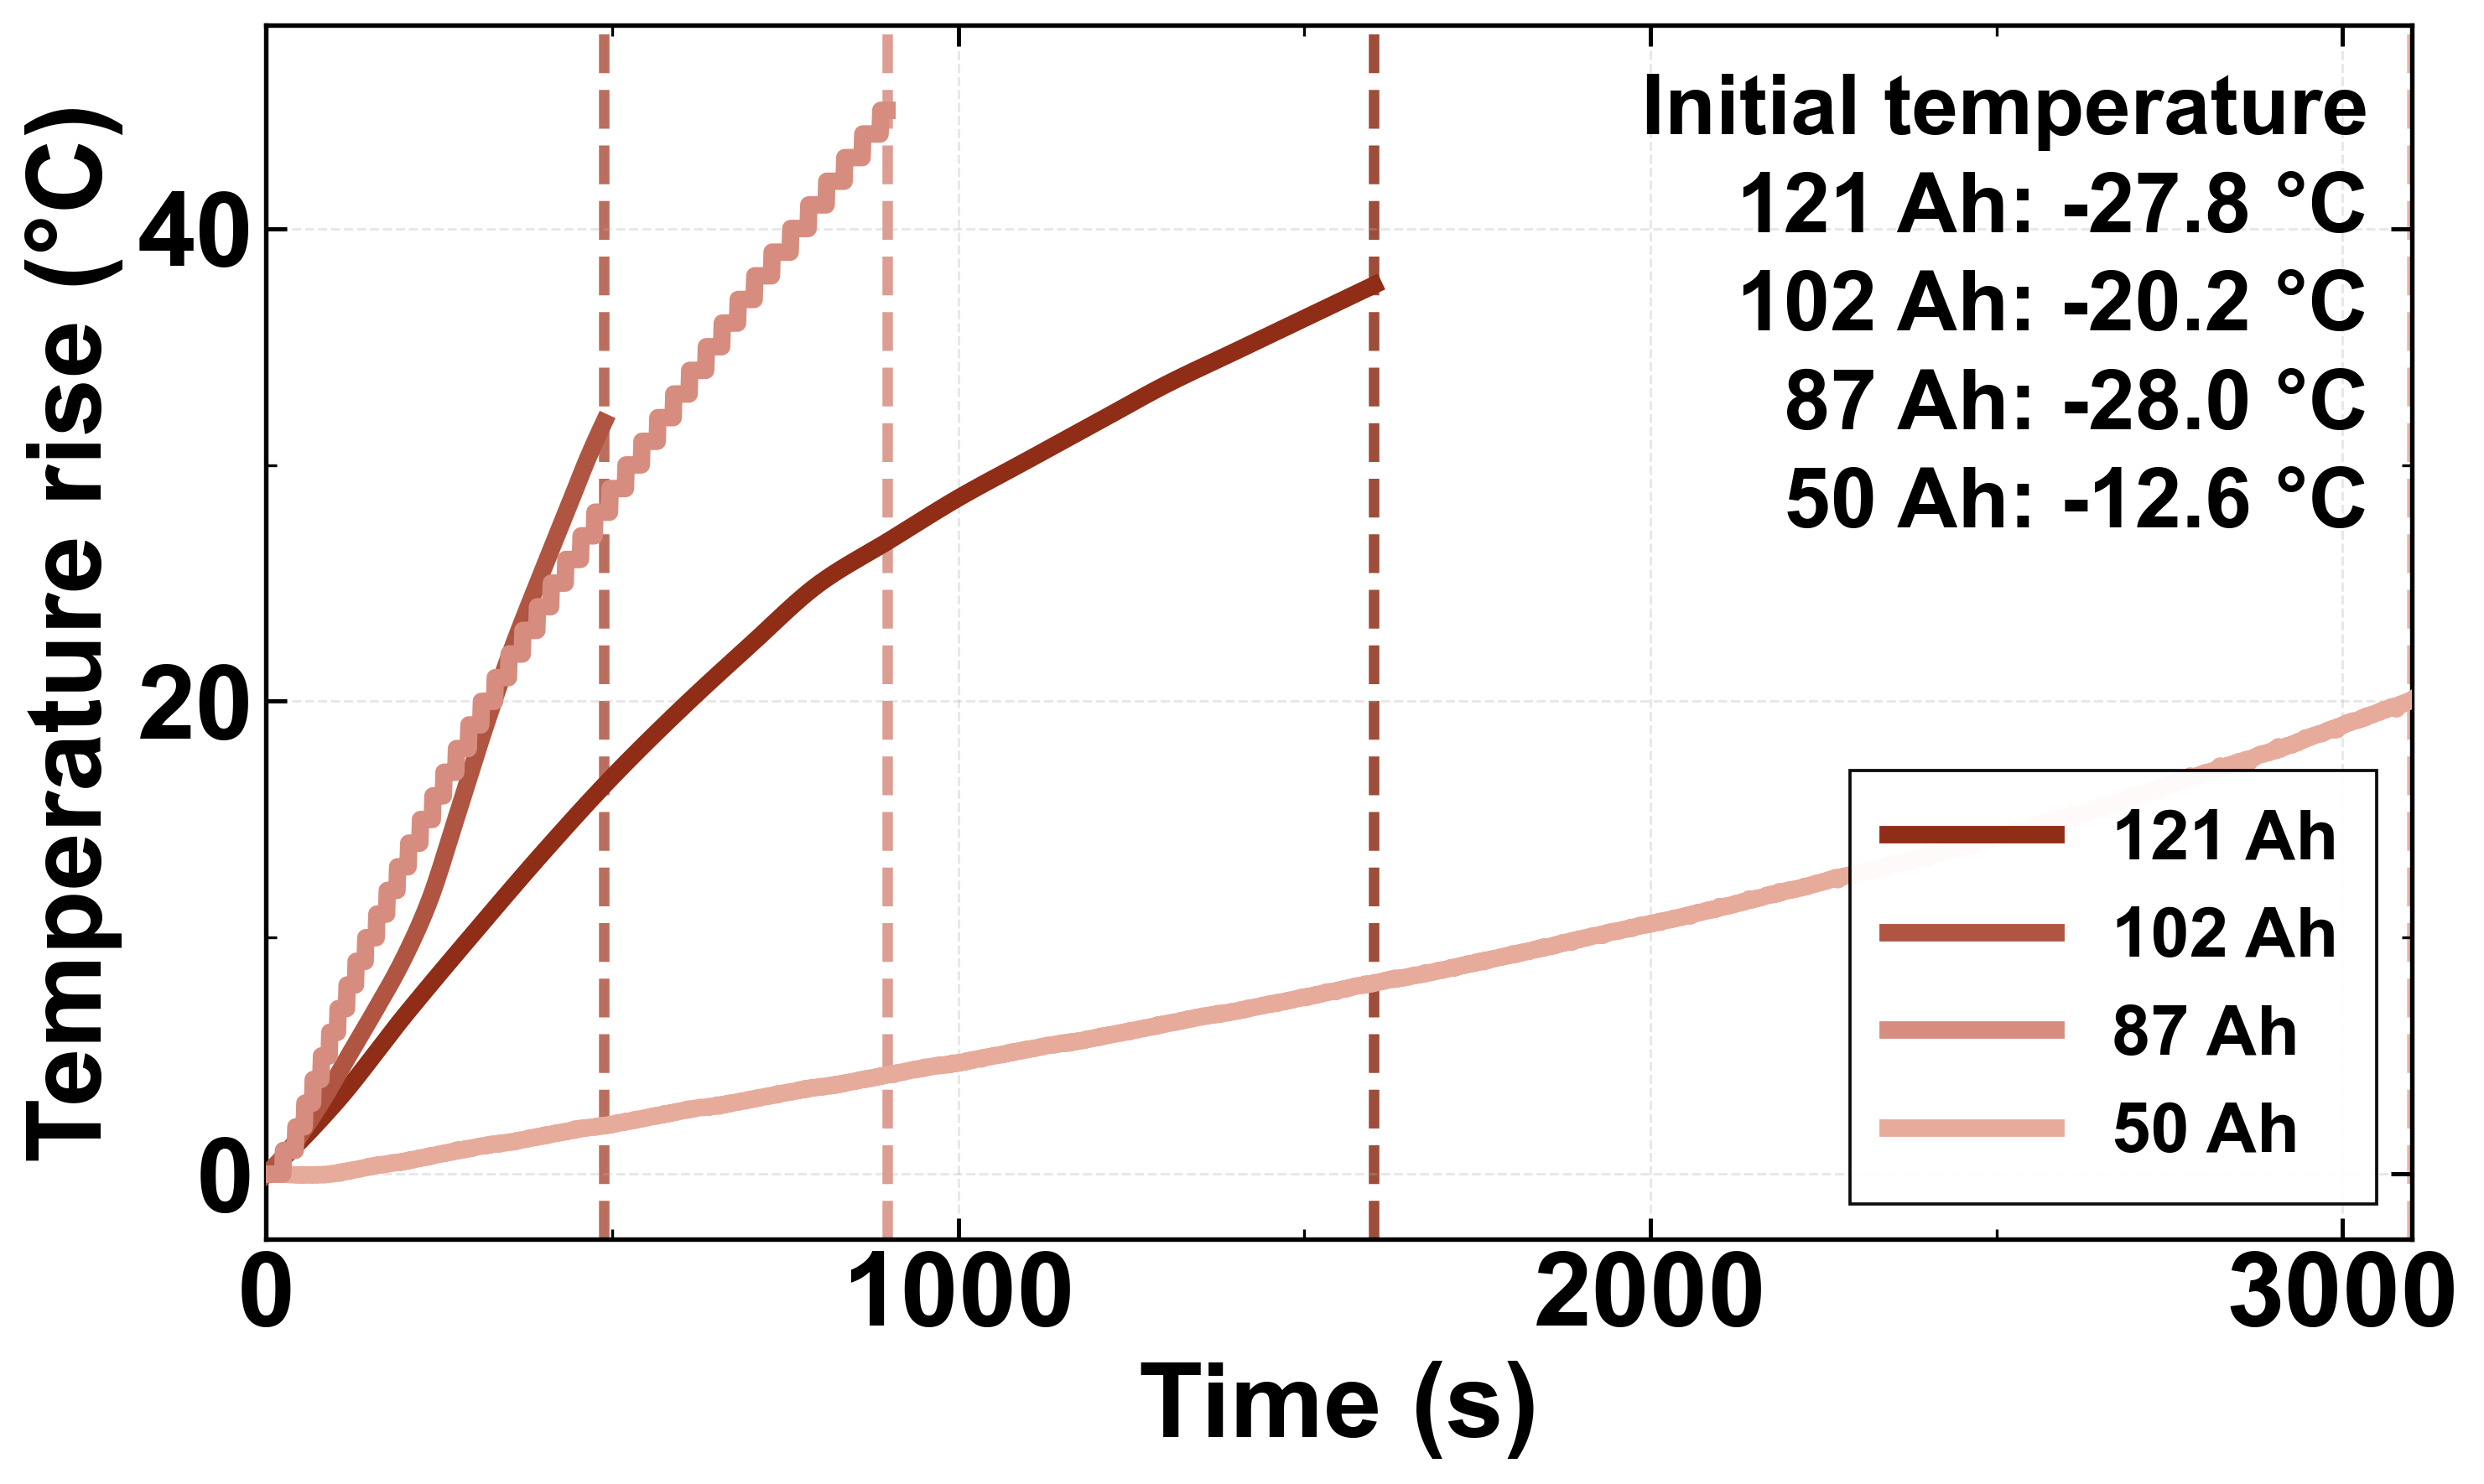


Experimental-temperature comparison completed
121 Ah: 17 digitized experimental anchors, time = 0-1600 s, temperature = -27.80-9.80 °C
102 Ah, SOH = 100%: 14 digitized experimental anchors, time = 0-488 s, temperature = -20.20-11.60 °C
50 Ah mean: 3101 plotted points, rows = 85000-88100, sensors = ['Sensor1', 'Sensor2', 'Sensor3', 'Sensor4', 'Sensor5', 'Sensor6', 'Sensor7']
90% Excel maximum temperature: 898 plotted points, time = 0-897 s, temperature = -28.00-17.00 °C, current amplitude != 0

PNG saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\experimental_temperature_121Ah_102Ah_50Ah_with_90pct_max_temp.png

PDF saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\experimental_temperature_121Ah_102Ah_50Ah_with_90pct_max_temp.pdf


In [286]:
# -*- coding: utf-8 -*-
"""
Combined experimental-temperature comparison.

Data sources
------------
1. 121 Ah:
   Experimental temperature curve from the first program.
2. 102 Ah:
   SOH = 100% experimental temperature curve from the second program.
3. 50 Ah:
   Mean temperature of Sensor1-Sensor7 read from the CSV used by
   the third program.
4. 90% variable-frequency heating:
   Maximum-temperature column read from the Excel worksheet "数据记录".
   Only rows whose current amplitude is nonzero are plotted.

The figure size is controlled by FIGSIZE.
"""

# =========================================================
# 0. ALL USER-ADJUSTABLE SETTINGS
# =========================================================

from pathlib import Path
import codecs
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
from matplotlib.ticker import AutoMinorLocator


# ---------------------------------------------------------
# 0.1 Input: 50 Ah CSV
# ---------------------------------------------------------

CSV_50AH = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大"
    r"\模组加热策略_温度数据_SOC07_20230212_1518.csv"
)

# The first row below the CSV header is treated as data row 1.
CSV_ROW_START = 85000
CSV_ROW_END = 88100

CSV_TEMPERATURE_COLUMNS = [
    "Sensor1",
    "Sensor2",
    "Sensor3",
    "Sensor4",
    "Sensor5",
    "Sensor6",
    "Sensor7",
]

# Sampling interval of the selected CSV data.
CSV_SAMPLE_INTERVAL_S = 1.0

# Mean-temperature processing:
# 1 means no smoothing; e.g. 11 means an 11-point centered rolling mean.
CSV_MEAN_SMOOTH_WINDOW = 1

# Drop rows where fewer than this number of sensors are valid.
CSV_MIN_VALID_SENSOR_COUNT = 1




# ---------------------------------------------------------
# 0.1.1 Input: maximum temperature from Excel
# ---------------------------------------------------------

EXCEL_MAX_TEMP = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大"
    r"\变频90%加热.xlsx"
)

EXCEL_SHEET_NAME = "数据记录"

# Column names shown in the worksheet. The program also supports minor
# variations such as ℃ / °C and Chinese / English brackets.
EXCEL_CURRENT_AMPLITUDE_COLUMN = "电流幅值[A]"
EXCEL_MAX_TEMPERATURE_COLUMN = "最高温度[℃]"

# One Excel data row corresponds to 1 s.
EXCEL_SAMPLE_INTERVAL_S = 1.0

# A small tolerance avoids treating floating-point numerical noise as current.
EXCEL_NONZERO_CURRENT_TOLERANCE = 1.0e-12

# 1 means no smoothing. For example, 5 means a 5-point centered rolling mean.
EXCEL_TEMPERATURE_SMOOTH_WINDOW = 1

# ---------------------------------------------------------
# 0.2 Output
# ---------------------------------------------------------

OUTPUT_DIR = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = "experimental_temperature_121Ah_102Ah_50Ah_with_90pct_max_temp"

SAVE_PNG = True
SAVE_PDF = True

DPI = 300
BBOX_INCHES = "tight"
PAD_INCHES = 0.10
TRANSPARENT_BACKGROUND = False


# ---------------------------------------------------------
# 0.3 Figure
# ---------------------------------------------------------

FIGSIZE = (10, 6)
FIG_FACE_COLOR = "white"
AX_FACE_COLOR = "white"

SHOW_TITLE = False
TITLE = "Experimental temperature comparison"


# ---------------------------------------------------------
# 0.4 Curves
# ---------------------------------------------------------

# PCHIP smoothing points for the digitized 121 Ah and 102 Ah curves.
N_SMOOTH_121AH = 1200
N_SMOOTH_102AH = 600

LINE_WIDTH_121AH = 5.0
LINE_WIDTH_102AH = 5.0
LINE_WIDTH_50AH = 5.0
LINE_WIDTH_EXCEL = 5.0

LINE_ALPHA_121AH = 1.0
LINE_ALPHA_102AH = 1.0
LINE_ALPHA_50AH = 1.0
LINE_ALPHA_EXCEL = 1.0

LINESTYLE_121AH = "-"
LINESTYLE_102AH = "-"
LINESTYLE_50AH = "-"
LINESTYLE_EXCEL = "-"

COLOR_121AH = "#8F2D17"
COLOR_102AH = "#B05541"

COLOR_EXCEL = "#D68D7F"
COLOR_50AH = "#E7AB9C"

LABEL_121AH = "121 Ah"
LABEL_102AH = "102 Ah"
LABEL_50AH = "50 Ah"

# Change this label to the exact battery/system name when needed.
LABEL_EXCEL = "87 Ah"

# ---------------------------------------------------------
# 0.4.1 End vertical lines
# ---------------------------------------------------------

SHOW_END_LINES = True
END_LINE_STYLE = "--"
END_LINE_WIDTH = 3
END_LINE_ALPHA = 0.85

# True: each line uses its own curve color
# False: all use the same color
USE_CURVE_COLOR_FOR_END_LINES = True
UNIFIED_END_LINE_COLOR = "gray"


# ---------------------------------------------------------
# 0.7.1 Initial-temperature textbox
# ---------------------------------------------------------

SHOW_INITIAL_TEMPERATURE_TEXT = True

INITIAL_TEXT_X = 0.98
INITIAL_TEXT_Y = 0.96

INITIAL_TEXT_FONTSIZE = 24
INITIAL_TEXT_LINE_SPACING = 1.35

INITIAL_TEXT_BOX = dict(
    facecolor="white",
    edgecolor="black",
    boxstyle="square,pad=0.35",
    alpha=0,
)

# ---------------------------------------------------------
# 0.5 Axes
# ---------------------------------------------------------

X_LABEL = "Time (s)"
Y_LABEL = "Temperature rise (°C)"

# None: determine automatically.
# Example: X_LIMIT = (0, 3200)
X_LIMIT = None

# None: determine automatically.
# Example: Y_LIMIT = (-30, 35)
Y_LIMIT = None

# Optional explicit ticks.
# Example: X_TICKS = np.arange(0, 3201, 400)
X_TICKS = None

# Example: Y_TICKS = np.arange(-30, 41, 10)
Y_TICKS = None


# ---------------------------------------------------------
# 0.6 Fonts
# ---------------------------------------------------------

FONT_FAMILY = [
    "Arial",
    "DejaVu Sans",
    "Liberation Sans",
]

AXIS_LABEL_SIZE = 30
TICK_LABEL_SIZE = 30
LEGEND_SIZE = 20
TITLE_SIZE = 28

FONT_WEIGHT = "bold"


# ---------------------------------------------------------
# 0.7 Legend
# ---------------------------------------------------------

SHOW_LEGEND = True

LEGEND_LOC = "lower right"
LEGEND_BBOX_TO_ANCHOR = None
LEGEND_NCOL = 1

LEGEND_FRAMEON = True
LEGEND_FANCYBOX = False
LEGEND_FRAME_ALPHA = 0.95
LEGEND_EDGE_COLOR = "black"
LEGEND_FACE_COLOR = "white"
LEGEND_FRAME_LINEWIDTH = 0.9

LEGEND_BORDERPAD = 0.55
LEGEND_HANDLELENGTH = 2.4
LEGEND_COLUMNSPACING = 1


# ---------------------------------------------------------
# 0.8 Grid, ticks, and spines
# ---------------------------------------------------------

SHOW_GRID = True
GRID_WHICH = "major"
GRID_LINESTYLE = "--"
GRID_LINEWIDTH = 0.7
GRID_ALPHA = 0.30

TICK_DIRECTION = "in"
MAJOR_TICK_LENGTH = 6
MAJOR_TICK_WIDTH = 1.2
MINOR_TICK_LENGTH = 3
MINOR_TICK_WIDTH = 0.8

SHOW_TOP_TICKS = True
SHOW_RIGHT_TICKS = True
SHOW_MINOR_TICKS = True

SPINE_WIDTH = 1.3


# ---------------------------------------------------------
# 0.9 Layout
# ---------------------------------------------------------

USE_TIGHT_LAYOUT = True

# Used only when USE_TIGHT_LAYOUT = False.
LEFT_MARGIN = 0.11
RIGHT_MARGIN = 0.97
BOTTOM_MARGIN = 0.12
TOP_MARGIN = 0.96


# =========================================================
# 1. EXPERIMENTAL DATA FROM THE FIRST PROGRAM: 121 Ah
# =========================================================

# Experimental temperature only.
TIME_121AH_S = np.array(
    [
        0, 100, 200, 300, 400, 500, 600, 700, 800,
        900, 1000, 1100, 1200, 1300, 1400, 1500, 1600,
    ],
    dtype=float,
)

TEMP_121AH_C = np.array(
    [
        -27.8, -24.8, -21.1, -17.6, -14.2, -11.0, -8.1, -5.4, -2.8,
        -1.0, 0.8, 2.4, 4.0, 5.6, 7.0, 8.4, 9.8,
    ],
    dtype=float,
)


# =========================================================
# 2. EXPERIMENTAL DATA FROM THE SECOND PROGRAM: 102 Ah
#    SOH = 100%
# =========================================================

TIME_102AH_SOH100_S = np.array(
    [
        0, 35, 75, 115, 155, 195,
        235, 275, 315, 355, 395,
        435, 465, 488,
    ],
    dtype=float,
)

TEMP_102AH_SOH100_C = np.array(
    [
        -20.2, -19.1, -17.4, -15.4, -13.4, -11.3,
        -8.7, -5.1, -1.4, 2.0, 5.0,
        7.9, 10.1, 11.6,
    ],
    dtype=float,
)


# =========================================================
# 3. HELPER FUNCTIONS
# =========================================================

def clean_column_name(column_name):
    """Clean BOM, NUL bytes, full-width spaces, and surrounding spaces."""
    return (
        str(column_name)
        .replace("\ufeff", "")
        .replace("\x00", "")
        .replace("\u3000", " ")
        .strip()
    )


def detect_encoding_from_bytes(file_path):
    """Detect likely text encoding using BOM and NUL-byte distribution."""
    with open(file_path, "rb") as file:
        sample = file.read(16384)

    if not sample:
        raise ValueError("The input CSV file is empty.")

    if sample.startswith(codecs.BOM_UTF8):
        return "utf-8-sig"

    if sample.startswith(codecs.BOM_UTF16_LE):
        return "utf-16"

    if sample.startswith(codecs.BOM_UTF16_BE):
        return "utf-16"

    nul_ratio = sample.count(b"\x00") / len(sample)

    if nul_ratio > 0.05:
        even_nul_count = sample[0::2].count(b"\x00")
        odd_nul_count = sample[1::2].count(b"\x00")

        if odd_nul_count > even_nul_count:
            return "utf-16-le"

        return "utf-16-be"

    return None


def read_csv_robustly(file_path, maximum_rows, required_columns):
    """
    Try multiple encoding and separator combinations until all required
    temperature columns are found.
    """
    detected_encoding = detect_encoding_from_bytes(file_path)

    encoding_candidates = []

    if detected_encoding is not None:
        encoding_candidates.append(detected_encoding)

    encoding_candidates.extend(
        [
            "utf-16",
            "utf-16-le",
            "utf-16-be",
            "utf-8-sig",
            "gb18030",
            "gbk",
            "utf-8",
        ]
    )

    encoding_candidates = list(dict.fromkeys(encoding_candidates))

    separator_candidates = [
        "\t",
        ",",
        ";",
        "|",
    ]

    error_records = []

    for encoding in encoding_candidates:
        for separator in separator_candidates:
            try:
                dataframe = pd.read_csv(
                    file_path,
                    encoding=encoding,
                    sep=separator,
                    engine="python",
                    nrows=maximum_rows,
                    skip_blank_lines=True,
                )

                dataframe.columns = [
                    clean_column_name(column)
                    for column in dataframe.columns
                ]

                if len(dataframe.columns) <= 1:
                    error_records.append(
                        f"encoding={encoding}, separator={repr(separator)}: "
                        "only one column detected"
                    )
                    continue

                column_mapping = {
                    clean_column_name(column).upper(): column
                    for column in dataframe.columns
                }

                missing_columns = [
                    required_column
                    for required_column in required_columns
                    if required_column.upper() not in column_mapping
                ]

                if missing_columns:
                    error_records.append(
                        f"encoding={encoding}, separator={repr(separator)}: "
                        f"missing columns {missing_columns}"
                    )
                    continue

                rename_mapping = {
                    column_mapping[required_column.upper()]: required_column
                    for required_column in required_columns
                }

                dataframe = dataframe.rename(columns=rename_mapping)

                print("=" * 72)
                print("50 Ah CSV read successfully")
                print(f"Encoding:  {encoding}")
                print(f"Separator: {repr(separator)}")
                print(f"Rows read: {len(dataframe)}")
                print("=" * 72)

                return dataframe

            except (
                UnicodeDecodeError,
                UnicodeError,
                pd.errors.ParserError,
                csv.Error,
                ValueError,
            ) as error:
                error_records.append(
                    f"encoding={encoding}, separator={repr(separator)}: "
                    f"{type(error).__name__}: {error}"
                )

    recent_errors = "\n".join(error_records[-15:])

    raise RuntimeError(
        "The 50 Ah CSV file could not be read correctly.\n\n"
        f"Recent attempts:\n{recent_errors}"
    )


def extract_50ah_mean_temperature():
    """Read Sensor1-Sensor7 and return their row-wise mean temperature."""
    if not CSV_50AH.exists():
        raise FileNotFoundError(
            f"50 Ah CSV file not found:\n{CSV_50AH}"
        )

    if CSV_ROW_START < 1:
        raise ValueError("CSV_ROW_START must be at least 1.")

    if CSV_ROW_END < CSV_ROW_START:
        raise ValueError("CSV_ROW_END must be no smaller than CSV_ROW_START.")

    dataframe = read_csv_robustly(
        file_path=CSV_50AH,
        maximum_rows=CSV_ROW_END,
        required_columns=CSV_TEMPERATURE_COLUMNS,
    )

    if len(dataframe) < CSV_ROW_END:
        raise ValueError(
            f"The 50 Ah CSV contains only {len(dataframe)} data rows, "
            f"but row {CSV_ROW_END} was requested."
        )

    temperature_dataframe = dataframe.iloc[
        CSV_ROW_START - 1:CSV_ROW_END
    ][CSV_TEMPERATURE_COLUMNS].copy()

    temperature_dataframe = (
        temperature_dataframe
        .reset_index(drop=True)
        .apply(pd.to_numeric, errors="coerce")
    )

    valid_sensor_counts = temperature_dataframe.notna().sum(axis=1)

    mean_temperature = temperature_dataframe.mean(
        axis=1,
        skipna=True,
    )

    valid_rows = (
        valid_sensor_counts >= CSV_MIN_VALID_SENSOR_COUNT
    ) & mean_temperature.notna()

    mean_temperature = (
        mean_temperature.loc[valid_rows]
        .reset_index(drop=True)
    )

    if mean_temperature.empty:
        raise ValueError(
            "No valid 50 Ah mean-temperature data were obtained."
        )

    smooth_window = max(1, int(CSV_MEAN_SMOOTH_WINDOW))

    if smooth_window > 1:
        mean_temperature = mean_temperature.rolling(
            window=smooth_window,
            center=True,
            min_periods=1,
        ).mean()

    time_values = (
        np.arange(
            len(mean_temperature),
            dtype=float,
        )
        * CSV_SAMPLE_INTERVAL_S
    )

    return (
        time_values,
        mean_temperature.to_numpy(dtype=float),
        temperature_dataframe,
    )



def normalize_header_for_match(column_name):
    """Normalize an Excel header for tolerant matching."""
    normalized = clean_column_name(column_name)
    replacements = {
        " ": "",
        "（": "(",
        "）": ")",
        "【": "[",
        "】": "]",
        "℃": "°C",
        "°c": "°C",
    }

    for old_text, new_text in replacements.items():
        normalized = normalized.replace(old_text, new_text)

    return normalized.lower()


def find_excel_column(dataframe, requested_name, semantic_keywords):
    """
    Find an Excel column by normalized exact match first, then by keywords.

    This makes the program robust to minor header differences such as
    "最高温度[℃]" versus "最高温度[°C]".
    """
    normalized_to_original = {
        normalize_header_for_match(column): column
        for column in dataframe.columns
    }

    requested_normalized = normalize_header_for_match(requested_name)

    if requested_normalized in normalized_to_original:
        return normalized_to_original[requested_normalized]

    normalized_keywords = [
        normalize_header_for_match(keyword)
        for keyword in semantic_keywords
    ]

    for normalized_column, original_column in normalized_to_original.items():
        if all(keyword in normalized_column for keyword in normalized_keywords):
            return original_column

    available_columns = "\n".join(
        f"  - {column}"
        for column in dataframe.columns
    )

    raise KeyError(
        f"Could not find Excel column: {requested_name}\n"
        f"Available columns are:\n{available_columns}"
    )


def extract_excel_max_temperature():
    """
    Read the Excel maximum-temperature column and retain only rows where
    current amplitude is nonzero.

    Time is calculated from the original worksheet row positions, so removing
    zero-current rows does not artificially shorten any gaps in the data.
    The first retained point is shifted to t = 0 s.
    """
    if not EXCEL_MAX_TEMP.exists():
        raise FileNotFoundError(
            f"Excel file not found:\n{EXCEL_MAX_TEMP}"
        )

    try:
        dataframe = pd.read_excel(
            EXCEL_MAX_TEMP,
            sheet_name=EXCEL_SHEET_NAME,
        )
    except ImportError as error:
        raise ImportError(
            "Reading .xlsx files requires openpyxl. "
            "Install it with: pip install openpyxl"
        ) from error

    dataframe.columns = [
        clean_column_name(column)
        for column in dataframe.columns
    ]

    current_column = find_excel_column(
        dataframe,
        requested_name=EXCEL_CURRENT_AMPLITUDE_COLUMN,
        semantic_keywords=["电流", "幅值"],
    )

    max_temperature_column = find_excel_column(
        dataframe,
        requested_name=EXCEL_MAX_TEMPERATURE_COLUMN,
        semantic_keywords=["最高", "温度"],
    )

    current_amplitude = pd.to_numeric(
        dataframe[current_column],
        errors="coerce",
    )

    maximum_temperature = pd.to_numeric(
        dataframe[max_temperature_column],
        errors="coerce",
    )

    valid_mask = (
        current_amplitude.notna()
        & maximum_temperature.notna()
        & (
            current_amplitude.abs()
            > EXCEL_NONZERO_CURRENT_TOLERANCE
        )
    )

    retained_positions = np.flatnonzero(valid_mask.to_numpy())

    if retained_positions.size == 0:
        raise ValueError(
            "No valid rows were found where current amplitude is nonzero."
        )

    retained_temperature = (
        maximum_temperature.loc[valid_mask]
        .reset_index(drop=True)
    )

    smooth_window = max(
        1,
        int(EXCEL_TEMPERATURE_SMOOTH_WINDOW),
    )

    if smooth_window > 1:
        retained_temperature = retained_temperature.rolling(
            window=smooth_window,
            center=True,
            min_periods=1,
        ).mean()

    time_values = (
        retained_positions - retained_positions[0]
    ).astype(float) * EXCEL_SAMPLE_INTERVAL_S

    print("=" * 72)
    print("Excel maximum-temperature data read successfully")
    print(f"File: {EXCEL_MAX_TEMP}")
    print(f"Sheet: {EXCEL_SHEET_NAME}")
    print(f"Current column: {current_column}")
    print(f"Temperature column: {max_temperature_column}")
    print(f"Nonzero-current rows retained: {len(retained_temperature)}")
    print("=" * 72)

    return (
        time_values,
        retained_temperature.to_numpy(dtype=float),
        current_amplitude.loc[valid_mask].to_numpy(dtype=float),
    )

def pchip_smooth(x_values, y_values, number_of_points):
    """Generate a smooth shape-preserving PCHIP curve."""
    x_values = np.asarray(x_values, dtype=float)
    y_values = np.asarray(y_values, dtype=float)

    if len(x_values) != len(y_values):
        raise ValueError("Time and temperature arrays must have equal lengths.")

    if len(x_values) < 2:
        raise ValueError("At least two data points are required.")

    if np.any(np.diff(x_values) <= 0):
        raise ValueError("Time data must be strictly increasing.")

    interpolator = PchipInterpolator(
        x_values,
        y_values,
    )

    x_dense = np.linspace(
        x_values[0],
        x_values[-1],
        int(number_of_points),
    )

    y_dense = interpolator(x_dense)

    return x_dense, y_dense


def set_tick_labels_bold(axis):
    """Set all visible tick labels to bold."""
    for label in axis.get_xticklabels() + axis.get_yticklabels():
        label.set_fontweight(FONT_WEIGHT)


# =========================================================
# 4. PREPARE EXPERIMENTAL CURVES
# =========================================================

time_121_dense, temp_121_dense = pchip_smooth(
    TIME_121AH_S,
    TEMP_121AH_C,
    N_SMOOTH_121AH,
)

time_102_dense, temp_102_dense = pchip_smooth(
    TIME_102AH_SOH100_S,
    TEMP_102AH_SOH100_C,
    N_SMOOTH_102AH,
)

time_50_mean, temp_50_mean, temp_50_sensor_dataframe = (
    extract_50ah_mean_temperature()
)

time_excel_max, temp_excel_max, current_excel_nonzero = (
    extract_excel_max_temperature()
)

# Initial temperatures
initial_temp_121 = TEMP_121AH_C[0]
initial_temp_102 = TEMP_102AH_SOH100_C[0]
initial_temp_50 = temp_50_mean[0]
initial_temp_excel = temp_excel_max[0]

# Convert absolute temperature to temperature rise
rise_121_dense = temp_121_dense - initial_temp_121
rise_102_dense = temp_102_dense - initial_temp_102
rise_50_mean = temp_50_mean - initial_temp_50
rise_excel_max = temp_excel_max - initial_temp_excel


# =========================================================
# 5. PLOT
# =========================================================

plt.rcParams["font.sans-serif"] = FONT_FAMILY
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI,
    facecolor=FIG_FACE_COLOR,
)

ax.set_facecolor(AX_FACE_COLOR)


# 121 Ah experimental temperature
line_121, = ax.plot(
    time_121_dense,
    rise_121_dense,
    color=COLOR_121AH,
    linestyle=LINESTYLE_121AH,
    linewidth=LINE_WIDTH_121AH,
    alpha=LINE_ALPHA_121AH,
    label=LABEL_121AH,
    zorder=4,
)

line_102, = ax.plot(
    time_102_dense,
    rise_102_dense,
    color=COLOR_102AH,
    linestyle=LINESTYLE_102AH,
    linewidth=LINE_WIDTH_102AH,
    alpha=LINE_ALPHA_102AH,
    label=LABEL_102AH,
    zorder=4,
)



line_excel, = ax.plot(
    time_excel_max,
    rise_excel_max,
    color=COLOR_EXCEL,
    linestyle=LINESTYLE_EXCEL,
    linewidth=LINE_WIDTH_EXCEL,
    alpha=LINE_ALPHA_EXCEL,
    label=LABEL_EXCEL,
    zorder=5,
)

line_50, = ax.plot(
    time_50_mean,
    rise_50_mean,
    color=COLOR_50AH,
    linestyle=LINESTYLE_50AH,
    linewidth=LINE_WIDTH_50AH,
    alpha=LINE_ALPHA_50AH,
    label=LABEL_50AH,
    zorder=3,
)

if SHOW_END_LINES:
    end_line_specs = [
        (time_121_dense[-1], COLOR_121AH),
        (time_102_dense[-1], COLOR_102AH),
        (time_excel_max[-1], COLOR_EXCEL),
        (time_50_mean[-1], COLOR_50AH),
    ]

    for x_end, curve_color in end_line_specs:
        line_color = curve_color if USE_CURVE_COLOR_FOR_END_LINES else UNIFIED_END_LINE_COLOR

        ax.axvline(
            x=x_end,
            color=line_color,
            linestyle=END_LINE_STYLE,
            linewidth=END_LINE_WIDTH,
            alpha=END_LINE_ALPHA,
            zorder=1,
        )

# =========================================================
# 6. AXES
# =========================================================

ax.set_xlabel(
    X_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight=FONT_WEIGHT,
)

ax.set_ylabel(
    Y_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight=FONT_WEIGHT,
)

if SHOW_TITLE:
    ax.set_title(
        TITLE,
        fontsize=TITLE_SIZE,
        fontweight=FONT_WEIGHT,
        pad=12,
    )

if X_LIMIT is None:
    maximum_time = max(
        time_121_dense[-1],
        time_102_dense[-1],
        time_50_mean[-1],
        time_excel_max[-1],
    )
    ax.set_xlim(0, maximum_time)
else:
    ax.set_xlim(*X_LIMIT)

if Y_LIMIT is None:
    all_temperature_values = np.concatenate(
        [
            np.asarray(rise_121_dense, dtype=float),
            np.asarray(rise_102_dense, dtype=float),
            np.asarray(rise_50_mean, dtype=float),
            np.asarray(rise_excel_max, dtype=float),
        ]
    )

    finite_temperatures = all_temperature_values[
        np.isfinite(all_temperature_values)
    ]

    y_minimum = float(np.min(finite_temperatures))
    y_maximum = float(np.max(finite_temperatures))
    y_span = y_maximum - y_minimum

    if y_span <= 0:
        y_span = 1.0

    ax.set_ylim(
        y_minimum - 0.06 * y_span,
        y_maximum + 0.08 * y_span,
    )
else:
    ax.set_ylim(*Y_LIMIT)

if X_TICKS is not None:
    ax.set_xticks(X_TICKS)

if Y_TICKS is not None:
    ax.set_yticks(Y_TICKS)


# =========================================================
# 7. TICKS, SPINES, AND GRID
# =========================================================

ax.tick_params(
    axis="both",
    which="major",
    labelsize=TICK_LABEL_SIZE,
    direction=TICK_DIRECTION,
    top=SHOW_TOP_TICKS,
    right=SHOW_RIGHT_TICKS,
    length=MAJOR_TICK_LENGTH,
    width=MAJOR_TICK_WIDTH,
)

if SHOW_MINOR_TICKS:
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))

    ax.tick_params(
        axis="both",
        which="minor",
        direction=TICK_DIRECTION,
        top=SHOW_TOP_TICKS,
        right=SHOW_RIGHT_TICKS,
        length=MINOR_TICK_LENGTH,
        width=MINOR_TICK_WIDTH,
    )

set_tick_labels_bold(ax)

for spine in ax.spines.values():
    spine.set_linewidth(SPINE_WIDTH)

if SHOW_GRID:
    ax.grid(
        True,
        which=GRID_WHICH,
        linestyle=GRID_LINESTYLE,
        linewidth=GRID_LINEWIDTH,
        alpha=GRID_ALPHA,
        zorder=0,
    )


# =========================================================
# 8. LEGEND
# =========================================================

if SHOW_LEGEND:
    legend_kwargs = {
        "handles": [line_121, line_102, line_excel, line_50],
        "loc": LEGEND_LOC,
        "ncol": LEGEND_NCOL,
        "prop": {
            "size": LEGEND_SIZE,
            "weight": FONT_WEIGHT,
        },
        "frameon": LEGEND_FRAMEON,
        "fancybox": LEGEND_FANCYBOX,
        "framealpha": LEGEND_FRAME_ALPHA,
        "borderpad": LEGEND_BORDERPAD,
        "handlelength": LEGEND_HANDLELENGTH,
        "columnspacing": LEGEND_COLUMNSPACING,
    }

    if LEGEND_BBOX_TO_ANCHOR is not None:
        legend_kwargs["bbox_to_anchor"] = LEGEND_BBOX_TO_ANCHOR

    legend = ax.legend(**legend_kwargs)

    legend_frame = legend.get_frame()
    legend_frame.set_edgecolor(LEGEND_EDGE_COLOR)
    legend_frame.set_facecolor(LEGEND_FACE_COLOR)
    legend_frame.set_linewidth(LEGEND_FRAME_LINEWIDTH)

if SHOW_INITIAL_TEMPERATURE_TEXT:
    initial_text = (
        f"Initial temperature\n"
        f"121 Ah: {initial_temp_121:.1f} °C\n"
        f"102 Ah: {initial_temp_102:.1f} °C\n"
        f"87 Ah: {initial_temp_excel:.1f} °C\n"
        f"50 Ah: {initial_temp_50:.1f} °C"
    )

    ax.text(
        INITIAL_TEXT_X,
        INITIAL_TEXT_Y,
        initial_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=INITIAL_TEXT_FONTSIZE,
        fontweight=FONT_WEIGHT,
        linespacing=INITIAL_TEXT_LINE_SPACING,
        bbox=INITIAL_TEXT_BOX,
        zorder=10,
    )

# =========================================================
# 9. LAYOUT, SAVE, AND SHOW
# =========================================================

if USE_TIGHT_LAYOUT:
    fig.tight_layout()
else:
    fig.subplots_adjust(
        left=LEFT_MARGIN,
        right=RIGHT_MARGIN,
        bottom=BOTTOM_MARGIN,
        top=TOP_MARGIN,
    )

png_path = OUTPUT_DIR / f"{OUTPUT_NAME}.png"
pdf_path = OUTPUT_DIR / f"{OUTPUT_NAME}.pdf"

if SAVE_PNG:
    fig.savefig(
        png_path,
        dpi=DPI,
        bbox_inches=BBOX_INCHES,
        pad_inches=PAD_INCHES,
        facecolor=FIG_FACE_COLOR,
        transparent=TRANSPARENT_BACKGROUND,
    )

if SAVE_PDF:
    fig.savefig(
        pdf_path,
        bbox_inches=BBOX_INCHES,
        pad_inches=PAD_INCHES,
        facecolor=FIG_FACE_COLOR,
        transparent=TRANSPARENT_BACKGROUND,
    )

plt.show()
plt.close(fig)


# =========================================================
# 10. PRINT SUMMARY
# =========================================================

print("\n" + "=" * 76)
print("Experimental-temperature comparison completed")
print("=" * 76)

print(
    f"121 Ah: {len(TIME_121AH_S)} digitized experimental anchors, "
    f"time = {TIME_121AH_S[0]:.0f}-{TIME_121AH_S[-1]:.0f} s, "
    f"temperature = {TEMP_121AH_C[0]:.2f}-{TEMP_121AH_C[-1]:.2f} °C"
)

print(
    f"102 Ah, SOH = 100%: "
    f"{len(TIME_102AH_SOH100_S)} digitized experimental anchors, "
    f"time = {TIME_102AH_SOH100_S[0]:.0f}-"
    f"{TIME_102AH_SOH100_S[-1]:.0f} s, "
    f"temperature = {TEMP_102AH_SOH100_C[0]:.2f}-"
    f"{TEMP_102AH_SOH100_C[-1]:.2f} °C"
)

print(
    f"50 Ah mean: {len(time_50_mean)} plotted points, "
    f"rows = {CSV_ROW_START}-{CSV_ROW_END}, "
    f"sensors = {CSV_TEMPERATURE_COLUMNS}"
)

print(
    f"90% Excel maximum temperature: {len(time_excel_max)} plotted points, "
    f"time = {time_excel_max[0]:.0f}-{time_excel_max[-1]:.0f} s, "
    f"temperature = {temp_excel_max[0]:.2f}-{temp_excel_max[-1]:.2f} °C, "
    f"current amplitude != 0"
)

if SAVE_PNG:
    print(f"\nPNG saved to:\n{png_path}")

if SAVE_PDF:
    print(f"\nPDF saved to:\n{pdf_path}")

print("=" * 76)



121 Ah heating-rate results
SOH = 100%: rate = 3.9098 °C/min, ΔT = 31.80 °C, time = 488 s
SOH =  95%: rate = 2.4985 °C/min, ΔT = 27.90 °C, time = 670 s
SOH =  90%: rate = 2.7117 °C/min, ΔT = 30.10 °C, time = 666 s
SOH =  85%: rate = 2.4200 °C/min, ΔT = 29.00 °C, time = 719 s
SOH =  80%: rate = 2.7737 °C/min, ΔT = 28.80 °C, time = 623 s


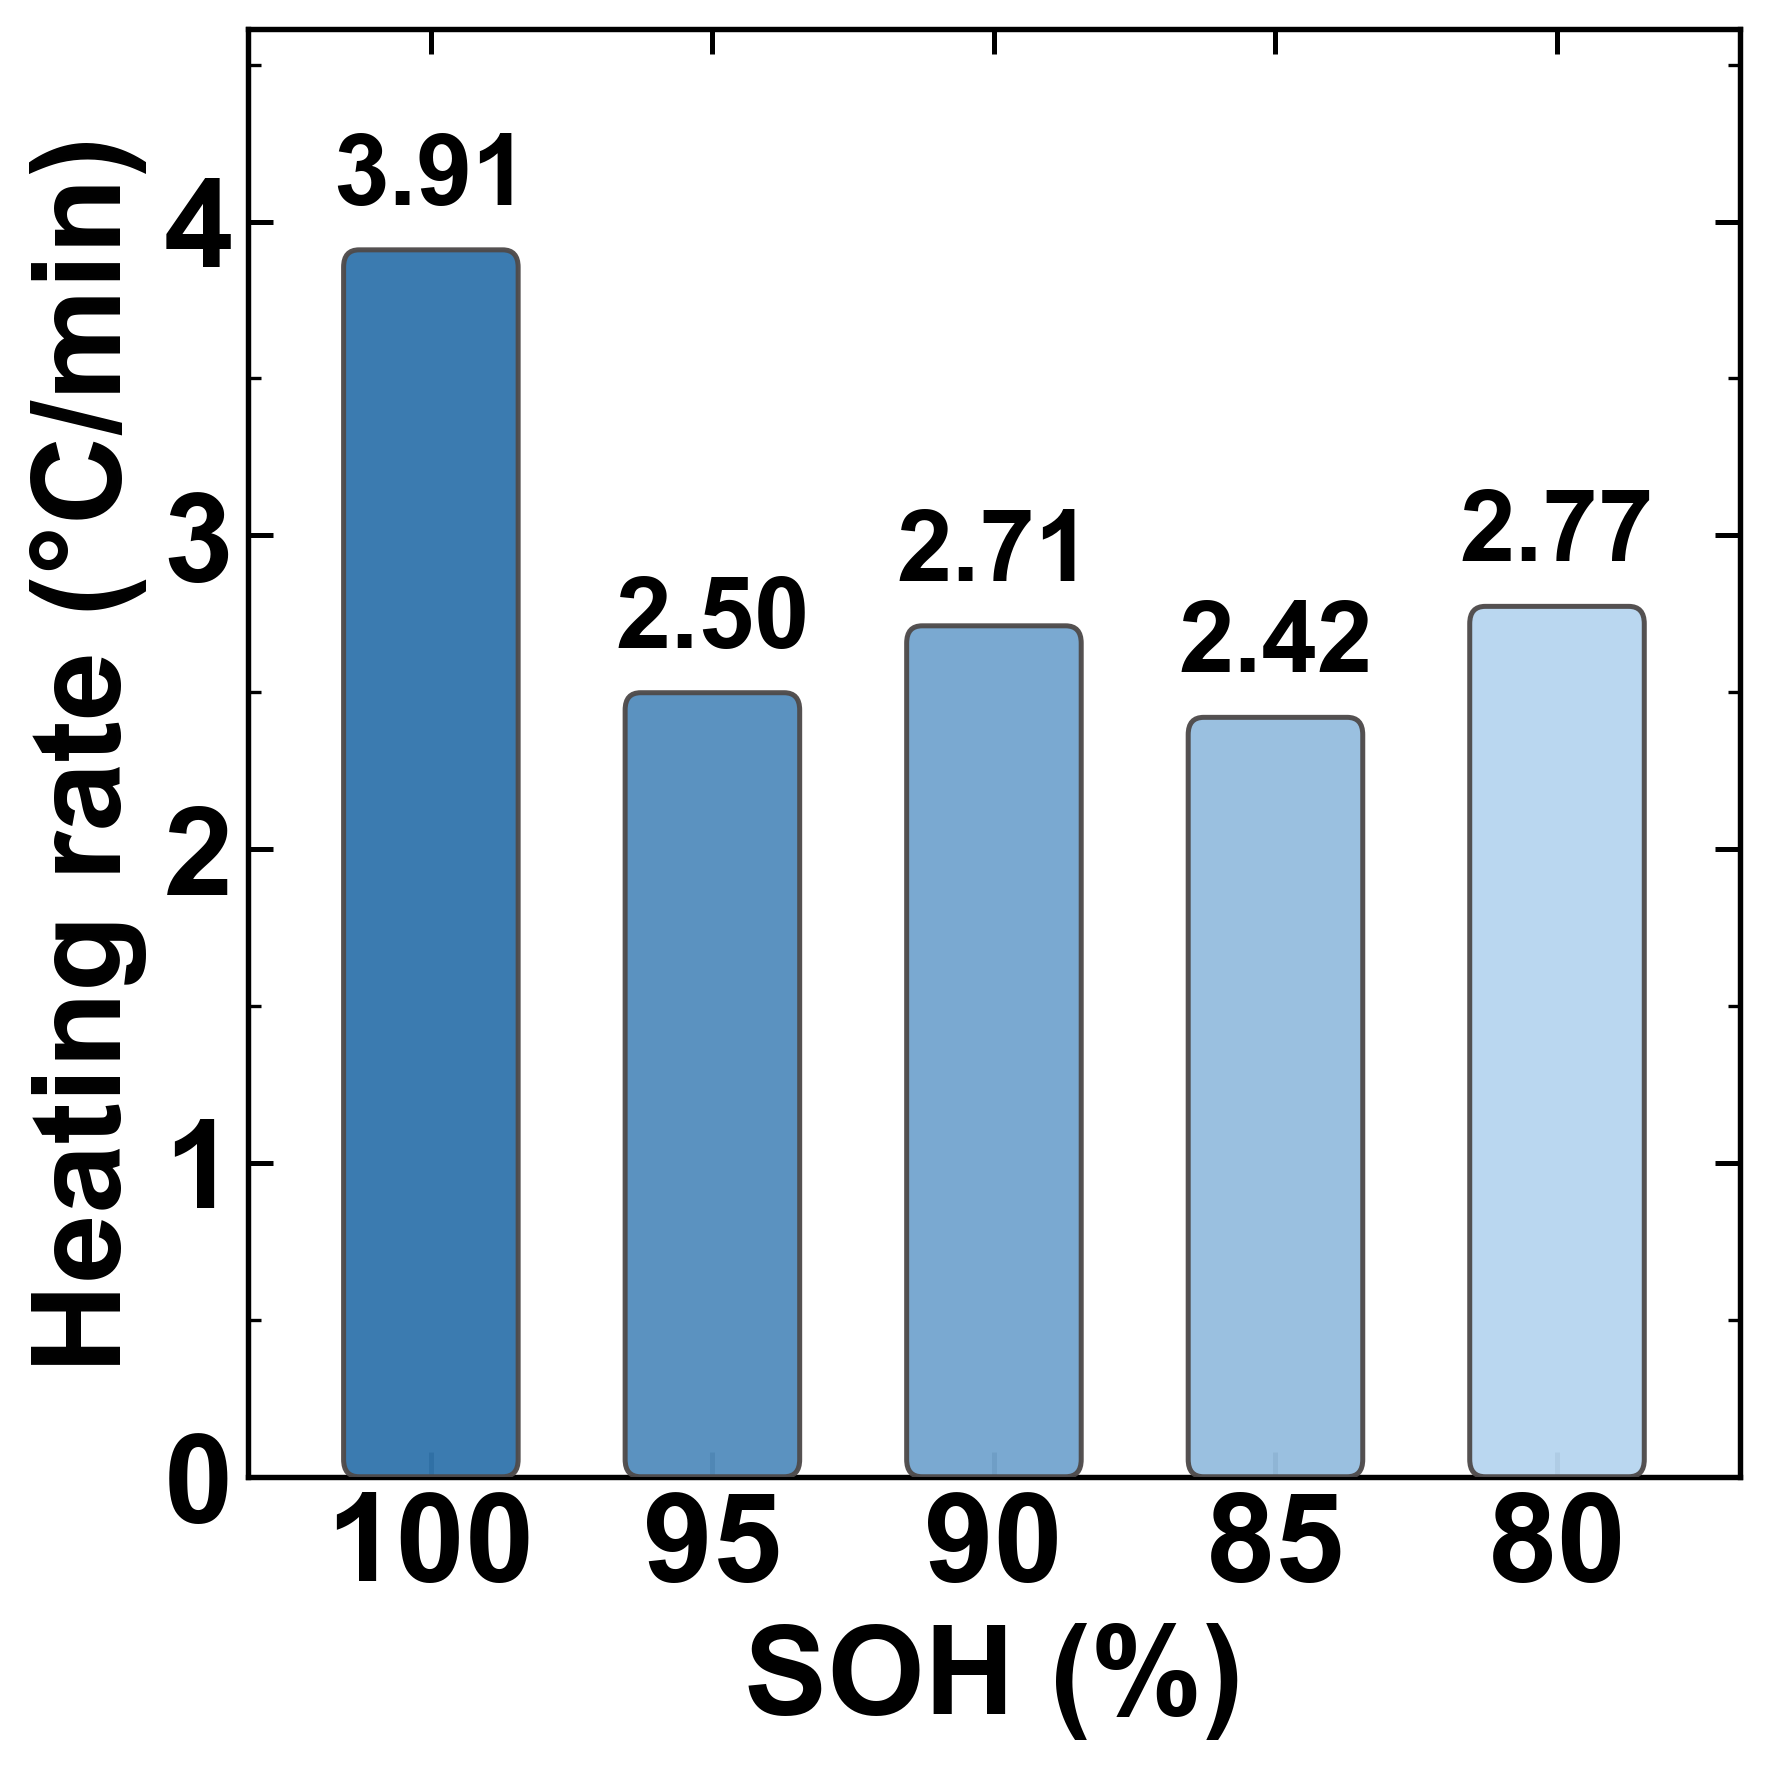


Plotting completed.
PNG saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\121Ah_heating_rate_different_SOH.png
PDF saved to:
C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\121Ah_heating_rate_different_SOH.pdf


In [210]:
# -*- coding: utf-8 -*-
"""
Heating-rate bar chart for the 121 Ah battery at different SOHs.

Data source:
    Experimental temperature curves in the existing 121 Ah program.

SOH cases:
    100%, 95%, 90%, 85%, 80%

Default heating-rate definition:
    Average heating rate =
    (final temperature - initial temperature)
    / (final time - initial time)

Output unit:
    °C/min

Figure size:
    6 × 12 inches
"""

# =========================================================
# 0. ALL USER-ADJUSTABLE SETTINGS
# =========================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import AutoMinorLocator


# ---------------------------------------------------------
# 0.1 Output
# ---------------------------------------------------------

OUTPUT_DIR = Path(
    r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_NAME = "121Ah_heating_rate_different_SOH"

SAVE_PNG = True
SAVE_PDF = True

DPI = 300
BBOX_INCHES = "tight"
PAD_INCHES = 0.10
TRANSPARENT_BACKGROUND = False


# ---------------------------------------------------------
# 0.2 Figure
# ---------------------------------------------------------

# Width × height = 6 × 12
FIGSIZE = (6, 6)

FIG_FACE_COLOR = "white"
AX_FACE_COLOR = "white"

SHOW_TITLE = False
TITLE_TEXT = "Heating rate at different SOHs"


# ---------------------------------------------------------
# 0.3 Heating-rate calculation
# ---------------------------------------------------------

# "endpoint":
#     (T_end - T_start) / (t_end - t_start)
#
# "linear_fit":
#     Fit all experimental temperature anchors with a straight line
#     and use the slope as the average heating rate.
RATE_METHOD = "endpoint"

# "C_per_min" or "C_per_s"
RATE_OUTPUT_UNIT = "C_per_min"

# Endpoint method:
# Number of points averaged at the beginning and end.
# 1 means use the first and last points directly.
ENDPOINT_AVERAGE_POINTS = 1

USE_ABSOLUTE_RATE = False


# ---------------------------------------------------------
# 0.4 SOH order
# ---------------------------------------------------------

SOH_ORDER = [
    100,
    95,
    90,
    85,
    80,
]


# ---------------------------------------------------------
# 0.5 Colors
# ---------------------------------------------------------

# SOH = 100% uses the dark color.
# SOH = 80% uses the light color.
COLOR_START = "#3376AD"
COLOR_END = "#B7D6F0"

REVERSE_GRADIENT = False

BAR_ALPHA = 0.96
BAR_EDGE_COLOR = "#4E4A4A"
BAR_EDGE_WIDTH = 1.2


# ---------------------------------------------------------
# 0.6 Bar appearance
# ---------------------------------------------------------

BAR_WIDTH = 0.62

USE_ROUNDED_BARS = True

# Corner rounding in x-axis data units.
BAR_ROUNDING_SIZE = 0.055


# ---------------------------------------------------------
# 0.7 Axis labels and ranges
# ---------------------------------------------------------

X_LABEL = "SOH (%)"

if RATE_OUTPUT_UNIT == "C_per_min":
    Y_LABEL = "Heating rate (°C/min)"
else:
    Y_LABEL = "Heating rate (°C/s)"

# None means automatic.
X_LIMIT = None

# Example:
# Y_LIMIT = (0, 4.5)
Y_LIMIT = None

# Example:
# Y_TICKS = np.arange(0, 4.6, 0.5)
Y_TICKS = None

Y_UPPER_MARGIN_RATIO = 0.18


# ---------------------------------------------------------
# 0.8 Value annotations
# ---------------------------------------------------------

SHOW_RATE_VALUE = True
RATE_VALUE_FORMAT = "{:.2f}"

RATE_TEXT_SIZE = 24
RATE_TEXT_COLOR = "black"
RATE_TEXT_WEIGHT = "bold"

RATE_TEXT_OFFSET_RATIO = 0.018


# ---------------------------------------------------------
# 0.9 Optional temperature-rise and time annotations
# ---------------------------------------------------------

SHOW_DETAIL_TEXT = False

DETAIL_TEXT_SIZE = 30
DETAIL_TEXT_COLOR = "black"

# Example:
# ΔT = 31.8 °C
# t = 488 s


# ---------------------------------------------------------
# 0.10 Font
# ---------------------------------------------------------

FONT_FAMILY = [
    "Arial",
    "DejaVu Sans",
    "Liberation Sans",
]

AXIS_LABEL_SIZE = 30
TICK_LABEL_SIZE = 30
TITLE_SIZE = 24

FONT_WEIGHT = "bold"


# ---------------------------------------------------------
# 0.11 Ticks, grid, and spines
# ---------------------------------------------------------

TICK_DIRECTION = "in"

MAJOR_TICK_LENGTH = 6
MAJOR_TICK_WIDTH = 1.2

MINOR_TICK_LENGTH = 3
MINOR_TICK_WIDTH = 0.8

SHOW_TOP_TICKS = True
SHOW_RIGHT_TICKS = True
SHOW_MINOR_TICKS = True

SPINE_WIDTH = 1.3

SHOW_GRID = False
GRID_AXIS = "y"
GRID_LINESTYLE = "--"
GRID_LINEWIDTH = 0.7
GRID_ALPHA = 0.30


# ---------------------------------------------------------
# 0.12 Layout
# ---------------------------------------------------------

USE_TIGHT_LAYOUT = True

LEFT_MARGIN = 0.18
RIGHT_MARGIN = 0.96
BOTTOM_MARGIN = 0.08
TOP_MARGIN = 0.96


# =========================================================
# 1. EXPERIMENTAL TEMPERATURE DATA FROM THE 121 Ah PROGRAM
# =========================================================

HEATING_END_TIMES = {
    100: 488,
    95: 670,
    90: 666,
    85: 719,
    80: 623,
}


CURVE_DATA = {
    100: {
        "t": np.array(
            [
                0, 35, 75, 115, 155, 195,
                235, 275, 315, 355, 395,
                435, 465, 488,
            ],
            dtype=float,
        ),
        "temperature": np.array(
            [
                -20.2, -19.1, -17.4, -15.4, -13.4, -11.3,
                -8.7, -5.1, -1.4, 2.0, 5.0,
                7.9, 10.1, 11.6,
            ],
            dtype=float,
        ),
    },

    95: {
        "t": np.array(
            [
                0, 45, 90, 140, 190, 240,
                290, 340, 390, 440, 490,
                540, 590, 630, 655, 670,
            ],
            dtype=float,
        ),
        "temperature": np.array(
            [
                -18.0, -17.0, -15.6, -13.8, -11.9, -9.8,
                -7.4, -5.0, -2.7, -0.4, 1.9,
                4.1, 6.3, 8.0, 9.2, 9.9,
            ],
            dtype=float,
        ),
    },

    90: {
        "t": np.array(
            [
                0, 45, 90, 140, 190, 240,
                290, 340, 390, 440, 490,
                540, 590, 625, 650, 666,
            ],
            dtype=float,
        ),
        "temperature": np.array(
            [
                -20.1, -18.7, -16.2, -13.1, -10.2, -7.6,
                -5.1, -2.7, -0.5, 1.5, 3.4,
                5.1, 6.8, 8.1, 9.2, 10.0,
            ],
            dtype=float,
        ),
    },

    85: {
        "t": np.array(
            [
                0, 55, 110, 165, 220, 275,
                330, 385, 440, 495, 550,
                605, 655, 690, 719,
            ],
            dtype=float,
        ),
        "temperature": np.array(
            [
                -19.0, -16.7, -14.1, -11.2, -8.2, -5.6,
                -3.1, -0.9, 1.2, 3.1, 5.0,
                6.8, 8.2, 9.2, 10.0,
            ],
            dtype=float,
        ),
    },

    80: {
        "t": np.array(
            [
                0, 45, 90, 135, 180, 225,
                270, 315, 360, 405, 450,
                495, 540, 580, 605, 623,
            ],
            dtype=float,
        ),
        "temperature": np.array(
            [
                -18.0, -16.5, -14.3, -11.7, -9.0, -6.2,
                -3.3, -0.5, 2.0, 4.2, 6.1,
                7.7, 9.2, 10.1, 10.6, 10.8,
            ],
            dtype=float,
        ),
    },
}


# =========================================================
# 2. HELPER FUNCTIONS
# =========================================================

def generate_gradient_colors(
    start_color,
    end_color,
    number_of_colors,
    reverse=False,
):
    """Generate a linear color gradient."""
    color_map = LinearSegmentedColormap.from_list(
        "soh_gradient",
        [start_color, end_color],
    )

    positions = np.linspace(
        0.0,
        1.0,
        number_of_colors,
    )

    colors = [
        color_map(position)
        for position in positions
    ]

    if reverse:
        colors = colors[::-1]

    return colors


def validate_data():
    """Validate SOH cases, time arrays, and end times."""
    for soh in SOH_ORDER:
        if soh not in CURVE_DATA:
            raise KeyError(
                f"SOH = {soh}% is missing from CURVE_DATA."
            )

        time_values = np.asarray(
            CURVE_DATA[soh]["t"],
            dtype=float,
        )

        temperature_values = np.asarray(
            CURVE_DATA[soh]["temperature"],
            dtype=float,
        )

        if len(time_values) != len(temperature_values):
            raise ValueError(
                f"SOH = {soh}% has inconsistent time and "
                "temperature lengths."
            )

        if len(time_values) < 2:
            raise ValueError(
                f"SOH = {soh}% has fewer than two data points."
            )

        if np.any(np.diff(time_values) <= 0):
            raise ValueError(
                f"SOH = {soh}% time values must be strictly increasing."
            )

        expected_end_time = float(
            HEATING_END_TIMES[soh]
        )

        if not np.isclose(
            time_values[-1],
            expected_end_time,
        ):
            raise ValueError(
                f"SOH = {soh}% ends at {time_values[-1]} s, "
                f"but HEATING_END_TIMES specifies "
                f"{expected_end_time} s."
            )


def calculate_heating_rate(
    time_values,
    temperature_values,
):
    """Calculate average heating rate for one SOH case."""
    time_values = np.asarray(
        time_values,
        dtype=float,
    )

    temperature_values = np.asarray(
        temperature_values,
        dtype=float,
    )

    valid_mask = (
        np.isfinite(time_values)
        & np.isfinite(temperature_values)
    )

    time_valid = time_values[valid_mask]
    temperature_valid = temperature_values[valid_mask]

    if len(time_valid) < 2:
        return np.nan

    if RATE_METHOD == "linear_fit":
        slope_c_per_s, _ = np.polyfit(
            time_valid,
            temperature_valid,
            1,
        )

    elif RATE_METHOD == "endpoint":
        point_count = min(
            max(
                1,
                int(ENDPOINT_AVERAGE_POINTS),
            ),
            max(
                1,
                len(time_valid) // 3,
            ),
        )

        start_time = float(
            np.mean(
                time_valid[:point_count]
            )
        )

        end_time = float(
            np.mean(
                time_valid[-point_count:]
            )
        )

        start_temperature = float(
            np.mean(
                temperature_valid[:point_count]
            )
        )

        end_temperature = float(
            np.mean(
                temperature_valid[-point_count:]
            )
        )

        duration = end_time - start_time

        if duration <= 0:
            return np.nan

        slope_c_per_s = (
            end_temperature
            - start_temperature
        ) / duration

    else:
        raise ValueError(
            "RATE_METHOD must be 'endpoint' or 'linear_fit'."
        )

    if USE_ABSOLUTE_RATE:
        slope_c_per_s = abs(
            slope_c_per_s
        )

    if RATE_OUTPUT_UNIT == "C_per_min":
        return float(
            slope_c_per_s * 60.0
        )

    if RATE_OUTPUT_UNIT == "C_per_s":
        return float(
            slope_c_per_s
        )

    raise ValueError(
        "RATE_OUTPUT_UNIT must be 'C_per_min' or 'C_per_s'."
    )


def add_rounded_bar(
    axis,
    x_center,
    height,
    width,
    facecolor,
):
    """Draw one rounded bar."""
    x_left = (
        x_center
        - width / 2.0
    )

    bar_patch = FancyBboxPatch(
        (x_left, 0.0),
        width,
        height,
        boxstyle=(
            f"round,pad=0,"
            f"rounding_size={BAR_ROUNDING_SIZE}"
        ),
        linewidth=BAR_EDGE_WIDTH,
        edgecolor=BAR_EDGE_COLOR,
        facecolor=facecolor,
        alpha=BAR_ALPHA,
        mutation_aspect=1.0,
        zorder=3,
    )

    axis.add_patch(
        bar_patch
    )

    return bar_patch


def set_tick_labels_bold(axis):
    """Set visible tick labels to bold."""
    for label in (
        axis.get_xticklabels()
        + axis.get_yticklabels()
    ):
        label.set_fontweight(
            FONT_WEIGHT
        )


# =========================================================
# 3. CALCULATE HEATING RATES
# =========================================================

validate_data()

bar_colors = generate_gradient_colors(
    start_color=COLOR_START,
    end_color=COLOR_END,
    number_of_colors=len(SOH_ORDER),
    reverse=REVERSE_GRADIENT,
)

heating_rates = []
temperature_rises = []
heating_durations = []

for soh in SOH_ORDER:
    time_values = CURVE_DATA[soh]["t"]
    temperature_values = CURVE_DATA[soh]["temperature"]

    rate = calculate_heating_rate(
        time_values,
        temperature_values,
    )

    temperature_rise = float(
        temperature_values[-1]
        - temperature_values[0]
    )

    duration = float(
        time_values[-1]
        - time_values[0]
    )

    heating_rates.append(
        rate
    )

    temperature_rises.append(
        temperature_rise
    )

    heating_durations.append(
        duration
    )

heating_rates = np.asarray(
    heating_rates,
    dtype=float,
)


# =========================================================
# 4. CONSOLE OUTPUT
# =========================================================

print("\n" + "=" * 76)
print("121 Ah heating-rate results")
print("=" * 76)

for soh, rate, temperature_rise, duration in zip(
    SOH_ORDER,
    heating_rates,
    temperature_rises,
    heating_durations,
):
    unit_text = (
        "°C/min"
        if RATE_OUTPUT_UNIT == "C_per_min"
        else "°C/s"
    )

    print(
        f"SOH = {soh:>3}%: "
        f"rate = {rate:.4f} {unit_text}, "
        f"ΔT = {temperature_rise:.2f} °C, "
        f"time = {duration:.0f} s"
    )


# =========================================================
# 5. CREATE FIGURE
# =========================================================

plt.rcParams["font.sans-serif"] = (
    FONT_FAMILY
)

plt.rcParams["font.family"] = (
    "sans-serif"
)

plt.rcParams["axes.unicode_minus"] = (
    False
)


fig, ax = plt.subplots(
    figsize=FIGSIZE,
    dpi=DPI,
    facecolor=FIG_FACE_COLOR,
)

ax.set_facecolor(
    AX_FACE_COLOR
)


x_positions = np.arange(
    len(SOH_ORDER),
    dtype=float,
)


# ---------------------------------------------------------
# 5.1 Set axis ranges before adding custom patches
# ---------------------------------------------------------

if X_LIMIT is None:
    ax.set_xlim(
        -0.65,
        len(SOH_ORDER) - 0.35,
    )
else:
    ax.set_xlim(
        *X_LIMIT
    )


if Y_LIMIT is None:
    maximum_rate = float(
        np.nanmax(
            heating_rates
        )
    )

    ax.set_ylim(
        0.0,
        maximum_rate
        * (
            1.0
            + Y_UPPER_MARGIN_RATIO
        ),
    )
else:
    ax.set_ylim(
        *Y_LIMIT
    )


# ---------------------------------------------------------
# 5.2 Draw bars
# ---------------------------------------------------------

bar_patches = []

for x_position, rate, color in zip(
    x_positions,
    heating_rates,
    bar_colors,
):
    if USE_ROUNDED_BARS:
        patch = add_rounded_bar(
            axis=ax,
            x_center=x_position,
            height=rate,
            width=BAR_WIDTH,
            facecolor=color,
        )

        bar_patches.append(
            patch
        )

    else:
        bar_container = ax.bar(
            x_position,
            rate,
            width=BAR_WIDTH,
            color=color,
            alpha=BAR_ALPHA,
            edgecolor=BAR_EDGE_COLOR,
            linewidth=BAR_EDGE_WIDTH,
            zorder=3,
        )

        bar_patches.append(
            bar_container[0]
        )


# ---------------------------------------------------------
# 5.3 Value annotations
# ---------------------------------------------------------

y_lower, y_upper = ax.get_ylim()
y_span = y_upper - y_lower

for index, (
    x_position,
    rate,
    temperature_rise,
    duration,
) in enumerate(
    zip(
        x_positions,
        heating_rates,
        temperature_rises,
        heating_durations,
    )
):
    if SHOW_RATE_VALUE:
        ax.text(
            x_position,
            rate
            + RATE_TEXT_OFFSET_RATIO
            * y_span,

            RATE_VALUE_FORMAT.format(
                rate
            ),

            ha="center",
            va="bottom",

            fontsize=RATE_TEXT_SIZE,
            fontweight=RATE_TEXT_WEIGHT,
            color=RATE_TEXT_COLOR,
            zorder=10,
        )

    if SHOW_DETAIL_TEXT:
        ax.text(
            x_position,
            rate * 0.50,

            (
                f"ΔT = {temperature_rise:.1f} °C\n"
                f"t = {duration:.0f} s"
            ),

            ha="center",
            va="center",

            fontsize=DETAIL_TEXT_SIZE,
            fontweight=FONT_WEIGHT,
            color=DETAIL_TEXT_COLOR,
            rotation=90,
            zorder=10,
        )


# =========================================================
# 6. AXES AND LABELS
# =========================================================

ax.set_xticks(
    x_positions
)

ax.set_xticklabels(
    [
        str(soh)
        for soh in SOH_ORDER
    ]
)

ax.set_xlabel(
    X_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight=FONT_WEIGHT,
)

ax.set_ylabel(
    Y_LABEL,
    fontsize=AXIS_LABEL_SIZE,
    fontweight=FONT_WEIGHT,
)

if SHOW_TITLE:
    ax.set_title(
        TITLE_TEXT,
        fontsize=TITLE_SIZE,
        fontweight=FONT_WEIGHT,
        pad=12,
    )

if Y_TICKS is not None:
    ax.set_yticks(
        Y_TICKS
    )


# =========================================================
# 7. TICKS, SPINES, AND GRID
# =========================================================

ax.tick_params(
    axis="both",
    which="major",
    labelsize=TICK_LABEL_SIZE,
    direction=TICK_DIRECTION,
    top=SHOW_TOP_TICKS,
    right=SHOW_RIGHT_TICKS,
    length=MAJOR_TICK_LENGTH,
    width=MAJOR_TICK_WIDTH,
)

if SHOW_MINOR_TICKS:
    ax.yaxis.set_minor_locator(
        AutoMinorLocator(2)
    )

    ax.tick_params(
        axis="both",
        which="minor",
        direction=TICK_DIRECTION,
        top=SHOW_TOP_TICKS,
        right=SHOW_RIGHT_TICKS,
        length=MINOR_TICK_LENGTH,
        width=MINOR_TICK_WIDTH,
    )

set_tick_labels_bold(
    ax
)

for spine in ax.spines.values():
    spine.set_linewidth(
        SPINE_WIDTH
    )

if SHOW_GRID:
    ax.grid(
        True,
        axis=GRID_AXIS,
        linestyle=GRID_LINESTYLE,
        linewidth=GRID_LINEWIDTH,
        alpha=GRID_ALPHA,
        zorder=0,
    )


# =========================================================
# 8. LAYOUT, SAVE, AND SHOW
# =========================================================

if USE_TIGHT_LAYOUT:
    fig.tight_layout()
else:
    fig.subplots_adjust(
        left=LEFT_MARGIN,
        right=RIGHT_MARGIN,
        bottom=BOTTOM_MARGIN,
        top=TOP_MARGIN,
    )


png_path = (
    OUTPUT_DIR
    / f"{OUTPUT_NAME}.png"
)

pdf_path = (
    OUTPUT_DIR
    / f"{OUTPUT_NAME}.pdf"
)


if SAVE_PNG:
    fig.savefig(
        png_path,
        dpi=DPI,
        bbox_inches=BBOX_INCHES,
        pad_inches=PAD_INCHES,
        facecolor=FIG_FACE_COLOR,
        transparent=TRANSPARENT_BACKGROUND,
    )

if SAVE_PDF:
    fig.savefig(
        pdf_path,
        bbox_inches=BBOX_INCHES,
        pad_inches=PAD_INCHES,
        facecolor=FIG_FACE_COLOR,
        transparent=TRANSPARENT_BACKGROUND,
    )

plt.show()
plt.close(fig)


# =========================================================
# 9. FINAL INFORMATION
# =========================================================

print("\nPlotting completed.")

if SAVE_PNG:
    print(
        f"PNG saved to:\n{png_path}"
    )

if SAVE_PDF:
    print(
        f"PDF saved to:\n{pdf_path}"
    )


Capacity ratios
SOC = 50%
  Fixed    : remaining = 94.72%, consumed = 5.28%
  Variable : remaining = 93.20%, consumed = 6.80%
  Efficiency improvement = 12.66%
--------------------------------------------------------------------------------
SOC = 70%
  Fixed    : remaining = 96.98%, consumed = 3.02%
  Variable : remaining = 96.58%, consumed = 3.42%
  Efficiency improvement = 22.71%
--------------------------------------------------------------------------------
SOC = 90%
  Fixed    : remaining = 96.86%, consumed = 3.14%
  Variable : remaining = 96.39%, consumed = 3.61%
  Efficiency improvement = 27.10%
--------------------------------------------------------------------------------
PNG saved to: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\fixed_variable_capacity_ratio_and_efficiency.png


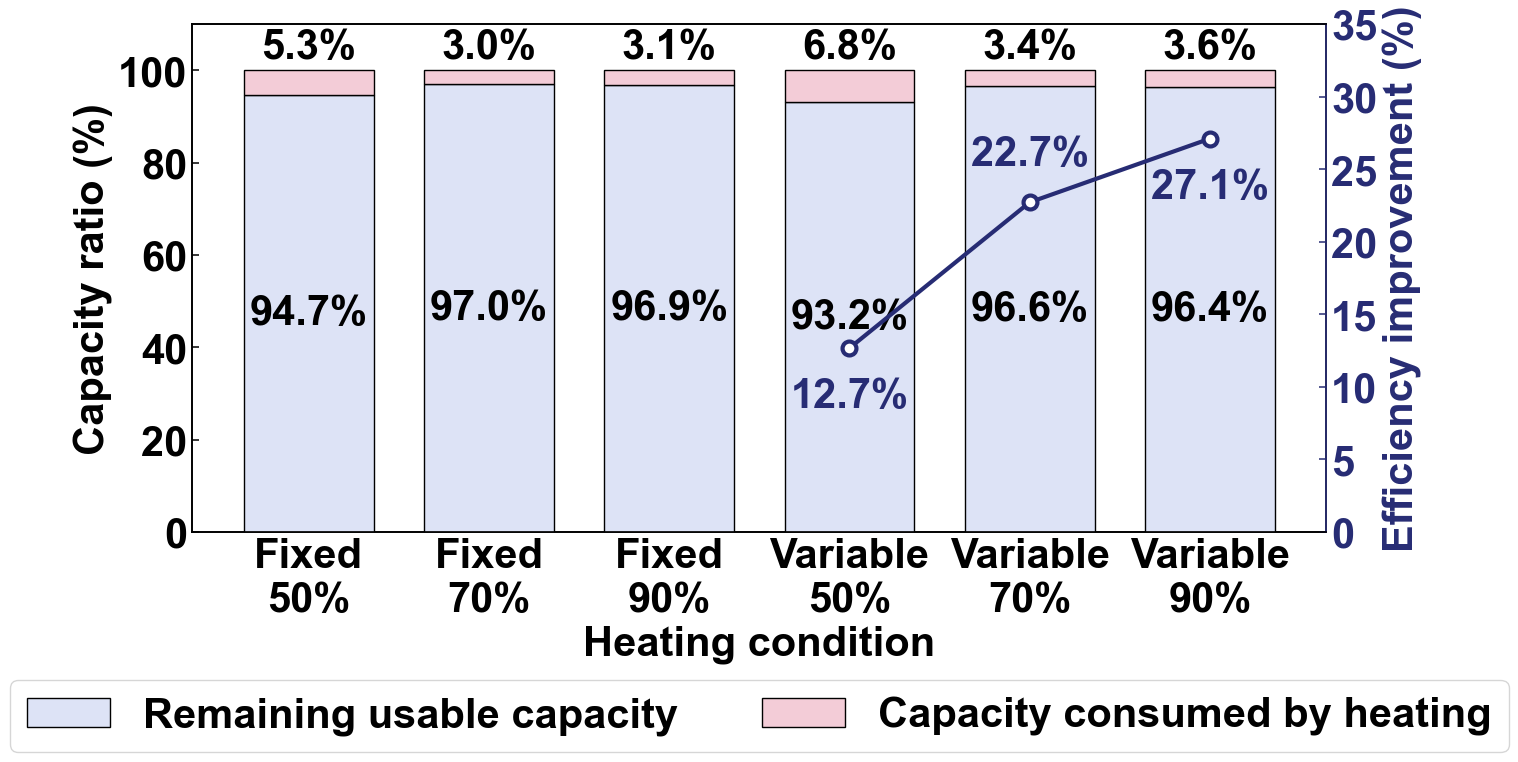

In [257]:
# -*- coding: utf-8 -*-
"""
Normalized stacked-bar chart + heating-efficiency improvement line

Meaning:
1. Left y-axis:
   - Each bar is normalized to 100%
   - Lower part: remaining usable capacity ratio (%)
   - Upper part: capacity consumed by heating ratio (%)

2. Right y-axis:
   - Heating efficiency improvement of variable-frequency
     relative to fixed-frequency (%)

Efficiency definition:
    efficiency = heating rate / consumed capacity

Improvement:
    improvement = (eta_variable - eta_fixed) / eta_fixed * 100%
"""

# =========================================================
# 0. ALL USER-ADJUSTABLE SETTINGS
# =========================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 0.1 Output
# ---------------------------------------------------------
OUTPUT_DIR = Path(r"C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_BASENAME = "fixed_variable_capacity_ratio_and_efficiency"

SAVE_PNG = True
SAVE_PDF = False
DPI = 300
BBOX_INCHES = "tight"
PAD_INCHES = 0.10


# ---------------------------------------------------------
# 0.2 Battery and raw data
# ---------------------------------------------------------
NOMINAL_CAPACITY_AH = 87.0

SOC_VALUES = np.array([50, 70, 90], dtype=float)

# Fixed-frequency
FIXED_REMAINING_AH = np.array([41.205, 59.059, 75.841], dtype=float)
FIXED_HEATING_RATE = np.array([1.86, 1.96, 1.88], dtype=float)

# Variable-frequency
VARIABLE_REMAINING_AH = np.array([40.543, 58.818, 75.470], dtype=float)
VARIABLE_HEATING_RATE = np.array([2.70, 2.72, 2.75], dtype=float)


# ---------------------------------------------------------
# 0.3 Figure
# ---------------------------------------------------------
FIGSIZE = (15, 8)
FIG_FACE_COLOR = "white"
AX_FACE_COLOR = "white"

SHOW_TITLE = False
TITLE_TEXT = "Capacity ratio and heating efficiency improvement"


# ---------------------------------------------------------
# 0.4 X-axis layout
# ---------------------------------------------------------
X_POSITIONS = np.arange(6, dtype=float)
X_TICK_LABELS = [
    "Fixed\n50%",
    "Fixed\n70%",
    "Fixed\n90%",
    "Variable\n50%",
    "Variable\n70%",
    "Variable\n90%",
]

# only variable-frequency positions have improvement values
IMPROVEMENT_X = np.array([3, 4, 5], dtype=float)


# ---------------------------------------------------------
# 0.5 Labels
# ---------------------------------------------------------
X_LABEL = "Heating condition"
LEFT_Y_LABEL = "Capacity ratio (%)"
RIGHT_Y_LABEL = "Efficiency improvement (%)"


# ---------------------------------------------------------
# 0.6 Colors
# ---------------------------------------------------------
COLOR_REMAINING = "#DDE3F6"
COLOR_CONSUMED = "#F3CCD7"
COLOR_IMPROVEMENT = "#272C74"

BAR_EDGE_COLOR = "black"
BAR_EDGE_WIDTH = 1.0

LINE_WIDTH = 3

# marker style (all adjustable)
MARKER_STYLE = "o"
MARKER_SIZE = 10
MARKER_FACE_COLOR = "white"
MARKER_EDGE_COLOR = COLOR_IMPROVEMENT
MARKER_EDGE_WIDTH = 3.0


# ---------------------------------------------------------
# 0.7 Bar settings
# ---------------------------------------------------------
BAR_WIDTH = 0.72


# ---------------------------------------------------------
# 0.8 Axis limits and ticks
# ---------------------------------------------------------
LEFT_Y_LIMIT = (0, 110)
LEFT_Y_TICKS = np.arange(0, 101, 20)

RIGHT_Y_LIMIT = (0, 35)
RIGHT_Y_TICKS = np.arange(0, 36, 5)


# ---------------------------------------------------------
# 0.9 Legend
# ---------------------------------------------------------
LEGEND_LOC = "upper center"
LEGEND_BBOX_TO_ANCHOR = (0.5, -0.25)
LEGEND_NCOL = 3
LEGEND_FONTSIZE = 30
LEGEND_FRAMEON = True


# ---------------------------------------------------------
# 0.10 Text annotations
# ---------------------------------------------------------
SHOW_BAR_PERCENT_TEXT = True
SHOW_IMPROVEMENT_TEXT = True

BAR_TEXT_FONTSIZE = 30
BAR_TEXT_FONTWEIGHT = "bold"

IMPROVEMENT_TEXT_FONTSIZE = 30
IMPROVEMENT_TEXT_FONTWEIGHT = "bold"

# put the percentage label BELOW the marker
IMPROVEMENT_TEXT_OFFSET = 2

# choose annotation color independently if desired
BAR_TEXT_COLOR = "black"
IMPROVEMENT_TEXT_COLOR = COLOR_IMPROVEMENT


# ---------------------------------------------------------
# 0.11 Font and axis style
# ---------------------------------------------------------
FONT_FAMILY = ["Arial", "DejaVu Sans", "Liberation Sans"]
FONT_WEIGHT = "bold"

AXIS_LABEL_FONTSIZE = 30
TICK_FONTSIZE = 30
TITLE_FONTSIZE = 18

SPINE_LINEWIDTH = 1.2

TICK_WIDTH = 1.1
TICK_LENGTH = 5
TICK_DIRECTION = "in"


# ---------------------------------------------------------
# 0.12 Grid
# ---------------------------------------------------------
SHOW_GRID = False
GRID_AXIS = "y"
GRID_LINESTYLE = "--"
GRID_LINEWIDTH = 0.8
GRID_ALPHA = 0.35


# =========================================================
# 1. CALCULATE CAPACITY AND EFFICIENCY
# =========================================================
initial_available_ah = NOMINAL_CAPACITY_AH * SOC_VALUES / 100.0

fixed_consumed_ah = initial_available_ah - FIXED_REMAINING_AH
variable_consumed_ah = initial_available_ah - VARIABLE_REMAINING_AH

# proportions
fixed_remaining_ratio = FIXED_REMAINING_AH / initial_available_ah * 100.0
fixed_consumed_ratio = fixed_consumed_ah / initial_available_ah * 100.0

variable_remaining_ratio = VARIABLE_REMAINING_AH / initial_available_ah * 100.0
variable_consumed_ratio = variable_consumed_ah / initial_available_ah * 100.0

all_remaining_ratio = np.concatenate([fixed_remaining_ratio, variable_remaining_ratio])
all_consumed_ratio = np.concatenate([fixed_consumed_ratio, variable_consumed_ratio])

# efficiency
fixed_efficiency = FIXED_HEATING_RATE / fixed_consumed_ah
variable_efficiency = VARIABLE_HEATING_RATE / variable_consumed_ah

improvement_percent = (variable_efficiency - fixed_efficiency) / fixed_efficiency * 100.0

print("=" * 80)
print("Capacity ratios")
print("=" * 80)
for i, soc in enumerate(SOC_VALUES):
    print(f"SOC = {int(soc)}%")
    print(f"  Fixed    : remaining = {fixed_remaining_ratio[i]:.2f}%, consumed = {fixed_consumed_ratio[i]:.2f}%")
    print(f"  Variable : remaining = {variable_remaining_ratio[i]:.2f}%, consumed = {variable_consumed_ratio[i]:.2f}%")
    print(f"  Efficiency improvement = {improvement_percent[i]:.2f}%")
    print("-" * 80)


# =========================================================
# 2. PLOT
# =========================================================
plt.rcParams["font.sans-serif"] = FONT_FAMILY
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False

fig, ax1 = plt.subplots(figsize=FIGSIZE, facecolor=FIG_FACE_COLOR)
ax1.set_facecolor(AX_FACE_COLOR)

# left axis: normalized stacked bars
bars_remaining = ax1.bar(
    X_POSITIONS,
    all_remaining_ratio,
    width=BAR_WIDTH,
    color=COLOR_REMAINING,
    edgecolor=BAR_EDGE_COLOR,
    linewidth=BAR_EDGE_WIDTH,
    label="Remaining usable capacity",
    zorder=3,
)

bars_consumed = ax1.bar(
    X_POSITIONS,
    all_consumed_ratio,
    width=BAR_WIDTH,
    bottom=all_remaining_ratio,
    color=COLOR_CONSUMED,
    edgecolor=BAR_EDGE_COLOR,
    linewidth=BAR_EDGE_WIDTH,
    label="Capacity consumed by heating",
    zorder=3,
)

# right axis: efficiency improvement line
ax2 = ax1.twinx()

improvement_line, = ax2.plot(
    IMPROVEMENT_X,
    improvement_percent,
    color=COLOR_IMPROVEMENT,
    linewidth=LINE_WIDTH,
    marker=MARKER_STYLE,
    markersize=MARKER_SIZE,
    markerfacecolor=MARKER_FACE_COLOR,
    markeredgecolor=MARKER_EDGE_COLOR,
    markeredgewidth=MARKER_EDGE_WIDTH,
    label="Efficiency improvement vs fixed frequency",
    zorder=5,
)

# ---------------------------------------------------------
# 2.1 Axis formatting
# ---------------------------------------------------------
ax1.set_xlabel(
    X_LABEL,
    fontsize=AXIS_LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT,
)

ax1.set_ylabel(
    LEFT_Y_LABEL,
    fontsize=AXIS_LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT,
)

ax2.set_ylabel(
    RIGHT_Y_LABEL,
    fontsize=AXIS_LABEL_FONTSIZE,
    fontweight=FONT_WEIGHT,
    color=COLOR_IMPROVEMENT,
)

if SHOW_TITLE:
    ax1.set_title(
        TITLE_TEXT,
        fontsize=TITLE_FONTSIZE,
        fontweight=FONT_WEIGHT,
        pad=10,
    )

ax1.set_xticks(X_POSITIONS)
ax1.set_xticklabels(X_TICK_LABELS)

ax1.set_ylim(*LEFT_Y_LIMIT)
ax1.set_yticks(LEFT_Y_TICKS)

ax2.set_ylim(*RIGHT_Y_LIMIT)
ax2.set_yticks(RIGHT_Y_TICKS)

ax1.tick_params(
    axis="both",
    labelsize=TICK_FONTSIZE,
    width=TICK_WIDTH,
    length=TICK_LENGTH,
    direction=TICK_DIRECTION,
)

ax2.tick_params(
    axis="y",
    labelsize=TICK_FONTSIZE,
    width=TICK_WIDTH,
    length=TICK_LENGTH,
    direction=TICK_DIRECTION,
    colors=COLOR_IMPROVEMENT,
)

for tick in ax1.get_xticklabels() + ax1.get_yticklabels():
    tick.set_fontweight(FONT_WEIGHT)

for tick in ax2.get_yticklabels():
    tick.set_fontweight(FONT_WEIGHT)

for spine in ax1.spines.values():
    spine.set_linewidth(SPINE_LINEWIDTH)

for spine_name, spine in ax2.spines.items():
    spine.set_linewidth(SPINE_LINEWIDTH)
    if spine_name == "right":
        spine.set_color(COLOR_IMPROVEMENT)

# ---------------------------------------------------------
# 2.2 Grid
# ---------------------------------------------------------
if SHOW_GRID:
    ax1.grid(
        True,
        axis=GRID_AXIS,
        linestyle=GRID_LINESTYLE,
        linewidth=GRID_LINEWIDTH,
        alpha=GRID_ALPHA,
        zorder=0,
    )

# ---------------------------------------------------------
# 2.3 Bar annotations (percentages only)
# ---------------------------------------------------------
if SHOW_BAR_PERCENT_TEXT:
    for x, remaining_ratio, consumed_ratio in zip(
        X_POSITIONS, all_remaining_ratio, all_consumed_ratio
    ):
        # lower part
        ax1.text(
            x,
            remaining_ratio * 0.5,
            f"{remaining_ratio:.1f}%",
            ha="center",
            va="center",
            fontsize=BAR_TEXT_FONTSIZE,
            fontweight=BAR_TEXT_FONTWEIGHT,
            color=BAR_TEXT_COLOR,
            zorder=6,
        )

        # upper part
        ax1.text(
            x,
            remaining_ratio + consumed_ratio + 0.8,
            f"{consumed_ratio:.1f}%",
            ha="center",
            va="bottom",
            fontsize=BAR_TEXT_FONTSIZE,
            fontweight=BAR_TEXT_FONTWEIGHT,
            color=BAR_TEXT_COLOR,
            zorder=6,
        )

# ---------------------------------------------------------
# 2.4 Improvement annotations (below marker)
# ---------------------------------------------------------
if SHOW_IMPROVEMENT_TEXT:
    for i, (x, y) in enumerate(zip(IMPROVEMENT_X, improvement_percent)):
        if i == 1:   # 第二个点：22.7%
            text_y = y + IMPROVEMENT_TEXT_OFFSET
            va_mode = "bottom"
        else:
            text_y = y - IMPROVEMENT_TEXT_OFFSET
            va_mode = "top"

        ax2.text(
            x,
            text_y,
            f"{y:.1f}%",
            ha="center",
            va=va_mode,
            fontsize=IMPROVEMENT_TEXT_FONTSIZE,
            fontweight=IMPROVEMENT_TEXT_FONTWEIGHT,
            color=IMPROVEMENT_TEXT_COLOR,
            zorder=6,
        )

# ---------------------------------------------------------
# 2.5 Legend (moved away from line)
# ---------------------------------------------------------
legend_handles = [
    bars_remaining,
    bars_consumed,
]

legend_labels = [
    "Remaining usable capacity",
    "Capacity consumed by heating",
]

legend = ax1.legend(
    legend_handles,
    legend_labels,
    loc=LEGEND_LOC,
    bbox_to_anchor=LEGEND_BBOX_TO_ANCHOR,
    ncol=LEGEND_NCOL,
    fontsize=LEGEND_FONTSIZE,
    frameon=LEGEND_FRAMEON,
)

for text in legend.get_texts():
    text.set_fontweight(FONT_WEIGHT)

# =========================================================
# 3. SAVE AND SHOW
# =========================================================
fig.tight_layout()

png_path = OUTPUT_DIR / f"{OUTPUT_BASENAME}.png"
pdf_path = OUTPUT_DIR / f"{OUTPUT_BASENAME}.pdf"

if SAVE_PNG:
    fig.savefig(
        png_path,
        dpi=DPI,
        bbox_inches=BBOX_INCHES,
        pad_inches=PAD_INCHES,
        facecolor=FIG_FACE_COLOR,
    )
    print(f"PNG saved to: {png_path}")

if SAVE_PDF:
    fig.savefig(
        pdf_path,
        bbox_inches=BBOX_INCHES,
        pad_inches=PAD_INCHES,
        facecolor=FIG_FACE_COLOR,
    )
    print(f"PDF saved to: {pdf_path}")

plt.show()

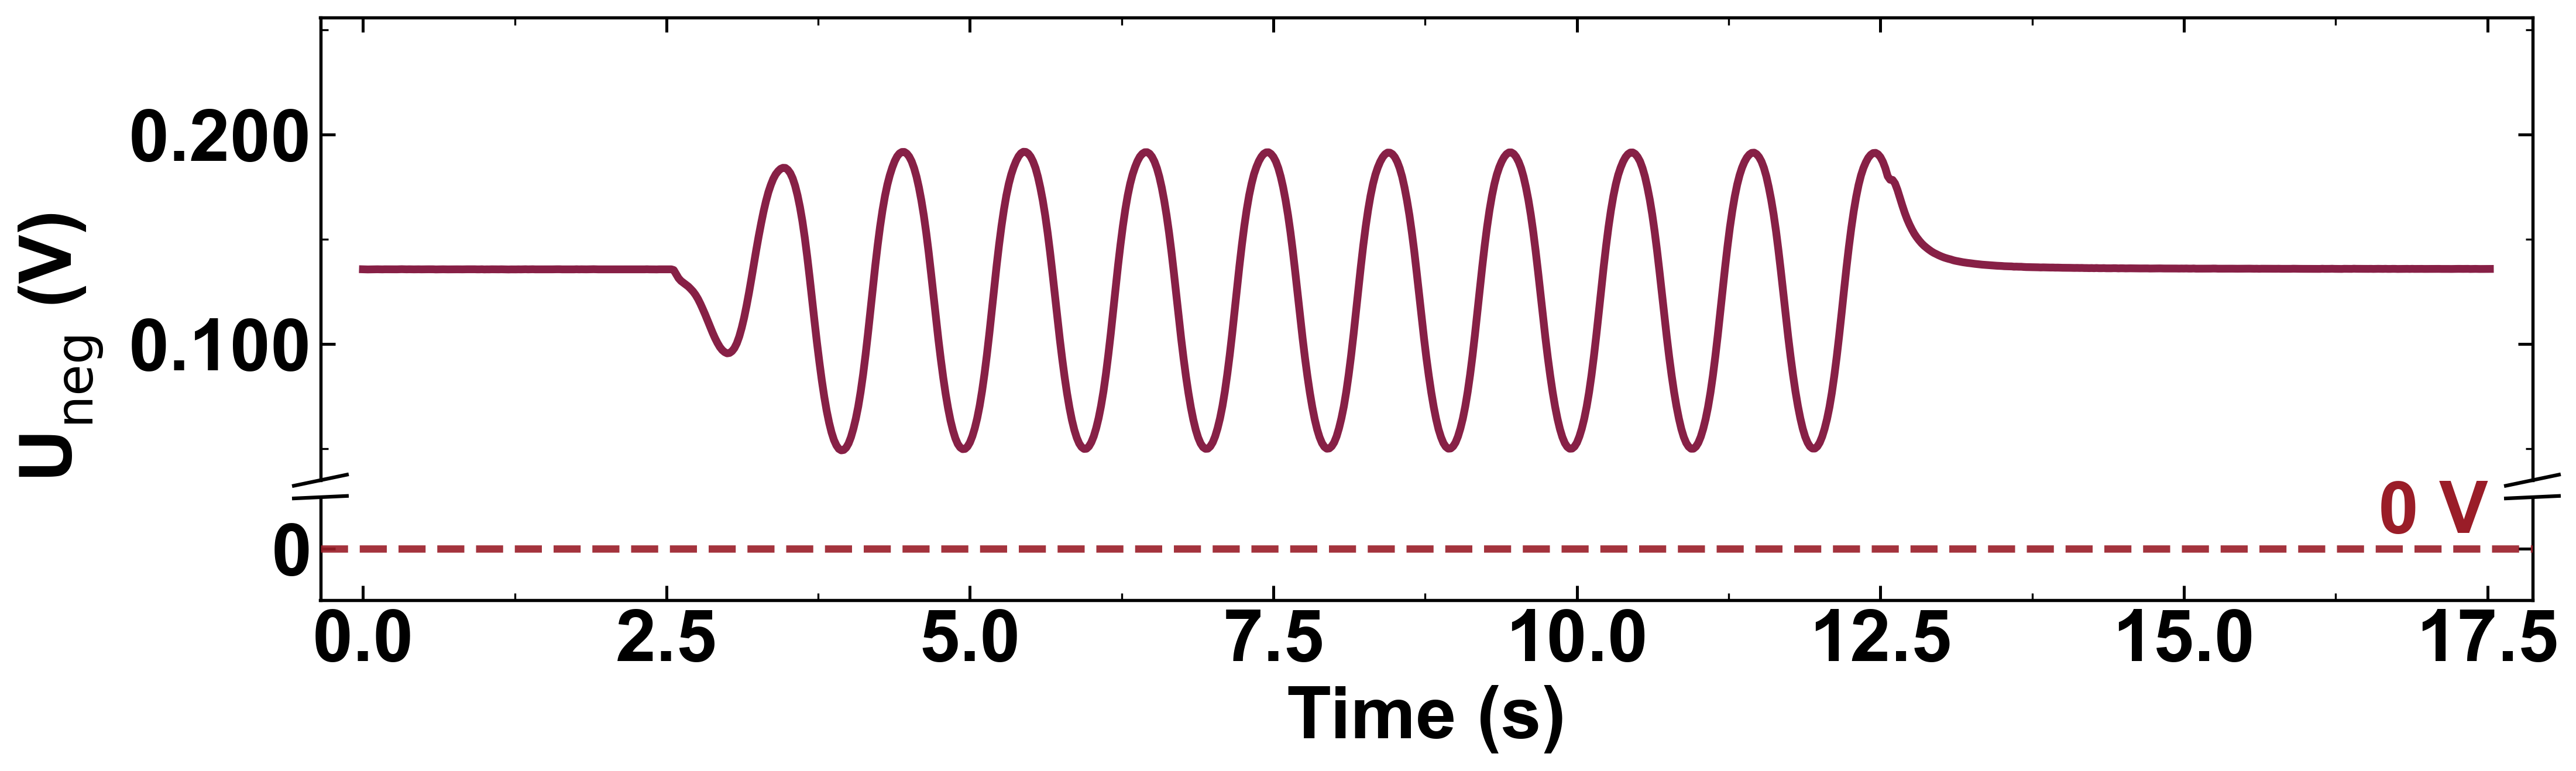

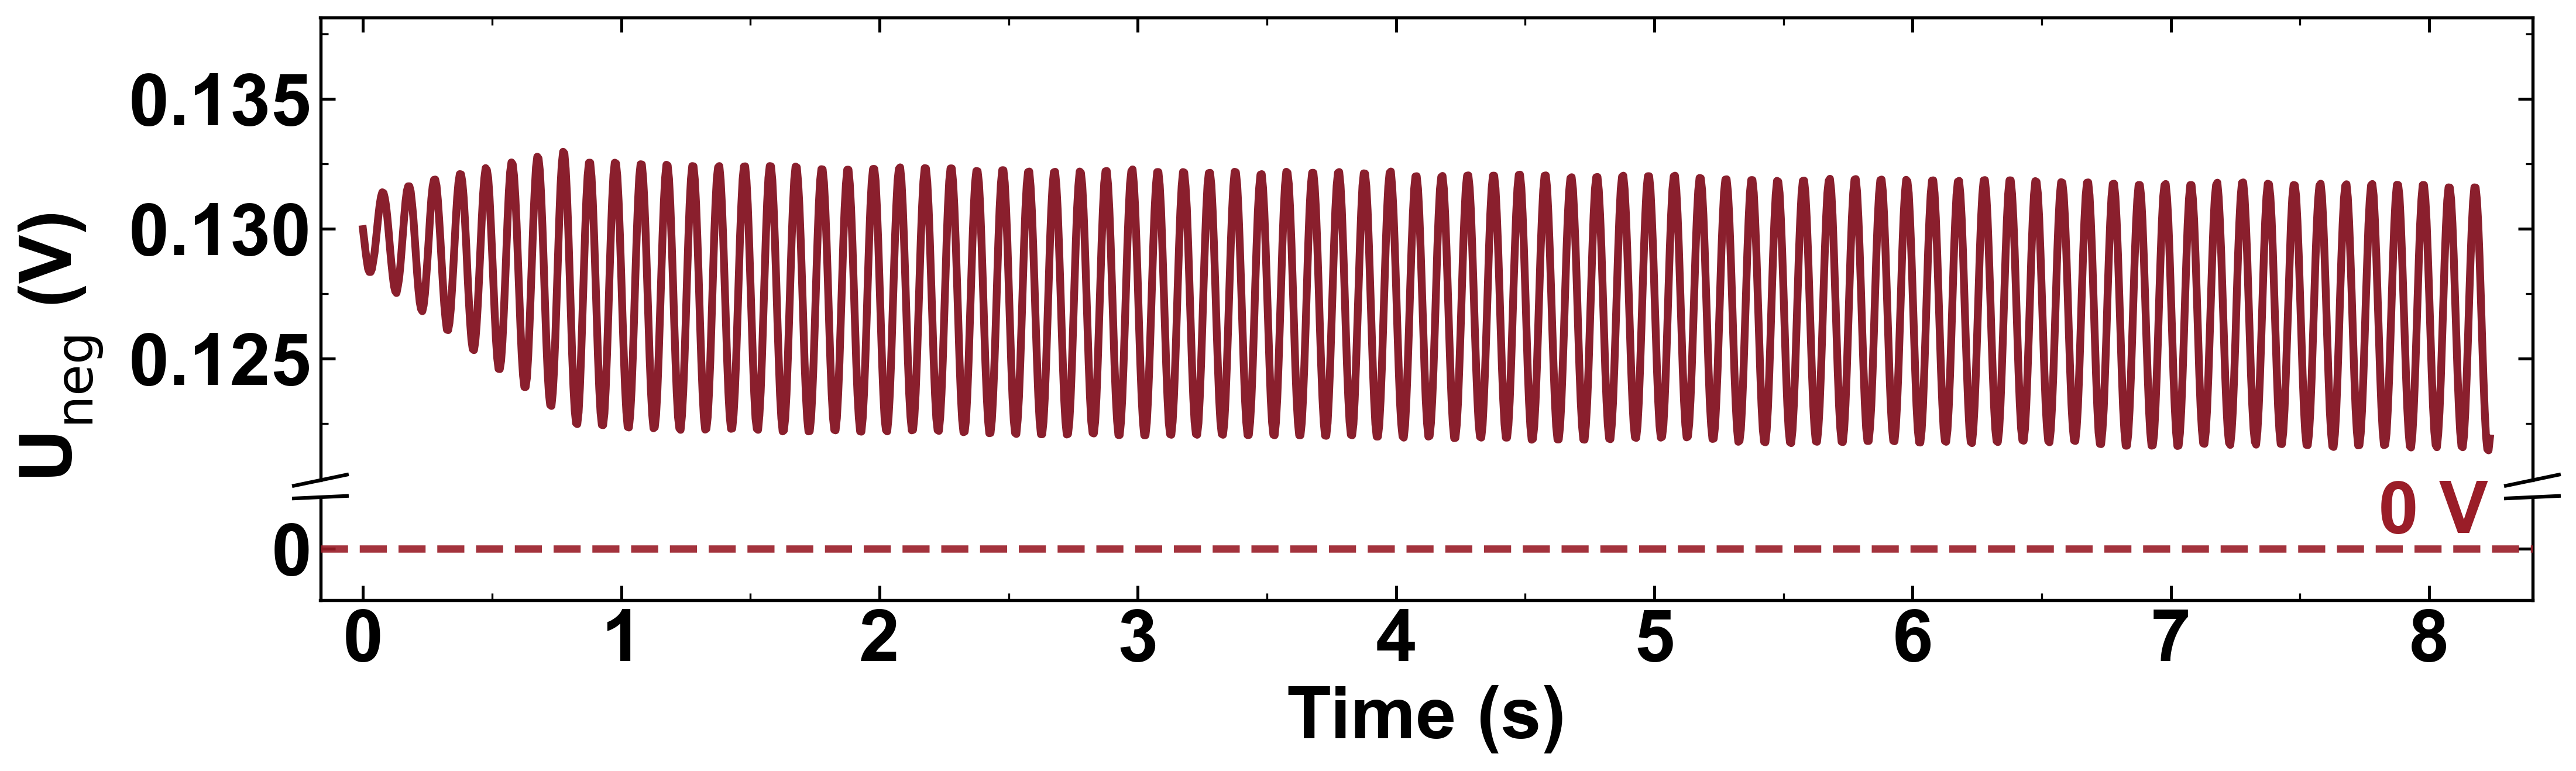

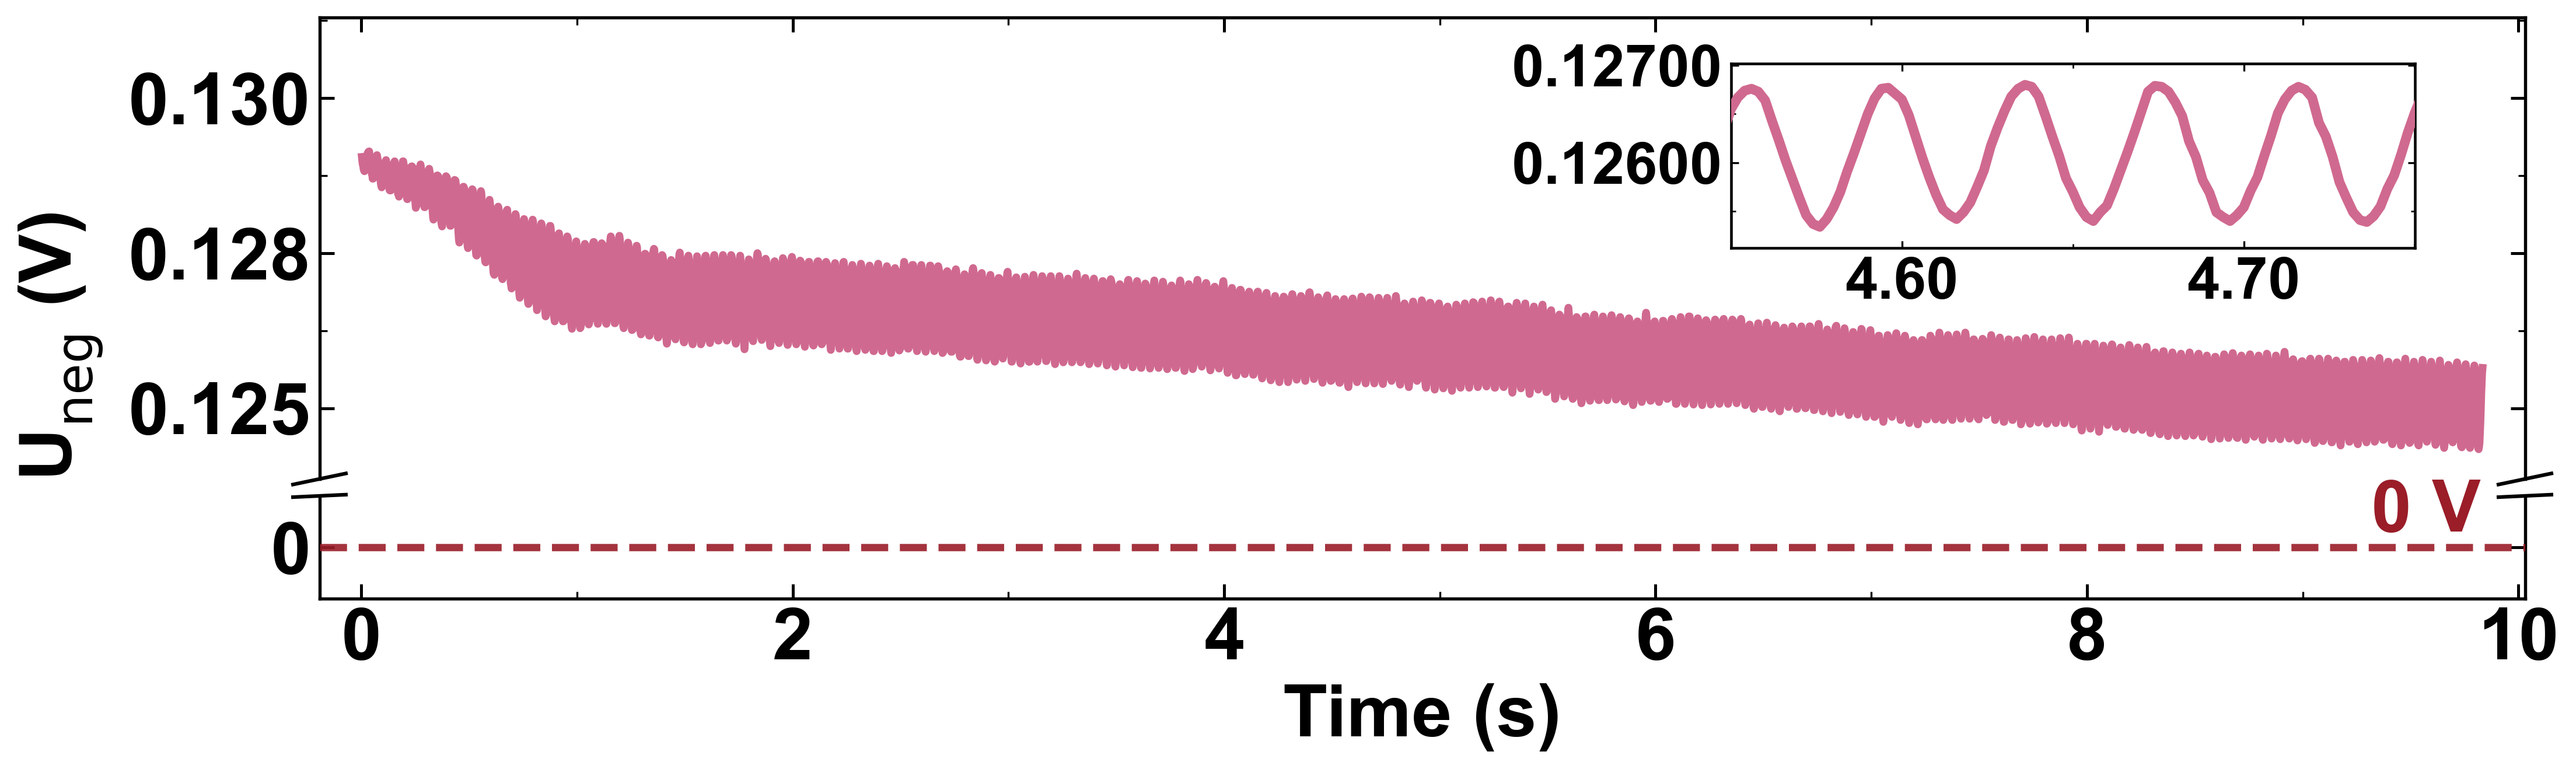

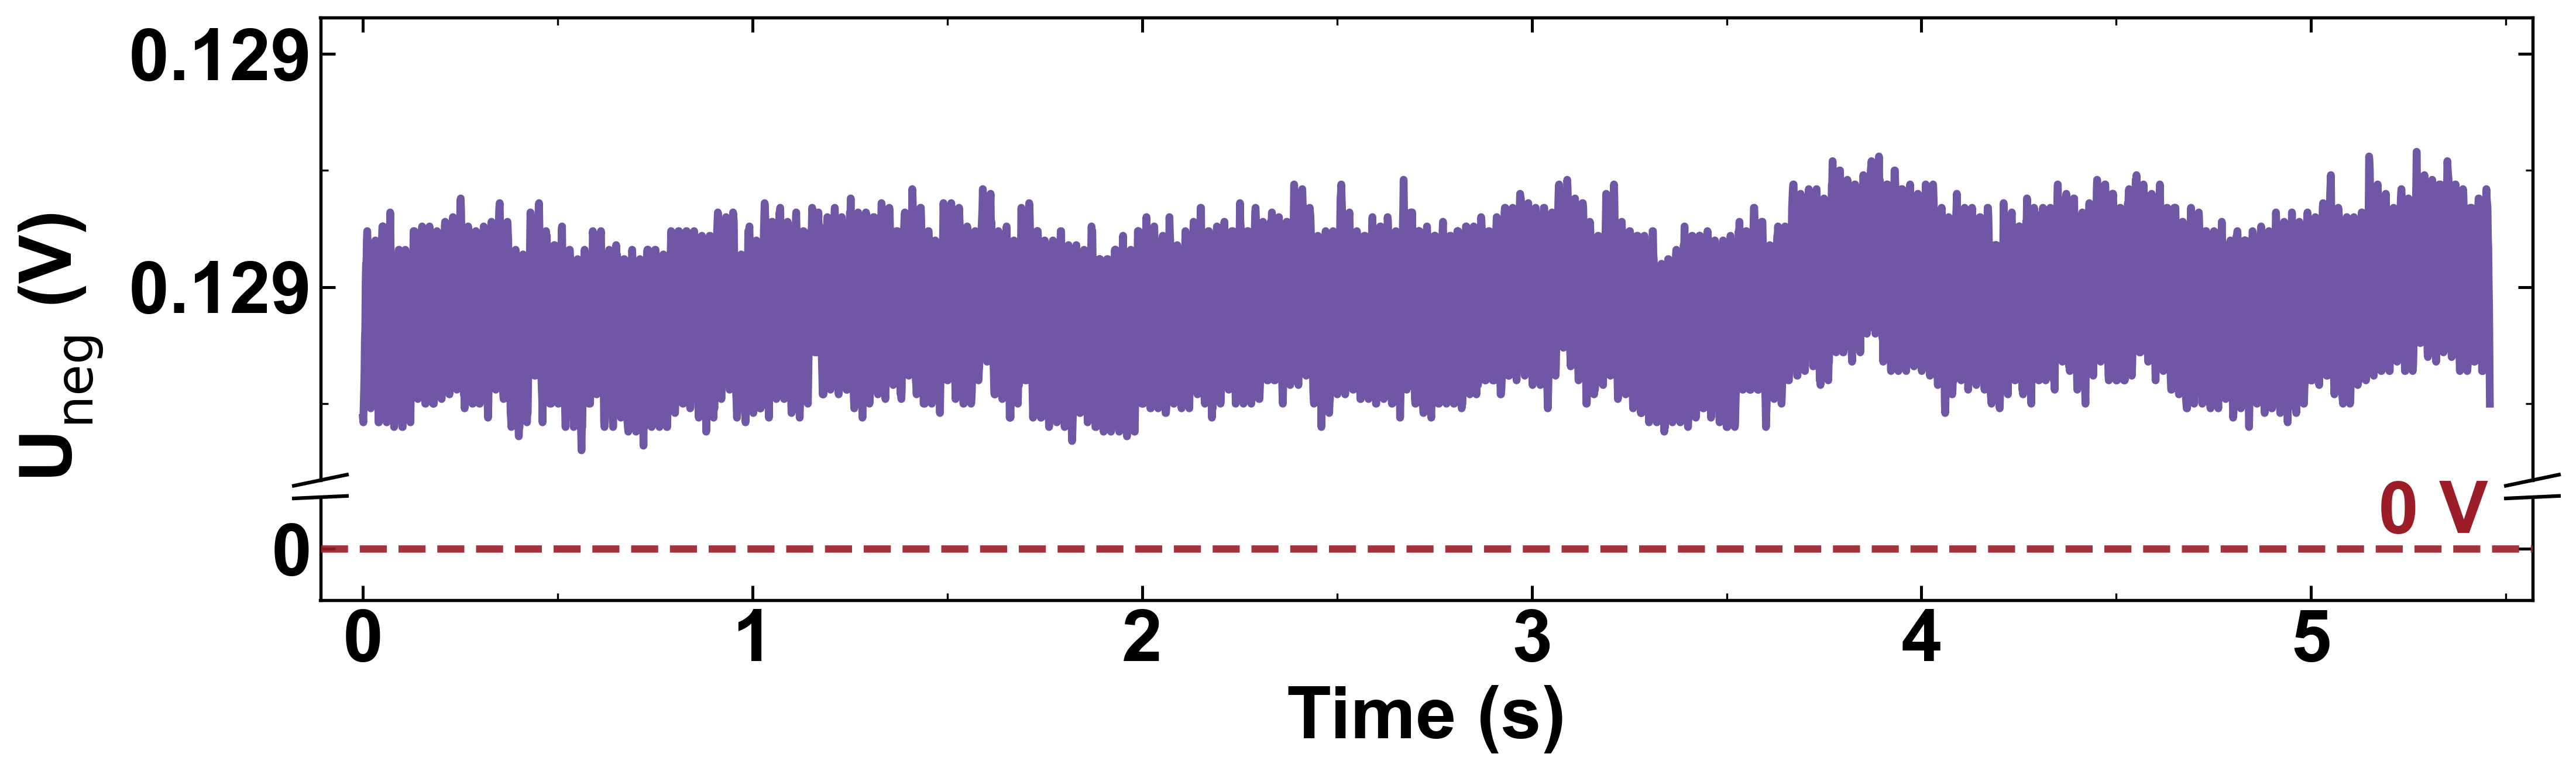


Four U_neg figures completed

1Hz_24A
  Valid points: 877
  Time range: 0.000000–17.520000 s
  U_neg range: 0.049200–0.191810 V
  PNG: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\102Ah_析锂验证\102Ah_Uneg_1Hz_24A.png
  PDF: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\102Ah_析锂验证\102Ah_Uneg_1Hz_24A.pdf

10Hz_95A
  Valid points: 1648
  Time range: 0.000000–8.235000 s
  U_neg range: 0.121470–0.132970 V
  PNG: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\102Ah_析锂验证\102Ah_Uneg_10Hz_95A.png
  PDF: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\102Ah_析锂验证\102Ah_Uneg_10Hz_95A.pdf

25Hz_24A
  Valid points: 4917
  Time range: 0.002000–9.834000 s
  U_neg range: 0.124340–0.129140 V
  PNG: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\102Ah_析锂验证\102Ah_Uneg_25Hz_24A.png
  PDF: C:\baidunetdiskdownload\各类文档\2025-07-15-NC重大\出图\102Ah_析锂验证\102Ah_Uneg_25Hz_24A.pdf

50Hz_95A
  Valid points: 5460
  Time range: 0.000000–5.459000 s
  U_neg range: 0.128150–0.128790 V
  PNG: C:\baidunetdiskdownload\各类

In [278]:
# -*- coding: utf-8 -*-
"""
Plot four negative-electrode-potential curves from:

C:\baidunetdiskdownload\各类文档\
2025-07-15-NC重大\102Ah-析锂验证.xlsx

Excel layout:
    A:B -> 1 Hz, 24 A
    D:E -> 10 Hz, 95 A
    G:H -> 25 Hz, 24 A
    J:K -> 50 Hz, 95 A

Features:
1. Four independent figures.
2. Figure size: 12 × 6, aspect ratio 2:1.
3. No figure title.
4. Y-axis label: U_neg (V).
5. A horizontal 0 V reference line.
6. Y-axis extends slightly below 0 V.
7. All adjustable settings are placed at the beginning.
"""

# =========================================================
# 0. ALL USER-ADJUSTABLE SETTINGS
# =========================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.ticker import (
    AutoMinorLocator,
    MultipleLocator,
    FuncFormatter,
)

from mpl_toolkits.axes_grid1.inset_locator import mark_inset


# ---------------------------------------------------------
# 0.1 Input file
# ---------------------------------------------------------

INPUT_FILE = Path(
    r"C:\baidunetdiskdownload\各类文档"
    r"\2025-07-15-NC重大\102Ah-析锂验证.xlsx"
)

SHEET_NAME = "Sheet1"
EXCEL_ENGINE = "openpyxl"

# Excel row:
# Row 1: condition name
# Row 2: column name
# Row 3 onward: numerical data
DATA_START_ROW = 3


# ---------------------------------------------------------
# 0.2 Four data blocks
# ---------------------------------------------------------
#
# x_limit:
#     None -> automatically determined
#     Example: (0, 1.0)
#
# y_limit:
#     None -> automatically determined while forcing 0 V to appear
#     Example: (-0.005, 0.15)

DATA_BLOCKS = [
    {
        "name": "1Hz_24A",
        "file_tag": "1Hz_24A",
        "time_column": "A",
        "voltage_column": "B",
        "color": "#872046",
        "x_limit": None,
        "y_limit": None,
    },

    {
        "name": "10Hz_95A",
        "file_tag": "10Hz_95A",
        "time_column": "D",
        "voltage_column": "E",
        "color": "#8A1F2D",
        "x_limit": None,
        "y_limit": None,
    },

    {
        "name": "25Hz_24A",
        "file_tag": "25Hz_24A",
        "time_column": "G",
        "voltage_column": "H",
        "color": "#D0698F",
        "x_limit": None,
        "y_limit": None,
    },

    {
        "name": "50Hz_95A",
        "file_tag": "50Hz_95A",
        "time_column": "J",
        "voltage_column": "K",
        "color": "#7057A6",
        "x_limit": None,
        "y_limit": None,
    },
]


# ---------------------------------------------------------
# 0.3 Data processing
# ---------------------------------------------------------

SORT_BY_TIME = True
DROP_DUPLICATE_TIME = True

# Moving-average window:
# 1 means no smoothing.
SMOOTH_WINDOW = 1

MIN_VALID_POINTS = 2


# ---------------------------------------------------------
# 0.4 Output
# ---------------------------------------------------------

OUTPUT_DIR = (
    INPUT_FILE.parent
    / "出图"
    / "102Ah_析锂验证"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_PREFIX = "102Ah_Uneg"

SAVE_PNG = True
SAVE_PDF = True

DPI = 300
BBOX_INCHES = "tight"
PAD_INCHES = 0.10

TRANSPARENT_BACKGROUND = False


# ---------------------------------------------------------
# 0.5 Figure
# ---------------------------------------------------------

# Width × height = 12 × 6
FIGSIZE = (15, 4)

FIG_FACE_COLOR = "white"
AX_FACE_COLOR = "white"

# No title
SHOW_TITLE = False


# ---------------------------------------------------------
# 0.6 Curve
# ---------------------------------------------------------

LINE_WIDTH = 3.2
LINE_STYLE = "-"
LINE_ALPHA = 1.0

SHOW_MARKERS = False

MARKER_STYLE = "o"
MARKER_SIZE = 4.5

MARKER_FACE_COLOR = "white"
MARKER_EDGE_WIDTH = 1.2


# ---------------------------------------------------------
# 0.7 Axis labels
# ---------------------------------------------------------

X_LABEL = "Time (s)"

# Matplotlib renders this as U with subscript neg.
Y_LABEL = r"$U_{\mathrm{neg}}$ (V)"

AXIS_LABEL_SIZE = 30
TICK_LABEL_SIZE = 30

FONT_WEIGHT = "bold"

FONT_FAMILY = [
    "Arial",
    "DejaVu Sans",
    "Liberation Sans",
]


# ---------------------------------------------------------
# 0.8 Automatic axis limits
# ---------------------------------------------------------

# X-axis margin relative to the total time range
X_MARGIN_RATIO = 0.02

# Data upper margin
Y_UPPER_MARGIN_RATIO = 0.08

# Extra margin if the data themselves are below zero
Y_DATA_MARGIN_RATIO = 0.08

# Force 0 V to be shown
FORCE_SHOW_ZERO_V = True

# Y-axis lower limit below 0 V
# Example:
# 0.005 -> lower limit approximately -0.005 V
Y_BELOW_ZERO_MARGIN_V = 0.005

# Prevent an excessively small y-axis span
MINIMUM_Y_SPAN = 1.0e-4


# ---------------------------------------------------------
# 0.9 Zero-voltage reference line
# ---------------------------------------------------------

SHOW_ZERO_REFERENCE_LINE = True

ZERO_REFERENCE_VALUE = 0.0

ZERO_REFERENCE_COLOR = "#9A1D28"
ZERO_REFERENCE_STYLE = "--"
ZERO_REFERENCE_WIDTH = 3
ZERO_REFERENCE_ALPHA = 0.90

SHOW_ZERO_REFERENCE_TEXT = True

ZERO_REFERENCE_TEXT = "0 V"
ZERO_REFERENCE_TEXT_SIZE = 30
ZERO_REFERENCE_TEXT_WEIGHT = "bold"
ZERO_REFERENCE_TEXT_COLOR = ZERO_REFERENCE_COLOR

# Horizontal position in axes coordinates
ZERO_REFERENCE_TEXT_X = 0.98

# Vertical offset above the 0 V line,
# expressed as a fraction of the full y-axis span
ZERO_REFERENCE_TEXT_Y_OFFSET_RATIO = 0.012


# ---------------------------------------------------------
# 0.10 Tick settings
# ---------------------------------------------------------

# Y tick decimal places
Y_TICK_DECIMALS = 3

# None means automatic major ticks.
#
# Example:
# X_MAJOR_INTERVAL = 0.1
# Y_MAJOR_INTERVAL = 0.02

X_MAJOR_INTERVAL = None
Y_MAJOR_INTERVAL = None

# Minor subdivisions between major ticks
X_MINOR_SUBDIVISIONS = 2
Y_MINOR_SUBDIVISIONS = 2


# ---------------------------------------------------------
# 0.11 Tick and border appearance
# ---------------------------------------------------------

TICK_DIRECTION = "in"

SHOW_TOP_TICKS = True
SHOW_RIGHT_TICKS = True

MAJOR_TICK_LENGTH = 6
MAJOR_TICK_WIDTH = 1.2

MINOR_TICK_LENGTH = 3
MINOR_TICK_WIDTH = 0.8

SPINE_WIDTH = 1.3


# ---------------------------------------------------------
# 0.12 Grid
# ---------------------------------------------------------

SHOW_GRID = False

GRID_WHICH = "major"
GRID_LINESTYLE = "--"
GRID_LINEWIDTH = 0.7
GRID_ALPHA = 0.32


# ---------------------------------------------------------
# 0.13 Legend
# ---------------------------------------------------------

# Each figure contains only one curve, so legend is disabled.
SHOW_LEGEND = False

LEGEND_LOCATION = "best"
LEGEND_SIZE = 18
LEGEND_FRAMEON = True

# ---------------------------------------------------------
# Broken y-axis settings
# ---------------------------------------------------------

USE_BROKEN_Y_AXIS = True

# 上下两个坐标区的高度比例
BROKEN_AXIS_HEIGHT_RATIOS = [4.5, 1.0]

# 两个坐标区之间的距离
BROKEN_AXIS_HSPACE = 0.06

# 下半部分固定显示0 V附近
LOWER_PANEL_Y_LIMIT = (-0.005, 0.005)

# 上半部分根据数据自动确定
# 上半图底部留白
UPPER_PANEL_LOWER_MARGIN_RATIO = 0.10

# 上半图顶部留白，增大后曲线会整体向下
UPPER_PANEL_UPPER_MARGIN_RATIO = 0.45

MINIMUM_UPPER_PANEL_SPAN = 0.0005

# 截断符号
BREAK_MARK_SIZE = 0.012
BREAK_MARK_LINEWIDTH = 1.5
BREAK_MARK_COLOR = "black"

# 下半部分的主刻度间隔
LOWER_PANEL_MAJOR_INTERVAL = 0.005

# 上半部分刻度保留的小数位
UPPER_Y_TICK_DECIMALS = 3

# 下半部分刻度保留的小数位
LOWER_Y_TICK_DECIMALS = 0


# ---------------------------------------------------------
# Local waveform inset settings
# ---------------------------------------------------------

ENABLE_INSET_ZOOM = True

# The inset is enabled for the 25 Hz condition.
# Change this tag when another condition needs a local enlargement.
INSET_TARGET_FILE_TAG = "25Hz_24A"
# Example:
# INSET_TARGET_FILE_TAG = "5Hz_24A"

# Inset position inside the upper broken-axis panel:
# [left, bottom, width, height], all in axes-relative coordinates.
INSET_AXES_BOUNDS = [0.64, 0.50, 0.31, 0.40]

# X range to magnify.
# Adjust this range to select several visible waveform periods.
INSET_X_LIMIT = (4.55, 4.75)

# None: determine automatically from data inside INSET_X_LIMIT.
# Example: (0.12545, 0.12675)
INSET_Y_LIMIT = None

# Automatic inset y-range settings.
INSET_AUTO_Y_MARGIN_RATIO = 0.15
INSET_MINIMUM_Y_SPAN = 5.0e-5

# Inset curve.
INSET_LINE_WIDTH = 4
INSET_LINE_STYLE = "-"
INSET_LINE_ALPHA = 1.0

# Inset background and border.
INSET_FACE_COLOR = "white"
INSET_FACE_ALPHA = 1.0
INSET_SPINE_WIDTH = 1.1

# Inset ticks.
SHOW_INSET_TICKS = True
INSET_TICK_LABEL_SIZE = 24
INSET_TICK_LENGTH = 3
INSET_TICK_WIDTH = 0.8
INSET_X_TICK_DECIMALS = 2
INSET_Y_TICK_DECIMALS = 5
INSET_X_MINOR_SUBDIVISIONS = 2
INSET_Y_MINOR_SUBDIVISIONS = 2

# Zoom-region rectangle and connector lines.
# False: keep only the inset plot; do not draw the red source box
# or the connector lines on the main figure.
SHOW_INSET_REGION_AND_CONNECTORS = False
INSET_INDICATOR_COLOR = "#E74C3C"
INSET_INDICATOR_LINEWIDTH = 1.4
INSET_INDICATOR_ALPHA = 1.0

# mark_inset connector corners.
# Valid values are 1, 2, 3, and 4.
INSET_CONNECTOR_LOC1 = 2
INSET_CONNECTOR_LOC2 = 4


# =========================================================
# 1. HELPER FUNCTIONS
# =========================================================

def excel_column_to_index(column_letter):
    """
    Convert an Excel column letter to a zero-based index.

    Examples:
        A  -> 0
        B  -> 1
        Z  -> 25
        AA -> 26
    """

    column_letter = (
        str(column_letter)
        .strip()
        .upper()
    )

    if not column_letter.isalpha():
        raise ValueError(
            f"Invalid Excel column: {column_letter}"
        )

    result = 0

    for character in column_letter:
        result = (
            result * 26
            + ord(character)
            - ord("A")
            + 1
        )

    return result - 1


def load_raw_sheet():
    """
    Read the complete Excel sheet without using a header row.
    """

    if not INPUT_FILE.exists():
        raise FileNotFoundError(
            f"Input Excel file not found:\n"
            f"{INPUT_FILE}"
        )

    raw_dataframe = pd.read_excel(
        INPUT_FILE,
        sheet_name=SHEET_NAME,
        header=None,
        engine=EXCEL_ENGINE,
    )

    if raw_dataframe.empty:
        raise ValueError(
            f"The worksheet '{SHEET_NAME}' is empty."
        )

    return raw_dataframe


def extract_block(
    raw_dataframe,
    block,
):
    """
    Extract time and U_neg data for one condition.
    """

    time_index = excel_column_to_index(
        block["time_column"]
    )

    voltage_index = excel_column_to_index(
        block["voltage_column"]
    )

    maximum_required_index = max(
        time_index,
        voltage_index,
    )

    if maximum_required_index >= raw_dataframe.shape[1]:
        raise IndexError(
            f"{block['name']}: requested Excel column "
            f"exceeds worksheet width."
        )

    # Excel row 3 corresponds to pandas index 2.
    start_index = DATA_START_ROW - 1

    time_series = pd.to_numeric(
        raw_dataframe.iloc[
            start_index:,
            time_index,
        ],
        errors="coerce",
    )

    voltage_series = pd.to_numeric(
        raw_dataframe.iloc[
            start_index:,
            voltage_index,
        ],
        errors="coerce",
    )

    extracted_data = pd.DataFrame(
        {
            "time": time_series,
            "voltage": voltage_series,
        }
    )

    extracted_data = extracted_data.dropna(
        subset=[
            "time",
            "voltage",
        ]
    )

    if DROP_DUPLICATE_TIME:
        extracted_data = (
            extracted_data
            .drop_duplicates(
                subset="time",
                keep="first",
            )
        )

    if SORT_BY_TIME:
        extracted_data = (
            extracted_data
            .sort_values("time")
        )

    extracted_data = (
        extracted_data
        .reset_index(drop=True)
    )

    if len(extracted_data) < MIN_VALID_POINTS:
        raise ValueError(
            f"{block['name']}: only "
            f"{len(extracted_data)} valid points found."
        )

    smooth_window = max(
        1,
        int(SMOOTH_WINDOW),
    )

    if smooth_window > 1:
        extracted_data["voltage_plot"] = (
            extracted_data["voltage"]
            .rolling(
                window=smooth_window,
                center=True,
                min_periods=1,
            )
            .mean()
        )

    else:
        extracted_data["voltage_plot"] = (
            extracted_data["voltage"]
        )

    return extracted_data


def determine_axis_limits(
    x_values,
    y_values,
    block,
):
    """
    Determine x-axis and y-axis limits.

    When y_limit is None, the y-axis:
    1. Shows the maximum data value with an upper margin.
    2. Includes 0 V.
    3. Extends slightly below 0 V.
    """

    # -----------------------------------------------------
    # X-axis
    # -----------------------------------------------------

    if block["x_limit"] is not None:
        x_limit = tuple(
            block["x_limit"]
        )

    else:
        x_minimum = float(
            np.nanmin(x_values)
        )

        x_maximum = float(
            np.nanmax(x_values)
        )

        x_span = (
            x_maximum
            - x_minimum
        )

        if x_span <= 0:
            x_span = 1.0

        x_limit = (
            x_minimum
            - X_MARGIN_RATIO
            * x_span,

            x_maximum
            + X_MARGIN_RATIO
            * x_span,
        )

    # -----------------------------------------------------
    # Y-axis
    # -----------------------------------------------------

    if block["y_limit"] is not None:
        y_limit = tuple(
            block["y_limit"]
        )

    else:
        y_minimum = float(
            np.nanmin(y_values)
        )

        y_maximum = float(
            np.nanmax(y_values)
        )

        y_data_span = (
            y_maximum
            - y_minimum
        )

        y_data_span = max(
            y_data_span,
            MINIMUM_Y_SPAN,
        )

        upper_reference_span = max(
            abs(y_maximum),
            y_data_span,
            MINIMUM_Y_SPAN,
        )

        automatic_y_upper = (
            y_maximum
            + Y_UPPER_MARGIN_RATIO
            * upper_reference_span
        )

        if FORCE_SHOW_ZERO_V:
            automatic_y_lower = (
                ZERO_REFERENCE_VALUE
                - Y_BELOW_ZERO_MARGIN_V
            )

            # If the measured data are lower than this value,
            # preserve the measured data as well.
            automatic_y_lower = min(
                automatic_y_lower,

                y_minimum
                - Y_DATA_MARGIN_RATIO
                * y_data_span,
            )

        else:
            automatic_y_lower = (
                y_minimum
                - Y_DATA_MARGIN_RATIO
                * y_data_span
            )

        y_limit = (
            automatic_y_lower,
            automatic_y_upper,
        )

    return x_limit, y_limit


def format_y_tick(
    value,
    position,
):
    """
    Format y-axis values without scientific offset notation.
    """

    if abs(value) < 0.5 * 10 ** (-Y_TICK_DECIMALS):
        value = 0.0

    return f"{value:.{Y_TICK_DECIMALS}f}"


def add_local_waveform_inset(
    axis_upper,
    block,
    x_values,
    y_values,
):
    """
    Add one local waveform inset to the selected frequency figure.

    The x range is controlled by INSET_X_LIMIT.
    The y range can be specified explicitly or determined automatically
    from the data inside the selected x range.
    """

    if not ENABLE_INSET_ZOOM:
        return None

    if block["file_tag"] != INSET_TARGET_FILE_TAG:
        return None

    inset_x_min, inset_x_max = INSET_X_LIMIT

    if inset_x_max <= inset_x_min:
        raise ValueError(
            "INSET_X_LIMIT must satisfy x_max > x_min."
        )

    inset_mask = (
        np.isfinite(x_values)
        & np.isfinite(y_values)
        & (x_values >= inset_x_min)
        & (x_values <= inset_x_max)
    )

    if np.count_nonzero(inset_mask) < 2:
        print(
            f"\nWarning: inset skipped for {block['file_tag']} "
            f"because fewer than two points were found inside "
            f"INSET_X_LIMIT={INSET_X_LIMIT}."
        )
        return None

    inset_x_data = x_values[inset_mask]
    inset_y_data = y_values[inset_mask]

    if INSET_Y_LIMIT is None:
        inset_y_min = float(
            np.nanmin(inset_y_data)
        )

        inset_y_max = float(
            np.nanmax(inset_y_data)
        )

        inset_y_span = max(
            inset_y_max - inset_y_min,
            INSET_MINIMUM_Y_SPAN,
        )

        inset_y_limit = (
            inset_y_min
            - INSET_AUTO_Y_MARGIN_RATIO
            * inset_y_span,

            inset_y_max
            + INSET_AUTO_Y_MARGIN_RATIO
            * inset_y_span,
        )

    else:
        inset_y_limit = tuple(
            INSET_Y_LIMIT
        )

    axis_inset = axis_upper.inset_axes(
        INSET_AXES_BOUNDS
    )

    axis_inset.set_facecolor(
        INSET_FACE_COLOR
    )

    axis_inset.patch.set_alpha(
        INSET_FACE_ALPHA
    )

    axis_inset.plot(
        x_values,
        y_values,
        color=block["color"],
        linestyle=INSET_LINE_STYLE,
        linewidth=INSET_LINE_WIDTH,
        alpha=INSET_LINE_ALPHA,
        zorder=3,
    )

    axis_inset.set_xlim(
        inset_x_min,
        inset_x_max,
    )

    axis_inset.set_ylim(
        *inset_y_limit
    )

    for spine in axis_inset.spines.values():
        spine.set_linewidth(
            INSET_SPINE_WIDTH
        )

    if SHOW_INSET_TICKS:
        axis_inset.tick_params(
            axis="both",
            which="major",
            direction="in",
            top=True,
            right=True,
            length=INSET_TICK_LENGTH,
            width=INSET_TICK_WIDTH,
            labelsize=INSET_TICK_LABEL_SIZE,
        )

        axis_inset.xaxis.set_major_formatter(
            FuncFormatter(
                lambda value, position:
                f"{value:.{INSET_X_TICK_DECIMALS}f}"
            )
        )

        axis_inset.yaxis.set_major_formatter(
            FuncFormatter(
                lambda value, position:
                f"{value:.{INSET_Y_TICK_DECIMALS}f}"
            )
        )

        axis_inset.xaxis.set_minor_locator(
            AutoMinorLocator(
                INSET_X_MINOR_SUBDIVISIONS
            )
        )

        axis_inset.yaxis.set_minor_locator(
            AutoMinorLocator(
                INSET_Y_MINOR_SUBDIVISIONS
            )
        )

        axis_inset.tick_params(
            axis="both",
            which="minor",
            direction="in",
            top=True,
            right=True,
            length=max(
                1.5,
                INSET_TICK_LENGTH * 0.60,
            ),
            width=max(
                0.5,
                INSET_TICK_WIDTH * 0.80,
            ),
        )

        for tick_label in (
            axis_inset.get_xticklabels()
            + axis_inset.get_yticklabels()
        ):
            tick_label.set_fontweight(
                FONT_WEIGHT
            )

    else:
        axis_inset.set_xticks([])
        axis_inset.set_yticks([])

    if SHOW_INSET_REGION_AND_CONNECTORS:
        mark_inset(
            axis_upper,
            axis_inset,
            loc1=INSET_CONNECTOR_LOC1,
            loc2=INSET_CONNECTOR_LOC2,
            fc="none",
            ec=INSET_INDICATOR_COLOR,
            lw=INSET_INDICATOR_LINEWIDTH,
            alpha=INSET_INDICATOR_ALPHA,
        )

    return axis_inset


def make_one_figure(
    block,
    extracted_data,
):
    """
    Create one figure using a broken y-axis.

    Upper panel:
        Enlarged U_neg curve.

    Lower panel:
        0 V reference region.
    """

    x_values = extracted_data[
        "time"
    ].to_numpy(
        dtype=float
    )

    y_values = extracted_data[
        "voltage_plot"
    ].to_numpy(
        dtype=float
    )

    # =====================================================
    # Calculate x-axis range
    # =====================================================

    if block["x_limit"] is not None:
        x_limit = tuple(
            block["x_limit"]
        )

    else:
        x_minimum = float(
            np.nanmin(x_values)
        )

        x_maximum = float(
            np.nanmax(x_values)
        )

        x_span = (
            x_maximum
            - x_minimum
        )

        if x_span <= 0:
            x_span = 1.0

        x_limit = (
            x_minimum
            - X_MARGIN_RATIO
            * x_span,

            x_maximum
            + X_MARGIN_RATIO
            * x_span,
        )

    # =====================================================
    # Calculate upper-panel y range
    # =====================================================

    if block["y_limit"] is not None:
        upper_y_limit = tuple(
            block["y_limit"]
        )

    else:
        y_minimum = float(
            np.nanmin(y_values)
        )

        y_maximum = float(
            np.nanmax(y_values)
        )

        y_span = (
            y_maximum
            - y_minimum
        )

        y_span = max(
            y_span,
            MINIMUM_UPPER_PANEL_SPAN,
        )

        upper_y_limit = (
            y_minimum
            - UPPER_PANEL_LOWER_MARGIN_RATIO
            * y_span,

            y_maximum
            + UPPER_PANEL_UPPER_MARGIN_RATIO
            * y_span,
        )

    # =====================================================
    # Create broken-axis figure
    # =====================================================

    fig = plt.figure(
        figsize=FIGSIZE,
        dpi=DPI,
        facecolor=FIG_FACE_COLOR,
    )

    grid_spec = fig.add_gridspec(
        nrows=2,
        ncols=1,

        height_ratios=BROKEN_AXIS_HEIGHT_RATIOS,
        hspace=BROKEN_AXIS_HSPACE,
    )

    axis_upper = fig.add_subplot(
        grid_spec[0, 0]
    )

    axis_lower = fig.add_subplot(
        grid_spec[1, 0],
        sharex=axis_upper,
    )

    axis_upper.set_facecolor(
        AX_FACE_COLOR
    )

    axis_lower.set_facecolor(
        AX_FACE_COLOR
    )

    # =====================================================
    # Plot U_neg in the upper panel
    # =====================================================

    line, = axis_upper.plot(
        x_values,
        y_values,

        color=block["color"],
        linestyle=LINE_STYLE,
        linewidth=LINE_WIDTH,
        alpha=LINE_ALPHA,

        marker=(
            MARKER_STYLE
            if SHOW_MARKERS
            else None
        ),

        markersize=MARKER_SIZE,
        markerfacecolor=MARKER_FACE_COLOR,
        markeredgecolor=block["color"],
        markeredgewidth=MARKER_EDGE_WIDTH,

        label=block["name"],
        zorder=4,
    )

    # =====================================================
    # Axis limits
    # =====================================================

    axis_upper.set_xlim(
        *x_limit
    )

    axis_lower.set_xlim(
        *x_limit
    )

    axis_upper.set_ylim(
        *upper_y_limit
    )

    axis_lower.set_ylim(
        *LOWER_PANEL_Y_LIMIT
    )

    # =====================================================
    # Local waveform inset for the selected frequency
    # =====================================================

    add_local_waveform_inset(
        axis_upper=axis_upper,
        block=block,
        x_values=x_values,
        y_values=y_values,
    )

    # =====================================================
    # 0 V reference line in lower panel
    # =====================================================

    if SHOW_ZERO_REFERENCE_LINE:
        axis_lower.axhline(
            y=ZERO_REFERENCE_VALUE,
            color=ZERO_REFERENCE_COLOR,
            linestyle=ZERO_REFERENCE_STYLE,
            linewidth=ZERO_REFERENCE_WIDTH,
            alpha=ZERO_REFERENCE_ALPHA,
            zorder=3,
        )

    if (
        SHOW_ZERO_REFERENCE_LINE
        and SHOW_ZERO_REFERENCE_TEXT
    ):
        lower_y_min, lower_y_max = (
            axis_lower.get_ylim()
        )

        lower_y_span = (
            lower_y_max
            - lower_y_min
        )

        zero_text_y = (
            ZERO_REFERENCE_VALUE
            + ZERO_REFERENCE_TEXT_Y_OFFSET_RATIO
            * lower_y_span
        )

        axis_lower.text(
            ZERO_REFERENCE_TEXT_X,
            zero_text_y,
            ZERO_REFERENCE_TEXT,

            transform=axis_lower.get_yaxis_transform(),

            ha="right",
            va="bottom",

            fontsize=ZERO_REFERENCE_TEXT_SIZE,
            fontweight=ZERO_REFERENCE_TEXT_WEIGHT,
            color=ZERO_REFERENCE_TEXT_COLOR,

            zorder=7,
        )

    # =====================================================
    # Broken-axis appearance
    # =====================================================

    # Hide touching spines
    axis_upper.spines["bottom"].set_visible(
        False
    )

    axis_lower.spines["top"].set_visible(
        False
    )

    # Upper panel does not show x-axis labels
    axis_upper.tick_params(
        axis="x",
        which="both",
        bottom=False,
        labelbottom=False,
    )

    # Diagonal break marks
    d = BREAK_MARK_SIZE

    upper_break_kwargs = dict(
        transform=axis_upper.transAxes,
        color=BREAK_MARK_COLOR,
        clip_on=False,
        linewidth=BREAK_MARK_LINEWIDTH,
    )

    lower_break_kwargs = dict(
        transform=axis_lower.transAxes,
        color=BREAK_MARK_COLOR,
        clip_on=False,
        linewidth=BREAK_MARK_LINEWIDTH,
    )

    # Upper panel: lower-left and lower-right
    axis_upper.plot(
        (-d, +d),
        (-d, +d),
        **upper_break_kwargs,
    )

    axis_upper.plot(
        (1 - d, 1 + d),
        (-d, +d),
        **upper_break_kwargs,
    )

    # Lower panel: upper-left and upper-right
    axis_lower.plot(
        (-d, +d),
        (1 - d, 1 + d),
        **lower_break_kwargs,
    )

    axis_lower.plot(
        (1 - d, 1 + d),
        (1 - d, 1 + d),
        **lower_break_kwargs,
    )

    # =====================================================
    # Axis labels
    # =====================================================

    axis_lower.set_xlabel(
        X_LABEL,
        fontsize=AXIS_LABEL_SIZE,
        fontweight=FONT_WEIGHT,
    )

    # Use one common y-axis label for the full figure
    fig.supylabel(
        Y_LABEL,
        fontsize=AXIS_LABEL_SIZE,
        fontweight=FONT_WEIGHT,
        x=0.015,
    )

    # No title
    # axis_upper.set_title(...) is intentionally omitted.

    # =====================================================
    # Tick formatters
    # =====================================================

    def upper_y_formatter(
        value,
        position,
    ):
        return f"{value:.{UPPER_Y_TICK_DECIMALS}f}"

    def lower_y_formatter(
        value,
        position,
    ):
        if abs(value) < 0.5 * 10 ** (
            -LOWER_Y_TICK_DECIMALS
        ):
            value = 0.0

        return f"{value:.{LOWER_Y_TICK_DECIMALS}f}"

    axis_upper.yaxis.set_major_formatter(
        FuncFormatter(
            upper_y_formatter
        )
    )

    axis_lower.yaxis.set_major_formatter(
        FuncFormatter(
            lower_y_formatter
        )
    )

    axis_lower.set_yticks([0.0])

    if X_MAJOR_INTERVAL is not None:
        axis_lower.xaxis.set_major_locator(
            MultipleLocator(
                X_MAJOR_INTERVAL
            )
        )

    if Y_MAJOR_INTERVAL is not None:
        axis_upper.yaxis.set_major_locator(
            MultipleLocator(
                Y_MAJOR_INTERVAL
            )
        )

    # =====================================================
    # Minor ticks
    # =====================================================

    axis_upper.yaxis.set_minor_locator(
        AutoMinorLocator(
            Y_MINOR_SUBDIVISIONS
        )
    )

    axis_lower.yaxis.set_minor_locator(
        AutoMinorLocator(
            Y_MINOR_SUBDIVISIONS
        )
    )

    axis_lower.xaxis.set_minor_locator(
        AutoMinorLocator(
            X_MINOR_SUBDIVISIONS
        )
    )

    # =====================================================
    # Tick styles
    # =====================================================

    axis_upper.tick_params(
        axis="both",
        which="major",

        direction=TICK_DIRECTION,

        top=SHOW_TOP_TICKS,
        right=SHOW_RIGHT_TICKS,

        length=MAJOR_TICK_LENGTH,
        width=MAJOR_TICK_WIDTH,

        labelsize=TICK_LABEL_SIZE,
    )

    axis_upper.tick_params(
        axis="both",
        which="minor",

        direction=TICK_DIRECTION,

        top=SHOW_TOP_TICKS,
        right=SHOW_RIGHT_TICKS,

        length=MINOR_TICK_LENGTH,
        width=MINOR_TICK_WIDTH,
    )

    axis_lower.tick_params(
        axis="both",
        which="major",

        direction=TICK_DIRECTION,

        top=False,
        right=SHOW_RIGHT_TICKS,

        length=MAJOR_TICK_LENGTH,
        width=MAJOR_TICK_WIDTH,

        labelsize=TICK_LABEL_SIZE,
    )

    axis_lower.tick_params(
        axis="both",
        which="minor",

        direction=TICK_DIRECTION,

        top=False,
        right=SHOW_RIGHT_TICKS,

        length=MINOR_TICK_LENGTH,
        width=MINOR_TICK_WIDTH,
    )

    for current_axis in [
        axis_upper,
        axis_lower,
    ]:
        for tick_label in (
            current_axis.get_xticklabels()
            + current_axis.get_yticklabels()
        ):
            tick_label.set_fontweight(
                FONT_WEIGHT
            )

    # =====================================================
    # Spine styles
    # =====================================================

    for spine_name, spine in (
        axis_upper.spines.items()
    ):
        if spine_name != "bottom":
            spine.set_linewidth(
                SPINE_WIDTH
            )

    for spine_name, spine in (
        axis_lower.spines.items()
    ):
        if spine_name != "top":
            spine.set_linewidth(
                SPINE_WIDTH
            )

    # =====================================================
    # Grid
    # =====================================================

    if SHOW_GRID:
        axis_upper.grid(
            True,
            which=GRID_WHICH,
            linestyle=GRID_LINESTYLE,
            linewidth=GRID_LINEWIDTH,
            alpha=GRID_ALPHA,
            zorder=0,
        )

        axis_lower.grid(
            True,
            which=GRID_WHICH,
            linestyle=GRID_LINESTYLE,
            linewidth=GRID_LINEWIDTH,
            alpha=GRID_ALPHA,
            zorder=0,
        )

    # =====================================================
    # Optional legend
    # =====================================================

    if SHOW_LEGEND:
        legend = axis_upper.legend(
            handles=[line],
            loc=LEGEND_LOCATION,

            prop={
                "size": LEGEND_SIZE,
                "weight": FONT_WEIGHT,
            },

            frameon=LEGEND_FRAMEON,
        )

        legend.get_frame().set_linewidth(
            0.9
        )

    # =====================================================
    # Layout
    # =====================================================

    fig.subplots_adjust(
        left=0.13,
        right=0.97,
        bottom=0.14,
        top=0.97,
        hspace=BROKEN_AXIS_HSPACE,
    )

    # =====================================================
    # Save paths
    # =====================================================

    png_path = (
        OUTPUT_DIR
        / (
            f"{OUTPUT_PREFIX}_"
            f"{block['file_tag']}.png"
        )
    )

    pdf_path = (
        OUTPUT_DIR
        / (
            f"{OUTPUT_PREFIX}_"
            f"{block['file_tag']}.pdf"
        )
    )

    # =====================================================
    # Save
    # =====================================================

    if SAVE_PNG:
        fig.savefig(
            png_path,
            dpi=DPI,
            bbox_inches=BBOX_INCHES,
            pad_inches=PAD_INCHES,
            facecolor=FIG_FACE_COLOR,
            transparent=TRANSPARENT_BACKGROUND,
        )

    if SAVE_PDF:
        fig.savefig(
            pdf_path,
            bbox_inches=BBOX_INCHES,
            pad_inches=PAD_INCHES,
            facecolor=FIG_FACE_COLOR,
            transparent=TRANSPARENT_BACKGROUND,
        )

    plt.show()
    plt.close(fig)

    return {
        "name": block["name"],
        "point_count": len(extracted_data),
        "time_min": float(
            np.min(x_values)
        ),
        "time_max": float(
            np.max(x_values)
        ),
        "voltage_min": float(
            np.min(y_values)
        ),
        "voltage_max": float(
            np.max(y_values)
        ),
        "png_path": png_path,
        "pdf_path": pdf_path,
    }


# =========================================================
# 2. READ EXCEL AND CREATE FOUR FIGURES
# =========================================================

plt.rcParams["font.sans-serif"] = (
    FONT_FAMILY
)

plt.rcParams["font.family"] = (
    "sans-serif"
)

plt.rcParams["axes.unicode_minus"] = (
    False
)


raw_sheet = load_raw_sheet()

plot_summaries = []


for current_block in DATA_BLOCKS:

    current_data = extract_block(
        raw_dataframe=raw_sheet,
        block=current_block,
    )

    current_summary = make_one_figure(
        block=current_block,
        extracted_data=current_data,
    )

    plot_summaries.append(
        current_summary
    )


# Check whether the selected inset target exists.
available_file_tags = [
    block["file_tag"]
    for block in DATA_BLOCKS
]

if (
    ENABLE_INSET_ZOOM
    and INSET_TARGET_FILE_TAG
    not in available_file_tags
):
    print(
        f"\nWarning: INSET_TARGET_FILE_TAG="
        f"{INSET_TARGET_FILE_TAG!r} does not match any "
        f"DATA_BLOCKS file_tag. Available tags: "
        f"{available_file_tags}"
    )


# =========================================================
# 3. PRINT SUMMARY
# =========================================================

print("\n" + "=" * 86)
print("Four U_neg figures completed")
print("=" * 86)


for summary in plot_summaries:

    print(
        f"\n{summary['name']}"
    )

    print(
        f"  Valid points: "
        f"{summary['point_count']}"
    )

    print(
        f"  Time range: "
        f"{summary['time_min']:.6f}–"
        f"{summary['time_max']:.6f} s"
    )

    print(
        f"  U_neg range: "
        f"{summary['voltage_min']:.6f}–"
        f"{summary['voltage_max']:.6f} V"
    )

    if SAVE_PNG:
        print(
            f"  PNG: {summary['png_path']}"
        )

    if SAVE_PDF:
        print(
            f"  PDF: {summary['pdf_path']}"
        )


print("\n" + "=" * 86)